# Saudi Arabian Hydrogen Export — Stochastic Techno-Economic Model

**Author:** Faisal Aldossary  
**Thesis:** MSc Sustainable Energy Futures, Imperial College London  
**Version:** 5.0

---
## Section 1 — Parameters and Deterministic Core

In [1]:
import numpy as np

### 1.1  Fixed Constants

In [2]:
PROJECT_LIFETIME_YRS  = 25
HOURS_PER_YEAR        = 8_760
H2_LHV_KWH_PER_KG    = 33.33
NG_KWH_PER_MMBTU      = 293.07
SMR_BASELINE_EF       = 9.17
ATR_BASELINE_EF       = 8.39
BLUE_CF_BASELOAD      = 0.90
GWP_CH4               = 28
LHV_CH4_KWH_PER_KG    = 50.0 / 3.6
KG_CH4_PER_KG_H2      = 3.2
EUR_TO_USD            = 1.10

PEM_OPEX_FRAC  = 0.015
ALK_OPEX_FRAC  = 0.015
ATR_OPEX_FRAC  = 0.04
SMR_OPEX_FRAC  = 0.04

WATER_COST_USD_PER_KG = 0.035

BUFFERED_HOURS        = int(BLUE_CF_BASELOAD * HOURS_PER_YEAR)
TOTAL_KHR_BUF         = BUFFERED_HOURS * PROJECT_LIFETIME_YRS / 1_000

EU_CI_THRESHOLD = 3.38
EU_LC_H2_THRESHOLD = 2.4

### 1.2  Stochastic Input Parameters

In [3]:
PARAMS = {

    "wacc":            (0.05,   0.065,  0.08),

    "pem_capex":       (1_600,  2_000,  2_450),
    "pem_sec":         (50,     52,     55),

    "alk_capex":       (750,    1_500,  2_000),
    "alk_sec":         (50,     52,     55),
    "bess_cost_per_kwh":       (150,  200,  250),
    "bess_hours":              (0.5,  0.75, 1.0),
    "bess_rte":                (0.85, 0.90, 0.95),

    "firm_lcoe":           (0.037, 0.056, 0.067),

    "pem_degrad_per_khr":      (0.001,  0.0018, 0.0025),
    "alk_degrad_per_khr":      (0.0007, 0.001,  0.0013),

    "pem_stack_lifetime_khr":  (50,   65,   80),
    "alk_stack_lifetime_khr":  (60,   70,   80),
    "pem_stack_replace_frac":  (0.15, 0.20, 0.40),
    "alk_stack_replace_frac":  (0.10, 0.15, 0.30),

    "solar_lcoe":      (0.0104, 0.015,  0.025),

    "cf_solar":        (0.22,   0.25,   0.30),

    "atr_capex":       (1_200,  1_650,  2_200),
    "atr_eff":         (0.77,   0.79,   0.80),
    "atr_capture":     (0.90,   0.94,   0.98),
    "atr_elec_kwh":    (3.2,    3.6,    4.1),

    "smr_capex":       (1_200,  1_500,  1_900),
    "smr_eff":         (0.63,   0.69,   0.72),
    "smr_capture":     (0.75,   0.90,   0.90),

    "ng_price":        (1.75,   2.15,   3.50),
    "ccs_cost":        (15,     25,     40),

    "ch4_leakage":     (0.0004, 0.001,  0.002),

    "eu_carbon_price": (60,     95,     140),

    "japan_carbon_price": (3,       25,     55),
}

### 1.3  Utility Functions

In [4]:
def capital_recovery_factor(wacc, lifetime_yrs=PROJECT_LIFETIME_YRS):
    """
    Annualise a lump-sum CAPEX over lifetime_yrs years at discount rate wacc.

    CRF = r(1+r)^n / ((1+r)^n - 1)

    NumPy arrays (vectorised for Monte Carlo).
    
    """
    r, n = wacc, lifetime_yrs
    return (r * (1 + r) ** n) / ((1 + r) ** n - 1)

def mode_of(param_name):
    """Return the mode (most-likely value) of a named triangular parameter."""
    return PARAMS[param_name][1]

### 1.4  Production LCOH Equations

In [5]:
def lcoh_pem(wacc, pem_capex, pem_sec, solar_lcoe, cf_solar,
             pem_degrad_per_khr, pem_stack_lifetime_khr, pem_stack_replace_frac):
    """
    Green H2 via PEM electrolysis (solar-powered).

    LCOH_PEM = [(CAPEX x CRF + CAPEX x f_OPEX) / (CF x 8760 / SEC_eff)]
               + SEC_eff x solar_lcoe
               + C_stack_replace
               + C_water

    SEC_eff     = SEC_0 * (1 + 0.5 * d * total_khr)  — average over project life
    C_stack     = n_replace * replace_frac * CAPEX / (h2_out * lifetime_yrs)

    Capital denominator = annual H2 output per kW = CF x 8760 / SEC_eff
    Energy term         = degradation-adjusted electricity x solar LCOE
    Stack term          = annualised replacement CAPEX (undiscounted, conservative)
    Water term          = fixed $0.035/kgH2 (Beswick 2021)

    Note: solar LCOE is always cheaper than wind LCOE at Saudi sites,
    and wind is geographically limited to the northwest. Solar only is used.

    """
    crf         = capital_recovery_factor(wacc)

    total_khr   = cf_solar * HOURS_PER_YEAR * PROJECT_LIFETIME_YRS / 1_000
    sec_eff     = pem_sec * (1 + 0.5 * pem_degrad_per_khr * total_khr)

    h2_out      = cf_solar * HOURS_PER_YEAR / sec_eff
    capex_comp  = pem_capex * (crf + PEM_OPEX_FRAC) / h2_out
    energy_comp = sec_eff * solar_lcoe

    n_replace   = np.floor(total_khr / pem_stack_lifetime_khr)
    stack_cost  = n_replace * pem_stack_replace_frac * pem_capex / (h2_out * PROJECT_LIFETIME_YRS)

    return capex_comp + energy_comp + WATER_COST_USD_PER_KG + stack_cost

def lcoh_alk(wacc, alk_capex, alk_sec, bess_cost_per_kwh, bess_hours, bess_rte,
             solar_lcoe, cf_solar,
             alk_degrad_per_khr, alk_stack_lifetime_khr, alk_stack_replace_frac):
    """
    Green H2 via Alkaline electrolysis + explicit BESS for solar coupling.

    LCOH_ALK = [(CAPEX_alk + CAPEX_bess) x (CRF + f_OPEX)] / h2_out
               + SEC_eff x (solar_lcoe / bess_rte)
               + C_stack_replace
               + C_water

    Key changes from the old alk_bess fraction model:
      1. BESS CAPEX  = bess_cost_per_kwh x bess_hours  (explicit $/kW_electrolyser)
          replaces the alk_capex * (1 + bess_frac) formula
      2. Effective LCOE = solar_lcoe / bess_rte
          captures round-trip efficiency loss
      3. OPEX fraction (ALK_OPEX_FRAC) applies to eff_capex (electrolyser + BESS);
         Li-ion BESS carries real O&M (BMS, cell upkeep) - apply same 3%/yr rate.


    """
    crf         = capital_recovery_factor(wacc)

    bess_capex  = bess_cost_per_kwh * bess_hours
    eff_capex   = alk_capex + bess_capex

    eff_lcoe    = solar_lcoe / bess_rte

    total_khr   = cf_solar * HOURS_PER_YEAR * PROJECT_LIFETIME_YRS / 1_000
    sec_eff     = alk_sec * (1 + 0.5 * alk_degrad_per_khr * total_khr)

    h2_out      = cf_solar * HOURS_PER_YEAR / sec_eff
    capex_comp  = eff_capex * (crf + ALK_OPEX_FRAC) / h2_out
    energy_comp = sec_eff * eff_lcoe

    n_replace   = np.floor(total_khr / alk_stack_lifetime_khr)
    stack_cost  = n_replace * alk_stack_replace_frac * alk_capex / (h2_out * PROJECT_LIFETIME_YRS)

    return capex_comp + energy_comp + WATER_COST_USD_PER_KG + stack_cost

def lcoh_pem_firmppa(wacc, pem_capex, pem_sec, firm_lcoe,
                     pem_degrad_per_khr, pem_stack_lifetime_khr, pem_stack_replace_frac):
    """
    Green-Buffered PEM (Firm PPA): electrolyser operates at BUFFERED_HOURS = 8,000 h/yr.
    Electricity is purchased under a firm renewable PPA at firm_lcoe $/kWh.

    Differs from Direct solar case in three key ways:
      1. No BESS CAPEX — firming costs are embedded in the PPA price
      2. No RTE efficiency loss — PPA delivers net energy at the metre
      3. firm_lcoe replaces (solar_lcoe / bess_rte) as the electricity price

    """
    crf = capital_recovery_factor(wacc)

    total_khr  = BUFFERED_HOURS * PROJECT_LIFETIME_YRS / 1_000
    sec_eff    = pem_sec * (1 + 0.5 * pem_degrad_per_khr * total_khr)
    h2_out     = BUFFERED_HOURS / sec_eff

    capex_comp  = pem_capex * (crf + PEM_OPEX_FRAC) / h2_out
    energy_comp = sec_eff * firm_lcoe

    n_replace  = np.floor(total_khr / pem_stack_lifetime_khr)
    stack_cost = n_replace * pem_stack_replace_frac * pem_capex / (h2_out * PROJECT_LIFETIME_YRS)

    return capex_comp + energy_comp + WATER_COST_USD_PER_KG + stack_cost

def lcoh_alk_firmppa(wacc, alk_capex, alk_sec, firm_lcoe,
                     alk_degrad_per_khr, alk_stack_lifetime_khr, alk_stack_replace_frac):
    """
    Green-Buffered ALK (Firm PPA): same logic as lcoh_pem_firmppa but for ALK.

    ALK stack replacement always fires (200 khr >> 70-100 khr lifetime).
    n_replace = 2 at mode (floor(200/90) = 2).
    """
    crf = capital_recovery_factor(wacc)

    total_khr  = BUFFERED_HOURS * PROJECT_LIFETIME_YRS / 1_000
    sec_eff    = alk_sec * (1 + 0.5 * alk_degrad_per_khr * total_khr)
    h2_out     = BUFFERED_HOURS / sec_eff

    capex_comp  = alk_capex * (crf + ALK_OPEX_FRAC) / h2_out
    energy_comp = sec_eff * firm_lcoe

    n_replace  = np.floor(total_khr / alk_stack_lifetime_khr)
    stack_cost = n_replace * alk_stack_replace_frac * alk_capex / (h2_out * PROJECT_LIFETIME_YRS)

    return capex_comp + energy_comp + WATER_COST_USD_PER_KG + stack_cost

def lcoh_blue(wacc, blue_capex, blue_eff, capture_rate, ng_price, ccs_cost, opex_frac,
              elec_kwh=0.0, elec_price=0.0):
    """
    Blue H2 - generic function for BOTH ATR+CCS and SMR+CCS.

    LCOH_blue = (CAPEX x CRF + CAPEX x f_OPEX) / H_ann
                + C_NG x (LHV_H2 / eta / NG_KWH_PER_MMBTU)
                + C_CCS x (co2_generated x capture_rate) / 1000

    H_ann = CF_baseload x 8760 / LHV_H2  [kgH2/kW_H2(output)/yr]  — no eta here.
    CAPEX on output-capacity basis ($/kW_H2): eta only enters via feedstock.
    Feedstock: gas consumed per kgH2 = LHV_H2 / eta, converted to MMBtu
    CCS: CO2 generated per kgH2 = (LHV_H2/eta/LHV_CH4) x (44/16)  [full C→CO2]
         CO2 captured  = co2_generated x capture_rate [kgCO2/kgH2]

    """
    crf             = capital_recovery_factor(wacc)
    h2_ann          = BLUE_CF_BASELOAD * HOURS_PER_YEAR / H2_LHV_KWH_PER_KG
    capex_comp      = blue_capex * (crf + opex_frac) / h2_ann
    ng_mmbtu_per_kg = (H2_LHV_KWH_PER_KG / blue_eff) / NG_KWH_PER_MMBTU
    feedstock_comp  = ng_price * ng_mmbtu_per_kg
    kg_ch4_per_kgh2 = H2_LHV_KWH_PER_KG / (blue_eff * LHV_CH4_KWH_PER_KG)
    co2_generated   = kg_ch4_per_kgh2 * (44.0 / 16.0)
    co2_captured    = co2_generated * capture_rate
    ccs_comp        = ccs_cost * co2_captured / 1_000
    elec_comp       = elec_kwh * elec_price
    return capex_comp + feedstock_comp + ccs_comp + elec_comp

def carbon_intensity_blue(capture_rate, ch4_leakage, blue_eff):
    """
    Lifecycle carbon intensity of blue H2 at the production gate [kgCO2e/kgH2].

    Two emission sources:
      1. Process CO2 not captured  = co2_generated x (1 - capture_rate)
      2. Upstream CH4 leakage      = ch4_leakage x GWP_CH4 x KG_CH4_PER_KG_H2

    GWP_CH4 = 28 over 100 years.
    NG consumed per kgH2 = LHV_H2 / (eta x LHV_CH4); CO2 = consumed_CH4 x 44/16.

    Used for:
      (a) Carbon-adjusted delivered cost:
          carbon_cost [$/kgH2] = eu_carbon_price x CI / 1000
          added at the import terminal on top of delivered LCOH
      (b) EU taxonomy compliance check:
          CI vs EU_CI_THRESHOLD (3.38 kgCO2e/kgH2) 
      (c) Green-blue crossover timing:
          as eu_carbon_price rises, blue effective cost increases
          while green falls along learning curve

    """
    kg_ch4_per_kgh2    = H2_LHV_KWH_PER_KG / (blue_eff * LHV_CH4_KWH_PER_KG)
    co2_generated      = kg_ch4_per_kgh2 * (44.0 / 16.0)
    process_emissions  = co2_generated * (1.0 - capture_rate)
    upstream_emissions = ch4_leakage * GWP_CH4 * kg_ch4_per_kgh2
    return process_emissions + upstream_emissions

### 1.5  Deterministic Validation Run

In [6]:
def run_deterministic():
    """Single run at all-mode inputs. Prints LCOH and carbon intensity validation table."""

    wacc       = mode_of("wacc")
    solar_lcoe = mode_of("solar_lcoe")
    cf_solar   = mode_of("cf_solar")

    pem = lcoh_pem(
        wacc, mode_of("pem_capex"), mode_of("pem_sec"),
        solar_lcoe, cf_solar,
        mode_of("pem_degrad_per_khr"), mode_of("pem_stack_lifetime_khr"), mode_of("pem_stack_replace_frac")
    )
    alk = lcoh_alk(
        wacc, mode_of("alk_capex"), mode_of("alk_sec"),
        mode_of("bess_cost_per_kwh"), mode_of("bess_hours"), mode_of("bess_rte"),
        solar_lcoe, cf_solar,
        mode_of("alk_degrad_per_khr"), mode_of("alk_stack_lifetime_khr"), mode_of("alk_stack_replace_frac")
    )
    atr = lcoh_blue(
        wacc, mode_of("atr_capex"), mode_of("atr_eff"), mode_of("atr_capture"),
        mode_of("ng_price"), mode_of("ccs_cost"), ATR_OPEX_FRAC,
        mode_of("atr_elec_kwh"), mode_of("firm_lcoe")
    )
    smr = lcoh_blue(
        wacc, mode_of("smr_capex"), mode_of("smr_eff"), mode_of("smr_capture"),
        mode_of("ng_price"), mode_of("ccs_cost"), SMR_OPEX_FRAC
    )

    pem_fppa = lcoh_pem_firmppa(
        wacc, mode_of("pem_capex"), mode_of("pem_sec"), mode_of("firm_lcoe"),
        mode_of("pem_degrad_per_khr"), mode_of("pem_stack_lifetime_khr"), mode_of("pem_stack_replace_frac")
    )
    alk_fppa = lcoh_alk_firmppa(
        wacc, mode_of("alk_capex"), mode_of("alk_sec"), mode_of("firm_lcoe"),
        mode_of("alk_degrad_per_khr"), mode_of("alk_stack_lifetime_khr"), mode_of("alk_stack_replace_frac")
    )
    ci_atr = carbon_intensity_blue(mode_of("atr_capture"), mode_of("ch4_leakage"), mode_of("atr_eff"))
    ci_smr = carbon_intensity_blue(mode_of("smr_capture"), mode_of("ch4_leakage"), mode_of("smr_eff"))

    crf_val = capital_recovery_factor(wacc)

    print("=" * 65)
    print("DETERMINISTIC VALIDATION  (all inputs at distribution mode)")
    print("=" * 65)
    print(f"  WACC            : {wacc*100:.1f}%")
    print(f"  CRF (25 yr)     : {crf_val:.4f}  ({crf_val*100:.2f}% of CAPEX/yr)")
    print(f"  Solar LCOE      : ${solar_lcoe:.4f}/kWh")
    print(f"  Solar CF        : {cf_solar*100:.0f}%  (solar-only, no wind)")
    print("-" * 65)
    print("  PRODUCTION LCOH AT PRODUCTION GATE")
    print(f"  Green PEM  Direct   : ${pem:.3f}/kgH2   [literature: $2.5-4.5]")
    print(f"  Green ALK  Direct   : ${alk:.3f}/kgH2   [literature: $2.0-3.5]")
    print(f"  Green PEM  Firm PPA : ${pem_fppa:.3f}/kgH2   [8,000 h/yr, firm RE $0.06/kWh mode]")
    print(f"  Green ALK  Firm PPA : ${alk_fppa:.3f}/kgH2   [8,000 h/yr, firm RE $0.06/kWh mode]")
    print(f"  Blue ATR+CCS        : ${atr:.3f}/kgH2   [literature: $1.7-1.9]")
    print(f"  Blue SMR+CCS        : ${smr:.3f}/kgH2   [literature: $1.2-1.5]")
    print("-" * 65)
    print("  CARBON INTENSITY AT PRODUCTION GATE")
    print(f"  Blue ATR+CCS    : {ci_atr:.3f} kgCO2e/kgH2  [EU threshold: {EU_CI_THRESHOLD}]")
    print(f"  Blue SMR+CCS    : {ci_smr:.3f} kgCO2e/kgH2  [EU threshold: {EU_CI_THRESHOLD}]")
    print(f"  Green (PEM/ALK) : ~0.000 kgCO2e/kgH2")
    print("=" * 65)

    return {"pem": pem, "alk": alk,
            "pem_fppa": pem_fppa, "alk_fppa": alk_fppa,
            "atr": atr, "smr": smr,
            "ci_atr": ci_atr, "ci_smr": ci_smr}

results = run_deterministic()

DETERMINISTIC VALIDATION  (all inputs at distribution mode)
  WACC            : 6.5%
  CRF (25 yr)     : 0.0820  (8.20% of CAPEX/yr)
  Solar LCOE      : $0.0150/kWh
  Solar CF        : 25%  (solar-only, no wind)
-----------------------------------------------------------------
  PRODUCTION LCOH AT PRODUCTION GATE
  Green PEM  Direct   : $5.686/kgH2   [literature: $2.5-4.5]
  Green ALK  Direct   : $4.829/kgH2   [literature: $2.0-3.5]
  Green PEM  Firm PPA : $5.343/kgH2   [8,000 h/yr, firm RE $0.06/kWh mode]
  Green ALK  Firm PPA : $4.418/kgH2   [8,000 h/yr, firm RE $0.06/kWh mode]
  Blue ATR+CCS        : $1.558/kgH2   [literature: $1.7-1.9]
  Blue SMR+CCS        : $1.343/kgH2   [literature: $1.2-1.5]
-----------------------------------------------------------------
  CARBON INTENSITY AT PRODUCTION GATE
  Blue ATR+CCS    : 0.586 kgCO2e/kgH2  [EU threshold: 3.38]
  Blue SMR+CCS    : 1.054 kgCO2e/kgH2  [EU threshold: 3.38]
  Green (PEM/ALK) : ~0.000 kgCO2e/kgH2


---
## Section 2 — Carrier and Delivery Chain Costs

### 2.1  Route Constants

In [7]:
VESSEL_SPEED = 15
NM_TO_KM     = 1.852

DIST_NM = {
    'JR': 7_344,
    'JA': 7_000,
    'YR': 4_519,
    'YA': 8_559,
}

VOYAGE_DAYS = {k: v / (VESSEL_SPEED * 24) for k, v in DIST_NM.items()}

print(f"{'Route':<4}  {'Distance':>10}  {'Voyage days':>12}")
print("-" * 32)
for route, nm in DIST_NM.items():
    print(f"  {route}   {nm:>8,} nm   {VOYAGE_DAYS[route]:>8.1f} d")

Route    Distance   Voyage days
--------------------------------
  JR      7,344 nm       20.4 d
  JA      7,000 nm       19.4 d
  YR      4,519 nm       12.6 d
  YA      8,559 nm       23.8 d


### 2.2  Chemistry Constants and Carrier Parameters

In [8]:
# ── 2.2a  Chemistry constants ─────────────────────────────────────────────
KG_NH3_PER_KG_H2 = 17 / 3

CRACK_YIELD_NG   = 0.96

CRACK_YIELD_ELEC = 1.0

SAUDI_GRID_EF = 0.57
ROTT_GRID_EF  = 0.27
ROTT_RE_EF    = 0.00
JAPAN_GRID_EF = 0.46
JAPAN_RE_EF   = 0.00

SOURCE_EF_SOLAR = 0.0

# ── 2.2b  Remove old lumped cost params, add energy-based ones ────────────
for _k in ['nh3_synth_cost', 'nh3_ship_rott', 'nh3_ship_asia',
           'nh3_crack_cost', 'lh2_liq_cost',  'lh2_ship_rott', 'lh2_ship_asia']:
    PARAMS.pop(_k, None)

PARAMS.update({

    # ── Haber-Bosch synthesis loop (at source, solar-powered) ─────────────
    'hb_elec_kwh_per_kgh2':      (3.1, 3.6, 4.2),
    'hb_capex_opex_per_kgh2':    (0.14, 0.20, 0.29),

    # ── NH3 shipping (refrigerated tanker, TRL 9) ─────────────────────────
    'nh3_ship_rate': (3.0, 4.0, 5.0),

    # ── NH3 cracking at destination (electrically heated) ────────────────
    'crack_elec_kwh_per_kgh2':   (5.0, 5.5, 6.5),
    'crack_capex_opex_per_kgh2': (0.15, 0.30, 0.40),

    # ── LH2 liquefaction (at source, solar-powered) ───────────────────────
    'lh2_liq_kwh_per_kgh2':        (10.0, 11.0, 12.0),
    'lh2_liq_capex_opex_per_kgh2': (0.20, 0.55, 0.75),

    # ── LH2 shipping (cryogenic tanker; Ishimoto et al. 2020) ────────────────────
    'lh2_ship_jr': (0.45, 0.65, 0.90),
    'lh2_ship_ja': (0.43, 0.62, 0.87),
    'lh2_ship_yr': (0.28, 0.43, 0.61),
    'lh2_ship_ya': (0.51, 0.74, 1.04),

    # ── Boil-off gas rate (unchanged) ────────────────────────────────────
    'lh2_bog_rate': (0.002, 0.003, 0.004),

    # ── LH2 terminal BOG during loading (at export terminal) ──────────────────
    'lh2_load_bog_frac': (0.028, 0.056, 0.084),

    # ── LH2 terminal BOG during unloading (at import terminal) ───────────────
    'lh2_unload_bog_frac': (0.030, 0.061, 0.092),

    # ── Export-terminal carrier storage (at source, Saudi Arabia) ────────────
    'nh3_stor_cost_jubail': (0.03, 0.04, 0.08),

    'nh3_stor_cost_yanbu':  (0.12, 0.175, 0.23),

    'lh2_stor_cost': (0.60, 0.85, 1.05),

    # ── LH2 import-terminal receiving cost (at destination, Rotterdam/Japan) ─────
    'lh2_import_term_cost': (0.90, 1.15, 1.50),

    # ── Destination electricity prices (for cracking) ────────────────────
    'rott_elec_price':      (0.05, 0.07, 0.10),
    'rott_grid_elec_price': (0.08, 0.10, 0.18),
    'japan_elec_price':    (0.08, 0.12, 0.18),
    'japan_re_ppa_price':  (0.06, 0.09, 0.14),

    # ── Shipping emission intensities (laden voyage, HFO baseline) ──────────
    'nh3_ship_ei': (2.2, 3.5, 4.3),
    'lh2_ship_ei': (2, 3, 5),
})

# ── LH2 import-side deterministic constants ───────────────────────────────────
DEST_STORAGE_DAYS = 15

LH2_SCALE_PREMIUM = 0.25

LH2_HEEL_FRAC = 0.10

LH2_DEST_BOG_HANDLING = "recovered_GH2"

# ── NG-fired cracking parameters ─────────────────────────────────────────────
PARAMS.update({

    # ── NH3 cracking at destination — NG-fired (TRL 9, commercially available) ─────
    'ng_crack_kwh_th_per_kgh2':  (3.0, 3.5, 4.5),

    # ── NG-fired cracker CAPEX + fixed OPEX ────────────────────────────────
    'ng_crack_capex_per_kgh2':   (0.15, 0.25, 0.40),

    # ── Destination NG price — Rotterdam (TTF-linked) ─────────────────────
    'dest_ng_price_rott':        (5.0,  9.0, 15.0),

    # ── Destination NG price — Japan (JKM LNG-linked) ────────────────────
    'dest_ng_price_japan':       (7.0, 12.0, 18.0),
})

print(f"PARAMS now contains {len(PARAMS)} parameters.")
print(f"Routes defined: {list(DIST_NM.keys())}")

PARAMS now contains 57 parameters.
Routes defined: ['JR', 'JA', 'YR', 'YA']


### 2.3  Carrier Cost and Carbon Intensity Functions

In [9]:
# ── 2.3a  Step-level cost + CI functions ─────────────────────────────────

def synth_cost_ci(hb_elec, source_elec_price, hb_capex, source_ef=SOURCE_EF_SOLAR):
    """Haber-Bosch synthesis at source.  Returns ($/kgH2, kgCO2/kgH2)."""
    cost = hb_elec * source_elec_price + hb_capex
    ci   = hb_elec * source_ef
    return cost, ci

def crack_cost_ci(crack_elec, dest_elec_price, crack_capex, dest_ef):
    """NH3 cracking at destination.  Returns ($/kgH2, kgCO2/kgH2)."""
    cost = crack_elec * dest_elec_price + crack_capex
    ci   = crack_elec * dest_ef
    return cost, ci

def liq_cost_ci(liq_elec, source_elec_price, liq_capex, source_ef=SOURCE_EF_SOLAR):
    """LH2 liquefaction at source.  Returns ($/kgH2, kgCO2/kgH2)."""
    cost = liq_elec * source_elec_price + liq_capex
    ci   = liq_elec * source_ef
    return cost, ci

# ── 2.3b  Full chain delivered cost + CI functions ────────────────────────

def delivered_nh3_crack(lcoh_prod, ci_prod,
                         hb_elec, hb_capex, source_elec, source_ef,
                         nh3_ship,
                         crack_elec, crack_capex, dest_elec, dest_ef):
    """
    NH3 carrier → H2 at destination (full chain).

    Cost = prod + synthesis + shipping + cracking+PSA (crack_capex includes PSA)
    CI   = prod_CI + synthesis_CI + cracking_CI   (shipping CI ≈ 0)
    """
    s_cost, s_ci = synth_cost_ci(hb_elec, source_elec, hb_capex, source_ef)
    c_cost, c_ci = crack_cost_ci(crack_elec, dest_elec, crack_capex, dest_ef)
    total_cost   = lcoh_prod + s_cost + nh3_ship + c_cost
    total_ci     = ci_prod + s_ci + c_ci
    return total_cost, total_ci

def delivered_nh3_product(lcoh_prod, ci_prod,
                           hb_elec, hb_capex, source_elec, source_ef,
                           nh3_ship):
    """
    NH3 used directly at destination (no cracking).
    Saves cracking+PSA capital cost (~$0.15–0.40/kgH2) and cracking electricity.
    CI = prod_CI + synthesis_CI only.
    """
    s_cost, s_ci = synth_cost_ci(hb_elec, source_elec, hb_capex, source_ef)
    return lcoh_prod + s_cost + nh3_ship, ci_prod + s_ci

def delivered_lh2(lcoh_prod, ci_prod,
                   liq_elec, liq_capex, source_elec, source_ef,
                   bog_rate, voyage_days, lh2_ship,
                   lh2_export_stor,
                   lh2_import_term,
                   load_bog_frac=0.056,
                   unload_bog_frac=0.061,
                   heel_frac=None,
                   scale_premium=LH2_SCALE_PREMIUM):
    """
    LH2 carrier — full chain including import-side terminal.

    Voyage BOG correction: to deliver 1 kgH2 after losing bog_fraction en route,
    you must load 1/(1-bog_fraction) kg.
        bog_fraction = 1 - (1 - bog_rate)^voyage_days
        cost = lcoh_prod / (1 - bog_fraction) + liquefaction + shipping

    Destination-terminal BOG: Ishimoto et al. (2020) receiving terminal design
    captures BOG via vaporisers and supplies it as gaseous H2 to the demand side.
    BOG at destination is therefore NOT a loss and NOT reliquefied (base case:
    LH2_DEST_BOG_HANDLING = "recovered_GH2"). No reliquefaction cost or CI.

    Cost = prod/(1-bog) + liq + ship + export_stor + import_term + scale_premium
    CI   = prod_CI + liq_CI   (liq_CI = 0 when solar-powered)

    """
    liq_cost, liq_ci = liq_cost_ci(liq_elec, source_elec, liq_capex, source_ef)
    _heel = LH2_HEEL_FRAC if heel_frac is None else heel_frac
    voyage_bog_frac = 1 - (1 - bog_rate) ** voyage_days
    if LH2_DEST_BOG_HANDLING == 'recovered_GH2':
        delivery_frac = (1.0 - load_bog_frac) * (1.0 - voyage_bog_frac)
    else:
        delivery_frac = (1.0 - load_bog_frac) * (1.0 - voyage_bog_frac) * (1.0 - unload_bog_frac)
    total_cost = (lcoh_prod / delivery_frac
                  + liq_cost + lh2_ship / (1.0 - _heel)
                  + lh2_export_stor
                  + lh2_import_term
                  + scale_premium)
    total_ci   = ci_prod + liq_ci
    return total_cost, total_ci

def carbon_adjusted_cost(cost, ci, eu_carbon_price):
    """EU CBAM carbon penalty added to delivered cost. $/kgH2."""
    return cost + eu_carbon_price * ci / 1_000

print("Carrier functions defined.")

Carrier functions defined.


### 2.4  Section 2 Validation

In [10]:
def run_section2_validation():
    """Mode-value validation across all 4 routes and 3 carrier scenarios."""
    wacc       = mode_of('wacc')
    solar_lcoe = mode_of('solar_lcoe')
    cf_solar   = mode_of('cf_solar')
    pem = lcoh_pem(wacc, mode_of('pem_capex'), mode_of('pem_sec'), solar_lcoe, cf_solar,
                   mode_of('pem_degrad_per_khr'), mode_of('pem_stack_lifetime_khr'),
                   mode_of('pem_stack_replace_frac'))
    alk = lcoh_alk(wacc, mode_of('alk_capex'), mode_of('alk_sec'),
                   mode_of('bess_cost_per_kwh'), mode_of('bess_hours'), mode_of('bess_rte'),
                   solar_lcoe, cf_solar,
                   mode_of('alk_degrad_per_khr'), mode_of('alk_stack_lifetime_khr'),
                   mode_of('alk_stack_replace_frac'))
    pem_fppa = lcoh_pem_firmppa(wacc, mode_of('pem_capex'), mode_of('pem_sec'), mode_of('firm_lcoe'),
                   mode_of('pem_degrad_per_khr'), mode_of('pem_stack_lifetime_khr'),
                   mode_of('pem_stack_replace_frac'))
    alk_fppa = lcoh_alk_firmppa(wacc, mode_of('alk_capex'), mode_of('alk_sec'), mode_of('firm_lcoe'),
                   mode_of('alk_degrad_per_khr'), mode_of('alk_stack_lifetime_khr'),
                   mode_of('alk_stack_replace_frac'))
    atr = lcoh_blue(wacc, mode_of('atr_capex'), mode_of('atr_eff'), mode_of('atr_capture'),
                   mode_of('ng_price'), mode_of('ccs_cost'), ATR_OPEX_FRAC,
                   mode_of('atr_elec_kwh'), mode_of('firm_lcoe'))
    smr = lcoh_blue(wacc, mode_of('smr_capex'), mode_of('smr_eff'), mode_of('smr_capture'),
                   mode_of('ng_price'), mode_of('ccs_cost'), SMR_OPEX_FRAC)
    ci_atr = carbon_intensity_blue(mode_of('atr_capture'), mode_of('ch4_leakage'), mode_of('atr_eff'))
    ci_smr = carbon_intensity_blue(mode_of('smr_capture'), mode_of('ch4_leakage'), mode_of('smr_eff'))

    hb_e   = mode_of('hb_elec_kwh_per_kgh2')
    hb_c   = mode_of('hb_capex_opex_per_kgh2')
    cr_e   = mode_of('crack_elec_kwh_per_kgh2')
    cr_c   = mode_of('crack_capex_opex_per_kgh2')
    li_e   = mode_of('lh2_liq_kwh_per_kgh2')
    li_c   = mode_of('lh2_liq_capex_opex_per_kgh2')
    bog    = mode_of('lh2_bog_rate')
    load_bog_v   = mode_of('lh2_load_bog_frac')
    unload_bog_v = mode_of('lh2_unload_bog_frac')
    nh3_stor_j = mode_of('nh3_stor_cost_jubail')
    nh3_stor_y = mode_of('nh3_stor_cost_yanbu')
    lh2_stor = mode_of('lh2_stor_cost')
    rott_e = mode_of('rott_elec_price')
    jpn_e  = mode_of('japan_elec_price')
    eu_cp  = mode_of('eu_carbon_price')
    jpn_cp = mode_of('japan_carbon_price')

    synth_solar, synth_ci_solar = synth_cost_ci(hb_e, solar_lcoe, hb_c, SOURCE_EF_SOLAR)
    synth_grid,  synth_ci_grid  = synth_cost_ci(hb_e, solar_lcoe, hb_c, SAUDI_GRID_EF)
    crack_rott,  ci_crack_rott  = crack_cost_ci(cr_e, rott_e,   cr_c, ROTT_GRID_EF)
    crack_japan, ci_crack_japan = crack_cost_ci(cr_e, jpn_e,    cr_c, JAPAN_GRID_EF)
    liq_solar,   liq_ci_solar   = liq_cost_ci(li_e, solar_lcoe, li_c, SOURCE_EF_SOLAR)
    liq_grid,    liq_ci_grid    = liq_cost_ci(li_e, solar_lcoe, li_c, SAUDI_GRID_EF)

    print('=' * 80)
    print('SECTION 2 VALIDATION  —  mode inputs, all values in $/kgH₂ or kgCO₂e/kgH₂')
    print('=' * 80)
    print('\n── Step costs ─────────────────────────────────────────────────────────')
    print(f'  HB synthesis  [solar src] : ${synth_solar:.3f}/kgH2  CI = {synth_ci_solar:.4f}')
    print(f'  HB synthesis  [grid src]  : ${synth_grid:.3f}/kgH2  CI = {synth_ci_grid:.4f}')
    print(f'  NH3 cracking  [Rotterdam] : ${crack_rott:.3f}/kgH2  CI = {ci_crack_rott:.4f}')
    print(f'  NH3 cracking  [Japan]     : ${crack_japan:.3f}/kgH2  CI = {ci_crack_japan:.4f}')
    ng_h_m   = mode_of('ng_crack_kwh_th_per_kgh2')
    ng_cap_m  = mode_of('ng_crack_capex_per_kgh2')
    ng_pr_r   = mode_of('dest_ng_price_rott')
    ng_pr_j   = mode_of('dest_ng_price_japan')
    ng_cost_r = ng_h_m / NG_KWH_PER_MMBTU * ng_pr_r + ng_cap_m
    ng_cost_j = ng_h_m / NG_KWH_PER_MMBTU * ng_pr_j + ng_cap_m
    ng_ci_m   = ng_h_m / LHV_CH4_KWH_PER_KG * (44.0 / 16.0)
    print(f'  NH3 cracking  [Rotterdam,NG]: ${ng_cost_r:.3f}/kgH2  CI = {ng_ci_m:.4f} kgCO2/kgH2')
    print(f'  NH3 cracking  [Japan,   NG]: ${ng_cost_j:.3f}/kgH2  CI = {ng_ci_m:.4f} kgCO2/kgH2')
    print(f'  LH2 liquefac. [solar src] : ${liq_solar:.3f}/kgH2  CI = {liq_ci_solar:.4f}')
    print(f'  LH2 liquefac. [grid src]  : ${liq_grid:.3f}/kgH2  CI = {liq_ci_grid:.4f}')
    print(f'  NH3 export storage [Jubail]: ${nh3_stor_j:.3f}/kgH2  [Yanbu]: ${nh3_stor_y:.3f}/kgH2')
    print(f'  LH2 export storage        : ${lh2_stor:.3f}/kgH2')
    print(f'  LH2 BOG (mode {bog*100:.2f}%/day):')
    for rt in ['JR', 'JA', 'YR', 'YA']:
        bf = 1 - (1 - bog) ** VOYAGE_DAYS[rt]
        print(f'    {rt} ({VOYAGE_DAYS[rt]:.1f} d) → BOG {bf*100:.1f}%')

    print('\n── Production LCOH at mode ────────────────────────────────────────────')
    print(f'  PEM  ${pem:.2f}  |  ALK  ${alk:.2f}  |  ATR  ${atr:.2f}  |  SMR  ${smr:.2f}')
    print(f'  CI_ATR = {ci_atr:.3f} kgCO2e/kgH2  |  CI_SMR = {ci_smr:.3f}')

    print('\n── Delivered costs — NH₃ crack chain ──────────────────────────────────')
    header = f"  {'Route':>4}  {'Dest':>5}  {'PEM':>6}  {'ALK':>6}  {'ATR':>6}(CI)  {'SMR':>6}(CI)"
    print(header); print('  ' + '-'*68)

    _rate = mode_of('nh3_ship_rate')
    def _nh3_ship(rt):
        return _rate * DIST_NM[rt] * NM_TO_KM / 1000 * KG_NH3_PER_KG_H2 / 1000
    routes_ef = [('JR','Rotterdam', _nh3_ship('JR'), rott_e, ROTT_GRID_EF, eu_cp),
                 ('JA','Japan',     _nh3_ship('JA'), jpn_e,  JAPAN_GRID_EF, jpn_cp),
                 ('YR','Rotterdam', _nh3_ship('YR'), rott_e, ROTT_GRID_EF, eu_cp),
                 ('YA','Japan',     _nh3_ship('YA'), jpn_e,  JAPAN_GRID_EF, jpn_cp)]

    for rt, dest, ship, d_elec, d_ef, c_price in routes_ef:
        p,cp  = delivered_nh3_crack(pem_fppa, 0.0,    hb_e, hb_c, solar_lcoe, SOURCE_EF_SOLAR,
                                    ship, cr_e, cr_c, d_elec, d_ef)
        a,ca  = delivered_nh3_crack(alk_fppa, 0.0,    hb_e, hb_c, solar_lcoe, SOURCE_EF_SOLAR,
                                    ship, cr_e, cr_c, d_elec, d_ef)
        at,cat= delivered_nh3_crack(atr, ci_atr, hb_e, hb_c, solar_lcoe, SOURCE_EF_SOLAR,
                                    ship, cr_e, cr_c, d_elec, d_ef)
        sm,csm= delivered_nh3_crack(smr, ci_smr, hb_e, hb_c, solar_lcoe, SOURCE_EF_SOLAR,
                                    ship, cr_e, cr_c, d_elec, d_ef)
        nh3_stor = nh3_stor_j if rt in ('JR', 'JA') else nh3_stor_y
        p += nh3_stor; a += nh3_stor; at += nh3_stor; sm += nh3_stor
        at_adj = carbon_adjusted_cost(at, cat, c_price) if 'Rotterdam' in dest else at  # Japan: electric crack, no levy
        sm_adj = carbon_adjusted_cost(sm, csm, c_price) if 'Rotterdam' in dest else sm
        ci_label = 'EU CI ✓/✗' if 'Rotterdam' in dest else 'JP price adj'
        if 'Rotterdam' in dest:
            eu_ok_at = '✓' if cat <= EU_CI_THRESHOLD else '✗'
            eu_ok_sm = '✓' if csm <= EU_CI_THRESHOLD else '✗'
            print(f'  {rt} ({dest:<10}) PEM ${p:.2f}  ALK ${a:.2f}  '
                  f'ATR ${at:.2f}→cadj ${at_adj:.2f}(CI {cat:.2f}{eu_ok_at})  '
                  f'SMR ${sm:.2f}→cadj ${sm_adj:.2f}(CI {csm:.2f}{eu_ok_sm})')
        else:
            print(f'  {rt} ({dest:<10}) PEM ${p:.2f}  ALK ${a:.2f}  '
                  f'ATR ${at:.2f}→cadj ${at_adj:.2f}(CI {cat:.2f})  '
                  f'SMR ${sm:.2f}→cadj ${sm_adj:.2f}(CI {csm:.2f})  [JP carbon price ${c_price:.0f}/t]')

    print('\n── Delivered costs — LH₂ chain ────────────────────────────────────────')
    lh2_ships = [('JR', 'lh2_ship_jr'), ('JA', 'lh2_ship_ja'),
                 ('YR', 'lh2_ship_yr'), ('YA', 'lh2_ship_ya')]
    print(f"  {'Route':>4}  {'PEM (cost/CI)':>18}  {'ALK (cost/CI)':>18}")
    print('  ' + '-'*44)
    for rt, ship_key in lh2_ships:
        ship = mode_of(ship_key)
        lh2_import = mode_of('lh2_import_term_cost')
        pc, pci = delivered_lh2(pem_fppa, 0.0, li_e, li_c, solar_lcoe, SOURCE_EF_SOLAR,
                                 bog, VOYAGE_DAYS[rt], ship,
                                 lh2_stor, lh2_import,
                                 load_bog_v, unload_bog_v)
        ac, aci = delivered_lh2(alk_fppa, 0.0, li_e, li_c, solar_lcoe, SOURCE_EF_SOLAR,
                                 bog, VOYAGE_DAYS[rt], ship,
                                 lh2_stor, lh2_import,
                                 load_bog_v, unload_bog_v)
        print(f'  {rt}    ${pc:.2f} / {pci:.3f}       ${ac:.2f} / {aci:.3f}')

    print('=' * 80)

run_section2_validation()

SECTION 2 VALIDATION  —  mode inputs, all values in $/kgH₂ or kgCO₂e/kgH₂

── Step costs ─────────────────────────────────────────────────────────
  HB synthesis  [solar src] : $0.254/kgH2  CI = 0.0000
  HB synthesis  [grid src]  : $0.254/kgH2  CI = 2.0520
  NH3 cracking  [Rotterdam] : $0.685/kgH2  CI = 1.4850
  NH3 cracking  [Japan]     : $0.960/kgH2  CI = 2.5300
  NH3 cracking  [Rotterdam,NG]: $0.357/kgH2  CI = 0.6930 kgCO2/kgH2
  NH3 cracking  [Japan,   NG]: $0.393/kgH2  CI = 0.6930 kgCO2/kgH2
  LH2 liquefac. [solar src] : $0.715/kgH2  CI = 0.0000
  LH2 liquefac. [grid src]  : $0.715/kgH2  CI = 6.2700
  NH3 export storage [Jubail]: $0.040/kgH2  [Yanbu]: $0.175/kgH2
  LH2 export storage        : $0.850/kgH2
  LH2 BOG (mode 0.30%/day):
    JR (20.4 d) → BOG 5.9%
    JA (19.4 d) → BOG 5.7%
    YR (12.6 d) → BOG 3.7%
    YA (23.8 d) → BOG 6.9%

── Production LCOH at mode ────────────────────────────────────────────
  PEM  $5.69  |  ALK  $4.83  |  ATR  $1.56  |  SMR  $1.34
  CI_ATR = 0.5

---
## Section 3 — Monte Carlo Layer

In [11]:
### 3.1  Imports and Monte Carlo Constants

import scipy.stats as stats
from scipy.stats import qmc
from scipy.stats import beta as beta_dist, norm
import pandas as pd

N_SAMPLES   = 10_000
RANDOM_SEED = 42

CORR_PAIRS = [
    ('pem_capex',  'pem_sec',    -0.50),
    ('alk_capex',  'alk_sec',    -0.50),
    ('solar_lcoe', 'pem_capex',  -0.40),
    ('solar_lcoe', 'alk_capex',  -0.40),
    ('ng_price',   'wacc',       +0.30),

    ('cf_solar',   'solar_lcoe', -0.40),

    ('smr_capture', 'smr_eff',  -0.35),

    ('atr_capture', 'atr_capex', +0.30),

    ('dest_ng_price_rott', 'dest_ng_price_japan', +0.65),

    ('lh2_ship_jr', 'lh2_ship_ja', +0.70),
    ('lh2_ship_jr', 'lh2_ship_yr', +0.70),
    ('lh2_ship_jr', 'lh2_ship_ya', +0.70),
    ('lh2_ship_ja', 'lh2_ship_yr', +0.70),
    ('lh2_ship_ja', 'lh2_ship_ya', +0.70),
    ('lh2_ship_yr', 'lh2_ship_ya', +0.70),

    ('rott_elec_price', 'rott_grid_elec_price', +0.45),

    ('japan_elec_price', 'japan_re_ppa_price', +0.45),

    ('pem_degrad_per_khr', 'pem_stack_lifetime_khr', -0.30),
    ('alk_degrad_per_khr', 'alk_stack_lifetime_khr', -0.30),
]

In [12]:
### 3.2  LHS + Iman-Conover Sampler

def lhs_iman_conover(params_dict, corr_pairs, n_samples=N_SAMPLES, seed=RANDOM_SEED):
    """
    Draw n_samples correlated samples from triangular distributions.

    Algorithm
    ---------
    1. LHS in [0, 1] for all parameters simultaneously.
    2. Map each column to its triangular distribution via the inverse CDF (PPF).
    3. Iman-Conover rank-reordering: generate correlated normal scores whose
       rank order reflects the target Spearman correlation matrix, then
       permute each sample column so its rank order matches.

    Parameters
    ----------
    params_dict : dict  {name: (lo, mode, hi)}
    corr_pairs  : list  [(name1, name2, rho), ...]
    n_samples   : int
    seed        : int

    Returns
    -------
    pd.DataFrame  shape (n_samples, n_params)
    """
    param_names = list(params_dict.keys())
    n_params    = len(param_names)
    name_idx    = {n: i for i, n in enumerate(param_names)}

    sampler = qmc.LatinHypercube(d=n_params, seed=seed)
    u = sampler.random(n=n_samples)

    samples = np.empty_like(u)
    for j, name in enumerate(param_names):
        lo, mode_val, hi = params_dict[name]
        c = (mode_val - lo) / (hi - lo)
        samples[:, j] = stats.triang.ppf(u[:, j], c=c, loc=lo, scale=hi - lo)

    P = np.eye(n_params)
    for n1, n2, rho in corr_pairs:
        i, j = name_idx[n1], name_idx[n2]
        P[i, j] = rho
        P[j, i] = rho

    eigvals = np.linalg.eigvalsh(P)
    if eigvals.min() <= 0:
        raise ValueError(
            f"Target correlation matrix not positive definite "
            f"(min eigenvalue = {eigvals.min():.4f}). "
            "Reduce magnitudes of corr_pairs entries."
        )

    L = np.linalg.cholesky(P)

    rng    = np.random.default_rng(seed)
    Z      = rng.standard_normal((n_samples, n_params))
    Z_corr = Z @ L.T

    R_target = np.argsort(np.argsort(Z_corr, axis=0), axis=0)

    samples_sorted = np.sort(samples, axis=0)
    samples_ic     = np.empty_like(samples)
    for j in range(n_params):
        samples_ic[:, j] = samples_sorted[R_target[:, j], j]

    return pd.DataFrame(samples_ic, columns=param_names)

print("lhs_iman_conover() defined.")

lhs_iman_conover() defined.


### 3.3b  Mixed-Distribution LHS Sampler

In [13]:
### 3.3b (code)  lhs_mixed()

# ─────────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────

LOGNORMAL_PARAMS = frozenset({
    'pem_capex', 'alk_capex', 'atr_capex', 'smr_capex',
    'solar_lcoe', 'ng_price', 'ccs_cost', 'ch4_leakage',
    'bess_cost_per_kwh',
    'dest_ng_price_rott',
    'dest_ng_price_japan',
})

PERT_PARAMS = frozenset({
    'wacc',
    'pem_sec',    'alk_sec',                  'cf_solar',
    'atr_eff',    'atr_capture', 'atr_elec_kwh',
    'smr_eff',    'smr_capture',
    'crack_elec_kwh_per_kgh2', 'lh2_liq_kwh_per_kgh2',
    'nh3_ship_ei', 'lh2_ship_ei', 'lh2_bog_rate',
    'bess_hours', 'bess_rte',
    'pem_degrad_per_khr', 'alk_degrad_per_khr',
    'pem_stack_replace_frac', 'alk_stack_replace_frac',
    'firm_lcoe',
    'ng_crack_kwh_th_per_kgh2',
    'ng_crack_capex_per_kgh2',
    'pem_stack_lifetime_khr', 'alk_stack_lifetime_khr',
    'nh3_stor_cost_jubail', 'nh3_stor_cost_yanbu',
    'lh2_stor_cost',
    'lh2_import_term_cost',
    'lh2_load_bog_frac', 'lh2_unload_bog_frac',
})

SCENARIO_PARAMS = {
    'eu_carbon_price':    ([60, 95, 140], [0.20, 0.50, 0.30]),
    'japan_carbon_price': ([ 3, 25,  55], [0.20, 0.50, 0.30]),
}

_PERT_LAM = 4

def _lognormal_ppf(u, lo, mode_val, hi):
    """
    Log-normal PPF calibrated so that the distribution MODE = mode_val.

    This makes the distribution peak sit at the literature's most-likely
    value. The median (P50) is mode_val * exp(sigma^2) > mode_val,
    consistent with the right-skew of cost and price distributions.
    Result is clipped to [lo, hi] to bound extreme tails.
    """
    sigma = (np.log(hi) - np.log(lo)) / (2 * 1.645)
    mu    = np.log(mode_val) + sigma**2
    x = np.exp(mu + sigma * norm.ppf(u))
    return np.clip(x, lo, hi)

def _pert_ppf(u, lo, mode_val, hi, lam=_PERT_LAM):
    """
    Beta-PERT PPF: Beta(a, b) scaled to [lo, hi].
    a = 1 + lam*(mode - lo)/(hi - lo)
    b = 1 + lam*(hi  - mode)/(hi - lo)
    """
    r = hi - lo
    a = 1.0 + lam * (mode_val - lo) / r
    b = 1.0 + lam * (hi - mode_val) / r
    return lo + r * beta_dist.ppf(u, a, b)

def lhs_mixed(params_dict, corr_pairs, n_samples=N_SAMPLES, seed=RANDOM_SEED):
    """
    LHS + Iman-Conover sampler with mixed distributions.

    Continuous parameters (all except SCENARIO_PARAMS) are sampled via LHS
    and rank-correlated using the Iman-Conover procedure, identical to
    lhs_iman_conover() but with distribution-appropriate PPFs.

    Scenario parameters (carbon prices) are sampled independently from
    discrete probability-weighted distributions after the Iman-Conover step,
    consistent with their policy-scenario nature.

    Parameters
    ----------
    params_dict : dict  {name: (lo, mode, hi)}
    corr_pairs  : list  [(name1, name2, rho), ...]
    n_samples   : int
    seed        : int

    Returns
    -------
    pd.DataFrame  shape (n_samples, n_params)
    """
    cont_dict  = {k: v for k, v in params_dict.items() if k not in SCENARIO_PARAMS}
    param_names = list(cont_dict.keys())
    n_cont = len(param_names)
    name_idx = {n: i for i, n in enumerate(param_names)}

    # ── Step 1: LHS uniform samples for continuous params ────────────────
    sampler = qmc.LatinHypercube(d=n_cont, seed=seed)
    u = sampler.random(n=n_samples)

    # ── Step 2: Map to distribution-appropriate quantile function ────────
    samples = np.empty_like(u)
    for j, name in enumerate(param_names):
        lo, mode_val, hi = cont_dict[name]
        if name in LOGNORMAL_PARAMS:
            samples[:, j] = _lognormal_ppf(u[:, j], lo, mode_val, hi)
        elif name in PERT_PARAMS:
            samples[:, j] = _pert_ppf(u[:, j], lo, mode_val, hi)
        else:
            if lo == hi:
                samples[:, j] = lo
            else:
                c = (mode_val - lo) / (hi - lo)
                samples[:, j] = stats.triang.ppf(u[:, j], c=c, loc=lo, scale=hi - lo)

    # ── Step 3: Build target Spearman correlation matrix ─────────────────
    P = np.eye(n_cont)
    for n1, n2, rho in corr_pairs:
        if n1 in name_idx and n2 in name_idx:
            i, j = name_idx[n1], name_idx[n2]
            P[i, j] = rho;  P[j, i] = rho

    eigvals = np.linalg.eigvalsh(P)
    if eigvals.min() <= 0:
        raise ValueError(
            f"Correlation matrix not positive definite "
            f"(min eigenvalue = {eigvals.min():.4f}). Reduce corr_pairs magnitudes."
        )

    # ── Step 4: Iman-Conover rank reordering ─────────────────────────────
    L = np.linalg.cholesky(P)
    rng = np.random.default_rng(seed)
    Z_corr = rng.standard_normal((n_samples, n_cont)) @ L.T
    R_target = np.argsort(np.argsort(Z_corr, axis=0), axis=0)
    samples_sorted = np.sort(samples, axis=0)
    samples_ic = np.empty_like(samples)
    for j in range(n_cont):
        samples_ic[:, j] = samples_sorted[R_target[:, j], j]

    df = pd.DataFrame(samples_ic, columns=param_names)

    # ── Step 5: Sample scenario params (independent of IC reordering) ────
    rng2 = np.random.default_rng(seed + 1)
    for sname, (values, probs) in SCENARIO_PARAMS.items():
        if sname in params_dict:
            df[sname] = rng2.choice(values, size=n_samples, p=probs)

    col_order = [k for k in params_dict.keys() if k in df.columns]
    return df[col_order]

print("lhs_mixed() defined — Beta-PERT / Lognormal / Scenario / Triangular.")

lhs_mixed() defined — Beta-PERT / Lognormal / Scenario / Triangular.


In [14]:
### 3.3  Vectorised Monte Carlo Runner

def run_monte_carlo(df, green_rott_ef=None, blue_rott_ef=None,
                    green_price_col=None, blue_price_col=None,
                    green_japan_ef=None,  blue_japan_ef=None,
                    green_japan_price_col=None, blue_japan_price_col=None):
    """
    Compute all outputs for every row of df in one vectorised pass.
    All equations mirror Sections 1 and 2 exactly .
    Returns pd.DataFrame with one column per output metric.

    Carrier baseline assumption: synthesis and liquefaction are solar-powered
    at source (CI contribution ≈ 0). Rotterdam cracking: green H2 uses RE-PPA
    (RFNBO requirement); blue H2 uses grid. Japan: grid for all pathways.
    Pass green_rott_ef / blue_rott_ef to override EF for sensitivity runs.
    Pass green_price_col / blue_price_col (column name in df) to override
    cracking electricity price; defaults to 'rott_elec_price' (RE-PPA) for both.
    """
    # ── Unpack Section 1 inputs ───────────────────────────────────────────
    wacc        = df['wacc'].values
    pem_capex   = df['pem_capex'].values;   pem_sec     = df['pem_sec'].values
    alk_capex   = df['alk_capex'].values;   alk_sec     = df['alk_sec'].values
    bess_cost_per_kwh  = df['bess_cost_per_kwh'].values
    bess_hours         = df['bess_hours'].values
    bess_rte           = df['bess_rte'].values
    pem_degrad_per_khr = df['pem_degrad_per_khr'].values
    alk_degrad_per_khr = df['alk_degrad_per_khr'].values
    pem_stack_khr      = df['pem_stack_lifetime_khr'].values
    alk_stack_khr      = df['alk_stack_lifetime_khr'].values
    pem_stack_frac     = df['pem_stack_replace_frac'].values
    alk_stack_frac     = df['alk_stack_replace_frac'].values
    firm_lcoe           = df['firm_lcoe'].values
    nh3_stor_j         = df['nh3_stor_cost_jubail'].values
    nh3_stor_y         = df['nh3_stor_cost_yanbu'].values
    lh2_stor           = df['lh2_stor_cost'].values
    lh2_import_term    = df['lh2_import_term_cost'].values
    solar_lcoe  = df['solar_lcoe'].values;  cf_solar    = df['cf_solar'].values
    atr_capex   = df['atr_capex'].values;   atr_eff     = df['atr_eff'].values
    atr_capture = df['atr_capture'].values
    atr_elec    = df['atr_elec_kwh'].values
    smr_capex   = df['smr_capex'].values;   smr_eff     = df['smr_eff'].values
    smr_capture = df['smr_capture'].values
    ng_price    = df['ng_price'].values;    ccs_cost    = df['ccs_cost'].values
    ch4_leakage = df['ch4_leakage'].values; eu_cp       = df['eu_carbon_price'].values
    jpn_cp      = df['japan_carbon_price'].values

    # ── Unpack Section 2 carrier inputs ──────────────────────────────────
    hb_elec  = df['hb_elec_kwh_per_kgh2'].values
    hb_capex = df['hb_capex_opex_per_kgh2'].values
    cr_elec  = df['crack_elec_kwh_per_kgh2'].values
    cr_capex = df['crack_capex_opex_per_kgh2'].values
    li_elec  = df['lh2_liq_kwh_per_kgh2'].values
    li_capex = df['lh2_liq_capex_opex_per_kgh2'].values
    bog        = df['lh2_bog_rate'].values
    load_bog   = df['lh2_load_bog_frac'].values
    unload_bog = df['lh2_unload_bog_frac'].values

    _rate  = df['nh3_ship_rate'].values
    nh3_jr = _rate * DIST_NM['JR'] * NM_TO_KM / 1000 * KG_NH3_PER_KG_H2 / 1000
    nh3_ja = _rate * DIST_NM['JA'] * NM_TO_KM / 1000 * KG_NH3_PER_KG_H2 / 1000
    nh3_yr = _rate * DIST_NM['YR'] * NM_TO_KM / 1000 * KG_NH3_PER_KG_H2 / 1000
    nh3_ya = _rate * DIST_NM['YA'] * NM_TO_KM / 1000 * KG_NH3_PER_KG_H2 / 1000
    lh2_jr = df['lh2_ship_jr'].values;  lh2_ja = df['lh2_ship_ja'].values
    lh2_yr = df['lh2_ship_yr'].values;  lh2_ya = df['lh2_ship_ya'].values

    rott_e = df['rott_elec_price'].values;  jpn_e = df['japan_elec_price'].values
    ng_crack_heat  = df['ng_crack_kwh_th_per_kgh2'].values
    ng_crack_capex = df['ng_crack_capex_per_kgh2'].values
    dest_ng_r      = df['dest_ng_price_rott'].values
    dest_ng_a      = df['dest_ng_price_japan'].values
    nh3_ei = df['nh3_ship_ei'].values
    lh2_ei = df['lh2_ship_ei'].values
    crack_yield_ng   = CRACK_YIELD_NG
    crack_yield_elec = CRACK_YIELD_ELEC

    # ── Capital Recovery Factor ───────────────────────────────────────────
    crf = wacc * (1 + wacc)**PROJECT_LIFETIME_YRS / ((1 + wacc)**PROJECT_LIFETIME_YRS - 1)

    # ── Production LCOH ───────────────────────────────────────────────────
    total_khr_green = cf_solar * HOURS_PER_YEAR * PROJECT_LIFETIME_YRS / 1_000
    sec_eff_pem = pem_sec * (1 + 0.5 * pem_degrad_per_khr * total_khr_green)
    h2_pem      = cf_solar * HOURS_PER_YEAR / sec_eff_pem
    n_rep_pem   = np.floor(total_khr_green / pem_stack_khr)
    stack_pem   = n_rep_pem * pem_stack_frac * pem_capex / (h2_pem * PROJECT_LIFETIME_YRS)
    lcoh_pem_v  = pem_capex * (crf + PEM_OPEX_FRAC) / h2_pem                   + sec_eff_pem * solar_lcoe                   + WATER_COST_USD_PER_KG + stack_pem

    bess_capex_v = bess_cost_per_kwh * bess_hours
    eff_cap_alk  = alk_capex + bess_capex_v
    eff_lcoe_alk = solar_lcoe / bess_rte
    sec_eff_alk  = alk_sec * (1 + 0.5 * alk_degrad_per_khr * total_khr_green)
    h2_alk       = cf_solar * HOURS_PER_YEAR / sec_eff_alk
    n_rep_alk    = np.floor(total_khr_green / alk_stack_khr)
    stack_alk    = n_rep_alk * alk_stack_frac * alk_capex / (h2_alk * PROJECT_LIFETIME_YRS)
    lcoh_alk_v   = eff_cap_alk * (crf + ALK_OPEX_FRAC) / h2_alk                    + sec_eff_alk * eff_lcoe_alk                    + WATER_COST_USD_PER_KG + stack_alk

    # ── Green-Buffered (Firm PPA) LCOH — 8,000 h/yr via purchased firm RE power ─────
    sec_eff_pem_fppa = pem_sec * (1 + 0.5 * pem_degrad_per_khr * TOTAL_KHR_BUF)
    h2_pem_fppa      = BUFFERED_HOURS / sec_eff_pem_fppa
    n_rep_pem_fppa   = np.floor(TOTAL_KHR_BUF / pem_stack_khr)
    stack_pem_fppa   = n_rep_pem_fppa * pem_stack_frac * pem_capex / (h2_pem_fppa * PROJECT_LIFETIME_YRS)
    lcoh_pem_fppa_v  = pem_capex * (crf + PEM_OPEX_FRAC) / h2_pem_fppa \
                       + sec_eff_pem_fppa * firm_lcoe \
                       + WATER_COST_USD_PER_KG + stack_pem_fppa

    sec_eff_alk_fppa = alk_sec * (1 + 0.5 * alk_degrad_per_khr * TOTAL_KHR_BUF)
    h2_alk_fppa      = BUFFERED_HOURS / sec_eff_alk_fppa
    n_rep_alk_fppa   = np.floor(TOTAL_KHR_BUF / alk_stack_khr)
    stack_alk_fppa   = n_rep_alk_fppa * alk_stack_frac * alk_capex / (h2_alk_fppa * PROJECT_LIFETIME_YRS)
    lcoh_alk_fppa_v  = alk_capex * (crf + ALK_OPEX_FRAC) / h2_alk_fppa \
                       + sec_eff_alk_fppa * firm_lcoe \
                       + WATER_COST_USD_PER_KG + stack_alk_fppa

    _h2_blue   = BLUE_CF_BASELOAD * HOURS_PER_YEAR / H2_LHV_KWH_PER_KG
    ng_atr     = (H2_LHV_KWH_PER_KG / atr_eff) / NG_KWH_PER_MMBTU
    co2_gen_atr = H2_LHV_KWH_PER_KG / (atr_eff * LHV_CH4_KWH_PER_KG) * (44.0 / 16.0)
    lcoh_atr_v = atr_capex * (crf + ATR_OPEX_FRAC) / _h2_blue + ng_price * ng_atr + ccs_cost * co2_gen_atr * atr_capture / 1_000 \
                 + atr_elec * firm_lcoe

    ng_smr     = (H2_LHV_KWH_PER_KG / smr_eff) / NG_KWH_PER_MMBTU
    co2_gen_smr = H2_LHV_KWH_PER_KG / (smr_eff * LHV_CH4_KWH_PER_KG) * (44.0 / 16.0)
    lcoh_smr_v = smr_capex * (crf + SMR_OPEX_FRAC) / _h2_blue + ng_price * ng_smr + ccs_cost * co2_gen_smr * smr_capture / 1_000

    # ── Production CI (blue only) ─────────────────────────────────────────
    kg_ch4_atr = H2_LHV_KWH_PER_KG / (atr_eff * LHV_CH4_KWH_PER_KG)
    kg_ch4_smr = H2_LHV_KWH_PER_KG / (smr_eff * LHV_CH4_KWH_PER_KG)
    ci_atr_v   = co2_gen_atr * (1 - atr_capture) + ch4_leakage * GWP_CH4 * kg_ch4_atr
    ci_smr_v   = co2_gen_smr * (1 - smr_capture) + ch4_leakage * GWP_CH4 * kg_ch4_smr

    # ── Carrier step costs ────────────────────────────────────────────────
    synth_cost = hb_elec * solar_lcoe + hb_capex

    if green_rott_ef is None: green_rott_ef = ROTT_RE_EF
    if blue_rott_ef  is None: blue_rott_ef  = ROTT_GRID_EF
    _rott_grid_e       = df['rott_grid_elec_price'].values
    _green_rott_p      = df[green_price_col].values if green_price_col else rott_e
    _blue_rott_p       = df[blue_price_col].values  if blue_price_col  else _rott_grid_e
    crack_cost_r_green = cr_elec * _green_rott_p + cr_capex
    crack_cost_r_blue  = cr_elec * _blue_rott_p  + cr_capex
    _green_japan_ef    = green_japan_ef if green_japan_ef is not None else JAPAN_GRID_EF
    _blue_japan_ef     = blue_japan_ef  if blue_japan_ef  is not None else JAPAN_GRID_EF
    _jpn_grid_e        = df['japan_elec_price'].values
    _green_japan_p     = df[green_japan_price_col].values if green_japan_price_col else _jpn_grid_e
    _blue_japan_p      = df[blue_japan_price_col].values  if blue_japan_price_col  else _jpn_grid_e
    crack_cost_a_green = cr_elec * _green_japan_p + cr_capex
    crack_cost_a_blue  = cr_elec * _blue_japan_p  + cr_capex
    ci_crack_a_green   = cr_elec * _green_japan_ef
    ci_crack_a_blue    = cr_elec * _blue_japan_ef
    ci_crack_r_green = cr_elec * green_rott_ef
    ci_crack_r_blue  = cr_elec * blue_rott_ef

    # ── NG-fired cracking (TRL 9) — Rotterdam and Japan ──────────────────────
    ng_crack_cost_r = ng_crack_heat / NG_KWH_PER_MMBTU * dest_ng_r + ng_crack_capex
    ng_crack_cost_a = ng_crack_heat / NG_KWH_PER_MMBTU * dest_ng_a + ng_crack_capex
    ci_crack_ng     = ng_crack_heat / LHV_CH4_KWH_PER_KG * (44.0 / 16.0)

    liq_cost = li_elec * solar_lcoe + li_capex

    # ── BOG fractions (4 routes) ──────────────────────────────────────────
    bog_jr = 1 - (1 - bog) ** VOYAGE_DAYS['JR']
    bog_ja = 1 - (1 - bog) ** VOYAGE_DAYS['JA']
    bog_yr = 1 - (1 - bog) ** VOYAGE_DAYS['YR']
    bog_ya = 1 - (1 - bog) ** VOYAGE_DAYS['YA']

    # ── NH3 crack chain delivered costs ──────────────────────────────────
    def _nh3cr(prod, ci_prod, ship, crack_cost, ci_crack, stor_cost, yield_fac=1.0):
        return ((prod + synth_cost) / yield_fac + ship / yield_fac
                + crack_cost + stor_cost / yield_fac,
                ci_prod / yield_fac + ci_crack)

    pem_nh3_jr, ci_pem_nh3_jr = _nh3cr(lcoh_pem_v, 0,       nh3_jr, crack_cost_r_green, ci_crack_r_green, nh3_stor_j, crack_yield_elec)
    pem_nh3_ja, ci_pem_nh3_ja = _nh3cr(lcoh_pem_v, 0,       nh3_ja, crack_cost_a_green, ci_crack_a_green, nh3_stor_j, crack_yield_elec)
    pem_nh3_yr, ci_pem_nh3_yr = _nh3cr(lcoh_pem_v, 0,       nh3_yr, crack_cost_r_green, ci_crack_r_green, nh3_stor_y, crack_yield_elec)
    pem_nh3_ya, ci_pem_nh3_ya = _nh3cr(lcoh_pem_v, 0,       nh3_ya, crack_cost_a_green, ci_crack_a_green, nh3_stor_y, crack_yield_elec)

    alk_nh3_jr, ci_alk_nh3_jr = _nh3cr(lcoh_alk_v, 0,       nh3_jr, crack_cost_r_green, ci_crack_r_green, nh3_stor_j, crack_yield_elec)
    alk_nh3_ja, ci_alk_nh3_ja = _nh3cr(lcoh_alk_v, 0,       nh3_ja, crack_cost_a_green, ci_crack_a_green, nh3_stor_j, crack_yield_elec)
    alk_nh3_yr, ci_alk_nh3_yr = _nh3cr(lcoh_alk_v, 0,       nh3_yr, crack_cost_r_green, ci_crack_r_green, nh3_stor_y, crack_yield_elec)
    alk_nh3_ya, ci_alk_nh3_ya = _nh3cr(lcoh_alk_v, 0,       nh3_ya, crack_cost_a_green, ci_crack_a_green, nh3_stor_y, crack_yield_elec)

    atr_nh3_jr, ci_atr_nh3_jr = _nh3cr(lcoh_atr_v, ci_atr_v, nh3_jr, crack_cost_r_blue, ci_crack_r_blue, nh3_stor_j, crack_yield_elec)
    atr_nh3_ja, ci_atr_nh3_ja = _nh3cr(lcoh_atr_v, ci_atr_v, nh3_ja, crack_cost_a_blue, ci_crack_a_blue, nh3_stor_j, crack_yield_elec)
    atr_nh3_yr, ci_atr_nh3_yr = _nh3cr(lcoh_atr_v, ci_atr_v, nh3_yr, crack_cost_r_blue, ci_crack_r_blue, nh3_stor_y, crack_yield_elec)
    atr_nh3_ya, ci_atr_nh3_ya = _nh3cr(lcoh_atr_v, ci_atr_v, nh3_ya, crack_cost_a_blue, ci_crack_a_blue, nh3_stor_y, crack_yield_elec)

    smr_nh3_jr, ci_smr_nh3_jr = _nh3cr(lcoh_smr_v, ci_smr_v, nh3_jr, crack_cost_r_blue, ci_crack_r_blue, nh3_stor_j, crack_yield_elec)
    smr_nh3_ja, ci_smr_nh3_ja = _nh3cr(lcoh_smr_v, ci_smr_v, nh3_ja, crack_cost_a_blue, ci_crack_a_blue, nh3_stor_j, crack_yield_elec)
    smr_nh3_yr, ci_smr_nh3_yr = _nh3cr(lcoh_smr_v, ci_smr_v, nh3_yr, crack_cost_r_blue, ci_crack_r_blue, nh3_stor_y, crack_yield_elec)
    smr_nh3_ya, ci_smr_nh3_ya = _nh3cr(lcoh_smr_v, ci_smr_v, nh3_ya, crack_cost_a_blue, ci_crack_a_blue, nh3_stor_y, crack_yield_elec)

    # ── NH3 NG-crack chain — all 4 routes, all 4 pathways ────────────────────
    pem_nh3_ng_jr, ci_pem_nh3_ng_jr = _nh3cr(lcoh_pem_v, 0,        nh3_jr, ng_crack_cost_r, ci_crack_ng, nh3_stor_j, crack_yield_ng)
    pem_nh3_ng_ja, ci_pem_nh3_ng_ja = _nh3cr(lcoh_pem_v, 0,        nh3_ja, ng_crack_cost_a, ci_crack_ng, nh3_stor_j, crack_yield_ng)
    pem_nh3_ng_yr, ci_pem_nh3_ng_yr = _nh3cr(lcoh_pem_v, 0,        nh3_yr, ng_crack_cost_r, ci_crack_ng, nh3_stor_y, crack_yield_ng)
    pem_nh3_ng_ya, ci_pem_nh3_ng_ya = _nh3cr(lcoh_pem_v, 0,        nh3_ya, ng_crack_cost_a, ci_crack_ng, nh3_stor_y, crack_yield_ng)

    alk_nh3_ng_jr, ci_alk_nh3_ng_jr = _nh3cr(lcoh_alk_v, 0,        nh3_jr, ng_crack_cost_r, ci_crack_ng, nh3_stor_j, crack_yield_ng)
    alk_nh3_ng_ja, ci_alk_nh3_ng_ja = _nh3cr(lcoh_alk_v, 0,        nh3_ja, ng_crack_cost_a, ci_crack_ng, nh3_stor_j, crack_yield_ng)
    alk_nh3_ng_yr, ci_alk_nh3_ng_yr = _nh3cr(lcoh_alk_v, 0,        nh3_yr, ng_crack_cost_r, ci_crack_ng, nh3_stor_y, crack_yield_ng)
    alk_nh3_ng_ya, ci_alk_nh3_ng_ya = _nh3cr(lcoh_alk_v, 0,        nh3_ya, ng_crack_cost_a, ci_crack_ng, nh3_stor_y, crack_yield_ng)

    atr_nh3_ng_jr, ci_atr_nh3_ng_jr = _nh3cr(lcoh_atr_v, ci_atr_v, nh3_jr, ng_crack_cost_r, ci_crack_ng, nh3_stor_j, crack_yield_ng)
    atr_nh3_ng_ja, ci_atr_nh3_ng_ja = _nh3cr(lcoh_atr_v, ci_atr_v, nh3_ja, ng_crack_cost_a, ci_crack_ng, nh3_stor_j, crack_yield_ng)
    atr_nh3_ng_yr, ci_atr_nh3_ng_yr = _nh3cr(lcoh_atr_v, ci_atr_v, nh3_yr, ng_crack_cost_r, ci_crack_ng, nh3_stor_y, crack_yield_ng)
    atr_nh3_ng_ya, ci_atr_nh3_ng_ya = _nh3cr(lcoh_atr_v, ci_atr_v, nh3_ya, ng_crack_cost_a, ci_crack_ng, nh3_stor_y, crack_yield_ng)

    smr_nh3_ng_jr, ci_smr_nh3_ng_jr = _nh3cr(lcoh_smr_v, ci_smr_v, nh3_jr, ng_crack_cost_r, ci_crack_ng, nh3_stor_j, crack_yield_ng)
    smr_nh3_ng_ja, ci_smr_nh3_ng_ja = _nh3cr(lcoh_smr_v, ci_smr_v, nh3_ja, ng_crack_cost_a, ci_crack_ng, nh3_stor_j, crack_yield_ng)
    smr_nh3_ng_yr, ci_smr_nh3_ng_yr = _nh3cr(lcoh_smr_v, ci_smr_v, nh3_yr, ng_crack_cost_r, ci_crack_ng, nh3_stor_y, crack_yield_ng)
    smr_nh3_ng_ya, ci_smr_nh3_ng_ya = _nh3cr(lcoh_smr_v, ci_smr_v, nh3_ya, ng_crack_cost_a, ci_crack_ng, nh3_stor_y, crack_yield_ng)

    # ── NH3 as-product costs ─────────────────────────────────────────────
    pem_nh3pr_jr = lcoh_pem_v + synth_cost + nh3_jr
    pem_nh3pr_yr = lcoh_pem_v + synth_cost + nh3_yr
    alk_nh3pr_jr = lcoh_alk_v + synth_cost + nh3_jr
    alk_nh3pr_yr = lcoh_alk_v + synth_cost + nh3_yr

    # ── LH2 chain delivered costs ─────────────────────────────────────────
    def _lh2(prod, ci_prod, ship, bog_frac, load_bog, unload_bog):
        if LH2_DEST_BOG_HANDLING == 'recovered_GH2':
            delivery_frac = (1.0 - load_bog) * (1.0 - bog_frac)
        else:
            delivery_frac = (1.0 - load_bog) * (1.0 - bog_frac) * (1.0 - unload_bog)
        return (prod / delivery_frac
                + liq_cost + ship / (1.0 - LH2_HEEL_FRAC)
                + lh2_stor + lh2_import_term
                + LH2_SCALE_PREMIUM), ci_prod / delivery_frac

    pem_lh2_jr, ci_pem_lh2_jr = _lh2(lcoh_pem_v, 0, lh2_jr, bog_jr, load_bog, unload_bog)
    pem_lh2_ja, ci_pem_lh2_ja = _lh2(lcoh_pem_v, 0, lh2_ja, bog_ja, load_bog, unload_bog)
    pem_lh2_yr, ci_pem_lh2_yr = _lh2(lcoh_pem_v, 0, lh2_yr, bog_yr, load_bog, unload_bog)
    pem_lh2_ya, ci_pem_lh2_ya = _lh2(lcoh_pem_v, 0, lh2_ya, bog_ya, load_bog, unload_bog)

    alk_lh2_jr, ci_alk_lh2_jr = _lh2(lcoh_alk_v, 0, lh2_jr, bog_jr, load_bog, unload_bog)
    alk_lh2_ja, ci_alk_lh2_ja = _lh2(lcoh_alk_v, 0, lh2_ja, bog_ja, load_bog, unload_bog)
    alk_lh2_yr, ci_alk_lh2_yr = _lh2(lcoh_alk_v, 0, lh2_yr, bog_yr, load_bog, unload_bog)
    alk_lh2_ya, ci_alk_lh2_ya = _lh2(lcoh_alk_v, 0, lh2_ya, bog_ya, load_bog, unload_bog)

    # ── Blue H₂ LH₂ chain delivered costs ────────────────────────────────────
    atr_lh2_jr, ci_atr_lh2_jr = _lh2(lcoh_atr_v, ci_atr_v, lh2_jr, bog_jr, load_bog, unload_bog)
    atr_lh2_ja, ci_atr_lh2_ja = _lh2(lcoh_atr_v, ci_atr_v, lh2_ja, bog_ja, load_bog, unload_bog)
    atr_lh2_yr, ci_atr_lh2_yr = _lh2(lcoh_atr_v, ci_atr_v, lh2_yr, bog_yr, load_bog, unload_bog)
    atr_lh2_ya, ci_atr_lh2_ya = _lh2(lcoh_atr_v, ci_atr_v, lh2_ya, bog_ya, load_bog, unload_bog)

    smr_lh2_jr, ci_smr_lh2_jr = _lh2(lcoh_smr_v, ci_smr_v, lh2_jr, bog_jr, load_bog, unload_bog)
    smr_lh2_ja, ci_smr_lh2_ja = _lh2(lcoh_smr_v, ci_smr_v, lh2_ja, bog_ja, load_bog, unload_bog)
    smr_lh2_yr, ci_smr_lh2_yr = _lh2(lcoh_smr_v, ci_smr_v, lh2_yr, bog_yr, load_bog, unload_bog)
    smr_lh2_ya, ci_smr_lh2_ya = _lh2(lcoh_smr_v, ci_smr_v, lh2_ya, bog_ya, load_bog, unload_bog)

    # ── Shipping carbon intensity (laden voyage, HFO baseline) ────────────────
    CI_NH3_JR = nh3_ei * DIST_NM['JR'] * NM_TO_KM * KG_NH3_PER_KG_H2 * 1e-6
    CI_NH3_JA = nh3_ei * DIST_NM['JA'] * NM_TO_KM * KG_NH3_PER_KG_H2 * 1e-6
    CI_NH3_YR = nh3_ei * DIST_NM['YR'] * NM_TO_KM * KG_NH3_PER_KG_H2 * 1e-6
    CI_NH3_YA = nh3_ei * DIST_NM['YA'] * NM_TO_KM * KG_NH3_PER_KG_H2 * 1e-6
    CI_LH2_JR = lh2_ei * DIST_NM['JR'] * NM_TO_KM * 1e-6
    CI_LH2_JA = lh2_ei * DIST_NM['JA'] * NM_TO_KM * 1e-6
    CI_LH2_YR = lh2_ei * DIST_NM['YR'] * NM_TO_KM * 1e-6
    CI_LH2_YA = lh2_ei * DIST_NM['YA'] * NM_TO_KM * 1e-6
    ci_pem_nh3_jr += CI_NH3_JR;  ci_pem_nh3_ja += CI_NH3_JA
    ci_pem_nh3_yr += CI_NH3_YR;  ci_pem_nh3_ya += CI_NH3_YA
    ci_alk_nh3_jr += CI_NH3_JR;  ci_alk_nh3_ja += CI_NH3_JA
    ci_alk_nh3_yr += CI_NH3_YR;  ci_alk_nh3_ya += CI_NH3_YA
    ci_atr_nh3_jr += CI_NH3_JR;  ci_atr_nh3_ja += CI_NH3_JA
    ci_atr_nh3_yr += CI_NH3_YR;  ci_atr_nh3_ya += CI_NH3_YA
    ci_smr_nh3_jr += CI_NH3_JR;  ci_smr_nh3_ja += CI_NH3_JA
    ci_smr_nh3_yr += CI_NH3_YR;  ci_smr_nh3_ya += CI_NH3_YA

    ci_pem_nh3_ng_jr += CI_NH3_JR;  ci_pem_nh3_ng_ja += CI_NH3_JA
    ci_pem_nh3_ng_yr += CI_NH3_YR;  ci_pem_nh3_ng_ya += CI_NH3_YA
    ci_alk_nh3_ng_jr += CI_NH3_JR;  ci_alk_nh3_ng_ja += CI_NH3_JA
    ci_alk_nh3_ng_yr += CI_NH3_YR;  ci_alk_nh3_ng_ya += CI_NH3_YA
    ci_atr_nh3_ng_jr += CI_NH3_JR;  ci_atr_nh3_ng_ja += CI_NH3_JA
    ci_atr_nh3_ng_yr += CI_NH3_YR;  ci_atr_nh3_ng_ya += CI_NH3_YA
    ci_smr_nh3_ng_jr += CI_NH3_JR;  ci_smr_nh3_ng_ja += CI_NH3_JA
    ci_smr_nh3_ng_yr += CI_NH3_YR;  ci_smr_nh3_ng_ya += CI_NH3_YA
    ci_pem_lh2_jr += CI_LH2_JR;  ci_pem_lh2_ja += CI_LH2_JA
    ci_pem_lh2_yr += CI_LH2_YR;  ci_pem_lh2_ya += CI_LH2_YA
    ci_alk_lh2_jr += CI_LH2_JR;  ci_alk_lh2_ja += CI_LH2_JA
    ci_alk_lh2_yr += CI_LH2_YR;  ci_alk_lh2_ya += CI_LH2_YA
    ci_atr_lh2_jr += CI_LH2_JR;  ci_atr_lh2_ja += CI_LH2_JA
    ci_atr_lh2_yr += CI_LH2_YR;  ci_atr_lh2_ya += CI_LH2_YA
    ci_smr_lh2_jr += CI_LH2_JR;  ci_smr_lh2_ja += CI_LH2_JA
    ci_smr_lh2_yr += CI_LH2_YR;  ci_smr_lh2_ya += CI_LH2_YA

    # ── Carbon-adjusted delivered costs ───────────────────────────────────
    atr_cadj_jr  = atr_nh3_jr + eu_cp  * ci_atr_nh3_jr / 1_000
    smr_cadj_jr  = smr_nh3_jr + eu_cp  * ci_smr_nh3_jr / 1_000
    atr_cadj_yr  = atr_nh3_yr + eu_cp  * ci_atr_nh3_yr / 1_000
    smr_cadj_yr  = smr_nh3_yr + eu_cp  * ci_smr_nh3_yr / 1_000
    atr_cadj_ja  = atr_nh3_ja + 0.0 * jpn_cp   # grid-crack: no explicit levy
    smr_cadj_ja  = smr_nh3_ja + 0.0 * jpn_cp   # grid-crack: no explicit levy
    atr_cadj_ya  = atr_nh3_ya + 0.0 * jpn_cp   # grid-crack: no explicit levy
    smr_cadj_ya  = smr_nh3_ya + 0.0 * jpn_cp   # grid-crack: no explicit levy

    atr_ng_cadj_jr = atr_nh3_ng_jr + eu_cp  * ci_atr_nh3_ng_jr / 1_000
    smr_ng_cadj_jr = smr_nh3_ng_jr + eu_cp  * ci_smr_nh3_ng_jr / 1_000
    atr_ng_cadj_yr = atr_nh3_ng_yr + eu_cp  * ci_atr_nh3_ng_yr / 1_000
    smr_ng_cadj_yr = smr_nh3_ng_yr + eu_cp  * ci_smr_nh3_ng_yr / 1_000
    atr_ng_cadj_ja = atr_nh3_ng_ja + jpn_cp * ci_crack_ng / 1_000   # Japan levy: cracker combustion only
    smr_ng_cadj_ja = smr_nh3_ng_ja + jpn_cp * ci_crack_ng / 1_000   # Japan levy: cracker combustion only
    atr_ng_cadj_ya = atr_nh3_ng_ya + jpn_cp * ci_crack_ng / 1_000   # Japan levy: cracker combustion only
    smr_ng_cadj_ya = smr_nh3_ng_ya + jpn_cp * ci_crack_ng / 1_000   # Japan levy: cracker combustion only

    # ── Blue LH₂ carbon-adjusted delivered costs ─────────────────────────
    atr_cadj_lh2_jr = atr_lh2_jr + eu_cp  * ci_atr_lh2_jr / 1_000
    smr_cadj_lh2_jr = smr_lh2_jr + eu_cp  * ci_smr_lh2_jr / 1_000
    atr_cadj_lh2_yr = atr_lh2_yr + eu_cp  * ci_atr_lh2_yr / 1_000
    smr_cadj_lh2_yr = smr_lh2_yr + eu_cp  * ci_smr_lh2_yr / 1_000
    atr_cadj_lh2_ja = atr_lh2_ja + 0.0 * jpn_cp   # LH2: no cracking in Japan, no levy
    smr_cadj_lh2_ja = smr_lh2_ja + 0.0 * jpn_cp   # LH2: no cracking in Japan, no levy
    atr_cadj_lh2_ya = atr_lh2_ya + 0.0 * jpn_cp   # LH2: no cracking in Japan, no levy
    smr_cadj_lh2_ya = smr_lh2_ya + 0.0 * jpn_cp   # LH2: no cracking in Japan, no levy

    # ── EU CI compliance flags ────────────────────────────────────────────
    atr_eu_jr = (ci_atr_nh3_jr <= EU_CI_THRESHOLD).astype(float)
    smr_eu_jr = (ci_smr_nh3_jr <= EU_CI_THRESHOLD).astype(float)
    atr_eu_yr = (ci_atr_nh3_yr <= EU_CI_THRESHOLD).astype(float)
    smr_eu_yr = (ci_smr_nh3_yr <= EU_CI_THRESHOLD).astype(float)

    # ── Green cost-parity with carbon-adjusted blue (Jubail→Rotterdam) ────
    pem_beats_atr = (pem_nh3_jr <= atr_cadj_jr).astype(float)
    pem_beats_smr = (pem_nh3_jr <= smr_cadj_jr).astype(float)
    alk_beats_atr = (alk_nh3_jr <= atr_cadj_jr).astype(float)

    # ── Green cost-parity for Yanbu → Rotterdam ───────────────────────────
    pem_beats_atr_yr = (pem_nh3_yr <= atr_cadj_yr).astype(float)
    alk_beats_atr_yr = (alk_nh3_yr <= atr_cadj_yr).astype(float)
    # ── Green cost-parity for Japan routes (Japan carbon price) ───────────
    pem_beats_atr_ja = (pem_nh3_ja <= atr_cadj_ja).astype(float)
    alk_beats_atr_ja = (alk_nh3_ja <= atr_cadj_ja).astype(float)
    pem_beats_atr_ya = (pem_nh3_ya <= atr_cadj_ya).astype(float)
    alk_beats_atr_ya = (alk_nh3_ya <= atr_cadj_ya).astype(float)

    # ── Buffered green delivered costs (Firm PPA) ────────────────────────────
    pem_fppa_nh3_jr, ci_pem_fppa_nh3_jr = _nh3cr(lcoh_pem_fppa_v, 0, nh3_jr, crack_cost_r_green, ci_crack_r_green, nh3_stor_j, crack_yield_elec)
    pem_fppa_nh3_ja, ci_pem_fppa_nh3_ja = _nh3cr(lcoh_pem_fppa_v, 0, nh3_ja, crack_cost_a_green, ci_crack_a_green, nh3_stor_j, crack_yield_elec)
    pem_fppa_nh3_yr, ci_pem_fppa_nh3_yr = _nh3cr(lcoh_pem_fppa_v, 0, nh3_yr, crack_cost_r_green, ci_crack_r_green, nh3_stor_y, crack_yield_elec)
    pem_fppa_nh3_ya, ci_pem_fppa_nh3_ya = _nh3cr(lcoh_pem_fppa_v, 0, nh3_ya, crack_cost_a_green, ci_crack_a_green, nh3_stor_y, crack_yield_elec)

    alk_fppa_nh3_jr, ci_alk_fppa_nh3_jr = _nh3cr(lcoh_alk_fppa_v, 0, nh3_jr, crack_cost_r_green, ci_crack_r_green, nh3_stor_j, crack_yield_elec)
    alk_fppa_nh3_ja, ci_alk_fppa_nh3_ja = _nh3cr(lcoh_alk_fppa_v, 0, nh3_ja, crack_cost_a_green, ci_crack_a_green, nh3_stor_j, crack_yield_elec)
    alk_fppa_nh3_yr, ci_alk_fppa_nh3_yr = _nh3cr(lcoh_alk_fppa_v, 0, nh3_yr, crack_cost_r_green, ci_crack_r_green, nh3_stor_y, crack_yield_elec)
    alk_fppa_nh3_ya, ci_alk_fppa_nh3_ya = _nh3cr(lcoh_alk_fppa_v, 0, nh3_ya, crack_cost_a_green, ci_crack_a_green, nh3_stor_y, crack_yield_elec)

    ci_pem_fppa_nh3_jr += CI_NH3_JR;  ci_pem_fppa_nh3_ja += CI_NH3_JA
    ci_pem_fppa_nh3_yr += CI_NH3_YR;  ci_pem_fppa_nh3_ya += CI_NH3_YA
    ci_alk_fppa_nh3_jr += CI_NH3_JR;  ci_alk_fppa_nh3_ja += CI_NH3_JA
    ci_alk_fppa_nh3_yr += CI_NH3_YR;  ci_alk_fppa_nh3_ya += CI_NH3_YA

    # ── FirmPPA NG-crack ─────────────────────────────────────────────────────
    pem_fppa_nh3_ng_jr, ci_pem_fppa_nh3_ng_jr = _nh3cr(lcoh_pem_fppa_v, 0, nh3_jr, ng_crack_cost_r, ci_crack_ng, nh3_stor_j, crack_yield_ng)
    pem_fppa_nh3_ng_ja, ci_pem_fppa_nh3_ng_ja = _nh3cr(lcoh_pem_fppa_v, 0, nh3_ja, ng_crack_cost_a, ci_crack_ng, nh3_stor_j, crack_yield_ng)
    pem_fppa_nh3_ng_yr, ci_pem_fppa_nh3_ng_yr = _nh3cr(lcoh_pem_fppa_v, 0, nh3_yr, ng_crack_cost_r, ci_crack_ng, nh3_stor_y, crack_yield_ng)
    pem_fppa_nh3_ng_ya, ci_pem_fppa_nh3_ng_ya = _nh3cr(lcoh_pem_fppa_v, 0, nh3_ya, ng_crack_cost_a, ci_crack_ng, nh3_stor_y, crack_yield_ng)
    alk_fppa_nh3_ng_jr, ci_alk_fppa_nh3_ng_jr = _nh3cr(lcoh_alk_fppa_v, 0, nh3_jr, ng_crack_cost_r, ci_crack_ng, nh3_stor_j, crack_yield_ng)
    alk_fppa_nh3_ng_ja, ci_alk_fppa_nh3_ng_ja = _nh3cr(lcoh_alk_fppa_v, 0, nh3_ja, ng_crack_cost_a, ci_crack_ng, nh3_stor_j, crack_yield_ng)
    alk_fppa_nh3_ng_yr, ci_alk_fppa_nh3_ng_yr = _nh3cr(lcoh_alk_fppa_v, 0, nh3_yr, ng_crack_cost_r, ci_crack_ng, nh3_stor_y, crack_yield_ng)
    alk_fppa_nh3_ng_ya, ci_alk_fppa_nh3_ng_ya = _nh3cr(lcoh_alk_fppa_v, 0, nh3_ya, ng_crack_cost_a, ci_crack_ng, nh3_stor_y, crack_yield_ng)

    ci_pem_fppa_nh3_ng_jr += CI_NH3_JR;  ci_pem_fppa_nh3_ng_ja += CI_NH3_JA
    ci_pem_fppa_nh3_ng_yr += CI_NH3_YR;  ci_pem_fppa_nh3_ng_ya += CI_NH3_YA
    ci_alk_fppa_nh3_ng_jr += CI_NH3_JR;  ci_alk_fppa_nh3_ng_ja += CI_NH3_JA
    ci_alk_fppa_nh3_ng_yr += CI_NH3_YR;  ci_alk_fppa_nh3_ng_ya += CI_NH3_YA

    pem_fppa_lh2_jr, _ = _lh2(lcoh_pem_fppa_v, 0, lh2_jr, bog_jr, load_bog, unload_bog)
    pem_fppa_lh2_ja, _ = _lh2(lcoh_pem_fppa_v, 0, lh2_ja, bog_ja, load_bog, unload_bog)
    pem_fppa_lh2_yr, _ = _lh2(lcoh_pem_fppa_v, 0, lh2_yr, bog_yr, load_bog, unload_bog)
    pem_fppa_lh2_ya, _ = _lh2(lcoh_pem_fppa_v, 0, lh2_ya, bog_ya, load_bog, unload_bog)
    alk_fppa_lh2_jr, _ = _lh2(lcoh_alk_fppa_v, 0, lh2_jr, bog_jr, load_bog, unload_bog)
    alk_fppa_lh2_ja, _ = _lh2(lcoh_alk_fppa_v, 0, lh2_ja, bog_ja, load_bog, unload_bog)
    alk_fppa_lh2_yr, _ = _lh2(lcoh_alk_fppa_v, 0, lh2_yr, bog_yr, load_bog, unload_bog)
    alk_fppa_lh2_ya, _ = _lh2(lcoh_alk_fppa_v, 0, lh2_ya, bog_ya, load_bog, unload_bog)

    pem_fppa_beats_atr = (pem_fppa_nh3_jr <= atr_cadj_jr).astype(float)
    alk_fppa_beats_atr = (alk_fppa_nh3_jr <= atr_cadj_jr).astype(float)
    pem_fppa_beats_atr_yr = (pem_fppa_nh3_yr <= atr_cadj_yr).astype(float)
    alk_fppa_beats_atr_yr = (alk_fppa_nh3_yr <= atr_cadj_yr).astype(float)

    return pd.DataFrame({
        # ── Green Firm PPA delivered — NH3 crack ──────────────────────────────────
        'pem_fppa_nh3_jr': pem_fppa_nh3_jr, 'ci_pem_fppa_nh3_jr': ci_pem_fppa_nh3_jr,
        'pem_fppa_nh3_ja': pem_fppa_nh3_ja, 'ci_pem_fppa_nh3_ja': ci_pem_fppa_nh3_ja,
        'pem_fppa_nh3_yr': pem_fppa_nh3_yr, 'ci_pem_fppa_nh3_yr': ci_pem_fppa_nh3_yr,
        'pem_fppa_nh3_ya': pem_fppa_nh3_ya, 'ci_pem_fppa_nh3_ya': ci_pem_fppa_nh3_ya,
        'alk_fppa_nh3_jr': alk_fppa_nh3_jr, 'ci_alk_fppa_nh3_jr': ci_alk_fppa_nh3_jr,
        'alk_fppa_nh3_ja': alk_fppa_nh3_ja, 'ci_alk_fppa_nh3_ja': ci_alk_fppa_nh3_ja,
        'alk_fppa_nh3_yr': alk_fppa_nh3_yr, 'ci_alk_fppa_nh3_yr': ci_alk_fppa_nh3_yr,
        'alk_fppa_nh3_ya': alk_fppa_nh3_ya, 'ci_alk_fppa_nh3_ya': ci_alk_fppa_nh3_ya,
        # ── Green Firm PPA delivered — LH2 ────────────────────────────────────────
        'pem_fppa_lh2_jr': pem_fppa_lh2_jr, 'pem_fppa_lh2_ja': pem_fppa_lh2_ja,
        'pem_fppa_lh2_yr': pem_fppa_lh2_yr, 'pem_fppa_lh2_ya': pem_fppa_lh2_ya,
        'alk_fppa_lh2_jr': alk_fppa_lh2_jr, 'alk_fppa_lh2_ja': alk_fppa_lh2_ja,
        'alk_fppa_lh2_yr': alk_fppa_lh2_yr, 'alk_fppa_lh2_ya': alk_fppa_lh2_ya,
        # ── Blue H₂ LH₂ delivered costs ──────────────────────────────────────────
        'atr_lh2_jr': atr_lh2_jr, 'ci_atr_lh2_jr': ci_atr_lh2_jr,
        'atr_lh2_ja': atr_lh2_ja, 'ci_atr_lh2_ja': ci_atr_lh2_ja,
        'atr_lh2_yr': atr_lh2_yr, 'ci_atr_lh2_yr': ci_atr_lh2_yr,
        'atr_lh2_ya': atr_lh2_ya, 'ci_atr_lh2_ya': ci_atr_lh2_ya,
        'smr_lh2_jr': smr_lh2_jr, 'ci_smr_lh2_jr': ci_smr_lh2_jr,
        'smr_lh2_ja': smr_lh2_ja, 'ci_smr_lh2_ja': ci_smr_lh2_ja,
        'smr_lh2_yr': smr_lh2_yr, 'ci_smr_lh2_yr': ci_smr_lh2_yr,
        'smr_lh2_ya': smr_lh2_ya, 'ci_smr_lh2_ya': ci_smr_lh2_ya,
        # ── Blue H₂ LH₂ carbon-adjusted ──────────────────────────────────────────
        'atr_cadj_lh2_jr': atr_cadj_lh2_jr, 'smr_cadj_lh2_jr': smr_cadj_lh2_jr,
        'atr_cadj_lh2_yr': atr_cadj_lh2_yr, 'smr_cadj_lh2_yr': smr_cadj_lh2_yr,
        'atr_cadj_lh2_ja': atr_cadj_lh2_ja, 'smr_cadj_lh2_ja': smr_cadj_lh2_ja,
        'atr_cadj_lh2_ya': atr_cadj_lh2_ya, 'smr_cadj_lh2_ya': smr_cadj_lh2_ya,
        # ── Green Firm PPA cost-parity flags ─────────────────────────────────────
        'pem_fppa_beats_atr_jr': pem_fppa_beats_atr, 'alk_fppa_beats_atr_jr': alk_fppa_beats_atr,
        'pem_fppa_beats_atr_yr': pem_fppa_beats_atr_yr, 'alk_fppa_beats_atr_yr': alk_fppa_beats_atr_yr,
        'lcoh_pem': lcoh_pem_v, 'lcoh_alk': lcoh_alk_v,
        'lcoh_pem_fppa': lcoh_pem_fppa_v, 'lcoh_alk_fppa': lcoh_alk_fppa_v,
        'lcoh_atr': lcoh_atr_v, 'lcoh_smr': lcoh_smr_v,
        'ci_atr_prod': ci_atr_v, 'ci_smr_prod': ci_smr_v,
        'pem_nh3_jr': pem_nh3_jr, 'ci_pem_nh3_jr': ci_pem_nh3_jr,
        'alk_nh3_jr': alk_nh3_jr, 'ci_alk_nh3_jr': ci_alk_nh3_jr,
        'atr_nh3_jr': atr_nh3_jr, 'ci_atr_nh3_jr': ci_atr_nh3_jr,
        'smr_nh3_jr': smr_nh3_jr, 'ci_smr_nh3_jr': ci_smr_nh3_jr,
        'pem_nh3_ja': pem_nh3_ja, 'ci_pem_nh3_ja': ci_pem_nh3_ja,
        'alk_nh3_ja': alk_nh3_ja, 'ci_alk_nh3_ja': ci_alk_nh3_ja,
        'atr_nh3_ja': atr_nh3_ja, 'ci_atr_nh3_ja': ci_atr_nh3_ja,
        'smr_nh3_ja': smr_nh3_ja, 'ci_smr_nh3_ja': ci_smr_nh3_ja,
        'pem_nh3_yr': pem_nh3_yr, 'ci_pem_nh3_yr': ci_pem_nh3_yr,
        'alk_nh3_yr': alk_nh3_yr, 'ci_alk_nh3_yr': ci_alk_nh3_yr,
        'atr_nh3_yr': atr_nh3_yr, 'ci_atr_nh3_yr': ci_atr_nh3_yr,
        'smr_nh3_yr': smr_nh3_yr, 'ci_smr_nh3_yr': ci_smr_nh3_yr,
        'pem_nh3_ya': pem_nh3_ya, 'ci_pem_nh3_ya': ci_pem_nh3_ya,
        'alk_nh3_ya': alk_nh3_ya, 'ci_alk_nh3_ya': ci_alk_nh3_ya,
        'atr_nh3_ya': atr_nh3_ya, 'ci_atr_nh3_ya': ci_atr_nh3_ya,
        'smr_nh3_ya': smr_nh3_ya, 'ci_smr_nh3_ya': ci_smr_nh3_ya,
        'pem_nh3pr_jr': pem_nh3pr_jr, 'pem_nh3pr_yr': pem_nh3pr_yr,
        'alk_nh3pr_jr': alk_nh3pr_jr, 'alk_nh3pr_yr': alk_nh3pr_yr,
        'pem_lh2_jr': pem_lh2_jr, 'pem_lh2_ja': pem_lh2_ja,
        'pem_lh2_yr': pem_lh2_yr, 'pem_lh2_ya': pem_lh2_ya,
        'alk_lh2_jr': alk_lh2_jr, 'alk_lh2_ja': alk_lh2_ja,
        'alk_lh2_yr': alk_lh2_yr, 'alk_lh2_ya': alk_lh2_ya,
        'atr_cadj_jr': atr_cadj_jr, 'smr_cadj_jr': smr_cadj_jr,
        'atr_cadj_yr': atr_cadj_yr, 'smr_cadj_yr': smr_cadj_yr,
        'atr_cadj_ja': atr_cadj_ja, 'smr_cadj_ja': smr_cadj_ja,
        'atr_cadj_ya': atr_cadj_ya, 'smr_cadj_ya': smr_cadj_ya,
        'atr_eu_jr': atr_eu_jr, 'smr_eu_jr': smr_eu_jr,
        'atr_eu_yr': atr_eu_yr, 'smr_eu_yr': smr_eu_yr,
        'pem_beats_atr_jr': pem_beats_atr, 'pem_beats_smr_jr': pem_beats_smr,
        'alk_beats_atr_jr': alk_beats_atr,
        'pem_beats_atr_yr': pem_beats_atr_yr, 'alk_beats_atr_yr': alk_beats_atr_yr,
        'pem_beats_atr_ja': pem_beats_atr_ja, 'alk_beats_atr_ja': alk_beats_atr_ja,
        'pem_beats_atr_ya': pem_beats_atr_ya, 'alk_beats_atr_ya': alk_beats_atr_ya,
        # ── CI breakdown components for stacked visualisation ──────────────────
        'ci_ship_jr': CI_NH3_JR, 'ci_ship_ja': CI_NH3_JA,
        'ci_ship_yr': CI_NH3_YR, 'ci_ship_ya': CI_NH3_YA,
        'ci_crack_g_rott': ci_crack_r_green,
        'ci_crack_b_rott': ci_crack_r_blue,
        'ci_crack_g_ja':   ci_crack_a_green,
        'ci_crack_b_ja':   ci_crack_a_blue,
        'ci_crack_ng':     ci_crack_ng,
        # ── NH3 NG-crack delivered — Jubail → Rotterdam ───────────────────────────
        'pem_nh3_ng_jr': pem_nh3_ng_jr, 'ci_pem_nh3_ng_jr': ci_pem_nh3_ng_jr,
        'alk_nh3_ng_jr': alk_nh3_ng_jr, 'ci_alk_nh3_ng_jr': ci_alk_nh3_ng_jr,
        'atr_nh3_ng_jr': atr_nh3_ng_jr, 'ci_atr_nh3_ng_jr': ci_atr_nh3_ng_jr,
        'smr_nh3_ng_jr': smr_nh3_ng_jr, 'ci_smr_nh3_ng_jr': ci_smr_nh3_ng_jr,
        # ── NH3 NG-crack delivered — Jubail → Japan ───────────────────────────────
        'pem_nh3_ng_ja': pem_nh3_ng_ja, 'ci_pem_nh3_ng_ja': ci_pem_nh3_ng_ja,
        'alk_nh3_ng_ja': alk_nh3_ng_ja, 'ci_alk_nh3_ng_ja': ci_alk_nh3_ng_ja,
        'atr_nh3_ng_ja': atr_nh3_ng_ja, 'ci_atr_nh3_ng_ja': ci_atr_nh3_ng_ja,
        'smr_nh3_ng_ja': smr_nh3_ng_ja, 'ci_smr_nh3_ng_ja': ci_smr_nh3_ng_ja,
        # ── NH3 NG-crack delivered — Yanbu → Rotterdam ────────────────────────────
        'pem_nh3_ng_yr': pem_nh3_ng_yr, 'ci_pem_nh3_ng_yr': ci_pem_nh3_ng_yr,
        'alk_nh3_ng_yr': alk_nh3_ng_yr, 'ci_alk_nh3_ng_yr': ci_alk_nh3_ng_yr,
        'atr_nh3_ng_yr': atr_nh3_ng_yr, 'ci_atr_nh3_ng_yr': ci_atr_nh3_ng_yr,
        'smr_nh3_ng_yr': smr_nh3_ng_yr, 'ci_smr_nh3_ng_yr': ci_smr_nh3_ng_yr,
        # ── NH3 NG-crack delivered — Yanbu → Japan ────────────────────────────────
        'pem_nh3_ng_ya': pem_nh3_ng_ya, 'ci_pem_nh3_ng_ya': ci_pem_nh3_ng_ya,
        'alk_nh3_ng_ya': alk_nh3_ng_ya, 'ci_alk_nh3_ng_ya': ci_alk_nh3_ng_ya,
        'atr_nh3_ng_ya': atr_nh3_ng_ya, 'ci_atr_nh3_ng_ya': ci_atr_nh3_ng_ya,
        'smr_nh3_ng_ya': smr_nh3_ng_ya, 'ci_smr_nh3_ng_ya': ci_smr_nh3_ng_ya,
        # ── NG-crack carbon-adjusted ──────────────────────────────────────────────
        'atr_ng_cadj_jr': atr_ng_cadj_jr, 'smr_ng_cadj_jr': smr_ng_cadj_jr,
        'atr_ng_cadj_yr': atr_ng_cadj_yr, 'smr_ng_cadj_yr': smr_ng_cadj_yr,
        'atr_ng_cadj_ja': atr_ng_cadj_ja, 'smr_ng_cadj_ja': smr_ng_cadj_ja,
        'atr_ng_cadj_ya': atr_ng_cadj_ya, 'smr_ng_cadj_ya': smr_ng_cadj_ya,
        # ── FirmPPA NG-crack ──────────────────────────────────────────────────────
        'pem_fppa_nh3_ng_jr': pem_fppa_nh3_ng_jr, 'ci_pem_fppa_nh3_ng_jr': ci_pem_fppa_nh3_ng_jr,
        'pem_fppa_nh3_ng_ja': pem_fppa_nh3_ng_ja, 'ci_pem_fppa_nh3_ng_ja': ci_pem_fppa_nh3_ng_ja,
        'pem_fppa_nh3_ng_yr': pem_fppa_nh3_ng_yr, 'ci_pem_fppa_nh3_ng_yr': ci_pem_fppa_nh3_ng_yr,
        'pem_fppa_nh3_ng_ya': pem_fppa_nh3_ng_ya, 'ci_pem_fppa_nh3_ng_ya': ci_pem_fppa_nh3_ng_ya,
        'alk_fppa_nh3_ng_jr': alk_fppa_nh3_ng_jr, 'ci_alk_fppa_nh3_ng_jr': ci_alk_fppa_nh3_ng_jr,
        'alk_fppa_nh3_ng_ja': alk_fppa_nh3_ng_ja, 'ci_alk_fppa_nh3_ng_ja': ci_alk_fppa_nh3_ng_ja,
        'alk_fppa_nh3_ng_yr': alk_fppa_nh3_ng_yr, 'ci_alk_fppa_nh3_ng_yr': ci_alk_fppa_nh3_ng_yr,
        'alk_fppa_nh3_ng_ya': alk_fppa_nh3_ng_ya, 'ci_alk_fppa_nh3_ng_ya': ci_alk_fppa_nh3_ng_ya,
    })

print("run_monte_carlo() defined.")

run_monte_carlo() defined.


In [15]:
### 3.4  Run Monte Carlo and Compute P10 / P50 / P90

mc_inputs = lhs_mixed(PARAMS, CORR_PAIRS, N_SAMPLES, RANDOM_SEED)
print(f"Input sample shape : {mc_inputs.shape}")

from scipy.stats import spearmanr
for n1, n2, target_rho in CORR_PAIRS:
    rho_emp, _ = spearmanr(mc_inputs[n1], mc_inputs[n2])
    print(f"  Spearman {n1:25s} ↔ {n2:25s}  target={target_rho:+.2f}  empirical={rho_emp:+.3f}")

mc_results = run_monte_carlo(
    mc_inputs,
    green_japan_ef=JAPAN_RE_EF,
    green_japan_price_col='japan_re_ppa_price'
)
print(f"\nOutput shape       : {mc_results.shape}")

cost_cols = [c for c in mc_results.columns
             if not c.startswith('ci_') and not c.endswith(('_jr', '_ja', '_yr', '_ya'))
             and 'cadj' not in c and 'beats' not in c and 'eu_' not in c
             and c.startswith('lcoh_')]

all_cost_cols = [c for c in mc_results.columns
                 if not c.startswith(('pem_beats', 'alk_beats', 'atr_eu', 'smr_eu'))
                 and not c.startswith('ci_')
                 and c not in ['pem_nh3pr_jr', 'pem_nh3pr_yr', 'alk_nh3pr_jr', 'alk_nh3pr_yr']]

summary = mc_results[all_cost_cols].quantile([0.10, 0.50, 0.90]).T
summary.columns = ['P10', 'P50', 'P90']
summary['spread'] = summary['P90'] - summary['P10']

print("\n── Production LCOH + Rotterdam/Yanbu NH3-crack + LH2 delivered ($/kgH2) ──────")
key_rows = ['lcoh_pem', 'lcoh_alk', 'lcoh_atr', 'lcoh_smr',
            'pem_nh3_jr', 'alk_nh3_jr', 'atr_cadj_jr', 'smr_cadj_jr',
            'pem_lh2_jr', 'alk_lh2_jr',
            'pem_nh3_yr', 'alk_nh3_yr', 'atr_cadj_yr', 'smr_cadj_yr',
            'pem_lh2_yr', 'alk_lh2_yr',
            'pem_nh3_ja', 'alk_nh3_ja', 'atr_cadj_ja', 'smr_cadj_ja',
            'pem_lh2_ja', 'alk_lh2_ja',
            'pem_nh3_ya', 'alk_nh3_ya', 'atr_cadj_ya', 'smr_cadj_ya',
            'pem_lh2_ya', 'alk_lh2_ya',
            'atr_lh2_jr', 'smr_lh2_jr',
            'atr_lh2_yr', 'smr_lh2_yr',
            'atr_cadj_lh2_jr', 'smr_cadj_lh2_jr',
            'atr_lh2_ja', 'smr_lh2_ja',
            'atr_lh2_ya', 'smr_lh2_ya',
            'atr_cadj_lh2_ja', 'smr_cadj_lh2_ja']
key_rows += [
    # ── NG-crack delivered ──────────────────────────────────────────────────
    'pem_nh3_ng_jr', 'alk_nh3_ng_jr', 'atr_ng_cadj_jr', 'smr_ng_cadj_jr',
    'pem_nh3_ng_yr', 'alk_nh3_ng_yr', 'atr_ng_cadj_yr', 'smr_ng_cadj_yr',
    'pem_nh3_ng_ja', 'alk_nh3_ng_ja', 'atr_ng_cadj_ja', 'smr_ng_cadj_ja',
    'pem_nh3_ng_ya', 'alk_nh3_ng_ya', 'atr_ng_cadj_ya', 'smr_ng_cadj_ya',
    'pem_fppa_nh3_ng_jr', 'alk_fppa_nh3_ng_jr',
    'pem_fppa_nh3_ng_ja', 'alk_fppa_nh3_ng_ja',
]
with pd.option_context('display.float_format', '{:.3f}'.format,
                       'display.max_rows', 30, 'display.width', 90):
    print(summary.loc[[c for c in key_rows if c in summary.index]].to_string())

print("\n── CI P50 summary (kgCO2e/kgH2, NH3 crack chain) ──────────────────────")
ci_cols = [c for c in mc_results.columns if c.startswith('ci_') and '_nh3_' in c]
ci_summary = mc_results[ci_cols].quantile([0.50]).T
ci_summary.columns = ['P50']
with pd.option_context('display.float_format', '{:.3f}'.format):
    print(ci_summary.to_string())

print("\n── EU CI compliance and cost-parity probabilities ──────────────────────")
flag_cols = [
    'atr_eu_jr', 'smr_eu_jr', 'atr_eu_yr', 'smr_eu_yr',
    'pem_beats_atr_jr', 'pem_beats_smr_jr', 'alk_beats_atr_jr',
    'pem_beats_atr_yr', 'alk_beats_atr_yr',
    'pem_beats_atr_ja', 'alk_beats_atr_ja',
    'pem_beats_atr_ya', 'alk_beats_atr_ya',
]
for col in flag_cols:
    prob = mc_results[col].mean()
    print(f"  P({col:28s}) = {prob:.3f}  ({prob*100:.1f}%)")

MC_INPUTS  = mc_inputs
MC_RESULTS = mc_results
print("\nMC_INPUTS and MC_RESULTS stored for Section 4.")

Input sample shape : (10000, 57)
  Spearman pem_capex                 ↔ pem_sec                    target=-0.50  empirical=-0.480
  Spearman alk_capex                 ↔ alk_sec                    target=-0.50  empirical=-0.468
  Spearman solar_lcoe                ↔ pem_capex                  target=-0.40  empirical=-0.390
  Spearman solar_lcoe                ↔ alk_capex                  target=-0.40  empirical=-0.386
  Spearman ng_price                  ↔ wacc                       target=+0.30  empirical=+0.289
  Spearman cf_solar                  ↔ solar_lcoe                 target=-0.40  empirical=-0.379
  Spearman smr_capture               ↔ smr_eff                    target=-0.35  empirical=-0.338
  Spearman atr_capture               ↔ atr_capex                  target=+0.30  empirical=+0.270
  Spearman dest_ng_price_rott        ↔ dest_ng_price_japan        target=+0.65  empirical=+0.627
  Spearman lh2_ship_jr               ↔ lh2_ship_ja                target=+0.70  empirical=+0.6

In [16]:
### 3.5  Correlation Heat-Check (Spearman on Outputs)

output_check = ['lcoh_pem', 'lcoh_alk', 'lcoh_atr', 'lcoh_smr',
                'pem_nh3_jr', 'alk_nh3_jr', 'atr_cadj_jr', 'smr_cadj_jr',
                'pem_nh3_yr', 'atr_cadj_yr']

corr_matrix = mc_results[output_check].corr(method='spearman')

print("Spearman correlation matrix — key output pairs:")
with pd.option_context('display.float_format', '{:+.2f}'.format, 'display.width', 120):
    print(corr_matrix.to_string())

MC_INPUTS  = mc_inputs
MC_RESULTS = mc_results
print("\nMC_INPUTS and MC_RESULTS stored for Section 4.")

Spearman correlation matrix — key output pairs:
             lcoh_pem  lcoh_alk  lcoh_atr  lcoh_smr  pem_nh3_jr  alk_nh3_jr  atr_cadj_jr  smr_cadj_jr  pem_nh3_yr  atr_cadj_yr
lcoh_pem        +1.00     +0.11     +0.10     +0.09       +0.99       +0.11        +0.08        +0.07       +0.99        +0.08
lcoh_alk        +0.11     +1.00     +0.05     +0.07       +0.11       +0.99        +0.02        +0.03       +0.11        +0.02
lcoh_atr        +0.10     +0.05     +1.00     +0.36       +0.10       +0.05        +0.73        +0.24       +0.10        +0.73
lcoh_smr        +0.09     +0.07     +0.36     +1.00       +0.09       +0.07        +0.28        +0.64       +0.09        +0.28
pem_nh3_jr      +0.99     +0.11     +0.10     +0.09       +1.00       +0.13        +0.13        +0.12       +1.00        +0.13
alk_nh3_jr      +0.11     +0.99     +0.05     +0.07       +0.13       +1.00        +0.06        +0.08       +0.13        +0.06
atr_cadj_jr     +0.08     +0.02     +0.73     +0.28       +0.13

---
## Section 4 — Scenario Analysis and Sensitivity

In [17]:
### 4.1  CI Threshold Sweep

KEY_THRESH = [1.0, 1.5, 2.0, 2.5, 3.0, 3.38, 4.0, 4.5, 5.0, 5.5, 6.0, 7.0]

_ci_map = {
    'ATR→Rotterdam': MC_RESULTS['ci_atr_nh3_jr'].values,
    'SMR→Rotterdam': MC_RESULTS['ci_smr_nh3_jr'].values,
    'PEM→Rotterdam': MC_RESULTS['ci_pem_nh3_jr'].values,
    'ATR→Japan    ': MC_RESULTS['ci_atr_nh3_ja'].values,
    'SMR→Japan    ': MC_RESULTS['ci_smr_nh3_ja'].values,
    'PEM→Japan    ': MC_RESULTS['ci_pem_nh3_ja'].values,
}

# ── Compliance probability table ─────────────────────────────────────────────
_hdr = f"{'Threshold':>12}  " + "  ".join(f"{k:>14}" for k in _ci_map)
print("── P(pathway CI ≤ threshold) ───────────────────────────────────────────────")
print(_hdr)
print("-" * len(_hdr))
for t in KEY_THRESH:
    _row = f"{t:>12.2f}  " + "  ".join(f"{(arr <= t).mean():>14.3f}" for arr in _ci_map.values())
    if abs(t - 3.38) < 0.01:
        _row += "  ← EU Reg. 2023/1184"
    print(_row)

# ── Threshold at which P(comply) first reaches 50% ──────────────────────────
print("\n── Threshold at which P(comply) = 50% ─────────────────────────────────────")
for name, arr in _ci_map.items():
    for t in np.arange(0.50, 8.01, 0.01):
        if (arr <= t).mean() >= 0.50:
            print(f"  {name.strip():<18}  {t:.2f} kgCO2e/kgH2")
            break

# ── CI percentile distribution ────────────────────────────────────────────────
print("\n── CI Percentiles (kgCO2e/kgH2) ───────────────────────────────────────────")
print(f"  {'Pathway':<18}  {'P10':>7}  {'P25':>7}  {'P50':>7}  {'P75':>7}  {'P90':>7}")
print(f"  {'-'*50}")
for name, arr in _ci_map.items():
    p = np.percentile(arr, [10, 25, 50, 75, 90])
    print(f"  {name.strip():<18}  {p[0]:>7.3f}  {p[1]:>7.3f}  {p[2]:>7.3f}  {p[3]:>7.3f}  {p[4]:>7.3f}")

── P(pathway CI ≤ threshold) ───────────────────────────────────────────────
   Threshold   ATR→Rotterdam   SMR→Rotterdam   PEM→Rotterdam   ATR→Japan       SMR→Japan       PEM→Japan    
------------------------------------------------------------------------------------------------------------
        1.00           0.000           0.000           1.000           0.000           0.000           1.000
        1.50           0.000           0.000           1.000           0.000           0.000           1.000
        2.00           0.004           0.000           1.000           0.000           0.000           1.000
        2.50           0.760           0.000           1.000           0.000           0.000           1.000
        3.00           1.000           0.360           1.000           0.006           0.000           1.000
        3.38           1.000           0.887           1.000           0.400           0.000           1.000  ← EU Reg. 2023/1184
        4.00           1.000  

In [18]:
### 4.2  Sobol Sensitivity Analysis  (SALib — Saltelli sampling)

from SALib.sample import sobol as _sobol_sampler
from SALib.analyze import sobol as _sobol_analyzer
from scipy.stats import triang as _triang_dist

_s_names  = list(PARAMS.keys())
_s_bounds = [[v[0], v[2]] for v in PARAMS.values()]
D = len(_s_names)

SOBOL_N = 8192

_problem_unit = {'num_vars': D, 'names': _s_names, 'bounds': [[0, 1]] * D}

_problem = {'num_vars': D, 'names': _s_names, 'bounds': _s_bounds}

_salt_u = _sobol_sampler.sample(_problem_unit, SOBOL_N, calc_second_order=False)

_salt_t = np.empty_like(_salt_u)
for _j, (_nm, (_a, _c, _b)) in enumerate(PARAMS.items()):
    _u_j = np.clip(_salt_u[:, _j], 1e-9, 1 - 1e-9)
    if _nm in LOGNORMAL_PARAMS:
        _salt_t[:, _j] = _lognormal_ppf(_u_j, _a, _c, _b)
    elif _nm in PERT_PARAMS:
        _salt_t[:, _j] = _pert_ppf(_u_j, _a, _c, _b)
    else:
        _salt_t[:, _j] = _triang_dist(
            c=(_c - _a) / (_b - _a), loc=_a, scale=_b - _a
        ).ppf(_u_j)

_salt_df  = pd.DataFrame(_salt_t, columns=_s_names)
_salt_res = run_monte_carlo(_salt_df)
print(f"── Sobol Analysis  N={SOBOL_N:,}  evaluations={_salt_u.shape[0]:,}  parameters={D} ────────")

# ── Full-chain Sobol outputs: BESS green + blue hydrogen, shortest routes ─────
_SOBOL_OUT = [
    # ── Green Firm PPA production LCOH ───────────────────────────────────────
    ('lcoh_pem_fppa',     'PEM Firm PPA  LCOH'),
    ('lcoh_alk_fppa',     'ALK Firm PPA  LCOH'),
    # ── Green Direct production LCOH ─────────────────────────────────────────
    ('lcoh_pem',          'PEM Direct    LCOH'),
    ('lcoh_alk',          'ALK Direct    LCOH'),
    # ── Green Firm PPA delivered — NH₃ carrier ───────────────────────────────
    ('pem_fppa_nh3_ja',   'PEM Firm PPA  NH₃ deliv  JA'),
    ('pem_fppa_nh3_yr',   'PEM Firm PPA  NH₃ deliv  YR'),
    ('alk_fppa_nh3_ja',   'ALK Firm PPA  NH₃ deliv  JA'),
    ('alk_fppa_nh3_yr',   'ALK Firm PPA  NH₃ deliv  YR'),
    # ── Green Firm PPA delivered — LH₂ carrier ───────────────────────────────
    ('pem_fppa_lh2_ja',   'PEM Firm PPA  LH₂ deliv  JA'),
    ('pem_fppa_lh2_yr',   'PEM Firm PPA  LH₂ deliv  YR'),
    ('alk_fppa_lh2_ja',   'ALK Firm PPA  LH₂ deliv  JA'),
    ('alk_fppa_lh2_yr',   'ALK Firm PPA  LH₂ deliv  YR'),
    # ── Blue hydrogen production LCOH ────────────────────────────────────────
    ('lcoh_atr',          'ATR+CCS  LCOH'),
    ('lcoh_smr',          'SMR+CCS  LCOH'),
    # ── Blue hydrogen carbon-adjusted delivered cost ──────────────────────────
    ('atr_cadj_ja',       'ATR+CCS  cadj  JA'),
    ('atr_cadj_yr',       'ATR+CCS  cadj  YR'),
    ('smr_cadj_ja',       'SMR+CCS  cadj  JA'),
    ('smr_cadj_yr',       'SMR+CCS  cadj  YR'),
    # ── Blue hydrogen carbon intensity ───────────────────────────────────────
    ('ci_atr_nh3_ja',     'ATR+CCS  CI  JA'),
    ('ci_atr_nh3_yr',     'ATR+CCS  CI  YR'),
    ('ci_smr_nh3_ja',     'SMR+CCS  CI  JA'),
    ('ci_smr_nh3_yr',     'SMR+CCS  CI  YR'),
    # ── Blue H₂ LH₂ delivered cost and carbon-adjusted ───────────────────────
    ('atr_lh2_jr',        'ATR+CCS  LH₂  JR'),
    ('smr_lh2_jr',        'SMR+CCS  LH₂  JR'),
    ('atr_lh2_ja',        'ATR+CCS  LH₂  JA'),
    ('smr_lh2_ja',        'SMR+CCS  LH₂  JA'),
    ('atr_cadj_lh2_jr',   'ATR+CCS  LH₂  cadj  JR'),
    ('smr_cadj_lh2_jr',   'SMR+CCS  LH₂  cadj  JR'),
]

_all_ST = {}
for _col, _lbl in _SOBOL_OUT:
    _Y  = _salt_res[_col].values
    _Si = _sobol_analyzer.analyze(_problem, _Y, calc_second_order=False,
                                   print_to_console=False)
    _all_ST[_col] = dict(zip(_s_names, _Si['ST']))
    _ranked = sorted(zip(_s_names, _Si['S1'], _Si['ST']),
                     key=lambda x: x[2], reverse=True)
    print(f"\n  {_lbl}")
    print(f"  {'Parameter':<26}  {'S1':>7}  {'ST':>7}")
    print(f"  {'-'*42}")
    for _n, _s1, _st in _ranked:
        if _st > 0.02:
            print(f"  {_n:<26}  {max(_s1, 0):>7.3f}  {_st:>7.3f}")

# ── Cross-output summary: parameters with ST > 0.10 in 2+ outputs ─────────────
print("\n── Parameters with ST > 0.10 in two or more outputs ───────────────────────")
_ST_df = pd.DataFrame(_all_ST).T
_app   = (_ST_df > 0.10).sum(axis=0).sort_values(ascending=False)
for _p in _app[_app >= 2].index:
    _vals = ", ".join(
        f"{_c}:{_ST_df.loc[_c, _p]:.2f}"
        for _c in _ST_df.index if _ST_df.loc[_c, _p] > 0.10
    )
    print(f"  {_p:<26}  [{_vals}]")

── Sobol Analysis  N=8,192  evaluations=483,328  parameters=57 ────────

  PEM Firm PPA  LCOH
  Parameter                        S1       ST
  ------------------------------------------
  firm_lcoe                     0.569    0.569
  pem_capex                     0.238    0.240
  pem_degrad_per_khr            0.076    0.076
  pem_sec                       0.043    0.044
  pem_stack_lifetime_khr        0.024    0.026
  pem_stack_replace_frac        0.024    0.025
  wacc                          0.023    0.023

  ALK Firm PPA  LCOH
  Parameter                        S1       ST
  ------------------------------------------
  firm_lcoe                     0.531    0.531
  alk_capex                     0.401    0.402
  alk_sec                       0.033    0.033

  PEM Direct    LCOH
  Parameter                        S1       ST
  ------------------------------------------
  pem_capex                     0.645    0.647
  cf_solar                      0.110    0.127
  solar_lcoe          

Loading runner …
Saltelli sampling  N=8,192  D=57  →  483,328 evals …
  [reuse] Saltelli evaluations from Section 4.2 - no recompute
  Done in 0.0s

Computing S₁ …
  atr_cost      atr_capex(0.59)  ng_price(0.12)  ccs_cost(0.09)  ng_crack_capex_per_kgh2(0.06)
  alk_direct    alk_capex(0.79)  solar_lcoe(0.08)  cf_solar(0.07)  wacc(0.04)
  alk_cost      firm_lcoe(0.52)  alk_capex(0.39)  alk_sec(0.03)  wacc(0.01)
  atr_ci        atr_capture(0.75)  ng_crack_kwh_th_per_kgh2(0.13)  ch4_leakage(0.08)  nh3_ship_ei(0.04)
  smr_ci        smr_capture(0.85)  ng_crack_kwh_th_per_kgh2(0.06)  ch4_leakage(0.05)  smr_eff(0.02)

Drawing Figure T12 (ATR+CCS cost + CI) …


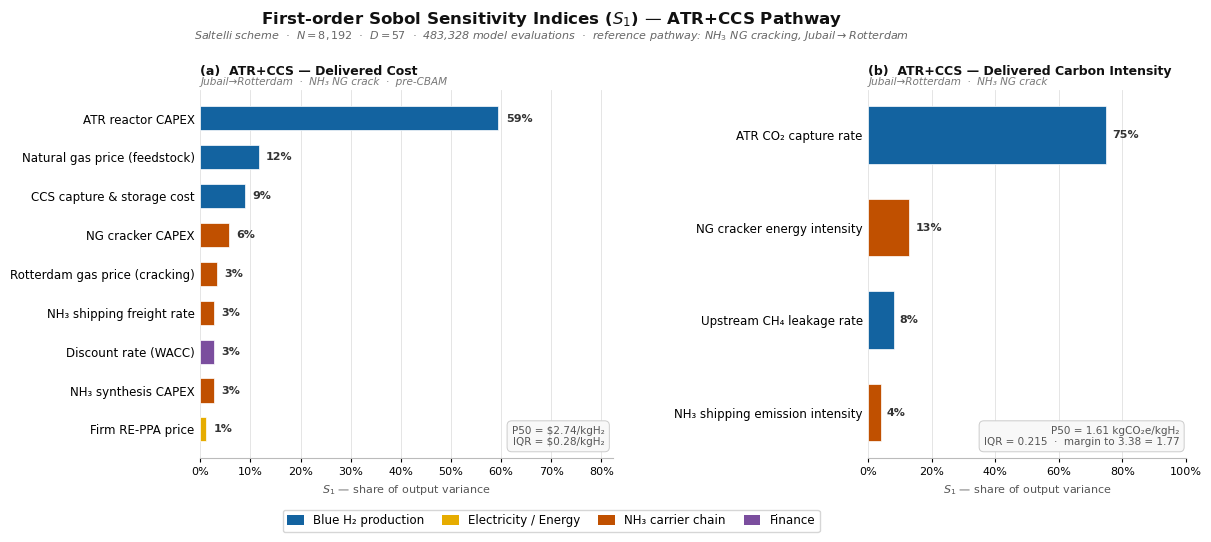


Drawing Figure T13 (ALK Direct vs ALK Firm PPA) …


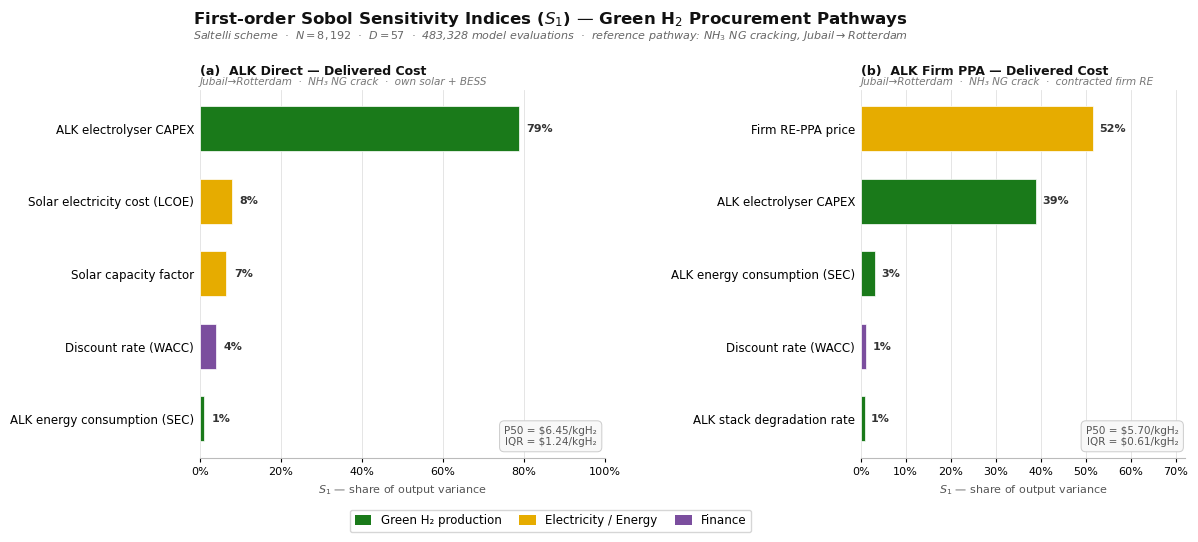


Drawing Figure T14 (SMR+CCS carbon intensity) …


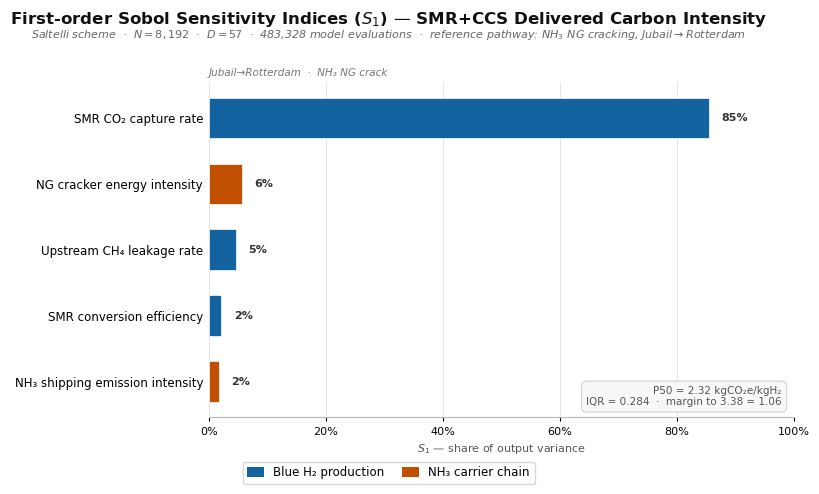

In [19]:
### === Merged from fig_T12_T13_T14_sobol.py (single-notebook pipeline) ===
"""
fig_T12_T13_T14_sobol.py
─────────────────────────────────────────────────────────────────────────────
First-order Sobol sensitivity tornado charts — three narrative figures

  Figure T12  (1×2, cost panel wider):
    (a) ATR+CCS delivered cost         Jubail→Rotterdam · NH₃ NG crack · pre-CBAM
    (b) ATR+CCS delivered CI           Jubail→Rotterdam · NH₃ NG crack

  Figure T13  (standalone):
    ALK Firm PPA delivered cost        Jubail→Rotterdam · NH₃ NG crack · pre-CBAM

  Figure T14  (standalone):
    SMR+CCS delivered CI               Jubail→Rotterdam · NH₃ NG crack

Saltelli scheme  N=8,192  D=56  →  475,136 model evaluations (shared sample).
─────────────────────────────────────────────────────────────────────────────
"""

import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from scipy.stats import triang as _triang_dist
from SALib.sample import sobol as _sobol_sampler
from SALib.analyze import sobol as _sobol_analyzer

warnings.filterwarnings('ignore')

print("Loading runner …")
ctx              = globals()
mc               = ctx['mc_results']
run_monte_carlo  = ctx['run_monte_carlo']
PARAMS           = ctx['PARAMS']
LOGNORMAL_PARAMS = ctx['LOGNORMAL_PARAMS']
PERT_PARAMS      = ctx['PERT_PARAMS']
_lognormal_ppf   = ctx['_lognormal_ppf']
_pert_ppf        = ctx['_pert_ppf']

_s_names = list(PARAMS.keys())
D        = len(_s_names)
SOBOL_N  = 8192
N_EVALS  = SOBOL_N * (D + 2)

print(f"Saltelli sampling  N={SOBOL_N:,}  D={D}  →  {N_EVALS:,} evals …")
t0 = time.time()

_problem_unit = {'num_vars': D, 'names': _s_names, 'bounds': [[0, 1]] * D}
_problem      = {'num_vars': D, 'names': _s_names,
                 'bounds': [[v[0], v[2]] for v in PARAMS.values()]}

if '_salt_res' in ctx and len(ctx['_salt_res']) == SOBOL_N * (D + 2):
    _salt_res = ctx['_salt_res']
    print('  [reuse] Saltelli evaluations from Section 4.2 - no recompute')
else:
    _salt_u = _sobol_sampler.sample(_problem_unit, SOBOL_N, calc_second_order=False)

    _salt_t = np.empty_like(_salt_u)
    for _j, (_nm, (_a, _c, _b)) in enumerate(PARAMS.items()):
        _u = np.clip(_salt_u[:, _j], 1e-9, 1 - 1e-9)
        if _nm in LOGNORMAL_PARAMS:
            _salt_t[:, _j] = _lognormal_ppf(_u, _a, _c, _b)
        elif _nm in PERT_PARAMS:
            _salt_t[:, _j] = _pert_ppf(_u, _a, _c, _b)
        else:
            _salt_t[:, _j] = _triang_dist(
                c=(_c - _a) / (_b - _a), loc=_a, scale=_b - _a).ppf(_u)

    _salt_df  = pd.DataFrame(_salt_t, columns=_s_names)
    _salt_res = run_monte_carlo(_salt_df)
print(f"  Done in {time.time() - t0:.1f}s")

TARGETS = {
    'atr_cost':    'atr_nh3_ng_jr',
    'alk_direct':  'alk_nh3_ng_jr',
    'alk_cost':    'alk_fppa_nh3_ng_jr',
    'atr_ci':      'ci_atr_nh3_ng_jr',
    'smr_ci':      'ci_smr_nh3_ng_jr',
}

print("\nComputing S₁ …")
S1 = {}
for key, col in TARGETS.items():
    Y  = _salt_res[col].values
    Si = _sobol_analyzer.analyze(_problem, Y,
                                  calc_second_order=False,
                                  print_to_console=False)
    S1[key] = {n: max(float(v), 0) for n, v in zip(_s_names, Si['S1'])}
    top4    = sorted(S1[key].items(), key=lambda x: -x[1])[:4]
    print(f"  {key:<12}  " +
          '  '.join(f"{p}({v:.2f})" for p, v in top4))

PARAM_LABELS = {
    'firm_lcoe':                'Firm RE-PPA price',
    'alk_capex':                'ALK electrolyser CAPEX',
    'alk_sec':                  'ALK energy consumption (SEC)',
    'alk_degrad_per_khr':       'ALK stack degradation rate',
    'alk_stack_lifetime_khr':   'ALK stack lifetime',
    'alk_stack_replace_frac':   'ALK stack replacement cost',
    'wacc':                     'Discount rate (WACC)',
    'ng_price':                 'Natural gas price (feedstock)',
    'atr_capex':                'ATR reactor CAPEX',
    'atr_eff':                  'ATR conversion efficiency',
    'atr_capture':              'ATR CO₂ capture rate',
    'ccs_cost':                 'CCS capture & storage cost',
    'smr_capex':                'SMR reactor CAPEX',
    'smr_eff':                  'SMR conversion efficiency',
    'smr_capture':              'SMR CO₂ capture rate',
    'ch4_leakage':              'Upstream CH₄ leakage rate',
    'dest_ng_price_rott':       'Rotterdam gas price (cracking)',
    'ng_crack_kwh_th_per_kgh2': 'NG cracker energy intensity',
    'ng_crack_capex_per_kgh2':  'NG cracker CAPEX',
    'nh3_ship_rate':            'NH₃ shipping freight rate',
    'hb_elec_kwh_per_kgh2':     'NH₃ synthesis energy (HB)',
    'hb_capex_opex_per_kgh2':   'NH₃ synthesis CAPEX',
    'nh3_stor_cost_jubail':     'NH₃ export storage (Jubail)',
    'eu_carbon_price':          'EU carbon price (CBAM/ETS)',
    'solar_lcoe':               'Solar electricity cost (LCOE)',
    'cf_solar':                 'Solar capacity factor',
    'bess_cost_per_kwh':        'BESS cost',
    'pem_capex':                'PEM electrolyser CAPEX',
    'pem_sec':                  'PEM energy consumption (SEC)',
    'nh3_ship_ei':              'NH₃ shipping emission intensity',
    'lh2_ship_ei':              'LH₂ shipping emission intensity',
    'crack_elec_kwh_per_kgh2':  'Electrolytic cracker energy',
}

CAT_COLOR = {
    'firm_lcoe':                '#E6AC00',
    'solar_lcoe':               '#E6AC00',
    'cf_solar':                 '#E6AC00',
    'bess_cost_per_kwh':        '#E6AC00',
    'alk_capex':                '#1a7a1a',
    'alk_sec':                  '#1a7a1a',
    'alk_degrad_per_khr':       '#1a7a1a',
    'alk_stack_lifetime_khr':   '#1a7a1a',
    'alk_stack_replace_frac':   '#1a7a1a',
    'pem_capex':                '#1a7a1a',
    'pem_sec':                  '#1a7a1a',
    'wacc':                     '#7B4E9E',
    'ng_price':                 '#1363a0',
    'atr_capex':                '#1363a0',
    'atr_eff':                  '#1363a0',
    'atr_capture':              '#1363a0',
    'ccs_cost':                 '#1363a0',
    'smr_capex':                '#1363a0',
    'smr_eff':                  '#1363a0',
    'smr_capture':              '#1363a0',
    'ch4_leakage':              '#1363a0',
    'dest_ng_price_rott':       '#C05000',
    'ng_crack_kwh_th_per_kgh2': '#C05000',
    'ng_crack_capex_per_kgh2':  '#C05000',
    'nh3_ship_rate':            '#C05000',
    'hb_elec_kwh_per_kgh2':     '#C05000',
    'hb_capex_opex_per_kgh2':   '#C05000',
    'nh3_stor_cost_jubail':     '#C05000',
    'eu_carbon_price':          '#B00000',
    'japan_carbon_price':       '#B00000',
    'nh3_ship_ei':              '#C05000',
    'lh2_ship_ei':              '#C05000',
    'crack_elec_kwh_per_kgh2':  '#C05000',
}

CAT_NAMES = {
    '#E6AC00': 'Electricity / Energy',
    '#1a7a1a': 'Green H₂ production',
    '#7B4E9E': 'Finance',
    '#1363a0': 'Blue H₂ production',
    '#C05000': 'NH₃ carrier chain',
    '#B00000': 'Carbon / Policy',
}

ORDER  = ['#1363a0', '#1a7a1a', '#E6AC00', '#C05000', '#7B4E9E', '#B00000']
CI_THR = 3.38
TOP_N  = 10
MIN_S1 = 0.01

def get_label(p): return PARAM_LABELS.get(p, p.replace('_', ' ').title())
def get_color(p): return CAT_COLOR.get(p, '#888888')

matplotlib.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        9,
    'axes.linewidth':   0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 0,
})

OUTDIR = 'figures'

SUBTITLE = (f'Saltelli scheme  ·  $N = {SOBOL_N:,}$  ·  $D = {D}$  ·  '
            f'{N_EVALS:,} model evaluations  ·  '
            r'reference pathway: NH$_3$ NG cracking, Jubail$\to$Rotterdam')

def draw_panel(ax, s1key, col, is_ci):
    """Draw tornado bars in ax; return dict {color: category_name} seen."""
    s1     = S1[s1key]
    ranked = sorted(s1.items(), key=lambda x: -x[1])
    ranked = [(p, v) for p, v in ranked if v >= MIN_S1][:TOP_N]

    params_r = list(reversed([p for p, v in ranked]))
    vals_r   = list(reversed([v for p, v in ranked]))
    labels_r = [get_label(p) for p in params_r]
    colors_r = [get_color(p) for p in params_r]

    y = np.arange(len(params_r))
    ax.barh(y, vals_r, color=colors_r, height=0.62,
            edgecolor='white', linewidth=0.5, zorder=3)

    x_max_data = max(vals_r) if vals_r else 0.1
    for i, v in enumerate(vals_r):
        ax.text(v + x_max_data * 0.025, i, f'{v * 100:.0f}%',
                va='center', ha='left', fontsize=8,
                color='#333333', fontweight='bold')

    ax.set_yticks(y)
    ax.set_yticklabels(labels_r, fontsize=8.5)
    ax.tick_params(axis='y', pad=4, length=0)

    x_lim = min(1.0, x_max_data * 1.30 + 0.05)
    ax.set_xlim(0, x_lim)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_xlabel(r'$S_1$ — share of output variance', fontsize=8, color='#555555')
    ax.tick_params(axis='x', labelsize=8)

    ax.set_axisbelow(True)
    ax.grid(axis='x', color='#e0e0e0', linewidth=0.6, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color('#bbbbbb')

    p50 = float(np.percentile(mc[col], 50))
    iqr = float(np.percentile(mc[col], 75) - np.percentile(mc[col], 25))
    if is_ci:
        ann = (f'P50 = {p50:.2f} kgCO₂e/kgH₂\n'
               f'IQR = {iqr:.3f}  ·  margin to 3.38 = {CI_THR - p50:.2f}')
    else:
        ann = f'P50 = ${p50:.2f}/kgH₂\nIQR = ${iqr:.2f}/kgH₂'

    ax.text(0.98, 0.03, ann,
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=7.5, color='#555555',
            bbox=dict(boxstyle='round,pad=0.45', facecolor='#f8f8f8',
                      edgecolor='#cccccc', linewidth=0.7))

    return {get_color(p): CAT_NAMES.get(get_color(p), 'Other')
            for p, v in ranked if v >= MIN_S1}

def panel_titles(fig, ax, plabel, title1, title2, d_bold, d_italic):
    """Place two-line panel title above axes using absolute figure coordinates."""
    pos = ax.get_position()
    x0  = pos.x0
    y1  = pos.y1
    if title1:
        fig.text(x0, y1 + d_bold,
                 (f'{plabel}  ' if plabel else '') + title1,
                 fontsize=9, fontweight='bold', color='#111111',
                 ha='left', va='bottom', transform=fig.transFigure)
    fig.text(x0, y1 + d_italic, title2,
             fontsize=7.5, style='italic', color='#777777',
             ha='left', va='bottom', transform=fig.transFigure)

def add_legend(fig, seen_cats, bbox_y=0.005):
    patches = [mpatches.Patch(facecolor=c, edgecolor='none', label=seen_cats[c])
               for c in ORDER if c in seen_cats]
    fig.legend(handles=patches, loc='lower center', ncol=len(patches),
               fontsize=8.5, frameon=True, edgecolor='#cccccc', facecolor='white',
               bbox_to_anchor=(0.5, bbox_y),
               handlelength=1.4, handleheight=0.9, columnspacing=1.5)

print("\nDrawing Figure T12 (ATR+CCS cost + CI) …")

fig12, axes12 = plt.subplots(
    1, 2,
    figsize=(13.5, 5.5),
    gridspec_kw={'width_ratios': [1.30, 1.0]},
    facecolor='white',
)
fig12.subplots_adjust(
    wspace=0.70,
    top=0.82, bottom=0.15,
    left=0.24, right=0.97,
)

fig12.text(0.5, 0.965,
           r'First-order Sobol Sensitivity Indices ($S_1$) — ATR+CCS Pathway',
           ha='center', va='top', fontsize=12, fontweight='bold', color='#111111')
fig12.text(0.5, 0.930, SUBTITLE,
           ha='center', va='top', fontsize=8, color='#666666', style='italic')

ATR_PANELS = [
    ('atr_cost', 'atr_nh3_ng_jr', '(a)',
     'ATR+CCS — Delivered Cost',
     'Jubail→Rotterdam  ·  NH₃ NG crack  ·  pre-CBAM',
     False),
    ('atr_ci', 'ci_atr_nh3_ng_jr', '(b)',
     'ATR+CCS — Delivered Carbon Intensity',
     'Jubail→Rotterdam  ·  NH₃ NG crack',
     True),
]

seen12 = {}
for ax, (s1key, col, plabel, t1, t2, is_ci) in zip(axes12, ATR_PANELS):
    seen12.update(draw_panel(ax, s1key, col, is_ci))

fig12.canvas.draw()
for ax, (s1key, col, plabel, t1, t2, is_ci) in zip(axes12, ATR_PANELS):
    panel_titles(fig12, ax, plabel, t1, t2, d_bold=0.022, d_italic=0.005)

add_legend(fig12, seen12, bbox_y=0.005)

out12 = os.path.join(OUTDIR, 'fig_T12_sobol_atr.png')
plt.show()

print("\nDrawing Figure T13 (ALK Direct vs ALK Firm PPA) …")

fig13, axes13 = plt.subplots(
    1, 2,
    figsize=(13.5, 5.5),
    gridspec_kw={'width_ratios': [1.25, 1.0]},
    facecolor='white',
)
fig13.subplots_adjust(
    wspace=0.70,
    top=0.82, bottom=0.15,
    left=0.24, right=0.97,
)

fig13.text(
    0.5, 0.965,
    r'First-order Sobol Sensitivity Indices ($S_1$) — Green H$_2$ Procurement Pathways',
    ha='center', va='top', fontsize=12, fontweight='bold', color='#111111')
fig13.text(0.5, 0.930, SUBTITLE,
           ha='center', va='top', fontsize=8, color='#666666', style='italic')

ALK_PANELS = [
    ('alk_direct', 'alk_nh3_ng_jr', '(a)',
     'ALK Direct — Delivered Cost',
     'Jubail→Rotterdam  ·  NH₃ NG crack  ·  own solar + BESS',
     False),
    ('alk_cost', 'alk_fppa_nh3_ng_jr', '(b)',
     'ALK Firm PPA — Delivered Cost',
     'Jubail→Rotterdam  ·  NH₃ NG crack  ·  contracted firm RE',
     False),
]

seen13 = {}
for ax, (s1key, col, plabel, t1, t2, is_ci) in zip(axes13, ALK_PANELS):
    seen13.update(draw_panel(ax, s1key, col, is_ci))

fig13.canvas.draw()
for ax, (s1key, col, plabel, t1, t2, is_ci) in zip(axes13, ALK_PANELS):
    panel_titles(fig13, ax, plabel, t1, t2, d_bold=0.022, d_italic=0.005)

add_legend(fig13, seen13, bbox_y=0.005)

out13 = os.path.join(OUTDIR, 'fig_T13_sobol_alk.png')
plt.show()

print("\nDrawing Figure T14 (SMR+CCS carbon intensity) …")

fig14, ax14 = plt.subplots(1, 1, figsize=(9.0, 5.0), facecolor='white')
fig14.subplots_adjust(top=0.82, bottom=0.15, left=0.30, right=0.95)

fig14.text(
    0.5, 0.965,
    r'First-order Sobol Sensitivity Indices ($S_1$) — SMR+CCS Delivered Carbon Intensity',
    ha='center', va='top', fontsize=12, fontweight='bold', color='#111111')
fig14.text(0.5, 0.930, SUBTITLE,
           ha='center', va='top', fontsize=8, color='#666666', style='italic')

seen14 = draw_panel(ax14, 'smr_ci', 'ci_smr_nh3_ng_jr', True)

fig14.canvas.draw()
panel_titles(fig14, ax14, '', '',
             'Jubail→Rotterdam  ·  NH₃ NG crack',
             d_bold=0, d_italic=0.010)

add_legend(fig14, seen14, bbox_y=0.005)

out14 = os.path.join(OUTDIR, 'fig_T14_sobol_smr.png')
plt.show()

In [20]:
### 4.3  Time Dimension — Wright's Law Electrolyser Learning + Gas Price Trajectory

PEM_LR_TD = 0.18
ALK_LR_TD = 0.13

_CAP_GW = {
    2025: {'pem': 15,  'alk': 10},
    2027: {'pem': 30,  'alk': 18},
    2030: {'pem': 85,  'alk': 45},
    2035: {'pem': 280, 'alk': 130},
}

_NG_PATH = {2025: 0.75, 2027: 0.82, 2030: 0.95, 2035: 1.10}

def _wright_mult(cum0, cumt, lr):
    b = np.log2(1.0 / (1.0 - lr))
    return (cumt / cum0) ** (-b)

_cum0_pem = _CAP_GW[2025]['pem']
_cum0_alk = _CAP_GW[2025]['alk']
_ng0      = PARAMS['ng_price'][1]

print("── Wright's Law Multipliers ────────────────────────────────────────────────")
print(f"  PEM learning rate {PEM_LR_TD:.0%}/doubling  |  ALK {ALK_LR_TD:.0%}/doubling")
print(f"  {'Year':>6}  {'PEM mult':>10}  {'ALK mult':>10}  "
      f"{'PEM $/kW':>10}  {'ALK $/kW':>10}  {'NG $/MMBtu':>12}")
print(f"  {'-'*65}")

_yr_ov = {}
for yr, cap in _CAP_GW.items():
    pm = _wright_mult(_cum0_pem, cap['pem'], PEM_LR_TD)
    am = _wright_mult(_cum0_alk, cap['alk'], ALK_LR_TD)
    ng = _NG_PATH[yr]
    _yr_ov[yr] = {'pem_mult': pm, 'alk_mult': am, 'ng_scale': ng / _ng0}
    print(f"  {yr:>6}  {pm:>10.3f}  {am:>10.3f}  "
          f"{PARAMS['pem_capex'][1]*pm:>10.0f}  "
          f"{PARAMS['alk_capex'][1]*am:>10.0f}  {ng:>12.3f}")

# ── MC distributions scaled to each year ─────────────────────────────────────
print("\n── P50 Delivered Costs ($/kgH2) Jubail→Rotterdam NH3-crack ─────────────────")
print(f"  {'Year':>6}  {'PEM P50':>9}  {'ALK P50':>9}  {'ATR P50':>9}  "
      f"{'P(PEM≤ATR)':>12}  {'P(ALK≤ATR)':>12}  {'P(ALK≤SMR)':>12}")
print(f"  {'-'*80}")

_TD_RESULTS = {}
for yr, ov in _yr_ov.items():
    _df = MC_INPUTS.copy()
    _df['pem_capex'] = MC_INPUTS['pem_capex'] * ov['pem_mult']
    _df['alk_capex'] = MC_INPUTS['alk_capex'] * ov['alk_mult']
    _df['ng_price']  = MC_INPUTS['ng_price']  * ov['ng_scale']
    _r = run_monte_carlo(_df)
    _TD_RESULTS[yr] = _r

    _p50_pem = _r['pem_nh3_jr'].median()
    _p50_alk = _r['alk_nh3_jr'].median()
    _p50_atr = _r['atr_cadj_jr'].median()
    _p_pa    = (_r['pem_nh3_jr'] <= _r['atr_cadj_jr']).mean()
    _p_aa    = (_r['alk_nh3_jr'] <= _r['atr_cadj_jr']).mean()
    _p_as    = (_r['alk_nh3_jr'] <= _r['smr_cadj_jr']).mean()
    print(f"  {yr:>6}  {_p50_pem:>9.3f}  {_p50_alk:>9.3f}  {_p50_atr:>9.3f}  "
          f"{_p_pa:>12.3f}  {_p_aa:>12.3f}  {_p_as:>12.3f}")

# ── P10–P90 spread evolution for PEM and ALK ─────────────────────────────────
print("\n── PEM and ALK Delivered Cost Spread by Year ($/kgH2, Jubail→Rotterdam) ────")
print(f"  {'Year':>6}  {'PEM P10':>9}  {'PEM P50':>9}  {'PEM P90':>9}  "
      f"{'ALK P10':>9}  {'ALK P50':>9}  {'ALK P90':>9}")
print(f"  {'-'*72}")
for yr, _r in _TD_RESULTS.items():
    pp = np.percentile(_r['pem_nh3_jr'], [10, 50, 90])
    ap = np.percentile(_r['alk_nh3_jr'], [10, 50, 90])
    print(f"  {yr:>6}  {pp[0]:>9.3f}  {pp[1]:>9.3f}  {pp[2]:>9.3f}  "
          f"{ap[0]:>9.3f}  {ap[1]:>9.3f}  {ap[2]:>9.3f}")

print("\n  Note: CapEx columns scaled by Wright's Law multiplier applied to each")
print("  MC_INPUTS draw, preserving distributional uncertainty at every year.")
print("  Blue H2 CapEx held at 2025 mode (mature technology, negligible learning).")

── Wright's Law Multipliers ────────────────────────────────────────────────
  PEM learning rate 18%/doubling  |  ALK 13%/doubling
    Year    PEM mult    ALK mult    PEM $/kW    ALK $/kW    NG $/MMBtu
  -----------------------------------------------------------------
    2025       1.000       1.000        2000        1500         0.750
    2027       0.820       0.889        1640        1333         0.820
    2030       0.609       0.739        1217        1109         0.950
    2035       0.433       0.597         865         896         1.100

── P50 Delivered Costs ($/kgH2) Jubail→Rotterdam NH3-crack ─────────────────
    Year    PEM P50    ALK P50    ATR P50    P(PEM≤ATR)    P(ALK≤ATR)    P(ALK≤SMR)
  --------------------------------------------------------------------------------
    2025      7.175      6.515      3.234         0.000         0.000         0.000
    2027      6.290      6.084      3.245         0.000         0.000         0.000
    2030      5.249      5.509   

In [21]:
### 4.4  Joint Probability — Research Question Conditions

_EU_CEILING = 5.50

_rq1 = (MC_RESULTS['alk_nh3_jr']  <= MC_RESULTS['atr_cadj_jr']).astype(int)
_rq2 = MC_RESULTS['atr_eu_jr'].astype(int)
_rq3 = (MC_RESULTS['pem_nh3_jr']  <= _EU_CEILING).astype(int)

_p1   = _rq1.mean();  _p2  = _rq2.mean();  _p3  = _rq3.mean()
_p12  = (_rq1 & _rq2).mean()
_p13  = (_rq1 & _rq3).mean()
_p23  = (_rq2 & _rq3).mean()
_p123 = (_rq1 & _rq2 & _rq3).mean()

print("── Joint Probability — Research Question Conditions ────────────────────────")
print()
print(f"  RQ1  ALK delivered ≤ ATR+CCS carbon-adjusted (Jubail→Rotterdam)")
print(f"  RQ2  ATR+CCS CI ≤ 3.38 kgCO2e/kgH2  (EU Reg. 2023/1184)")
print(f"  RQ3  PEM delivered ≤ ${_EU_CEILING:.2f}/kgH2  (EU import ceiling)")
print()
print(f"  P(RQ1)              = {_p1:.3f}  ({_p1*100:.1f}%)")
print(f"  P(RQ2)              = {_p2:.3f}  ({_p2*100:.1f}%)")
print(f"  P(RQ3)              = {_p3:.3f}  ({_p3*100:.1f}%)")
print()
print(f"  P(RQ1 ∩ RQ2)        = {_p12:.3f}  ({_p12*100:.1f}%)")
print(f"  P(RQ1 ∩ RQ3)        = {_p13:.3f}  ({_p13*100:.1f}%)")
print(f"  P(RQ2 ∩ RQ3)        = {_p23:.3f}  ({_p23*100:.1f}%)")
print()
print(f"  P(RQ1 ∩ RQ2 ∩ RQ3)  = {_p123:.3f}  ({_p123*100:.1f}%)")
print()

# ── Conditional probabilities ─────────────────────────────────────────────────
print("── Conditional Probabilities ───────────────────────────────────────────────")
if _p2 > 0:
    print(f"  P(RQ1 | RQ2)      = {_p12/_p2:.3f}   given ATR EU-compliant, P(green beats blue)")
if _p1 > 0:
    print(f"  P(RQ2 | RQ1)      = {_p12/_p1:.3f}   given green beats blue, P(ATR EU-compliant)")
if _p3 > 0:
    print(f"  P(RQ1 | RQ3)      = {_p13/_p3:.3f}   given PEM affordable, P(green beats blue)")
if _p23 > 0:
    print(f"  P(RQ1 | RQ2∩RQ3)  = {_p123/_p23:.3f}   given compliant AND affordable, P(green beats blue)")

# ── Sensitivity of P(RQ1 ∩ RQ2 ∩ RQ3) to the RQ3 cost ceiling ───────────────
print("\n── P(RQ1 ∩ RQ2 ∩ RQ3) sensitivity to RQ3 cost ceiling ─────────────────────")
print(f"  {'Ceiling $/kgH2':>16}  {'P(RQ3)':>8}  {'P(RQ1∩RQ2∩RQ3)':>16}")
print(f"  {'-'*44}")
for _ceil in [4.50, 4.75, 5.00, 5.25, 5.50, 5.75, 6.00, 6.50, 7.00]:
    _rq3c   = (MC_RESULTS['pem_nh3_jr'] <= _ceil).astype(int)
    _p3c    = _rq3c.mean()
    _p123c  = (_rq1 & _rq2 & _rq3c).mean()
    _marker = "  ← base case" if abs(_ceil - _EU_CEILING) < 0.01 else ""
    print(f"  {_ceil:>16.2f}  {_p3c:>8.3f}  {_p123c:>16.3f}{_marker}")

── Joint Probability — Research Question Conditions ────────────────────────

  RQ1  ALK delivered ≤ ATR+CCS carbon-adjusted (Jubail→Rotterdam)
  RQ2  ATR+CCS CI ≤ 3.38 kgCO2e/kgH2  (EU Reg. 2023/1184)
  RQ3  PEM delivered ≤ $5.50/kgH2  (EU import ceiling)

  P(RQ1)              = 0.000  (0.0%)
  P(RQ2)              = 1.000  (100.0%)
  P(RQ3)              = 0.001  (0.1%)

  P(RQ1 ∩ RQ2)        = 0.000  (0.0%)
  P(RQ1 ∩ RQ3)        = 0.000  (0.0%)
  P(RQ2 ∩ RQ3)        = 0.001  (0.1%)

  P(RQ1 ∩ RQ2 ∩ RQ3)  = 0.000  (0.0%)

── Conditional Probabilities ───────────────────────────────────────────────
  P(RQ1 | RQ2)      = 0.000   given ATR EU-compliant, P(green beats blue)
  P(RQ1 | RQ3)      = 0.000   given PEM affordable, P(green beats blue)
  P(RQ1 | RQ2∩RQ3)  = 0.000   given compliant AND affordable, P(green beats blue)

── P(RQ1 ∩ RQ2 ∩ RQ3) sensitivity to RQ3 cost ceiling ─────────────────────
    Ceiling $/kgH2    P(RQ3)    P(RQ1∩RQ2∩RQ3)
  ----------------------------------------

---
## Section 5 — Visualisations

In [22]:
### 5.1  Setup — Matplotlib Style, Colour Palette, Save Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np, os, warnings
warnings.filterwarnings('ignore')

FIG_DIR = os.path.join(os.path.dirname(os.path.abspath('saudi_h2_model.ipynb')), 'figures')

# ── Colour palette ────────────────────────────────────────────────────────────
TC = {
    'pem': '#1565C0',
    'alk': '#42A5F5',
    'atr': '#E65100',
    'smr': '#B71C1C',
    'lh2':     '#00897B',
    'pem_fppa': '#2E7D32',
    'alk_fppa': '#81C784',
}

# ── Global rcParams ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.labelsize':    12,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'figure.dpi':        130,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linestyle':    '--',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.framealpha': 0.85,
    'legend.fontsize':   10,
})

def _pcts(arr, ps=(10,25,50,75,90)):
    return np.percentile(arr, ps)

def _save(fig, filename=None, **kwargs):
    plt.show()

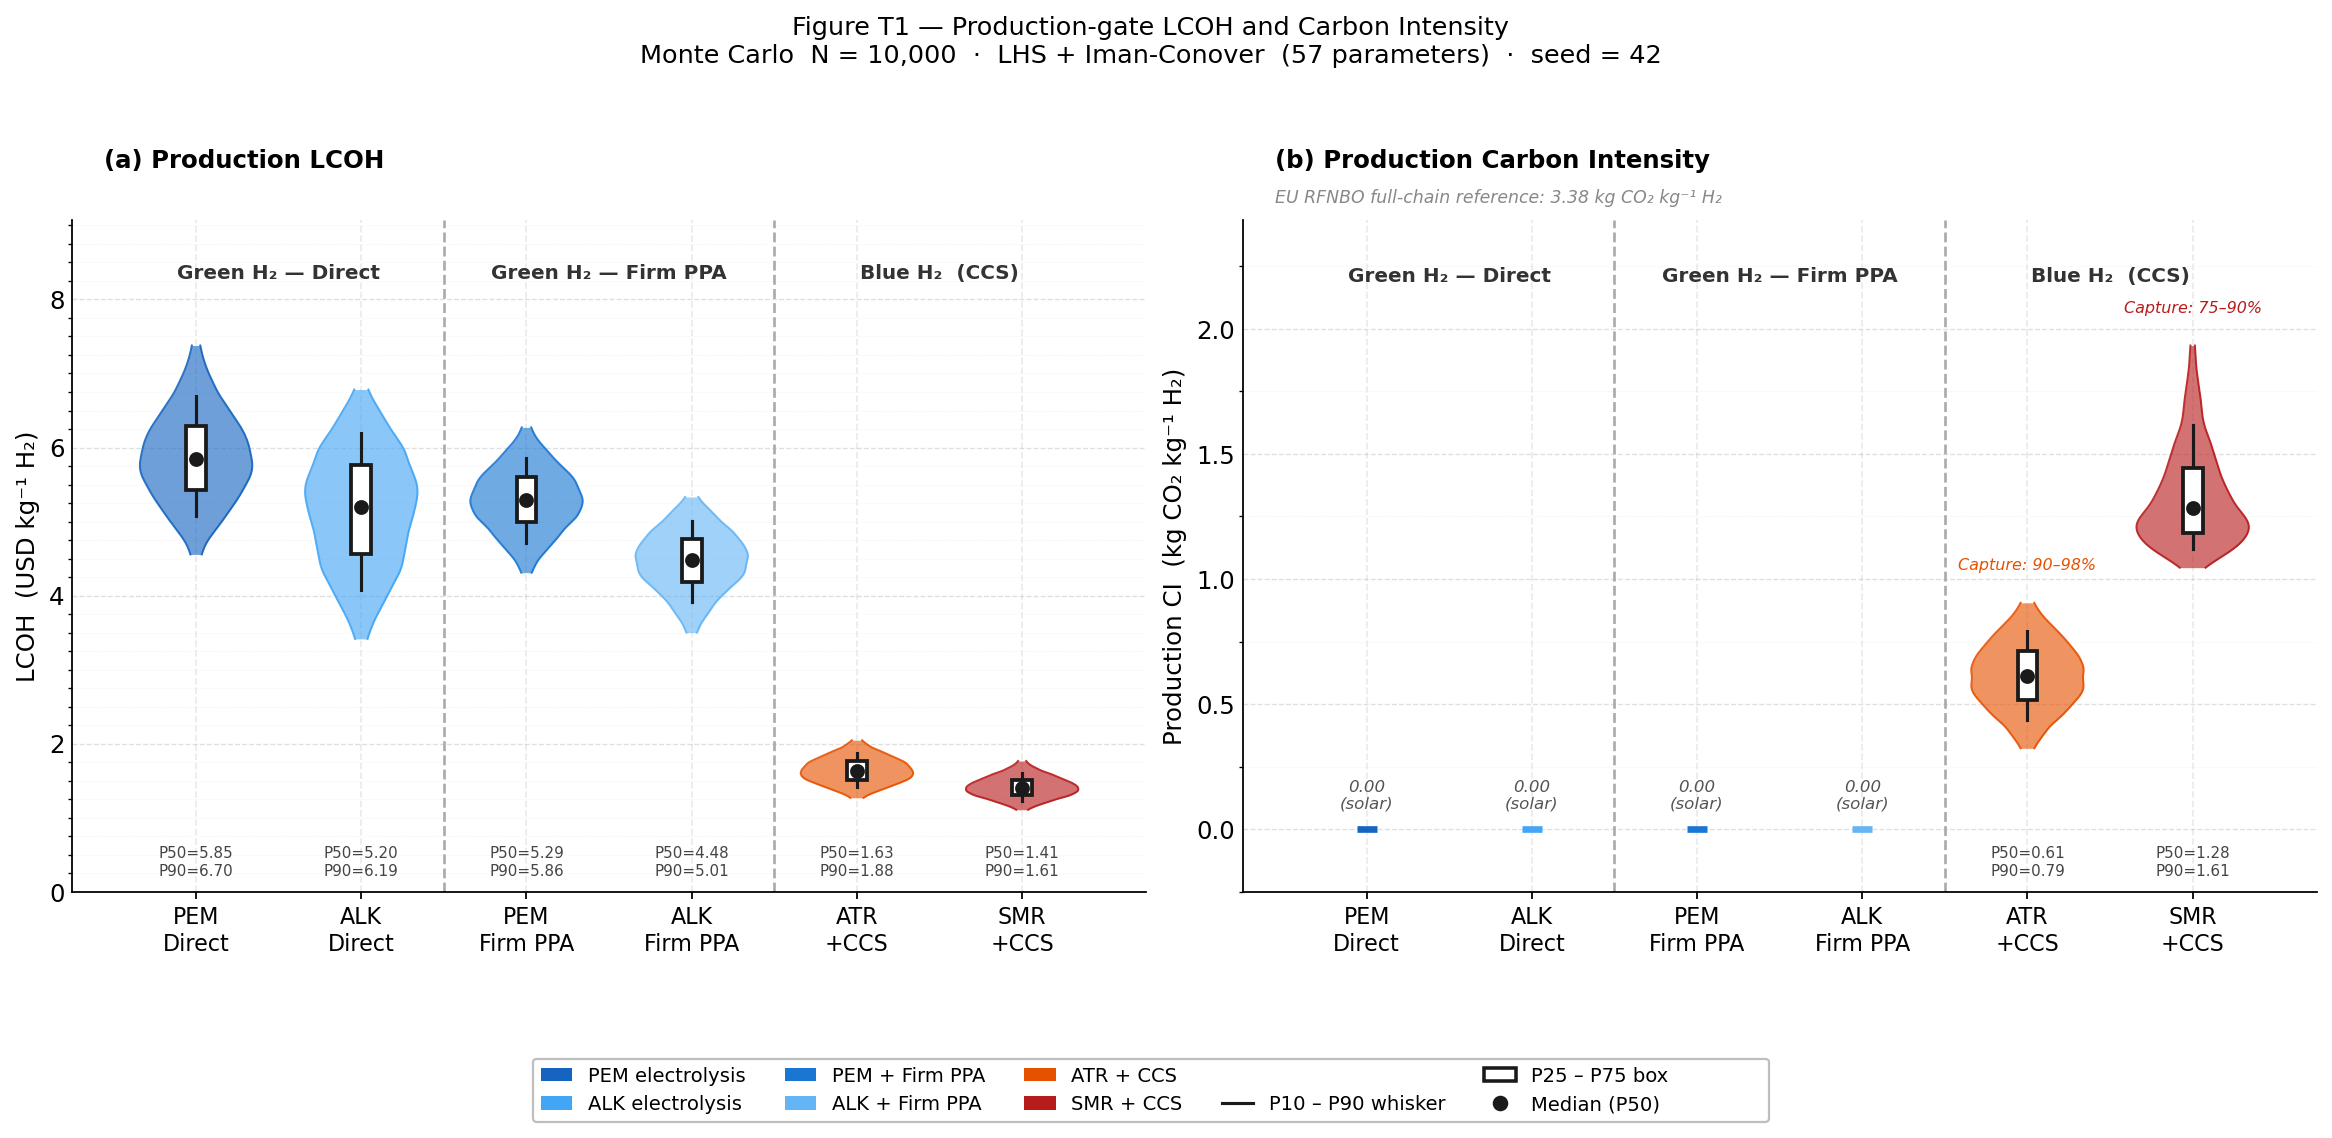

In [23]:
### T1 — Figure T1: Production-gate LCOH and Carbon Intensity

from scipy.stats import gaussian_kde
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpa

# ── violin helper ─────────────────────────────────────────────────────────────
def _vln(ax, data, x, color, w=0.68, bw='silverman', alpha=0.62, clip=(1, 99)):
    d = np.asarray(data, dtype=float); d = d[np.isfinite(d)]
    lo, hi = np.percentile(d, clip)
    y = np.linspace(lo, hi, 400)
    dens = gaussian_kde(d, bw_method=bw)(y)
    dens = dens / dens.max() * (w / 2)
    ax.fill_betweenx(y, x - dens, x + dens, color=color, alpha=alpha, lw=0, zorder=2)
    ax.plot(x - dens, y, color=color, alpha=0.90, lw=0.9, zorder=2)
    ax.plot(x + dens, y, color=color, alpha=0.90, lw=0.9, zorder=2)
    p10, p25, p50, p75, p90 = np.percentile(d, [10, 25, 50, 75, 90])
    ax.plot([x, x], [p10, p90], color='#1a1a1a', lw=1.4, zorder=3)
    ax.add_patch(FancyBboxPatch((x - 0.06, p25), 0.12, p75 - p25,
                                boxstyle='square,pad=0',
                                fc='white', ec='#1a1a1a', lw=1.7, zorder=4))
    ax.scatter([x], [p50], s=32, color='#1a1a1a', zorder=5)
    return p10, p50, p90

def _zero_mark(ax, x, color):
    ax.scatter([x], [0], s=80, color=color, marker='_', linewidths=3, zorder=5)
    ax.text(x, 0.07, '0.00\n(solar)', ha='center', va='bottom',
            fontsize=7.5, color='#555555', style='italic')

# ── pathway catalogue ─────────────────────────────────────────────────────────
PW = [
    ('lcoh_pem',      'PEM\nDirect',    TC['pem'],  None),
    ('lcoh_alk',      'ALK\nDirect',    TC['alk'],  None),
    ('lcoh_pem_fppa', 'PEM\nFirm PPA', '#1976D2',  None),
    ('lcoh_alk_fppa', 'ALK\nFirm PPA', '#64B5F6',  None),
    ('lcoh_atr',      'ATR\n+CCS',     TC['atr'],  'ci_atr_prod'),
    ('lcoh_smr',      'SMR\n+CCS',     TC['smr'],  'ci_smr_prod'),
]
xs = list(range(1, 7))

# ── figure ────────────────────────────────────────────────────────────────────
_fig = plt.figure(figsize=(15.5, 7.5), dpi=160)
gs   = gridspec.GridSpec(1, 2, figure=_fig, wspace=0.09,
                         left=0.065, right=0.97, top=0.80, bottom=0.24)
al   = _fig.add_subplot(gs[0])
ar   = _fig.add_subplot(gs[1])

sep_kw = dict(color='#aaaaaa', lw=1.2, ls='--', zorder=1)
for ax in (al, ar):
    ax.set_xticks(xs); ax.set_xticklabels([p[1] for p in PW], fontsize=10)
    ax.set_xlim(0.25, 6.75)
    ax.grid(axis='y', which='major', lw=0.6, alpha=0.40, color='#b0b0b0')
    ax.grid(axis='y', which='minor', lw=0.3, alpha=0.22, color='#d0d0d0')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.axvline(2.5, **sep_kw); ax.axvline(4.5, **sep_kw)

lcoh_st = {}
for (col, lbl, clr, _), x in zip(PW, xs):
    lcoh_st[col] = _vln(al, mc_results[col].values, x, clr)

al.set_ylabel('LCOH  (USD kg⁻¹ H₂)', fontsize=11)
al.yaxis.set_minor_locator(plt.MultipleLocator(0.25))
al.set_ylim(bottom=0.0)
ly1 = al.get_ylim()[1]; al.set_ylim(top=ly1 * 1.18)

al.text(0.03, 1.07, '(a) Production LCOH',
        transform=al.transAxes, fontsize=11, fontweight='bold',
        va='bottom', clip_on=False)

for txt, xm in [('Green H₂ — Direct', 1.5),
                ('Green H₂ — Firm PPA', 3.5),
                ('Blue H₂  (CCS)', 5.5)]:
    al.text(xm, ly1 * 1.07, txt, ha='center', va='bottom',
            fontsize=9, color='#333333', fontweight='bold')

for (col, *_), x in zip(PW, xs):
    p10, p50, p90 = lcoh_st[col]
    al.text(x, 0.02, f'P50={p50:.2f}\nP90={p90:.2f}',
            ha='center', va='bottom', fontsize=6.8, color='#444444',
            transform=al.get_xaxis_transform())

ci_st = {}
for (col, lbl, clr, ci_col), x in zip(PW, xs):
    if ci_col is None:
        _zero_mark(ar, x, clr)
    else:
        ci_st[ci_col] = _vln(ar, mc_results[ci_col].values, x, clr)

ar.set_ylabel('Production CI  (kg CO₂ kg⁻¹ H₂)', fontsize=11)
ar.yaxis.set_minor_locator(plt.MultipleLocator(0.25))
ar.set_ylim(bottom=-0.25)
cy1 = ar.get_ylim()[1]; ar.set_ylim(top=cy1 * 1.20)

ar.text(0.03, 1.07, '(b) Production Carbon Intensity',
        transform=ar.transAxes, fontsize=11, fontweight='bold',
        va='bottom', clip_on=False)

for txt, xm in [('Green H₂ — Direct', 1.5),
                ('Green H₂ — Firm PPA', 3.5),
                ('Blue H₂  (CCS)', 5.5)]:
    ar.text(xm, cy1 * 1.07, txt, ha='center', va='bottom',
            fontsize=9, color='#333333', fontweight='bold')

ar.text(0.03, 1.02,
        'EU RFNBO full-chain reference: 3.38 kg CO₂ kg⁻¹ H₂',
        transform=ar.transAxes, fontsize=7.8, color='#888888',
        style='italic', va='bottom', clip_on=False)

for (col, lbl, clr, ci_col), x in zip(PW, xs):
    if ci_col is not None:
        p10, p50, p90 = ci_st[ci_col]
        ar.text(x, 0.02, f'P50={p50:.2f}\nP90={p90:.2f}',
                ha='center', va='bottom', fontsize=6.8, color='#444444',
                transform=ar.get_xaxis_transform())

for ci_col, cap_col, clr, x in [('ci_atr_prod', 'atr_capture', TC['atr'], 5),
                                  ('ci_smr_prod', 'smr_capture', TC['smr'], 6)]:
    cap_lo  = PARAMS[cap_col][0] * 100
    cap_hi  = PARAMS[cap_col][2] * 100
    ci_p99  = np.percentile(mc_results[ci_col].values, 99)
    ar.text(x, ci_p99 + 0.12,
            f'Capture: {cap_lo:.0f}–{cap_hi:.0f}%',
            ha='center', va='bottom', fontsize=7.2,
            color=clr, style='italic')

_color_h = [
    mpa.Patch(fc=TC['pem'],  ec='none', label='PEM electrolysis'),
    mpa.Patch(fc=TC['alk'],  ec='none', label='ALK electrolysis'),
    mpa.Patch(fc='#1976D2',  ec='none', label='PEM + Firm PPA'),
    mpa.Patch(fc='#64B5F6',  ec='none', label='ALK + Firm PPA'),
    mpa.Patch(fc=TC['atr'],  ec='none', label='ATR + CCS'),
    mpa.Patch(fc=TC['smr'],  ec='none', label='SMR + CCS'),
]
_stat_h = [
    plt.Line2D([0], [0], color='#1a1a1a', lw=1.4,                  label='P10 – P90 whisker'),
    mpa.Patch(fc='white', ec='#1a1a1a', lw=1.6,                    label='P25 – P75 box'),
    plt.Line2D([0], [0], marker='o', color='#1a1a1a', lw=0, ms=6,  label='Median (P50)'),
]
_e = mpa.Patch(fc='none', ec='none', label=' ')
_all_h = _color_h + [_e, _stat_h[0], _stat_h[1], _stat_h[2], _e, _e]

_fig.legend(handles=_all_h, loc='lower center', ncol=6,
            fontsize=8.8, frameon=True, framealpha=0.95,
            edgecolor='#bbbbbb', handlelength=1.6,
            bbox_to_anchor=(0.50, 0.04))

# ── main title ────────────────────────────────────────────────────────────────
_fig.suptitle(
    'Figure T1 — Production-gate LCOH and Carbon Intensity\n'
    f'Monte Carlo  N = {N_SAMPLES:,}  ·  LHS + Iman-Conover  ({len(PARAMS)} parameters)  ·  seed = {RANDOM_SEED}',
    fontsize=11.5, y=0.97
)

_save(_fig, 'fig_T1_production_lcoh_ci.png')

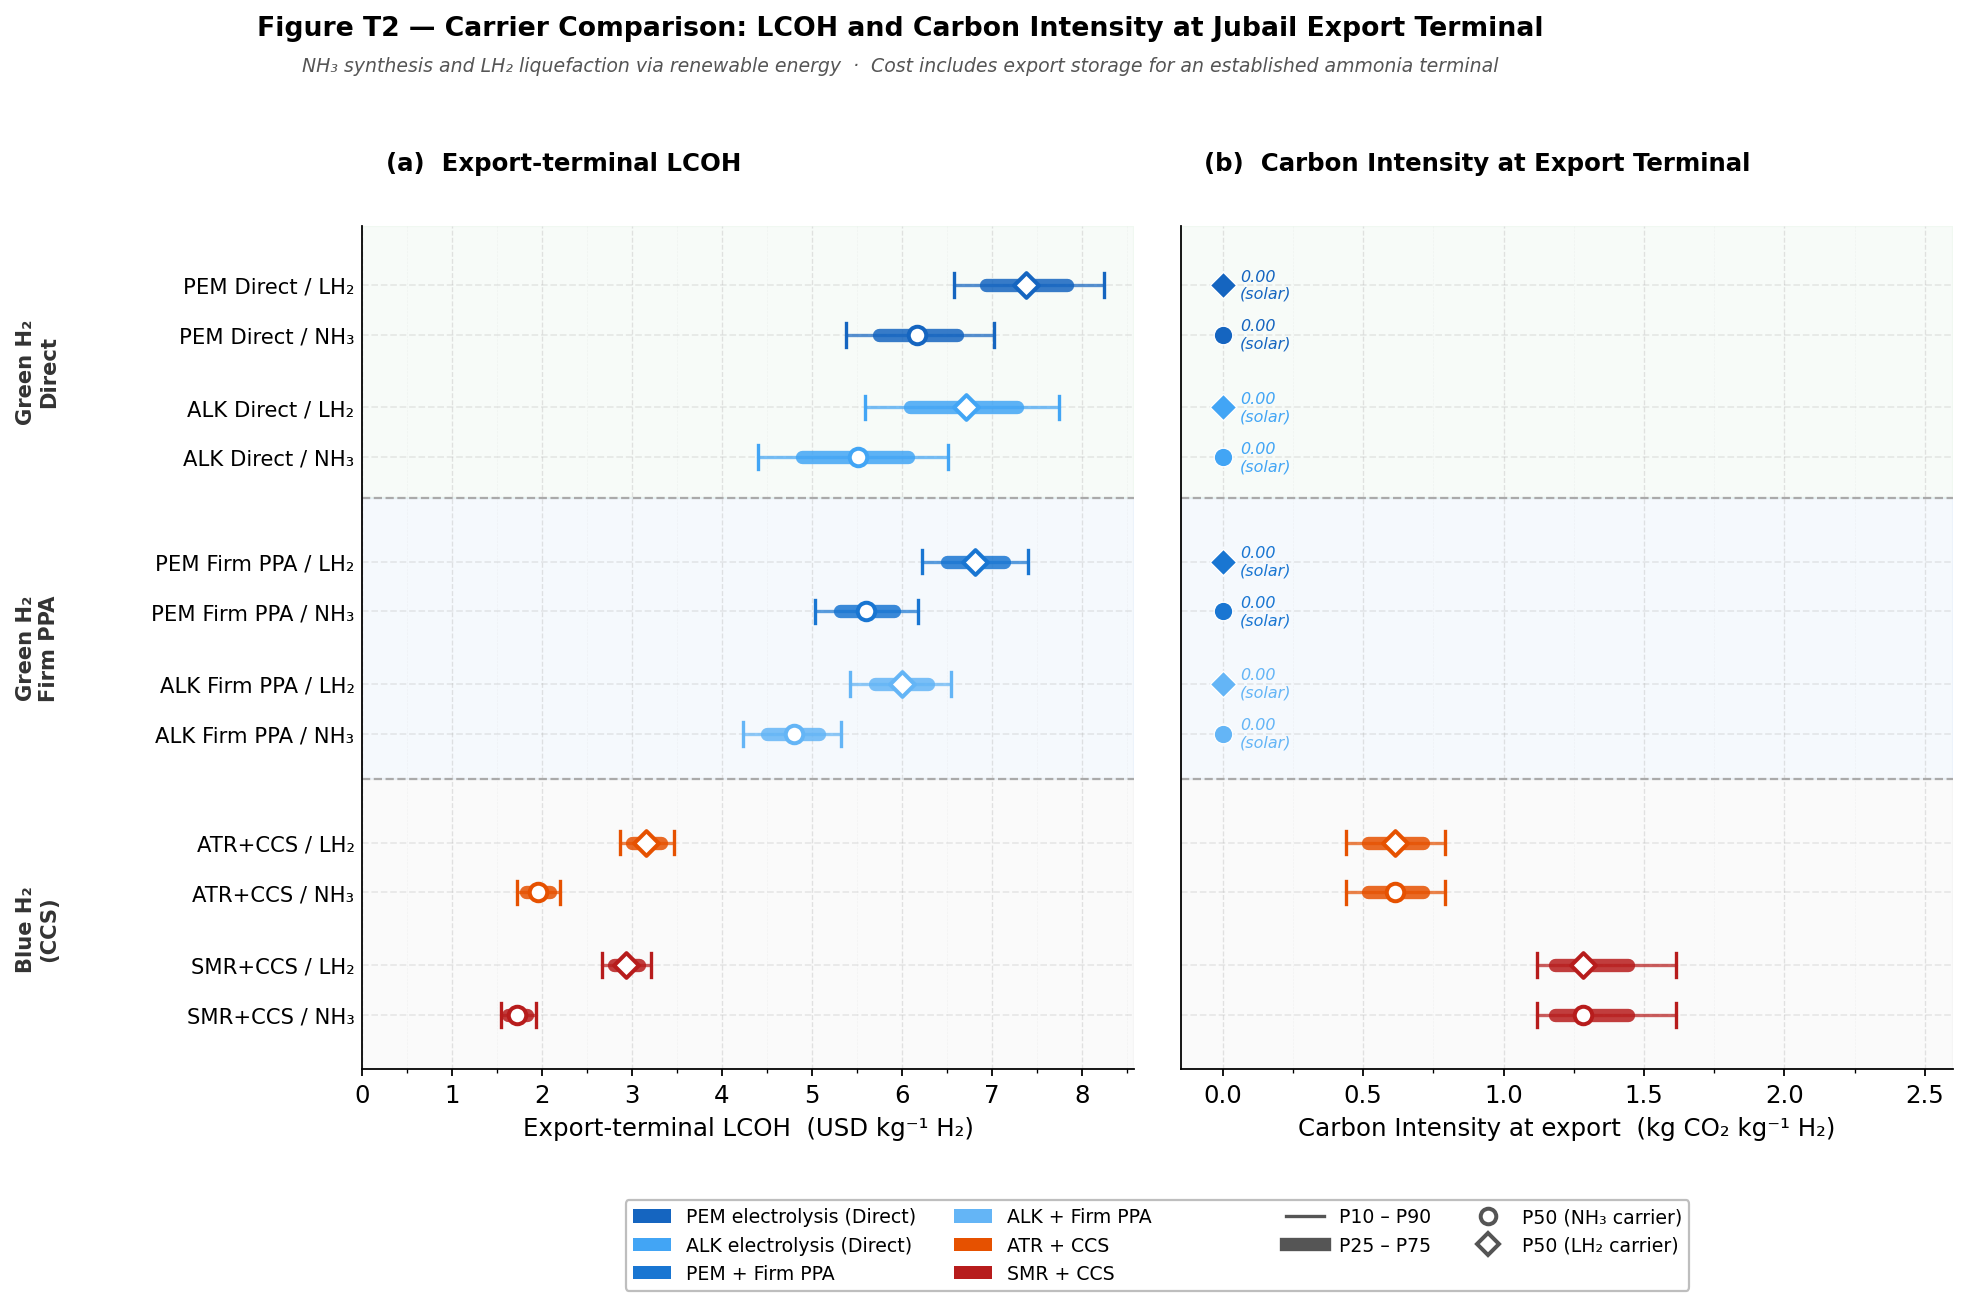

In [24]:
"""
Figure T2 v2 — Carrier Comparison: LCOH and CI at Jubail Export Terminal
- Costs = production LCOH + export-side conversion + Jubail storage only
  (no shipping, no Rotterdam storage, no cracking at destination)
- CI = production CI only; HB synthesis and LH₂ liquefaction are solar-powered 
  (cracking at Rotterdam excluded — that is an import-side step)
- No ETS/CBAM
"""
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpa
import numpy as np, os, runpy, sys

sys.path.insert(0, os.getcwd())
os.chdir(os.getcwd())
ctx = globals()
mc          = ctx['mc_results']
mi          = ctx['mc_inputs']
TC          = ctx['TC']
FIG_DIR     = ctx['FIG_DIR']
N_SAMPLES   = ctx['N_SAMPLES']
RANDOM_SEED = ctx['RANDOM_SEED']
PARAMS      = ctx['PARAMS']

# ── compute export-terminal add-on costs from mc_inputs ───────────────────
solar_lcoe  = mi['solar_lcoe'].values
hb_cost     = (mi['hb_capex_opex_per_kgh2'].values
               + mi['hb_elec_kwh_per_kgh2'].values * solar_lcoe)
nh3_stor    = mi['nh3_stor_cost_jubail'].values

lh2_liq     = (mi['lh2_liq_capex_opex_per_kgh2'].values
               + mi['lh2_liq_kwh_per_kgh2'].values * solar_lcoe)
lh2_stor    = mi['lh2_stor_cost'].values

# ── LCOH at Jubail export terminal ────────────────────────────────────────
nh3_exp_pem      = mc['lcoh_pem'].values      + hb_cost + nh3_stor
nh3_exp_alk      = mc['lcoh_alk'].values      + hb_cost + nh3_stor
nh3_exp_pem_fppa = mc['lcoh_pem_fppa'].values + hb_cost + nh3_stor
nh3_exp_alk_fppa = mc['lcoh_alk_fppa'].values + hb_cost + nh3_stor
nh3_exp_atr      = mc['lcoh_atr'].values      + hb_cost + nh3_stor
nh3_exp_smr      = mc['lcoh_smr'].values      + hb_cost + nh3_stor

lh2_exp_pem      = mc['lcoh_pem'].values      + lh2_liq + lh2_stor
lh2_exp_alk      = mc['lcoh_alk'].values      + lh2_liq + lh2_stor
lh2_exp_pem_fppa = mc['lcoh_pem_fppa'].values + lh2_liq + lh2_stor
lh2_exp_alk_fppa = mc['lcoh_alk_fppa'].values + lh2_liq + lh2_stor
lh2_exp_atr      = mc['lcoh_atr'].values      + lh2_liq + lh2_stor
lh2_exp_smr      = mc['lcoh_smr'].values      + lh2_liq + lh2_stor

# ── CI at Jubail export terminal ──────────────────────────────────────────
ci_exp_atr = mc['ci_atr_prod'].values
ci_exp_smr = mc['ci_smr_prod'].values
ZERO_CI    = True

# ── row definitions (bottom-to-top: cheapest first) ───────────────────────
ROWS = [
    (0.0,  'SMR+CCS / NH₃',      nh3_exp_smr,      ci_exp_smr,     TC['smr'],  'NH₃'),
    (0.55, 'SMR+CCS / LH₂',      lh2_exp_smr,      ci_exp_smr,     TC['smr'],  'LH₂'),
    (1.35, 'ATR+CCS / NH₃',      nh3_exp_atr,      ci_exp_atr,     TC['atr'],  'NH₃'),
    (1.90, 'ATR+CCS / LH₂',      lh2_exp_atr,      ci_exp_atr,     TC['atr'],  'LH₂'),
    (3.10, 'ALK Firm PPA / NH₃', nh3_exp_alk_fppa, None,           '#64B5F6',  'NH₃'),
    (3.65, 'ALK Firm PPA / LH₂', lh2_exp_alk_fppa, None,           '#64B5F6',  'LH₂'),
    (4.45, 'PEM Firm PPA / NH₃', nh3_exp_pem_fppa, None,           '#1976D2',  'NH₃'),
    (5.00, 'PEM Firm PPA / LH₂', lh2_exp_pem_fppa, None,           '#1976D2',  'LH₂'),
    (6.15, 'ALK Direct / NH₃',   nh3_exp_alk,      None,           TC['alk'],  'NH₃'),
    (6.70, 'ALK Direct / LH₂',   lh2_exp_alk,      None,           TC['alk'],  'LH₂'),
    (7.50, 'PEM Direct / NH₃',   nh3_exp_pem,      None,           TC['pem'],  'NH₃'),
    (8.05, 'PEM Direct / LH₂',   lh2_exp_pem,      None,           TC['pem'],  'LH₂'),
]

Y_VALS  = [r[0] for r in ROWS]
Y_LABS  = [r[1] for r in ROWS]
Y_MIN, Y_MAX = -0.6, 8.7

# ── interval drawing helper ───────────────────────────────────────────────
def _ivl(ax, data, y, color, carrier):
    d = np.asarray(data, dtype=float); d = d[np.isfinite(d)]
    p10, p25, p50, p75, p90 = np.percentile(d, [10, 25, 50, 75, 90])
    ax.plot([p10, p90], [y, y], color=color, lw=1.5, alpha=0.70, zorder=2,
            solid_capstyle='round')
    for xv in (p10, p90):
        ax.plot([xv, xv], [y-0.13, y+0.13], color=color, lw=1.5, zorder=2)
    ax.plot([p25, p75], [y, y], color=color, lw=6, alpha=0.85, zorder=3,
            solid_capstyle='round')
    mkr = 'D' if carrier == 'LH₂' else 'o'
    ax.scatter([p50], [y], s=62, color='white', marker=mkr,
               edgecolors=color, linewidths=1.8, zorder=5)
    return p50

# ── figure layout ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14.0, 8.5), dpi=160)
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.06,
                        left=0.26, right=0.97, top=0.82, bottom=0.20)
al  = fig.add_subplot(gs[0])
ar  = fig.add_subplot(gs[1], sharey=al)

for ax in (al, ar):
    ax.set_yticks(Y_VALS)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.grid(axis='x', which='major', lw=0.6, alpha=0.38, color='#b8b8b8')
    ax.grid(axis='x', which='minor', lw=0.3, alpha=0.20, color='#d0d0d0')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

al.set_yticklabels(Y_LABS, fontsize=9.5)
ar.tick_params(labelleft=False)

for ax in (al, ar):
    ax.axhline(2.60, color='#aaaaaa', lw=1.0, ls='--', zorder=1)
    ax.axhline(5.70, color='#aaaaaa', lw=1.0, ls='--', zorder=1)

def _data_to_fig_y(ydata):
    frac = (ydata - Y_MIN) / (Y_MAX - Y_MIN)
    return 0.20 + frac * (0.82 - 0.20)

grp_kw = dict(transform=fig.transFigure, fontsize=9.5, fontweight='bold',
              color='#333333', rotation=90, ha='center', va='center',
              clip_on=False)
fig.text(0.115, _data_to_fig_y(0.95), 'Blue H₂\n(CCS)',        **grp_kw)
fig.text(0.115, _data_to_fig_y(4.05), 'Green H₂\nFirm PPA',    **grp_kw)
fig.text(0.115, _data_to_fig_y(7.10), 'Green H₂\nDirect',      **grp_kw)

for ax in (al, ar):
    ax.axhspan(-0.6,  2.60, alpha=0.04, color='#888888', zorder=0)
    ax.axhspan( 2.60, 5.70, alpha=0.04, color='#1976D2', zorder=0)
    ax.axhspan( 5.70, 8.70, alpha=0.04, color='#4CAF50', zorder=0)

for y, lbl, lcoh_arr, ci_arr, color, carrier in ROWS:
    _ivl(al, lcoh_arr, y, color, carrier)

al.set_xlabel('Export-terminal LCOH  (USD kg⁻¹ H₂)', fontsize=11)
al.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
al.set_xlim(left=0)

al.text(0.03, 1.06, '(a)  Export-terminal LCOH',
        transform=al.transAxes, fontsize=11, fontweight='bold',
        va='bottom', clip_on=False)

for y, lbl, lcoh_arr, ci_arr, color, carrier in ROWS:
    if ci_arr is not None:
        _ivl(ar, ci_arr, y, color, carrier)
    else:
        ar.scatter([0], [y], s=70, color=color, marker='D' if carrier == 'LH₂' else 'o',
                   edgecolors='white', linewidths=0.6, zorder=5)
        ar.text(0.06, y, '0.00\n(solar)', va='center', ha='left',
                fontsize=7.2, color=color, style='italic')

ar.set_xlabel('Carbon Intensity at export  (kg CO₂ kg⁻¹ H₂)', fontsize=11)
ar.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
ar.set_xlim(left=-0.15, right=2.6)

ar.text(0.03, 1.06, '(b)  Carbon Intensity at Export Terminal',
        transform=ar.transAxes, fontsize=11, fontweight='bold',
        va='bottom', clip_on=False)

# ── legend ────────────────────────────────────────────────────────────────
legend_h = [
    mpa.Patch(fc=TC['pem'],  ec='none', label='PEM electrolysis (Direct)'),
    mpa.Patch(fc=TC['alk'],  ec='none', label='ALK electrolysis (Direct)'),
    mpa.Patch(fc='#1976D2',  ec='none', label='PEM + Firm PPA'),
    mpa.Patch(fc='#64B5F6',  ec='none', label='ALK + Firm PPA'),
    mpa.Patch(fc=TC['atr'],  ec='none', label='ATR + CCS'),
    mpa.Patch(fc=TC['smr'],  ec='none', label='SMR + CCS'),
    plt.Line2D([0],[0], color='#555555', lw=1.5,             label='P10 – P90'),
    plt.Line2D([0],[0], color='#555555', lw=6,               label='P25 – P75'),
    plt.Line2D([0],[0], marker='o', color='white', ms=7,
               mec='#555555', mew=1.8, lw=0,                label='P50 (NH₃ carrier)'),
    plt.Line2D([0],[0], marker='D', color='white', ms=7,
               mec='#555555', mew=1.8, lw=0,                label='P50 (LH₂ carrier)'),
]
_e = mpa.Patch(fc='none', ec='none', label=' ')
all_h = legend_h[:6] + [_e, _e] + legend_h[6:]
fig.legend(handles=all_h, loc='lower center', ncol=5,
           fontsize=8.5, frameon=True, framealpha=0.95, edgecolor='#bbbbbb',
           bbox_to_anchor=(0.615, 0.03))

# ── title + description ───────────────────────────────────────────────────
fig.suptitle(
    'Figure T2 — Carrier Comparison: LCOH and Carbon Intensity at Jubail Export Terminal',
    fontsize=12, y=0.975, fontweight='bold'
)
fig.text(
    0.50, 0.945,
    'NH₃ synthesis and LH₂ liquefaction via renewable energy  ·  '
    'Cost includes export storage for an established ammonia terminal',
    ha='center', va='top', fontsize=8.5, color='#555555', style='italic'
)

# ── save ──────────────────────────────────────────────────────────────────
out = os.path.join(FIG_DIR, 'fig_T2_carrier_comparison.png')
plt.show()

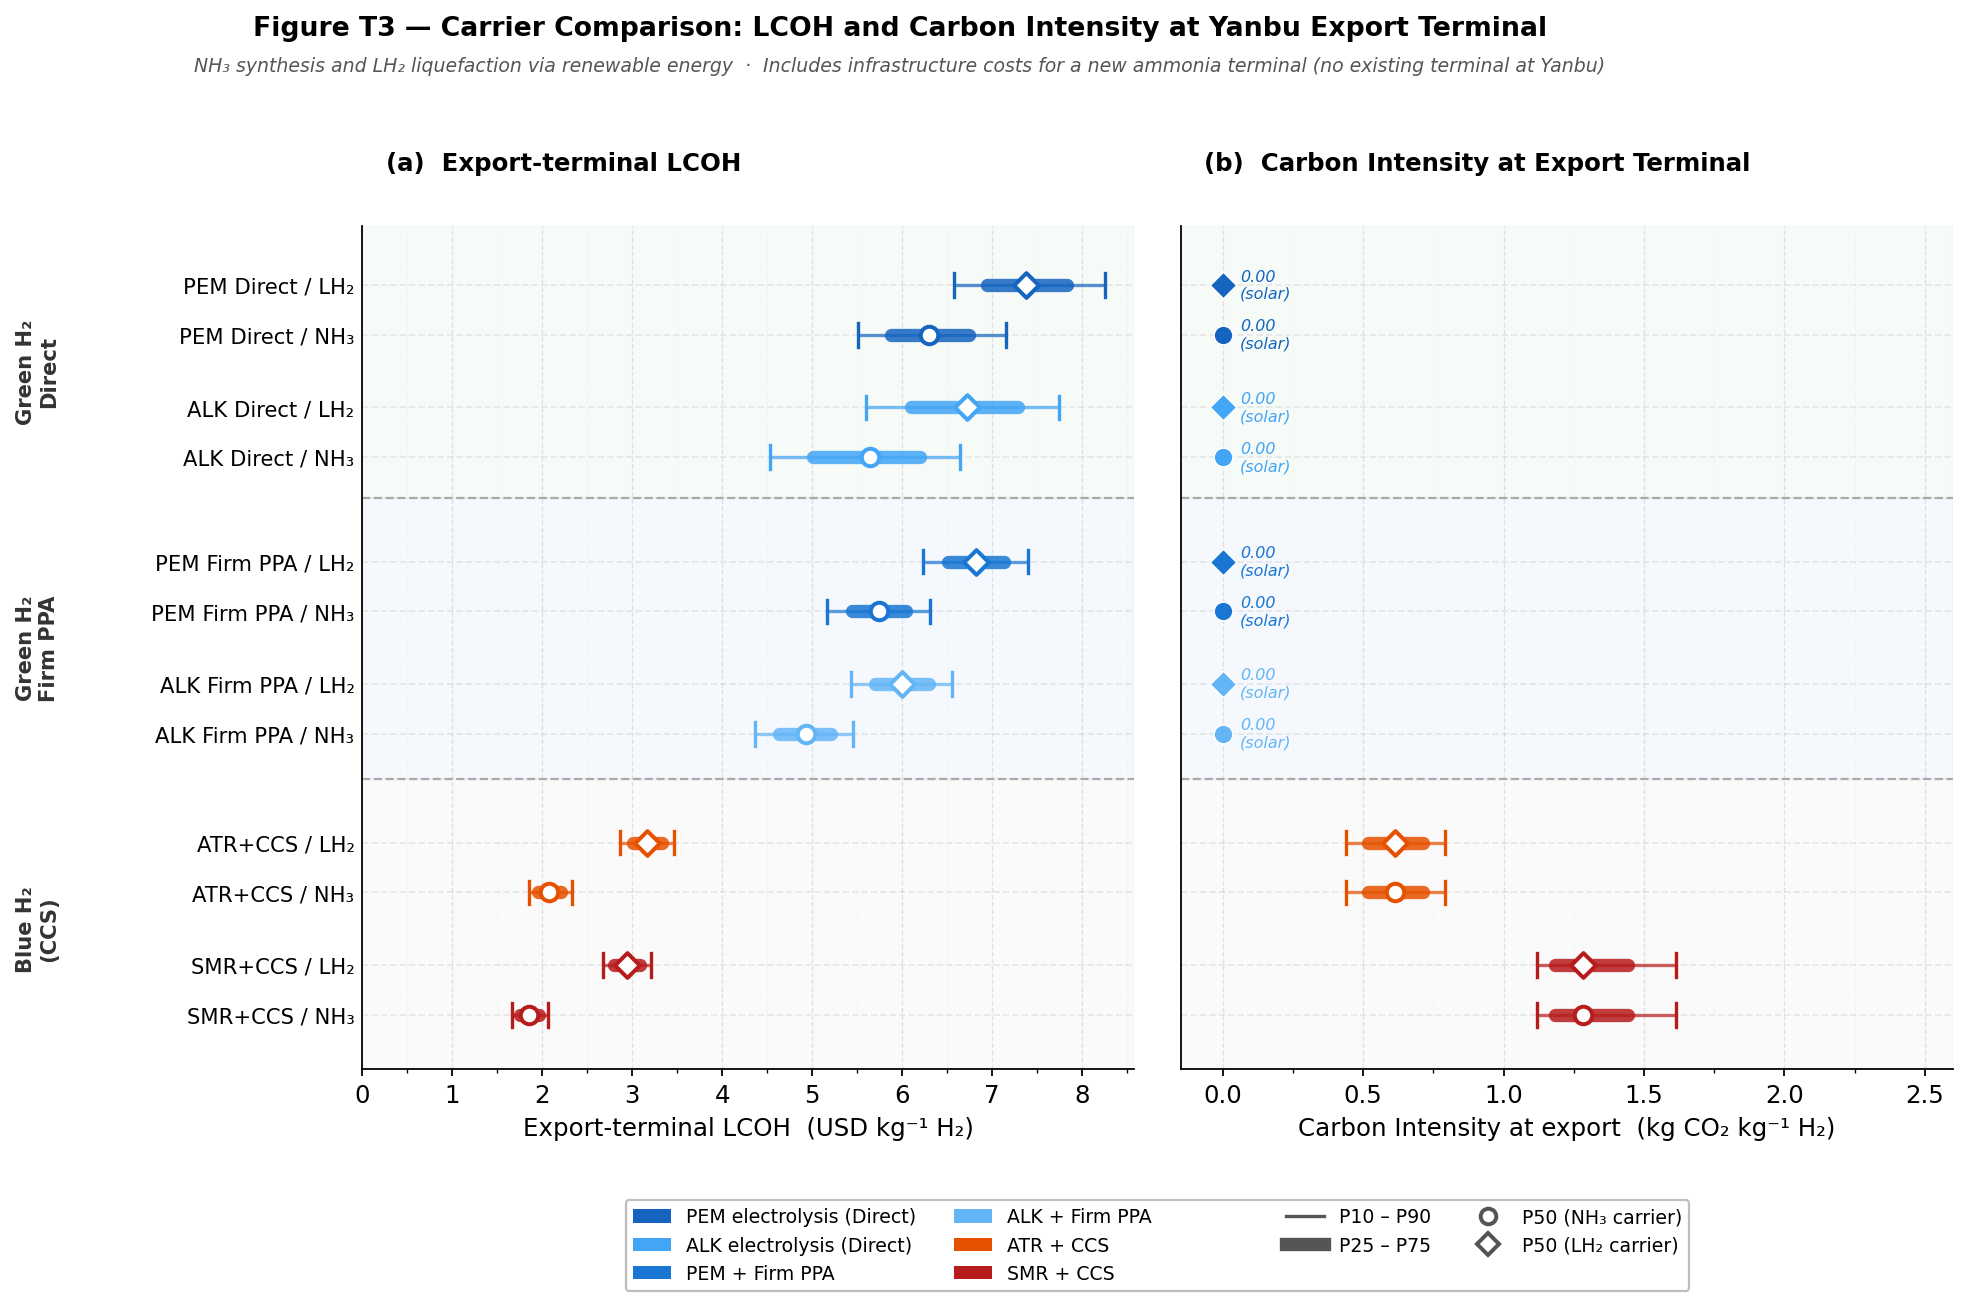

In [25]:
"""
Figure T3 — Carrier Comparison: LCOH and CI at Yanbu Export Terminal
- Costs = production LCOH + export-side conversion + Yanbu storage only
  (no shipping, no Rotterdam storage, no cracking at destination)
- NH₃ storage uses nh3_stor_cost_yanbu (greenfield; ~4× Jubail cost)
- CI = production CI only; HB synthesis and LH₂ liquefaction are solar-powered 
- No ETS/CBAM
"""
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpa
import numpy as np, os, runpy, sys

sys.path.insert(0, os.getcwd())
os.chdir(os.getcwd())
ctx = globals()
mc          = ctx['mc_results']
mi          = ctx['mc_inputs']
TC          = ctx['TC']
FIG_DIR     = ctx['FIG_DIR']
N_SAMPLES   = ctx['N_SAMPLES']
RANDOM_SEED = ctx['RANDOM_SEED']
PARAMS      = ctx['PARAMS']

# ── compute export-terminal add-on costs from mc_inputs ───────────────────
solar_lcoe  = mi['solar_lcoe'].values
hb_cost     = (mi['hb_capex_opex_per_kgh2'].values
               + mi['hb_elec_kwh_per_kgh2'].values * solar_lcoe)
nh3_stor    = mi['nh3_stor_cost_yanbu'].values

lh2_liq     = (mi['lh2_liq_capex_opex_per_kgh2'].values
               + mi['lh2_liq_kwh_per_kgh2'].values * solar_lcoe)
lh2_stor    = mi['lh2_stor_cost'].values

# ── LCOH at Yanbu export terminal ────────────────────────────────────────
nh3_exp_pem      = mc['lcoh_pem'].values      + hb_cost + nh3_stor
nh3_exp_alk      = mc['lcoh_alk'].values      + hb_cost + nh3_stor
nh3_exp_pem_fppa = mc['lcoh_pem_fppa'].values + hb_cost + nh3_stor
nh3_exp_alk_fppa = mc['lcoh_alk_fppa'].values + hb_cost + nh3_stor
nh3_exp_atr      = mc['lcoh_atr'].values      + hb_cost + nh3_stor
nh3_exp_smr      = mc['lcoh_smr'].values      + hb_cost + nh3_stor

lh2_exp_pem      = mc['lcoh_pem'].values      + lh2_liq + lh2_stor
lh2_exp_alk      = mc['lcoh_alk'].values      + lh2_liq + lh2_stor
lh2_exp_pem_fppa = mc['lcoh_pem_fppa'].values + lh2_liq + lh2_stor
lh2_exp_alk_fppa = mc['lcoh_alk_fppa'].values + lh2_liq + lh2_stor
lh2_exp_atr      = mc['lcoh_atr'].values      + lh2_liq + lh2_stor
lh2_exp_smr      = mc['lcoh_smr'].values      + lh2_liq + lh2_stor

# ── CI at Yanbu export terminal ───────────────────────────────────────────
ci_exp_atr = mc['ci_atr_prod'].values
ci_exp_smr = mc['ci_smr_prod'].values
ZERO_CI    = True

# ── row definitions (bottom-to-top: cheapest first) ───────────────────────
ROWS = [
    (0.0,  'SMR+CCS / NH₃',      nh3_exp_smr,      ci_exp_smr,     TC['smr'],  'NH₃'),
    (0.55, 'SMR+CCS / LH₂',      lh2_exp_smr,      ci_exp_smr,     TC['smr'],  'LH₂'),
    (1.35, 'ATR+CCS / NH₃',      nh3_exp_atr,      ci_exp_atr,     TC['atr'],  'NH₃'),
    (1.90, 'ATR+CCS / LH₂',      lh2_exp_atr,      ci_exp_atr,     TC['atr'],  'LH₂'),
    (3.10, 'ALK Firm PPA / NH₃', nh3_exp_alk_fppa, None,           '#64B5F6',  'NH₃'),
    (3.65, 'ALK Firm PPA / LH₂', lh2_exp_alk_fppa, None,           '#64B5F6',  'LH₂'),
    (4.45, 'PEM Firm PPA / NH₃', nh3_exp_pem_fppa, None,           '#1976D2',  'NH₃'),
    (5.00, 'PEM Firm PPA / LH₂', lh2_exp_pem_fppa, None,           '#1976D2',  'LH₂'),
    (6.15, 'ALK Direct / NH₃',   nh3_exp_alk,      None,           TC['alk'],  'NH₃'),
    (6.70, 'ALK Direct / LH₂',   lh2_exp_alk,      None,           TC['alk'],  'LH₂'),
    (7.50, 'PEM Direct / NH₃',   nh3_exp_pem,      None,           TC['pem'],  'NH₃'),
    (8.05, 'PEM Direct / LH₂',   lh2_exp_pem,      None,           TC['pem'],  'LH₂'),
]

Y_VALS  = [r[0] for r in ROWS]
Y_LABS  = [r[1] for r in ROWS]
Y_MIN, Y_MAX = -0.6, 8.7

# ── interval drawing helper ───────────────────────────────────────────────
def _ivl(ax, data, y, color, carrier):
    d = np.asarray(data, dtype=float); d = d[np.isfinite(d)]
    p10, p25, p50, p75, p90 = np.percentile(d, [10, 25, 50, 75, 90])
    ax.plot([p10, p90], [y, y], color=color, lw=1.5, alpha=0.70, zorder=2,
            solid_capstyle='round')
    for xv in (p10, p90):
        ax.plot([xv, xv], [y-0.13, y+0.13], color=color, lw=1.5, zorder=2)
    ax.plot([p25, p75], [y, y], color=color, lw=6, alpha=0.85, zorder=3,
            solid_capstyle='round')
    mkr = 'D' if carrier == 'LH₂' else 'o'
    ax.scatter([p50], [y], s=62, color='white', marker=mkr,
               edgecolors=color, linewidths=1.8, zorder=5)
    return p50

# ── figure layout ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14.0, 8.5), dpi=160)
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.06,
                        left=0.26, right=0.97, top=0.82, bottom=0.20)
al  = fig.add_subplot(gs[0])
ar  = fig.add_subplot(gs[1], sharey=al)

for ax in (al, ar):
    ax.set_yticks(Y_VALS)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.grid(axis='x', which='major', lw=0.6, alpha=0.38, color='#b8b8b8')
    ax.grid(axis='x', which='minor', lw=0.3, alpha=0.20, color='#d0d0d0')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

al.set_yticklabels(Y_LABS, fontsize=9.5)
ar.tick_params(labelleft=False)

for ax in (al, ar):
    ax.axhline(2.60, color='#aaaaaa', lw=1.0, ls='--', zorder=1)
    ax.axhline(5.70, color='#aaaaaa', lw=1.0, ls='--', zorder=1)

def _data_to_fig_y(ydata):
    frac = (ydata - Y_MIN) / (Y_MAX - Y_MIN)
    return 0.20 + frac * (0.82 - 0.20)

grp_kw = dict(transform=fig.transFigure, fontsize=9.5, fontweight='bold',
              color='#333333', rotation=90, ha='center', va='center',
              clip_on=False)
fig.text(0.115, _data_to_fig_y(0.95), 'Blue H₂\n(CCS)',        **grp_kw)
fig.text(0.115, _data_to_fig_y(4.05), 'Green H₂\nFirm PPA',    **grp_kw)
fig.text(0.115, _data_to_fig_y(7.10), 'Green H₂\nDirect',      **grp_kw)

for ax in (al, ar):
    ax.axhspan(-0.6,  2.60, alpha=0.04, color='#888888', zorder=0)
    ax.axhspan( 2.60, 5.70, alpha=0.04, color='#1976D2', zorder=0)
    ax.axhspan( 5.70, 8.70, alpha=0.04, color='#4CAF50', zorder=0)

for y, lbl, lcoh_arr, ci_arr, color, carrier in ROWS:
    _ivl(al, lcoh_arr, y, color, carrier)

al.set_xlabel('Export-terminal LCOH  (USD kg⁻¹ H₂)', fontsize=11)
al.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
al.set_xlim(left=0)

al.text(0.03, 1.06, '(a)  Export-terminal LCOH',
        transform=al.transAxes, fontsize=11, fontweight='bold',
        va='bottom', clip_on=False)

for y, lbl, lcoh_arr, ci_arr, color, carrier in ROWS:
    if ci_arr is not None:
        _ivl(ar, ci_arr, y, color, carrier)
    else:
        ar.scatter([0], [y], s=70, color=color, marker='D' if carrier == 'LH₂' else 'o',
                   edgecolors='white', linewidths=0.6, zorder=5)
        ar.text(0.06, y, '0.00\n(solar)', va='center', ha='left',
                fontsize=7.2, color=color, style='italic')

ar.set_xlabel('Carbon Intensity at export  (kg CO₂ kg⁻¹ H₂)', fontsize=11)
ar.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
ar.set_xlim(left=-0.15, right=2.6)

ar.text(0.03, 1.06, '(b)  Carbon Intensity at Export Terminal',
        transform=ar.transAxes, fontsize=11, fontweight='bold',
        va='bottom', clip_on=False)

# ── legend ────────────────────────────────────────────────────────────────
legend_h = [
    mpa.Patch(fc=TC['pem'],  ec='none', label='PEM electrolysis (Direct)'),
    mpa.Patch(fc=TC['alk'],  ec='none', label='ALK electrolysis (Direct)'),
    mpa.Patch(fc='#1976D2',  ec='none', label='PEM + Firm PPA'),
    mpa.Patch(fc='#64B5F6',  ec='none', label='ALK + Firm PPA'),
    mpa.Patch(fc=TC['atr'],  ec='none', label='ATR + CCS'),
    mpa.Patch(fc=TC['smr'],  ec='none', label='SMR + CCS'),
    plt.Line2D([0],[0], color='#555555', lw=1.5,             label='P10 – P90'),
    plt.Line2D([0],[0], color='#555555', lw=6,               label='P25 – P75'),
    plt.Line2D([0],[0], marker='o', color='white', ms=7,
               mec='#555555', mew=1.8, lw=0,                label='P50 (NH₃ carrier)'),
    plt.Line2D([0],[0], marker='D', color='white', ms=7,
               mec='#555555', mew=1.8, lw=0,                label='P50 (LH₂ carrier)'),
]
_e = mpa.Patch(fc='none', ec='none', label=' ')
all_h = legend_h[:6] + [_e, _e] + legend_h[6:]
fig.legend(handles=all_h, loc='lower center', ncol=5,
           fontsize=8.5, frameon=True, framealpha=0.95, edgecolor='#bbbbbb',
           bbox_to_anchor=(0.615, 0.03))

# ── title + description ───────────────────────────────────────────────────
fig.suptitle(
    'Figure T3 — Carrier Comparison: LCOH and Carbon Intensity at Yanbu Export Terminal',
    fontsize=12, y=0.975, fontweight='bold'
)
fig.text(
    0.50, 0.945,
    'NH₃ synthesis and LH₂ liquefaction via renewable energy  ·  '
    'Includes infrastructure costs for a new ammonia terminal (no existing terminal at Yanbu)',
    ha='center', va='top', fontsize=8.5, color='#555555', style='italic'
)

# ── save ──────────────────────────────────────────────────────────────────
out = os.path.join(FIG_DIR, 'fig_T3_carrier_comparison_yanbu.png')
plt.show()

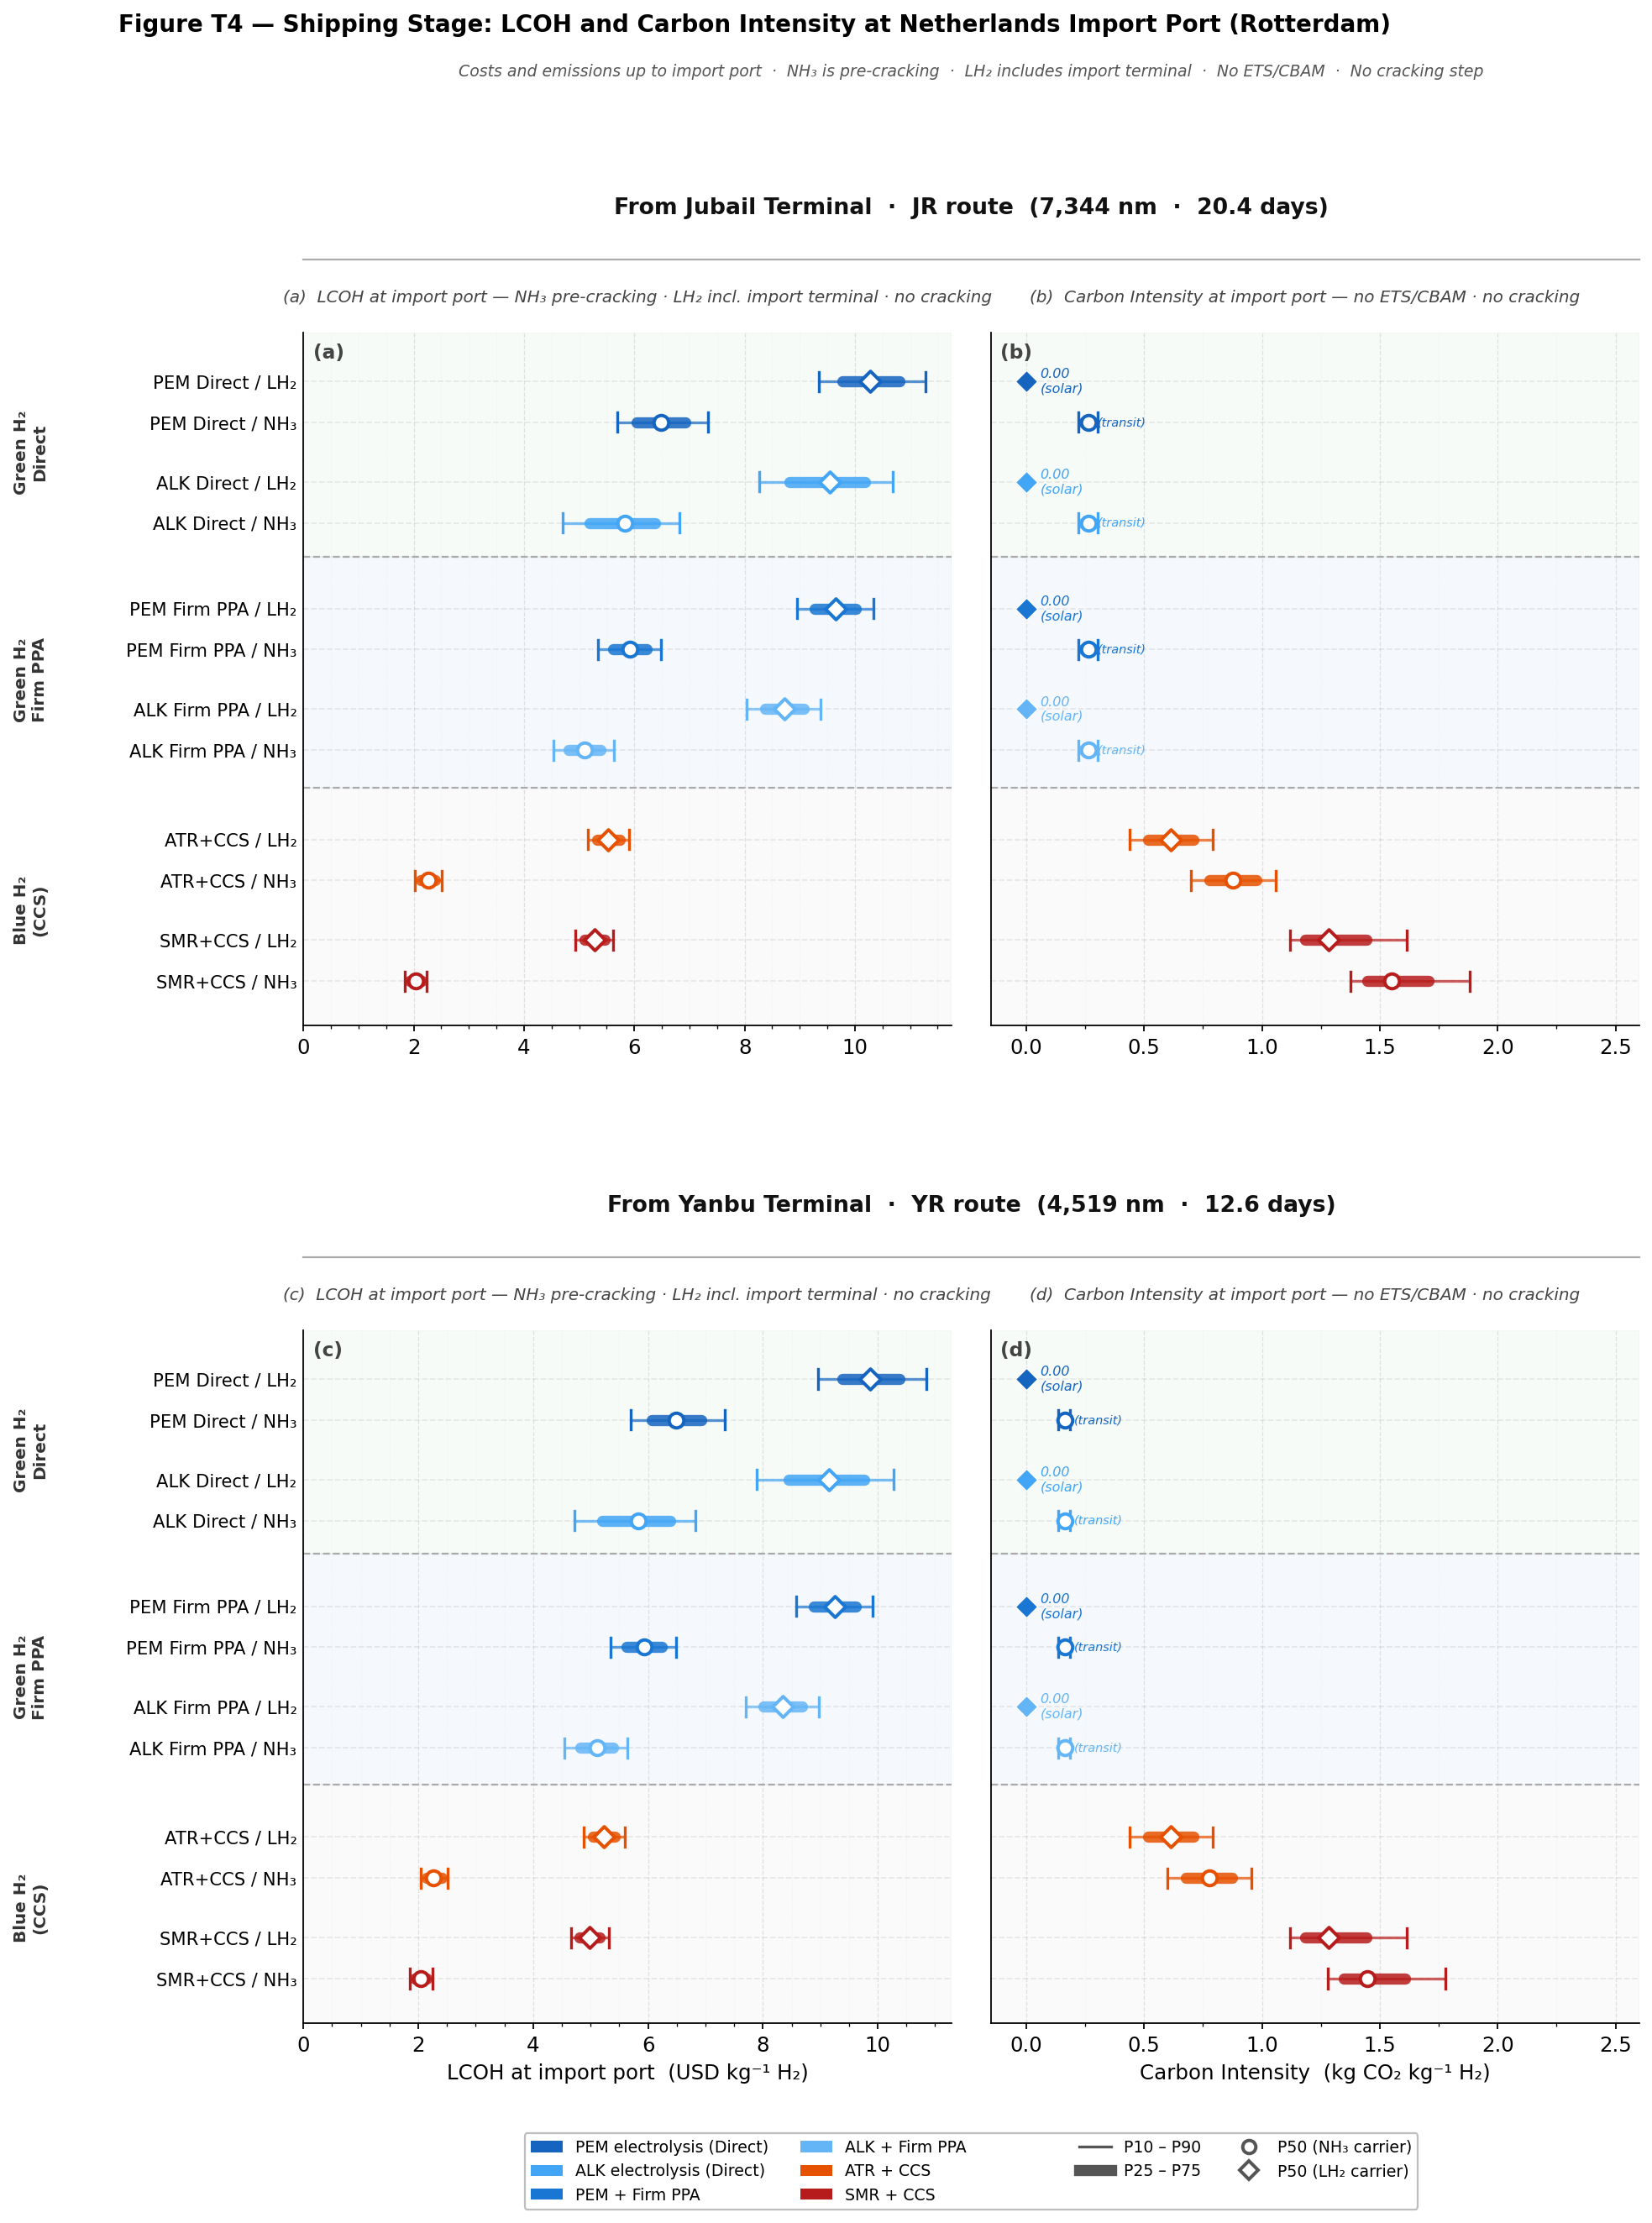

In [26]:
"""
Figure T4 — Shipping Stage: LCOH and Carbon Intensity at Netherlands Import Port (Rotterdam)
- 2×2 layout: top row = Jubail origin (JR, 7,344 nm); bottom row = Yanbu origin (YR, 4,519 nm)
- Left panels: LCOH = production + export terminal + shipping
               NH₃ cost is PRE-CRACKING (no cracking step included here)
               LH₂ cost includes import terminal (no cracking step)
- Right panels: CI = production CI + NH₃ shipping CI (ship fuel only)
               LH₂ CI = production CI (solar liquefaction → ship CI=0)
- No ETS/CBAM
"""
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpa
from matplotlib.lines import Line2D as _L2D
import numpy as np, os, runpy, sys

sys.path.insert(0, os.getcwd())
os.chdir(os.getcwd())
ctx = globals()
mc               = ctx['mc_results']
mi               = ctx['mc_inputs']
TC               = ctx['TC']
FIG_DIR          = ctx['FIG_DIR']
PARAMS           = ctx['PARAMS']
DIST_NM          = ctx['DIST_NM']
NM_TO_KM         = ctx['NM_TO_KM']
KG_NH3_PER_KG_H2 = ctx['KG_NH3_PER_KG_H2']
VOYAGE_DAYS      = ctx['VOYAGE_DAYS']
LH2_HEEL_FRAC    = ctx['LH2_HEEL_FRAC']
LH2_SCALE_PREMIUM = ctx['LH2_SCALE_PREMIUM']

# ── shared export-terminal building blocks ────────────────────────────────────
solar_lcoe = mi['solar_lcoe'].values
hb_cost    = (mi['hb_capex_opex_per_kgh2'].values
              + mi['hb_elec_kwh_per_kgh2'].values * solar_lcoe)
nh3_stor_j = mi['nh3_stor_cost_jubail'].values
nh3_stor_y = mi['nh3_stor_cost_yanbu'].values
lh2_liq    = (mi['lh2_liq_capex_opex_per_kgh2'].values
              + mi['lh2_liq_kwh_per_kgh2'].values * solar_lcoe)
lh2_stor   = mi['lh2_stor_cost'].values
lh2_import = mi['lh2_import_term_cost'].values

# ── NH₃ shipping cost per kgH₂ ───────────────────────────────────────────────
nh3_rate    = mi['nh3_ship_rate'].values
nh3_ship_jr = nh3_rate * DIST_NM['JR'] * NM_TO_KM / 1000 * KG_NH3_PER_KG_H2 / 1000
nh3_ship_yr = nh3_rate * DIST_NM['YR'] * NM_TO_KM / 1000 * KG_NH3_PER_KG_H2 / 1000

# ── NH₃ shipping CI (gCO₂e/tNH₃/km → kgCO₂/kgH₂) ───────────────────────────
nh3_ei         = mi['nh3_ship_ei'].values
ci_nh3_ship_jr = nh3_ei * DIST_NM['JR'] * NM_TO_KM * KG_NH3_PER_KG_H2 * 1e-6
ci_nh3_ship_yr = nh3_ei * DIST_NM['YR'] * NM_TO_KM * KG_NH3_PER_KG_H2 * 1e-6

# ── LH₂ delivery fraction  ───────────────────────────────────────────────────
bog_rate = mi['lh2_bog_rate'].values
load_bog = mi['lh2_load_bog_frac'].values

def _dfrac(voyage_days):
    return (1 - load_bog) * (1 - bog_rate) ** voyage_days

dfrac_jr = _dfrac(VOYAGE_DAYS['JR'])
dfrac_yr = _dfrac(VOYAGE_DAYS['YR'])

# ── LH₂ at import port ───────────────────────────────────────────────────────
lh2_ship_jr = mi['lh2_ship_jr'].values
lh2_ship_yr = mi['lh2_ship_yr'].values

def _lh2_port(lcoh_prod, dfrac, lh2_ship):
    """LH₂ delivered to import port — no cracking step."""
    return (lcoh_prod / dfrac
            + lh2_liq
            + lh2_ship / (1.0 - LH2_HEEL_FRAC)
            + lh2_stor + lh2_import + LH2_SCALE_PREMIUM)

# ── NH₃ at import port (pre-cracking) ────────────────────────────────────────
def _nh3_port(lcoh_prod, nh3_stor, nh3_ship):
    return lcoh_prod + hb_cost + nh3_stor + nh3_ship

# ── blue CI arrays ────────────────────────────────────────────────────────────
ci_atr = mc['ci_atr_prod'].values
ci_smr = mc['ci_smr_prod'].values

lcoh_pem = mc['lcoh_pem'].values;     lcoh_alk = mc['lcoh_alk'].values
lcoh_pf  = mc['lcoh_pem_fppa'].values; lcoh_af  = mc['lcoh_alk_fppa'].values
lcoh_atr = mc['lcoh_atr'].values;     lcoh_smr = mc['lcoh_smr'].values

# ── ROWS: (y, label, lcoh_jr, ci_jr, lcoh_yr, ci_yr, color, carrier) ─────────
ROWS = [
    (0.0,  'SMR+CCS / NH₃',
     _nh3_port(lcoh_smr, nh3_stor_j, nh3_ship_jr), ci_smr + ci_nh3_ship_jr,
     _nh3_port(lcoh_smr, nh3_stor_y, nh3_ship_yr), ci_smr + ci_nh3_ship_yr,
     TC['smr'], 'NH₃'),
    (0.55, 'SMR+CCS / LH₂',
     _lh2_port(lcoh_smr, dfrac_jr, lh2_ship_jr), ci_smr,
     _lh2_port(lcoh_smr, dfrac_yr, lh2_ship_yr), ci_smr,
     TC['smr'], 'LH₂'),
    (1.35, 'ATR+CCS / NH₃',
     _nh3_port(lcoh_atr, nh3_stor_j, nh3_ship_jr), ci_atr + ci_nh3_ship_jr,
     _nh3_port(lcoh_atr, nh3_stor_y, nh3_ship_yr), ci_atr + ci_nh3_ship_yr,
     TC['atr'], 'NH₃'),
    (1.90, 'ATR+CCS / LH₂',
     _lh2_port(lcoh_atr, dfrac_jr, lh2_ship_jr), ci_atr,
     _lh2_port(lcoh_atr, dfrac_yr, lh2_ship_yr), ci_atr,
     TC['atr'], 'LH₂'),
    (3.10, 'ALK Firm PPA / NH₃',
     _nh3_port(lcoh_af, nh3_stor_j, nh3_ship_jr), ci_nh3_ship_jr,
     _nh3_port(lcoh_af, nh3_stor_y, nh3_ship_yr), ci_nh3_ship_yr,
     '#64B5F6', 'NH₃'),
    (3.65, 'ALK Firm PPA / LH₂',
     mc['alk_fppa_lh2_jr'].values, None,
     mc['alk_fppa_lh2_yr'].values, None,
     '#64B5F6', 'LH₂'),
    (4.45, 'PEM Firm PPA / NH₃',
     _nh3_port(lcoh_pf, nh3_stor_j, nh3_ship_jr), ci_nh3_ship_jr,
     _nh3_port(lcoh_pf, nh3_stor_y, nh3_ship_yr), ci_nh3_ship_yr,
     '#1976D2', 'NH₃'),
    (5.00, 'PEM Firm PPA / LH₂',
     mc['pem_fppa_lh2_jr'].values, None,
     mc['pem_fppa_lh2_yr'].values, None,
     '#1976D2', 'LH₂'),
    (6.15, 'ALK Direct / NH₃',
     _nh3_port(lcoh_alk, nh3_stor_j, nh3_ship_jr), ci_nh3_ship_jr,
     _nh3_port(lcoh_alk, nh3_stor_y, nh3_ship_yr), ci_nh3_ship_yr,
     TC['alk'], 'NH₃'),
    (6.70, 'ALK Direct / LH₂',
     mc['alk_lh2_jr'].values, None,
     mc['alk_lh2_yr'].values, None,
     TC['alk'], 'LH₂'),
    (7.50, 'PEM Direct / NH₃',
     _nh3_port(lcoh_pem, nh3_stor_j, nh3_ship_jr), ci_nh3_ship_jr,
     _nh3_port(lcoh_pem, nh3_stor_y, nh3_ship_yr), ci_nh3_ship_yr,
     TC['pem'], 'NH₃'),
    (8.05, 'PEM Direct / LH₂',
     mc['pem_lh2_jr'].values, None,
     mc['pem_lh2_yr'].values, None,
     TC['pem'], 'LH₂'),
]

Y_VALS = [r[0] for r in ROWS]
Y_LABS = [r[1] for r in ROWS]
Y_MIN, Y_MAX = -0.6, 8.7

# ── interval drawing helper ───────────────────────────────────────────────────
def _ivl(ax, data, y, color, carrier):
    d = np.asarray(data, dtype=float); d = d[np.isfinite(d)]
    p10, p25, p50, p75, p90 = np.percentile(d, [10, 25, 50, 75, 90])
    ax.plot([p10, p90], [y, y], color=color, lw=1.5, alpha=0.70, zorder=2,
            solid_capstyle='round')
    for xv in (p10, p90):
        ax.plot([xv, xv], [y - 0.13, y + 0.13], color=color, lw=1.5, zorder=2)
    ax.plot([p25, p75], [y, y], color=color, lw=6, alpha=0.85, zorder=3,
            solid_capstyle='round')
    mkr = 'D' if carrier == 'LH₂' else 'o'
    ax.scatter([p50], [y], s=62, color='white', marker=mkr,
               edgecolors=color, linewidths=1.8, zorder=5)
    return p50

# ── figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14.0, 17.0), dpi=160)
gs  = gridspec.GridSpec(2, 2, figure=fig, wspace=0.06, hspace=0.44,
                        left=0.26, right=0.97, top=0.84, bottom=0.10)

ax_jl = fig.add_subplot(gs[0, 0])
ax_jc = fig.add_subplot(gs[0, 1], sharey=ax_jl)
ax_yl = fig.add_subplot(gs[1, 0], sharey=ax_jl)
ax_yc = fig.add_subplot(gs[1, 1], sharey=ax_jl)

for ax in (ax_jl, ax_jc, ax_yl, ax_yc):
    ax.set_yticks(Y_VALS)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.grid(axis='x', which='major', lw=0.6, alpha=0.38, color='#b8b8b8')
    ax.grid(axis='x', which='minor', lw=0.3, alpha=0.20, color='#d0d0d0')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

ax_jl.set_yticklabels(Y_LABS, fontsize=9.5)
ax_yl.set_yticklabels(Y_LABS, fontsize=9.5)
ax_jc.tick_params(labelleft=False)
ax_yc.tick_params(labelleft=False)

for ax in (ax_jl, ax_jc, ax_yl, ax_yc):
    ax.axhline(2.60, color='#aaaaaa', lw=1.0, ls='--', zorder=1)
    ax.axhline(5.70, color='#aaaaaa', lw=1.0, ls='--', zorder=1)
    ax.axhspan(-0.6,  2.60, alpha=0.04, color='#888888', zorder=0)
    ax.axhspan( 2.60, 5.70, alpha=0.04, color='#1976D2', zorder=0)
    ax.axhspan( 5.70, 8.70, alpha=0.04, color='#4CAF50', zorder=0)

# ── helpers: figure-space coordinates ────────────────────────────────────────
def _ax_to_fig_y(ax, ydata):
    """Convert data-y coordinate to figure-y (via axis transform)."""
    pt = ax.transData.transform((0, ydata))
    return fig.transFigure.inverted().transform(pt)[1]

def _ax_top_fig(ax):
    """Top of axes box in figure coordinates."""
    pt = ax.transAxes.transform((0.5, 1.0))
    return fig.transFigure.inverted().transform(pt)[1]

# ── group labels (left margin) ────────────────────────────────────────────────
grp_kw = dict(transform=fig.transFigure, fontsize=9.0, fontweight='bold',
              color='#333333', rotation=90, ha='center', va='center', clip_on=False)
for ax_left in (ax_jl, ax_yl):
    fig.text(0.115, _ax_to_fig_y(ax_left, 0.95),  'Blue H₂\n(CCS)',      **grp_kw)
    fig.text(0.115, _ax_to_fig_y(ax_left, 4.05),  'Green H₂\nFirm PPA', **grp_kw)
    fig.text(0.115, _ax_to_fig_y(ax_left, 7.10),  'Green H₂\nDirect',   **grp_kw)

# ── panel letter labels (inside axes, top-left corner) ───────────────────────
for ax, lbl in [(ax_jl, '(a)'), (ax_jc, '(b)'), (ax_yl, '(c)'), (ax_yc, '(d)')]:
    ax.text(0.015, 0.985, lbl, transform=ax.transAxes,
            fontsize=10.5, fontweight='bold', va='top', ha='left',
            color='#444444', clip_on=False)

# ── row headers: title ABOVE rule · panel descriptions BELOW rule ─────────────
#   ─────────────────────────────────────     ← horizontal rule
cx   = (0.26 + 0.97) / 2
lc_x = (0.26 + cx)   / 2
rc_x = (cx   + 0.97) / 2

jr_top = _ax_top_fig(ax_jl)
yr_top = _ax_top_fig(ax_yl)

OFFSET_TITLE = 0.050
OFFSET_RULE  = 0.032
OFFSET_DESC  = 0.012

row_title_kw = dict(transform=fig.transFigure, fontsize=12, fontweight='bold',
                    color='#111111', ha='center', va='bottom', clip_on=False)
desc_kw = dict(transform=fig.transFigure, fontsize=9.0, color='#444444',
               va='bottom', style='italic', clip_on=False)

for base, row_lbl, desc_l, desc_r in [
    (jr_top,
     f'From Jubail Terminal  ·  JR route  ({DIST_NM["JR"]:,} nm  ·  {VOYAGE_DAYS["JR"]:.1f} days)',
     '(a)  LCOH at import port — NH₃ pre-cracking · LH₂ incl. import terminal · no cracking',
     '(b)  Carbon Intensity at import port — no ETS/CBAM · no cracking'),
    (yr_top,
     f'From Yanbu Terminal  ·  YR route  ({DIST_NM["YR"]:,} nm  ·  {VOYAGE_DAYS["YR"]:.1f} days)',
     '(c)  LCOH at import port — NH₃ pre-cracking · LH₂ incl. import terminal · no cracking',
     '(d)  Carbon Intensity at import port — no ETS/CBAM · no cracking'),
]:
    fig.text(cx, base + OFFSET_TITLE, row_lbl, **row_title_kw)
    fig.add_artist(_L2D([0.26, 0.97], [base + OFFSET_RULE, base + OFFSET_RULE],
                   transform=fig.transFigure, color='#aaaaaa', lw=1.0, clip_on=False))
    fig.text(lc_x, base + OFFSET_DESC, desc_l, ha='center', **desc_kw)
    fig.text(rc_x, base + OFFSET_DESC, desc_r, ha='center', **desc_kw)

DATA_IDX = [(ax_jl, ax_jc, 2, 3), (ax_yl, ax_yc, 4, 5)]

for ax_l, ax_c, li, ci_i in DATA_IDX:
    for row in ROWS:
        y, lbl, *vals, color, carrier = row
        _ivl(ax_l, vals[li - 2], y, color, carrier)
    ax_l.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax_l.set_xlim(left=0)

    for row in ROWS:
        y, lbl, *vals, color, carrier = row
        ci_arr = vals[ci_i - 2]
        if ci_arr is None:
            ax_c.scatter([0], [y], s=70, color=color, marker='D',
                         edgecolors='white', linewidths=0.6, zorder=5)
            ax_c.text(0.06, y, '0.00\n(solar)', va='center', ha='left',
                      fontsize=7.2, color=color, style='italic')
        else:
            p50 = _ivl(ax_c, ci_arr, y, color, carrier)
            if carrier == 'NH₃' and np.percentile(ci_arr, 50) < 0.60:
                ax_c.text(p50 + 0.04, y, '(transit)', va='center', ha='left',
                          fontsize=6.5, color=color, style='italic')
    ax_c.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
    ax_c.set_xlim(left=-0.15, right=2.6)

# ── x-axis labels (bottom row only) ──────────────────────────────────────────
ax_yl.set_xlabel('LCOH at import port  (USD kg⁻¹ H₂)', fontsize=11)
ax_yc.set_xlabel('Carbon Intensity  (kg CO₂ kg⁻¹ H₂)', fontsize=11)

# ── legend ────────────────────────────────────────────────────────────────────
legend_h = [
    mpa.Patch(fc=TC['pem'],  ec='none', label='PEM electrolysis (Direct)'),
    mpa.Patch(fc=TC['alk'],  ec='none', label='ALK electrolysis (Direct)'),
    mpa.Patch(fc='#1976D2',  ec='none', label='PEM + Firm PPA'),
    mpa.Patch(fc='#64B5F6',  ec='none', label='ALK + Firm PPA'),
    mpa.Patch(fc=TC['atr'],  ec='none', label='ATR + CCS'),
    mpa.Patch(fc=TC['smr'],  ec='none', label='SMR + CCS'),
    plt.Line2D([0],[0], color='#555555', lw=1.5,              label='P10 – P90'),
    plt.Line2D([0],[0], color='#555555', lw=6,                label='P25 – P75'),
    plt.Line2D([0],[0], marker='o', color='white', ms=7,
               mec='#555555', mew=1.8, lw=0,                 label='P50 (NH₃ carrier)'),
    plt.Line2D([0],[0], marker='D', color='white', ms=7,
               mec='#555555', mew=1.8, lw=0,                 label='P50 (LH₂ carrier)'),
]
_e = mpa.Patch(fc='none', ec='none', label=' ')
all_h = legend_h[:6] + [_e, _e] + legend_h[6:]
fig.legend(handles=all_h, loc='lower center', ncol=5,
           fontsize=8.5, frameon=True, framealpha=0.95, edgecolor='#bbbbbb',
           bbox_to_anchor=(0.615, 0.015))

# ── main title + description ──────────────────────────────────────────────────
fig.suptitle(
    'Figure T4 — Shipping Stage: LCOH and Carbon Intensity at Netherlands Import Port (Rotterdam)',
    fontsize=12.5, y=0.980, fontweight='bold'
)
fig.text(
    0.615, 0.958,
    'Costs and emissions up to import port  ·  NH₃ is pre-cracking  ·  '
    'LH₂ includes import terminal  ·  No ETS/CBAM  ·  No cracking step',
    ha='center', va='top', fontsize=8.5, color='#555555', style='italic'
)

# ── save ──────────────────────────────────────────────────────────────────────
out = os.path.join(FIG_DIR, 'fig_T4_shipping_netherlands.png')
plt.show()

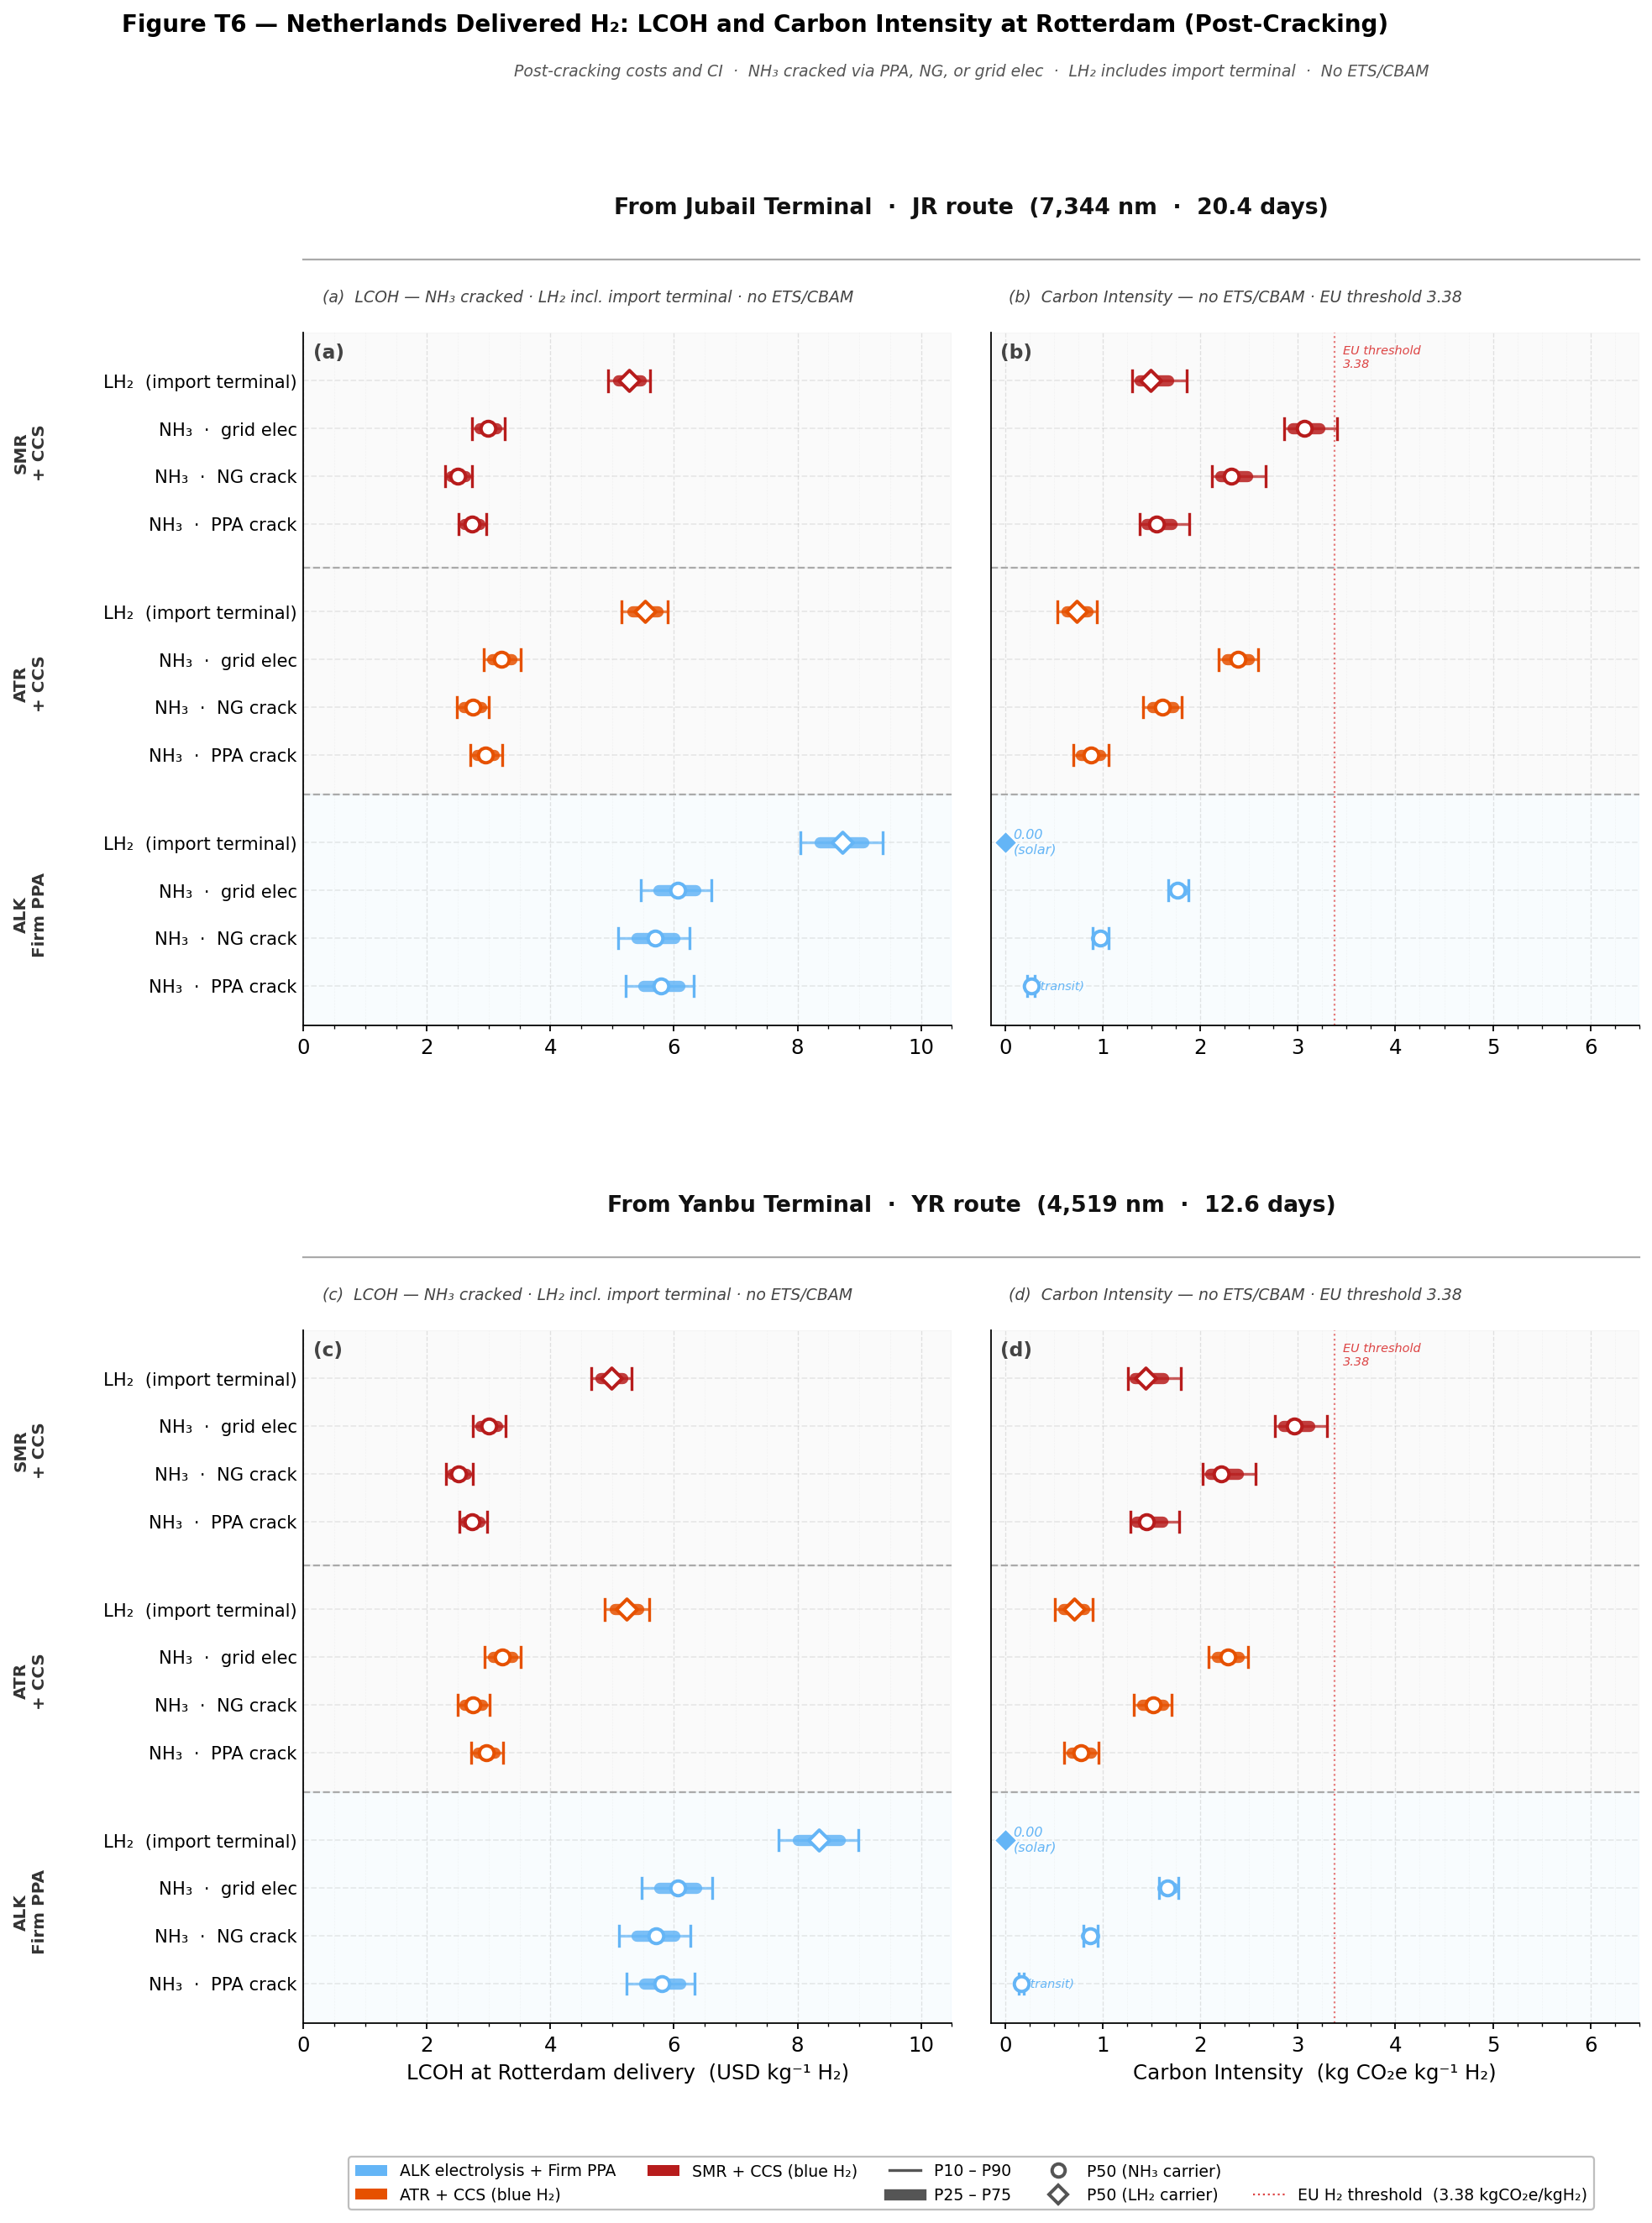

In [27]:
"""
Figure T6 — Netherlands Delivered H₂: LCOH and Carbon Intensity at Rotterdam (Post-Cracking)
- Pathways: ALK Firm PPA, ATR+CCS, SMR+CCS
- Carriers: cracked NH₃ (3 cracking methods: PPA elec, NG, grid elec) + LH₂
- 2×2 layout: top row = Jubail/JR (7,344 nm); bottom row = Yanbu/YR (4,519 nm)
- Left panels: LCOH post-cracking (NH₃) or incl. import terminal (LH₂)
- Right panels: Carbon Intensity — no ETS/CBAM
- Cracking CI note:
    'PPA crack'  uses ci_crack_g_rott  (renewable PPA elec, P50≈0.111 kgCO₂/kgH₂)
    'NG crack'   uses ci_crack_ng      (natural gas,        P50≈0.706)
    'grid elec'  uses ci_crack_b_rott  (EU grid mix,        P50≈1.502)
  Grid-cracking rows = pre-computed PPA rows + Δcost / – green CI + brown CI
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpa
from matplotlib.lines import Line2D as _L2D
import numpy as np, os, runpy, sys

ctx = globals()
mc                = ctx['mc_results']
mi                = ctx['mc_inputs']
TC                = ctx['TC']
FIG_DIR           = ctx['FIG_DIR']
DIST_NM           = ctx['DIST_NM']
VOYAGE_DAYS       = ctx['VOYAGE_DAYS']
LH2_HEEL_FRAC     = ctx['LH2_HEEL_FRAC']
LH2_SCALE_PREMIUM = ctx['LH2_SCALE_PREMIUM']

# ── Blue LH₂ costs now drawn from run_monte_carlo() formal columns ──────────

# ── grid cracking vs PPA cracking cost delta ($/kgH₂) ────────────────────────
crack_kwh  = mi['crack_elec_kwh_per_kgh2'].values
grid_delta = crack_kwh * (mi['rott_grid_elec_price'].values
                          - mi['rott_elec_price'].values)

# ── cracking CI stochastic arrays ────────────────────────────────────────────
ci_crack_g = mc['ci_crack_g_rott'].values
ci_crack_b = mc['ci_crack_b_rott'].values

# ── production CI arrays ──────────────────────────────────────────────────────
ci_atr = mc['ci_atr_prod'].values
ci_smr = mc['ci_smr_prod'].values

# ── colours ───────────────────────────────────────────────────────────────────
AFPPA_COL = '#64B5F6'
ATR_COL   = TC['atr']
SMR_COL   = TC['smr']

# ── ROWS: (y, label, lcoh_jr, ci_jr, lcoh_yr, ci_yr, color, carrier) ─────────

ROWS = [
    (0.00, 'NH₃  ·  PPA crack',
     mc['alk_fppa_nh3_jr'].values,
     mc['ci_alk_fppa_nh3_jr'].values,
     mc['alk_fppa_nh3_yr'].values,
     mc['ci_alk_fppa_nh3_yr'].values,
     AFPPA_COL, 'NH₃'),

    (0.60, 'NH₃  ·  NG crack',
     mc['alk_fppa_nh3_ng_jr'].values,
     mc['ci_alk_fppa_nh3_ng_jr'].values,
     mc['alk_fppa_nh3_ng_yr'].values,
     mc['ci_alk_fppa_nh3_ng_yr'].values,
     AFPPA_COL, 'NH₃'),

    (1.20, 'NH₃  ·  grid elec',
     mc['alk_fppa_nh3_jr'].values + grid_delta,
     mc['ci_alk_fppa_nh3_jr'].values - ci_crack_g + ci_crack_b,
     mc['alk_fppa_nh3_yr'].values + grid_delta,
     mc['ci_alk_fppa_nh3_yr'].values - ci_crack_g + ci_crack_b,
     AFPPA_COL, 'NH₃'),

    (1.80, 'LH₂  (import terminal)',
     mc['alk_fppa_lh2_jr'].values, None,
     mc['alk_fppa_lh2_yr'].values, None,
     AFPPA_COL, 'LH₂'),

    (2.90, 'NH₃  ·  PPA crack',
     mc['atr_nh3_jr'].values - grid_delta,
     mc['ci_atr_nh3_jr'].values - ci_crack_b + ci_crack_g,
     mc['atr_nh3_yr'].values - grid_delta,
     mc['ci_atr_nh3_yr'].values - ci_crack_b + ci_crack_g,
     ATR_COL, 'NH₃'),

    (3.50, 'NH₃  ·  NG crack',
     mc['atr_nh3_ng_jr'].values,
     mc['ci_atr_nh3_ng_jr'].values,
     mc['atr_nh3_ng_yr'].values,
     mc['ci_atr_nh3_ng_yr'].values,
     ATR_COL, 'NH₃'),

    (4.10, 'NH₃  ·  grid elec',
     mc['atr_nh3_jr'].values,
     mc['ci_atr_nh3_jr'].values,
     mc['atr_nh3_yr'].values,
     mc['ci_atr_nh3_yr'].values,
     ATR_COL, 'NH₃'),

    (4.70, 'LH₂  (import terminal)',
     mc['atr_lh2_jr'].values, mc['ci_atr_lh2_jr'].values,
     mc['atr_lh2_yr'].values, mc['ci_atr_lh2_yr'].values,
     ATR_COL, 'LH₂'),

    (5.80, 'NH₃  ·  PPA crack',
     mc['smr_nh3_jr'].values - grid_delta,
     mc['ci_smr_nh3_jr'].values - ci_crack_b + ci_crack_g,
     mc['smr_nh3_yr'].values - grid_delta,
     mc['ci_smr_nh3_yr'].values - ci_crack_b + ci_crack_g,
     SMR_COL, 'NH₃'),

    (6.40, 'NH₃  ·  NG crack',
     mc['smr_nh3_ng_jr'].values,
     mc['ci_smr_nh3_ng_jr'].values,
     mc['smr_nh3_ng_yr'].values,
     mc['ci_smr_nh3_ng_yr'].values,
     SMR_COL, 'NH₃'),

    (7.00, 'NH₃  ·  grid elec',
     mc['smr_nh3_jr'].values,
     mc['ci_smr_nh3_jr'].values,
     mc['smr_nh3_yr'].values,
     mc['ci_smr_nh3_yr'].values,
     SMR_COL, 'NH₃'),

    (7.60, 'LH₂  (import terminal)',
     mc['smr_lh2_jr'].values, mc['ci_smr_lh2_jr'].values,
     mc['smr_lh2_yr'].values, mc['ci_smr_lh2_yr'].values,
     SMR_COL, 'LH₂'),
]

Y_VALS = [r[0] for r in ROWS]
Y_LABS = [r[1] for r in ROWS]
Y_MIN, Y_MAX = -0.5, 8.2

# ── interval drawing helper ───────────────────────────────────────────────────
def _ivl(ax, data, y, color, carrier):
    """Draw P10–P90 thin bar, P25–P75 thick bar, P50 marker."""
    d = np.asarray(data, dtype=float)
    d = d[np.isfinite(d)]
    p10, p25, p50, p75, p90 = np.percentile(d, [10, 25, 50, 75, 90])
    ax.plot([p10, p90], [y, y], color=color, lw=1.5, alpha=0.70, zorder=2,
            solid_capstyle='round')
    for xv in (p10, p90):
        ax.plot([xv, xv], [y - 0.13, y + 0.13], color=color, lw=1.5, zorder=2)
    ax.plot([p25, p75], [y, y], color=color, lw=6, alpha=0.85, zorder=3,
            solid_capstyle='round')
    mkr = 'D' if carrier == 'LH₂' else 'o'
    ax.scatter([p50], [y], s=62, color='white', marker=mkr,
               edgecolors=color, linewidths=1.8, zorder=5)
    return p50

# ── figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14.0, 17.0), dpi=160)
gs  = gridspec.GridSpec(2, 2, figure=fig, wspace=0.06, hspace=0.44,
                        left=0.26, right=0.97, top=0.84, bottom=0.10)

ax_jl = fig.add_subplot(gs[0, 0])
ax_jc = fig.add_subplot(gs[0, 1], sharey=ax_jl)
ax_yl = fig.add_subplot(gs[1, 0], sharey=ax_jl)
ax_yc = fig.add_subplot(gs[1, 1], sharey=ax_jl)

for ax in (ax_jl, ax_jc, ax_yl, ax_yc):
    ax.set_yticks(Y_VALS)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.grid(axis='x', which='major', lw=0.6, alpha=0.38, color='#b8b8b8')
    ax.grid(axis='x', which='minor', lw=0.3, alpha=0.20, color='#d0d0d0')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

ax_jl.set_yticklabels(Y_LABS, fontsize=9.5)
ax_yl.set_yticklabels(Y_LABS, fontsize=9.5)
ax_jc.tick_params(labelleft=False)
ax_yc.tick_params(labelleft=False)

# ── group separator lines + background bands ──────────────────────────────────
SEP1 = 2.40
SEP2 = 5.25

for ax in (ax_jl, ax_jc, ax_yl, ax_yc):
    ax.axhline(SEP1, color='#aaaaaa', lw=1.0, ls='--', zorder=1)
    ax.axhline(SEP2, color='#aaaaaa', lw=1.0, ls='--', zorder=1)
    ax.axhspan(Y_MIN, SEP1, alpha=0.04, color='#64B5F6', zorder=0)
    ax.axhspan(SEP1, SEP2, alpha=0.04, color='#888888', zorder=0)
    ax.axhspan(SEP2, Y_MAX, alpha=0.04, color='#888888', zorder=0)

# ── helpers: figure-space coordinate conversion ──────────────────────────────
def _ax_to_fig_y(ax, ydata):
    pt = ax.transData.transform((0, ydata))
    return fig.transFigure.inverted().transform(pt)[1]

def _ax_top_fig(ax):
    pt = ax.transAxes.transform((0.5, 1.0))
    return fig.transFigure.inverted().transform(pt)[1]

# ── group labels (rotated text in left margin) ────────────────────────────────
grp_kw = dict(transform=fig.transFigure, fontsize=9.0, fontweight='bold',
              color='#333333', rotation=90, ha='center', va='center', clip_on=False)

for ax_left in (ax_jl, ax_yl):
    fig.text(0.115, _ax_to_fig_y(ax_left, 0.90),  'ALK\nFirm PPA', **grp_kw)
    fig.text(0.115, _ax_to_fig_y(ax_left, 3.80),  'ATR\n+ CCS',    **grp_kw)
    fig.text(0.115, _ax_to_fig_y(ax_left, 6.70),  'SMR\n+ CCS',    **grp_kw)

# ── panel letter labels (inside axes, top-left corner) ───────────────────────
for ax, lbl in [(ax_jl, '(a)'), (ax_jc, '(b)'), (ax_yl, '(c)'), (ax_yc, '(d)')]:
    ax.text(0.015, 0.985, lbl, transform=ax.transAxes,
            fontsize=10.5, fontweight='bold', va='top', ha='left',
            color='#444444', clip_on=False)

# ── row headers: title ABOVE rule · panel descriptions BELOW rule ─────────────
cx   = (0.26 + 0.97) / 2
lc_x = 0.27
rc_x = 0.635

jr_top = _ax_top_fig(ax_jl)
yr_top = _ax_top_fig(ax_yl)

OFFSET_TITLE = 0.050
OFFSET_RULE  = 0.032
OFFSET_DESC  = 0.012

row_title_kw = dict(transform=fig.transFigure, fontsize=12, fontweight='bold',
                    color='#111111', ha='center', va='bottom', clip_on=False)
desc_kw = dict(transform=fig.transFigure, fontsize=8.5, color='#444444',
               va='bottom', style='italic', clip_on=False)

for base, row_lbl, desc_l, desc_r in [
    (jr_top,
     f'From Jubail Terminal  ·  JR route  ({DIST_NM["JR"]:,} nm  ·  {VOYAGE_DAYS["JR"]:.1f} days)',
     '(a)  LCOH — NH₃ cracked · LH₂ incl. import terminal · no ETS/CBAM',
     '(b)  Carbon Intensity — no ETS/CBAM · EU threshold 3.38'),
    (yr_top,
     f'From Yanbu Terminal  ·  YR route  ({DIST_NM["YR"]:,} nm  ·  {VOYAGE_DAYS["YR"]:.1f} days)',
     '(c)  LCOH — NH₃ cracked · LH₂ incl. import terminal · no ETS/CBAM',
     '(d)  Carbon Intensity — no ETS/CBAM · EU threshold 3.38'),
]:
    fig.text(cx, base + OFFSET_TITLE, row_lbl, **row_title_kw)
    fig.add_artist(_L2D([0.26, 0.97], [base + OFFSET_RULE, base + OFFSET_RULE],
                   transform=fig.transFigure, color='#aaaaaa', lw=1.0, clip_on=False))
    fig.text(lc_x, base + OFFSET_DESC, desc_l, ha='left', **desc_kw)
    fig.text(rc_x, base + OFFSET_DESC, desc_r, ha='left', **desc_kw)

DATA_IDX = [(ax_jl, ax_jc, 2, 3), (ax_yl, ax_yc, 4, 5)]

for ax_l, ax_c, li, ci_i in DATA_IDX:
    for row in ROWS:
        y, lbl, *vals, color, carrier = row
        _ivl(ax_l, vals[li - 2], y, color, carrier)
    ax_l.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax_l.set_xlim(left=0, right=10.5)

    EU_THRESHOLD = 3.38
    ax_c.axvline(EU_THRESHOLD, color='#d44', lw=1.0, ls=':', alpha=0.70, zorder=1)
    ax_c.text(EU_THRESHOLD + 0.08, Y_MAX - 0.15, 'EU threshold\n3.38',
              va='top', ha='left', fontsize=6.5, color='#d44', style='italic')

    for row in ROWS:
        y, lbl, *vals, color, carrier = row
        ci_arr = vals[ci_i - 2]
        if ci_arr is None:
            ax_c.scatter([0], [y], s=70, color=color, marker='D',
                         edgecolors='white', linewidths=0.6, zorder=5)
            ax_c.text(0.08, y, '0.00\n(solar)', va='center', ha='left',
                      fontsize=7.2, color=color, style='italic')
        else:
            p50 = _ivl(ax_c, ci_arr, y, color, carrier)
            if carrier == 'NH₃' and np.percentile(ci_arr, 50) < 0.60:
                ax_c.text(p50 + 0.05, y, '(transit)', va='center', ha='left',
                          fontsize=6.5, color=color, style='italic')

    ax_c.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
    ax_c.set_xlim(left=-0.15, right=6.5)

# ── x-axis labels (bottom row only) ──────────────────────────────────────────
ax_yl.set_xlabel('LCOH at Rotterdam delivery  (USD kg⁻¹ H₂)', fontsize=11)
ax_yc.set_xlabel('Carbon Intensity  (kg CO₂e kg⁻¹ H₂)', fontsize=11)

# ── legend ────────────────────────────────────────────────────────────────────
legend_h = [
    mpa.Patch(fc=AFPPA_COL, ec='none', label='ALK electrolysis + Firm PPA'),
    mpa.Patch(fc=ATR_COL,   ec='none', label='ATR + CCS (blue H₂)'),
    mpa.Patch(fc=SMR_COL,   ec='none', label='SMR + CCS (blue H₂)'),
    mpa.Patch(fc='none',    ec='none', label=' '),
    plt.Line2D([0], [0], color='#555555', lw=1.5,
               label='P10 – P90'),
    plt.Line2D([0], [0], color='#555555', lw=6,
               label='P25 – P75'),
    plt.Line2D([0], [0], marker='o', color='white', ms=7,
               mec='#555555', mew=1.8, lw=0,
               label='P50 (NH₃ carrier)'),
    plt.Line2D([0], [0], marker='D', color='white', ms=7,
               mec='#555555', mew=1.8, lw=0,
               label='P50 (LH₂ carrier)'),
    mpa.Patch(fc='none', ec='none', label=' '),
    plt.Line2D([0], [0], color='#d44', lw=1.0, ls=':',
               label='EU H₂ threshold  (3.38 kgCO₂e/kgH₂)'),
]
fig.legend(handles=legend_h, loc='lower center', ncol=5,
           fontsize=8.5, frameon=True, framealpha=0.95, edgecolor='#bbbbbb',
           bbox_to_anchor=(0.615, 0.015))

# ── main title + description ──────────────────────────────────────────────────
fig.suptitle(
    'Figure T6 — Netherlands Delivered H₂: LCOH and Carbon Intensity at Rotterdam (Post-Cracking)',
    fontsize=12.5, y=0.980, fontweight='bold'
)
fig.text(
    0.615, 0.958,
    'Post-cracking costs and CI  ·  NH₃ cracked via PPA, NG, or grid elec  ·  '
    'LH₂ includes import terminal  ·  No ETS/CBAM',
    ha='center', va='top', fontsize=8.5, color='#555555', style='italic'
)

# ── save ──────────────────────────────────────────────────────────────────────
out = os.path.join(FIG_DIR, 'fig_T6_delivered_nl.png')
plt.show()

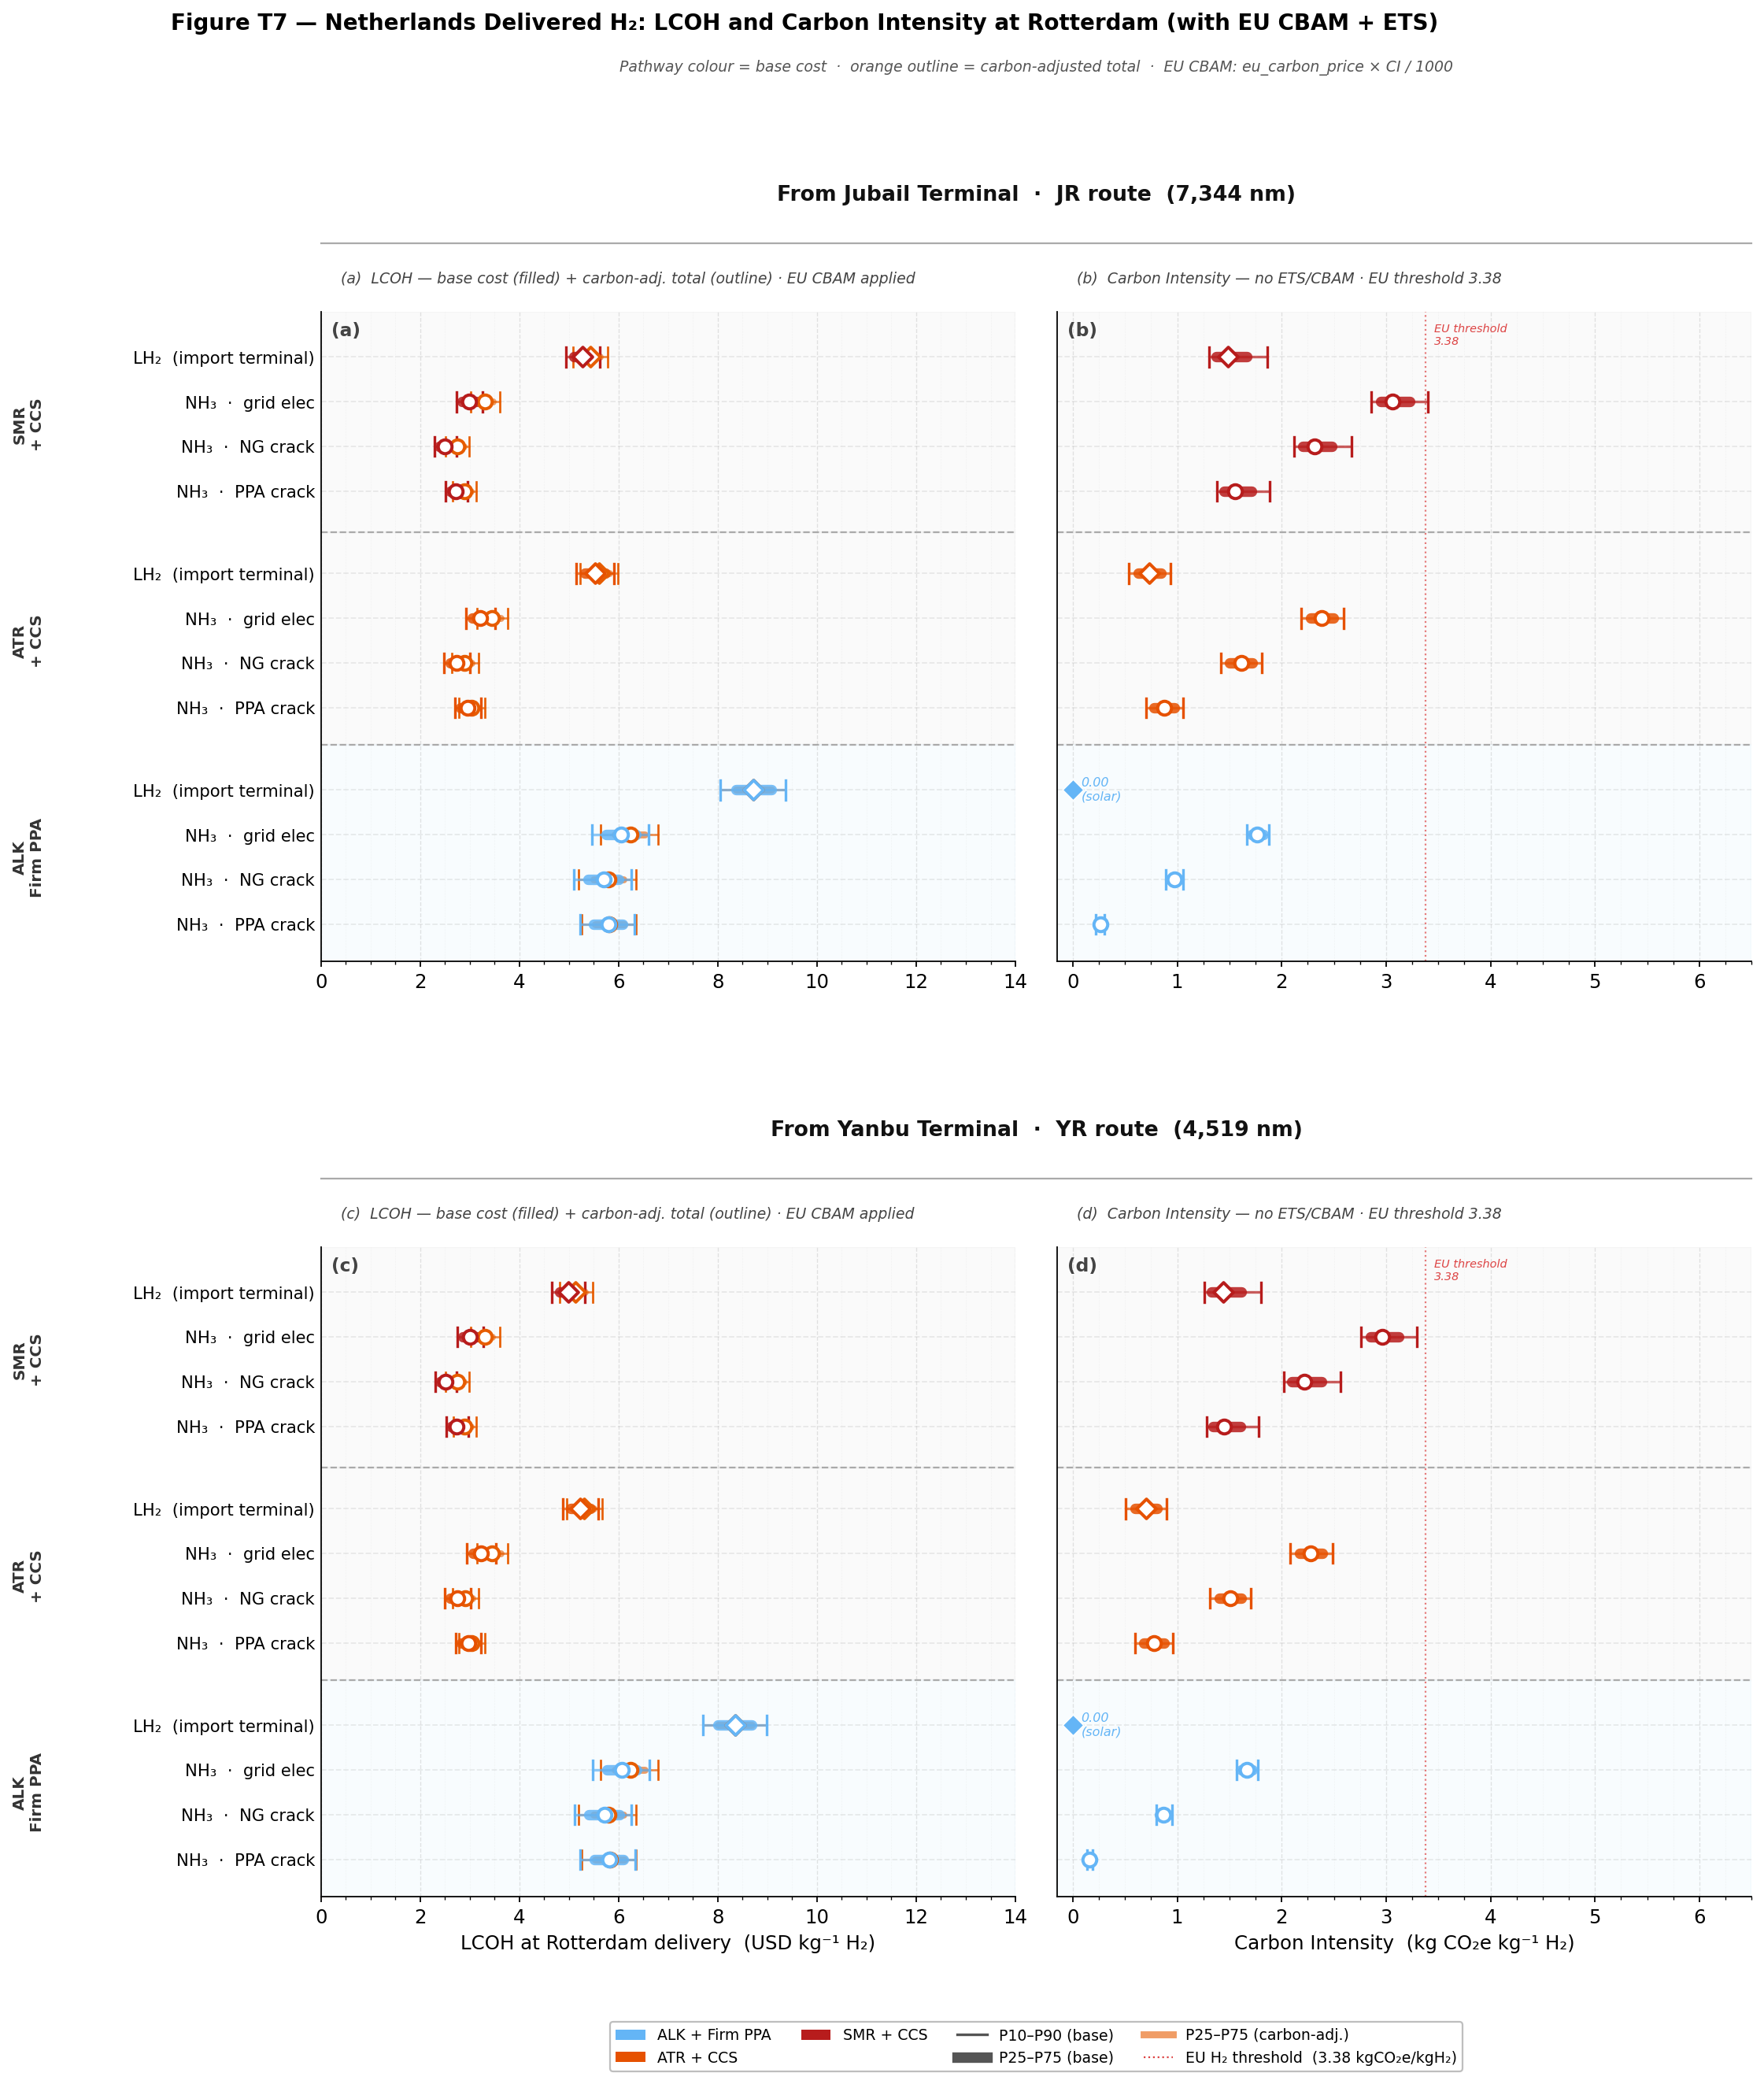

In [28]:
"""
Figure T7 — Netherlands Delivered H₂: LCOH and Carbon Intensity at Rotterdam (with EU CBAM + ETS)
- Same pathways/carriers as T6 (ALK Firm PPA, ATR+CCS, SMR+CCS; NH₃ × 3 crack + LH₂)
- LCOH panels: BASE cost (pathway colour) + carbon-adjusted cost (orange outline overlay)
  Carbon-adjusted = base LCOH + eu_carbon_price × CI_total / 1000
- CI panels: identical to T6 (carbon pricing does not change physical CI)
- eu_carbon_price: scenario distribution $60 (p=0.20) / $95 (p=0.50) / $140 (p=0.30) per tCO₂
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpa
from matplotlib.lines import Line2D as _L2D
import numpy as np, os, runpy, sys

ctx = globals()
mc                = ctx['mc_results']
mi                = ctx['mc_inputs']
TC                = ctx['TC']
FIG_DIR           = ctx['FIG_DIR']
DIST_NM           = ctx['DIST_NM']
VOYAGE_DAYS       = ctx['VOYAGE_DAYS']

# ── grid cracking vs PPA cracking cost delta ($/kgH₂) ────────────────────────
crack_kwh  = mi['crack_elec_kwh_per_kgh2'].values
grid_delta = crack_kwh * (mi['rott_grid_elec_price'].values
                          - mi['rott_elec_price'].values)

# ── cracking CI stochastic arrays ────────────────────────────────────────────
ci_crack_g = mc['ci_crack_g_rott'].values
ci_crack_b = mc['ci_crack_b_rott'].values

# ── production CI arrays ──────────────────────────────────────────────────────
ci_atr = mc['ci_atr_prod'].values
ci_smr = mc['ci_smr_prod'].values

AFPPA_COL = '#64B5F6'
ATR_COL   = TC['atr']
SMR_COL   = TC['smr']
CBAM_COL  = '#E65C00'

_fppa_nh3_jr_cadj = mc['alk_fppa_nh3_jr'].values + mi['eu_carbon_price'].values * mc['ci_alk_fppa_nh3_jr'].values / 1000
_fppa_nh3_yr_cadj = mc['alk_fppa_nh3_yr'].values + mi['eu_carbon_price'].values * mc['ci_alk_fppa_nh3_yr'].values / 1000
_fppa_ng_jr_cadj  = mc['alk_fppa_nh3_ng_jr'].values + mi['eu_carbon_price'].values * mc['ci_alk_fppa_nh3_ng_jr'].values / 1000
_fppa_ng_yr_cadj  = mc['alk_fppa_nh3_ng_yr'].values + mi['eu_carbon_price'].values * mc['ci_alk_fppa_nh3_ng_yr'].values / 1000
_fppa_lh2_jr_cadj = mc['alk_fppa_lh2_jr'].values
_fppa_lh2_yr_cadj = mc['alk_fppa_lh2_yr'].values

ROWS = [
    (0.00, 'NH₃  ·  PPA crack',
     mc['alk_fppa_nh3_jr'].values,   mc['alk_fppa_nh3_yr'].values,
     _fppa_nh3_jr_cadj,              _fppa_nh3_yr_cadj,
     mc['ci_alk_fppa_nh3_jr'].values, mc['ci_alk_fppa_nh3_yr'].values,
     AFPPA_COL, 'NH₃'),

    (0.60, 'NH₃  ·  NG crack',
     mc['alk_fppa_nh3_ng_jr'].values, mc['alk_fppa_nh3_ng_yr'].values,
     _fppa_ng_jr_cadj,               _fppa_ng_yr_cadj,
     mc['ci_alk_fppa_nh3_ng_jr'].values, mc['ci_alk_fppa_nh3_ng_yr'].values,
     AFPPA_COL, 'NH₃'),

    (1.20, 'NH₃  ·  grid elec',
     mc['alk_fppa_nh3_jr'].values + grid_delta,
     mc['alk_fppa_nh3_yr'].values + grid_delta,
     (mc['alk_fppa_nh3_jr'].values + grid_delta
      + mi['eu_carbon_price'].values * (mc['ci_alk_fppa_nh3_jr'].values - ci_crack_g + ci_crack_b) / 1000),
     (mc['alk_fppa_nh3_yr'].values + grid_delta
      + mi['eu_carbon_price'].values * (mc['ci_alk_fppa_nh3_yr'].values - ci_crack_g + ci_crack_b) / 1000),
     mc['ci_alk_fppa_nh3_jr'].values - ci_crack_g + ci_crack_b,
     mc['ci_alk_fppa_nh3_yr'].values - ci_crack_g + ci_crack_b,
     AFPPA_COL, 'NH₃'),

    (1.80, 'LH₂  (import terminal)',
     mc['alk_fppa_lh2_jr'].values, mc['alk_fppa_lh2_yr'].values,
     _fppa_lh2_jr_cadj,            _fppa_lh2_yr_cadj,
     None, None,
     AFPPA_COL, 'LH₂'),

    (2.90, 'NH₃  ·  PPA crack',
     mc['atr_nh3_jr'].values - grid_delta,
     mc['atr_nh3_yr'].values - grid_delta,
     (mc['atr_nh3_jr'].values - grid_delta
      + mi['eu_carbon_price'].values * (mc['ci_atr_nh3_jr'].values - ci_crack_b + ci_crack_g) / 1000),
     (mc['atr_nh3_yr'].values - grid_delta
      + mi['eu_carbon_price'].values * (mc['ci_atr_nh3_yr'].values - ci_crack_b + ci_crack_g) / 1000),
     mc['ci_atr_nh3_jr'].values - ci_crack_b + ci_crack_g,
     mc['ci_atr_nh3_yr'].values - ci_crack_b + ci_crack_g,
     ATR_COL, 'NH₃'),

    (3.50, 'NH₃  ·  NG crack',
     mc['atr_nh3_ng_jr'].values, mc['atr_nh3_ng_yr'].values,
     mc['atr_ng_cadj_jr'].values, mc['atr_ng_cadj_yr'].values,
     mc['ci_atr_nh3_ng_jr'].values, mc['ci_atr_nh3_ng_yr'].values,
     ATR_COL, 'NH₃'),

    (4.10, 'NH₃  ·  grid elec',
     mc['atr_nh3_jr'].values, mc['atr_nh3_yr'].values,
     mc['atr_cadj_jr'].values, mc['atr_cadj_yr'].values,
     mc['ci_atr_nh3_jr'].values, mc['ci_atr_nh3_yr'].values,
     ATR_COL, 'NH₃'),

    (4.70, 'LH₂  (import terminal)',
     mc['atr_lh2_jr'].values, mc['atr_lh2_yr'].values,
     mc['atr_cadj_lh2_jr'].values, mc['atr_cadj_lh2_yr'].values,
     mc['ci_atr_lh2_jr'].values, mc['ci_atr_lh2_yr'].values,
     ATR_COL, 'LH₂'),

    (5.80, 'NH₃  ·  PPA crack',
     mc['smr_nh3_jr'].values - grid_delta,
     mc['smr_nh3_yr'].values - grid_delta,
     (mc['smr_nh3_jr'].values - grid_delta
      + mi['eu_carbon_price'].values * (mc['ci_smr_nh3_jr'].values - ci_crack_b + ci_crack_g) / 1000),
     (mc['smr_nh3_yr'].values - grid_delta
      + mi['eu_carbon_price'].values * (mc['ci_smr_nh3_yr'].values - ci_crack_b + ci_crack_g) / 1000),
     mc['ci_smr_nh3_jr'].values - ci_crack_b + ci_crack_g,
     mc['ci_smr_nh3_yr'].values - ci_crack_b + ci_crack_g,
     SMR_COL, 'NH₃'),

    (6.40, 'NH₃  ·  NG crack',
     mc['smr_nh3_ng_jr'].values, mc['smr_nh3_ng_yr'].values,
     mc['smr_ng_cadj_jr'].values, mc['smr_ng_cadj_yr'].values,
     mc['ci_smr_nh3_ng_jr'].values, mc['ci_smr_nh3_ng_yr'].values,
     SMR_COL, 'NH₃'),

    (7.00, 'NH₃  ·  grid elec',
     mc['smr_nh3_jr'].values, mc['smr_nh3_yr'].values,
     mc['smr_cadj_jr'].values, mc['smr_cadj_yr'].values,
     mc['ci_smr_nh3_jr'].values, mc['ci_smr_nh3_yr'].values,
     SMR_COL, 'NH₃'),

    (7.60, 'LH₂  (import terminal)',
     mc['smr_lh2_jr'].values, mc['smr_lh2_yr'].values,
     mc['smr_cadj_lh2_jr'].values, mc['smr_cadj_lh2_yr'].values,
     mc['ci_smr_lh2_jr'].values, mc['ci_smr_lh2_yr'].values,
     SMR_COL, 'LH₂'),
]

Y_VALS = [r[0] for r in ROWS]
Y_LABS = [r[1] for r in ROWS]
Y_MIN, Y_MAX = -0.5, 8.2

def _ivl(ax, data, y, color, carrier, lw_thin=1.5, lw_thick=6, alpha=0.85, zorder_base=2):
    d = np.asarray(data, dtype=float); d = d[np.isfinite(d)]
    p10, p25, p50, p75, p90 = np.percentile(d, [10, 25, 50, 75, 90])
    ax.plot([p10, p90], [y, y], color=color, lw=lw_thin, alpha=0.70, zorder=zorder_base,
            solid_capstyle='round')
    for xv in (p10, p90):
        ax.plot([xv, xv], [y - 0.13, y + 0.13], color=color, lw=lw_thin, zorder=zorder_base)
    ax.plot([p25, p75], [y, y], color=color, lw=lw_thick, alpha=alpha, zorder=zorder_base+1,
            solid_capstyle='round')
    mkr = 'D' if carrier == 'LH₂' else 'o'
    ax.scatter([p50], [y], s=62, color='white', marker=mkr,
               edgecolors=color, linewidths=1.8, zorder=zorder_base+3)
    return p50

fig = plt.figure(figsize=(16.0, 17.0), dpi=160)
gs  = gridspec.GridSpec(2, 2, figure=fig, wspace=0.06, hspace=0.44,
                        left=0.26, right=0.97, top=0.84, bottom=0.10)
ax_jl = fig.add_subplot(gs[0, 0])
ax_jc = fig.add_subplot(gs[0, 1], sharey=ax_jl)
ax_yl = fig.add_subplot(gs[1, 0], sharey=ax_jl)
ax_yc = fig.add_subplot(gs[1, 1], sharey=ax_jl)

for ax in (ax_jl, ax_jc, ax_yl, ax_yc):
    ax.set_yticks(Y_VALS); ax.set_ylim(Y_MIN, Y_MAX)
    ax.grid(axis='x', which='major', lw=0.6, alpha=0.38, color='#b8b8b8')
    ax.grid(axis='x', which='minor', lw=0.3, alpha=0.20, color='#d0d0d0')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

ax_jl.set_yticklabels(Y_LABS, fontsize=9.5)
ax_yl.set_yticklabels(Y_LABS, fontsize=9.5)
ax_jc.tick_params(labelleft=False)
ax_yc.tick_params(labelleft=False)

SEP1 = 2.40; SEP2 = 5.25
for ax in (ax_jl, ax_jc, ax_yl, ax_yc):
    ax.axhline(SEP1, color='#aaaaaa', lw=1.0, ls='--', zorder=1)
    ax.axhline(SEP2, color='#aaaaaa', lw=1.0, ls='--', zorder=1)
    ax.axhspan(Y_MIN, SEP1, alpha=0.04, color='#64B5F6', zorder=0)
    ax.axhspan(SEP1, SEP2, alpha=0.04, color='#888888', zorder=0)
    ax.axhspan(SEP2, Y_MAX, alpha=0.04, color='#888888', zorder=0)

def _ax_to_fig_y(ax, ydata):
    pt = ax.transData.transform((0, ydata))
    return fig.transFigure.inverted().transform(pt)[1]
def _ax_top_fig(ax):
    pt = ax.transAxes.transform((0.5, 1.0))
    return fig.transFigure.inverted().transform(pt)[1]

grp_kw = dict(transform=fig.transFigure, fontsize=9.0, fontweight='bold',
              color='#333333', rotation=90, ha='center', va='center', clip_on=False)
for ax_left in (ax_jl, ax_yl):
    fig.text(0.115, _ax_to_fig_y(ax_left, 0.90),  'ALK\nFirm PPA', **grp_kw)
    fig.text(0.115, _ax_to_fig_y(ax_left, 3.80),  'ATR\n+ CCS',    **grp_kw)
    fig.text(0.115, _ax_to_fig_y(ax_left, 6.70),  'SMR\n+ CCS',    **grp_kw)

for ax, lbl in [(ax_jl, '(a)'), (ax_jc, '(b)'), (ax_yl, '(c)'), (ax_yc, '(d)')]:
    ax.text(0.015, 0.985, lbl, transform=ax.transAxes,
            fontsize=10.5, fontweight='bold', va='top', ha='left', color='#444444', clip_on=False)

cx = (0.26 + 0.97) / 2; lc_x = 0.27; rc_x = 0.635
jr_top = _ax_top_fig(ax_jl); yr_top = _ax_top_fig(ax_yl)
OFFSET_TITLE=0.050; OFFSET_RULE=0.032; OFFSET_DESC=0.012

row_title_kw = dict(transform=fig.transFigure, fontsize=12, fontweight='bold',
                    color='#111111', ha='center', va='bottom', clip_on=False)
desc_kw = dict(transform=fig.transFigure, fontsize=8.5, color='#444444',
               va='bottom', style='italic', clip_on=False)

for base, row_lbl, desc_l, desc_r in [
    (jr_top,
     f'From Jubail Terminal  ·  JR route  ({DIST_NM["JR"]:,} nm)',
     '(a)  LCOH — base cost (filled) + carbon-adj. total (outline) · EU CBAM applied',
     '(b)  Carbon Intensity — no ETS/CBAM · EU threshold 3.38'),
    (yr_top,
     f'From Yanbu Terminal  ·  YR route  ({DIST_NM["YR"]:,} nm)',
     '(c)  LCOH — base cost (filled) + carbon-adj. total (outline) · EU CBAM applied',
     '(d)  Carbon Intensity — no ETS/CBAM · EU threshold 3.38'),
]:
    fig.text(cx, base + OFFSET_TITLE, row_lbl, **row_title_kw)
    fig.add_artist(_L2D([0.26, 0.97], [base + OFFSET_RULE, base + OFFSET_RULE],
                   transform=fig.transFigure, color='#aaaaaa', lw=1.0, clip_on=False))
    fig.text(lc_x, base + OFFSET_DESC, desc_l, ha='left', **desc_kw)
    fig.text(rc_x, base + OFFSET_DESC, desc_r, ha='left', **desc_kw)

EU_THRESHOLD = 3.38
for ax_l, ax_c, base_idx, adj_idx, ci_idx in [
    (ax_jl, ax_jc, 2, 4, 6),
    (ax_yl, ax_yc, 3, 5, 7),
]:
    for row in ROWS:
        y, lbl, *vals, color, carrier = row
        base_arr = vals[base_idx - 2]
        adj_arr  = vals[adj_idx  - 2]
        ci_arr   = vals[ci_idx   - 2]
        _ivl(ax_l, base_arr, y, color, carrier, zorder_base=4)
        _ivl(ax_l, adj_arr,  y, CBAM_COL, carrier, lw_thin=1.2, lw_thick=4, alpha=0.60, zorder_base=2)

    ax_l.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax_l.set_xlim(left=0, right=14.0)

    ax_c.axvline(EU_THRESHOLD, color='#d44', lw=1.0, ls=':', alpha=0.70, zorder=1)
    ax_c.text(EU_THRESHOLD + 0.08, Y_MAX - 0.15, 'EU threshold\n3.38',
              va='top', ha='left', fontsize=6.5, color='#d44', style='italic')

    for row in ROWS:
        y, lbl, *vals, color, carrier = row
        ci_arr = vals[ci_idx - 2]
        if ci_arr is None:
            ax_c.scatter([0], [y], s=70, color=color, marker='D',
                         edgecolors='white', linewidths=0.6, zorder=5)
            ax_c.text(0.08, y, '0.00\n(solar)', va='center', ha='left',
                      fontsize=7.2, color=color, style='italic')
        else:
            _ivl(ax_c, ci_arr, y, color, carrier)

    ax_c.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
    ax_c.set_xlim(left=-0.15, right=6.5)

ax_yl.set_xlabel('LCOH at Rotterdam delivery  (USD kg⁻¹ H₂)', fontsize=11)
ax_yc.set_xlabel('Carbon Intensity  (kg CO₂e kg⁻¹ H₂)', fontsize=11)

legend_h = [
    mpa.Patch(fc=AFPPA_COL, ec='none', label='ALK + Firm PPA'),
    mpa.Patch(fc=ATR_COL,   ec='none', label='ATR + CCS'),
    mpa.Patch(fc=SMR_COL,   ec='none', label='SMR + CCS'),
    mpa.Patch(fc='none',    ec='none', label=' '),
    plt.Line2D([0],[0], color='#555555', lw=1.5, label='P10–P90 (base)'),
    plt.Line2D([0],[0], color='#555555', lw=6,   label='P25–P75 (base)'),
    plt.Line2D([0],[0], color=CBAM_COL,   lw=4,   label='P25–P75 (carbon-adj.)', alpha=0.60),
    plt.Line2D([0],[0], color='#d44', lw=1.0, ls=':', label='EU H₂ threshold  (3.38 kgCO₂e/kgH₂)'),
]
fig.legend(handles=legend_h, loc='lower center', ncol=4,
           fontsize=8.5, frameon=True, framealpha=0.95, edgecolor='#bbbbbb',
           bbox_to_anchor=(0.615, 0.015))

fig.suptitle(
    'Figure T7 — Netherlands Delivered H₂: LCOH and Carbon Intensity at Rotterdam (with EU CBAM + ETS)',
    fontsize=12.5, y=0.980, fontweight='bold'
)
fig.text(
    0.615, 0.958,
    'Pathway colour = base cost  ·  orange outline = carbon-adjusted total  ·  EU CBAM: eu_carbon_price × CI / 1000',
    ha='center', va='top', fontsize=8.5, color='#555555', style='italic'
)

out = os.path.join(FIG_DIR, 'fig_T7_delivered_nl_cbam.png')
plt.show()

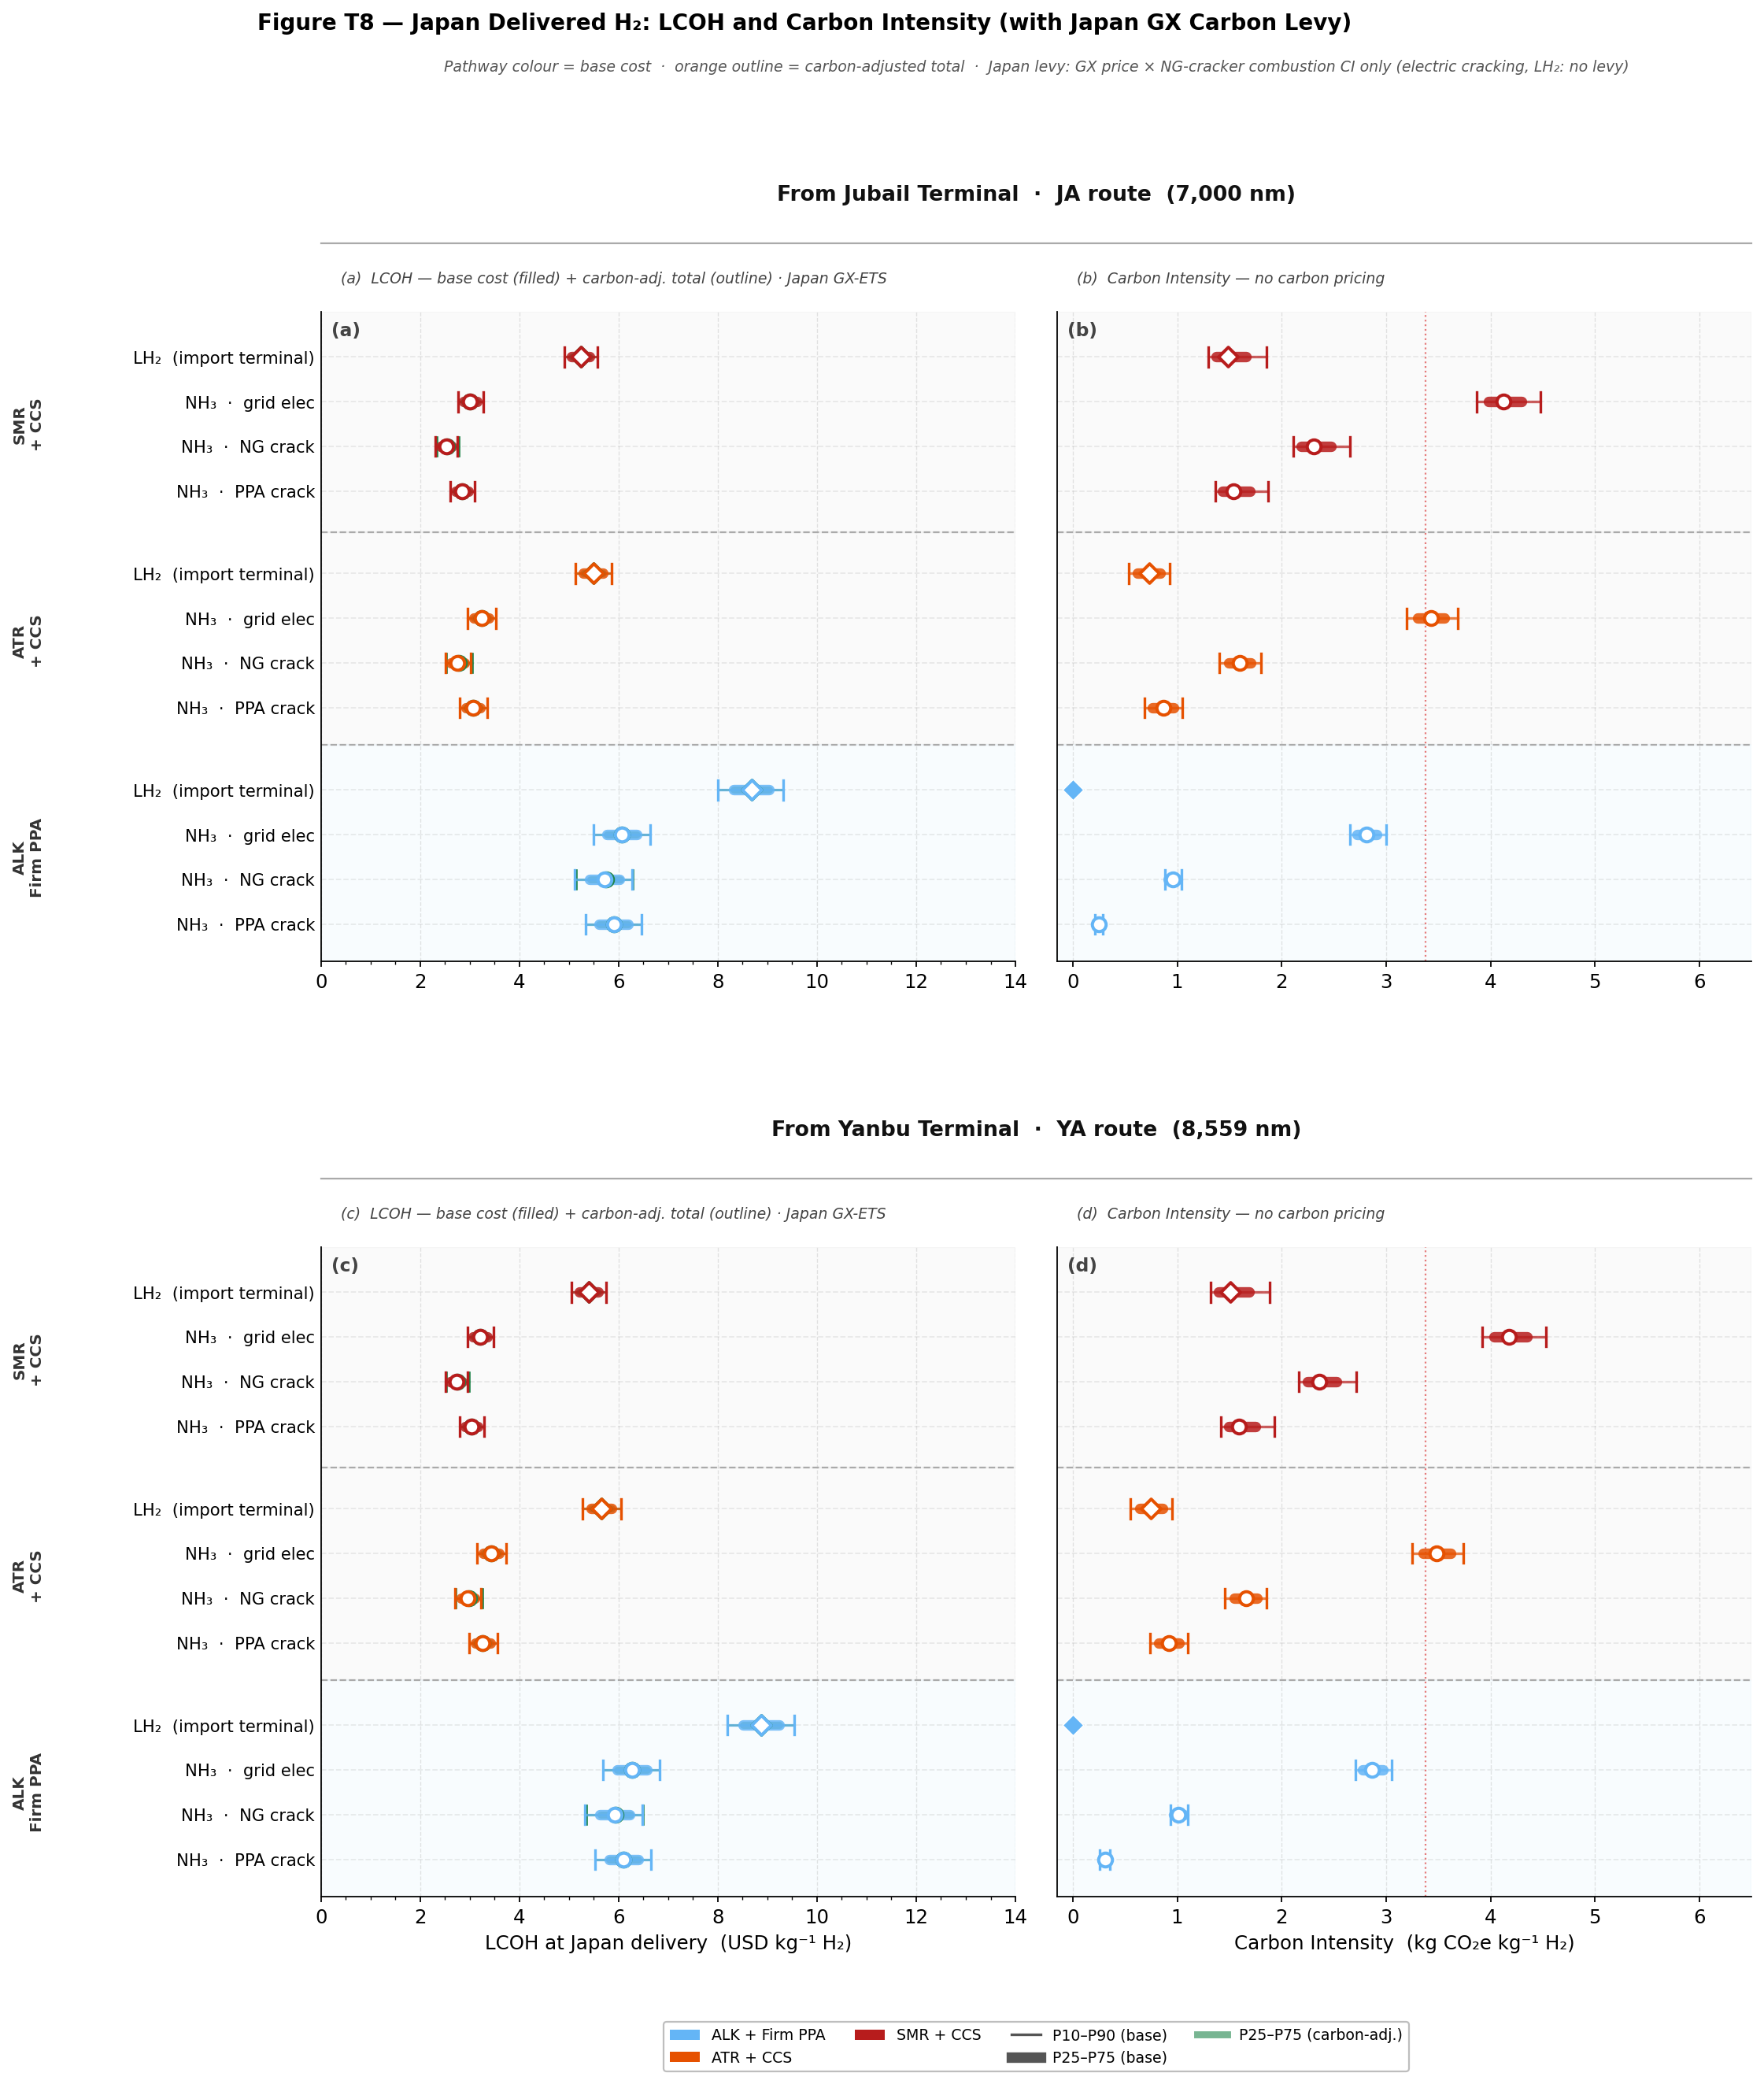

In [29]:
"""
Figure T8 — Japan Delivered H₂: LCOH and Carbon Intensity at Japan Import Port (with Japan GX Carbon Levy)
- Same pathways/carriers as T6 (ALK Firm PPA, ATR+CCS, SMR+CCS; NH₃ × 3 crack + LH₂)
- LCOH panels: BASE cost (pathway colour) + carbon-adjusted cost (orange outline overlay)
  Carbon-adjusted = base LCOH + japan_carbon_price × CI_total / 1000
- CI panels: identical to Japan T5 (carbon pricing does not change physical CI)
- japan_carbon_price: stochastic distribution (PARAMS)
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpa
from matplotlib.lines import Line2D as _L2D
import numpy as np, os, runpy, sys

ctx = globals()
mc                = ctx['mc_results']
mi                = ctx['mc_inputs']
TC                = ctx['TC']
FIG_DIR           = ctx['FIG_DIR']
DIST_NM           = ctx['DIST_NM']
VOYAGE_DAYS       = ctx['VOYAGE_DAYS']

crack_kwh    = mi['crack_elec_kwh_per_kgh2'].values
jpn_cp       = mi['japan_carbon_price'].values
_ci_crack_ng = mi['ng_crack_kwh_th_per_kgh2'].values / LHV_CH4_KWH_PER_KG * (44.0/16.0)  # Japan levy base: cracker combustion only

ci_crack_a_blue  = mc['ci_crack_b_ja'].values
ci_crack_a_green = mc['ci_crack_g_ja'].values
grid_delta_j = crack_kwh * (mi['japan_elec_price'].values
                            - mi['japan_re_ppa_price'].values)

AFPPA_COL = '#64B5F6'; ATR_COL = TC['atr']; SMR_COL = TC['smr']; CBAM_COL = '#1E8449'

_fppa_nh3_ja_cadj = mc['alk_fppa_nh3_ja'].values + 0.0 * jpn_cp   # grid-crack: no explicit levy
_fppa_nh3_ya_cadj = mc['alk_fppa_nh3_ya'].values + 0.0 * jpn_cp   # grid-crack: no explicit levy
_fppa_ng_ja_cadj  = mc['alk_fppa_nh3_ng_ja'].values + jpn_cp * _ci_crack_ng / 1000
_fppa_ng_ya_cadj  = mc['alk_fppa_nh3_ng_ya'].values + jpn_cp * _ci_crack_ng / 1000
_fppa_lh2_ja_cadj = mc['alk_fppa_lh2_ja'].values
_fppa_lh2_ya_cadj = mc['alk_fppa_lh2_ya'].values

ROWS = [
    (0.00, 'NH₃  ·  PPA crack',
     mc['alk_fppa_nh3_ja'].values,  mc['alk_fppa_nh3_ya'].values,
     _fppa_nh3_ja_cadj,              _fppa_nh3_ya_cadj,
     mc['ci_alk_fppa_nh3_ja'].values, mc['ci_alk_fppa_nh3_ya'].values,
     AFPPA_COL, 'NH₃'),

    (0.60, 'NH₃  ·  NG crack',
     mc['alk_fppa_nh3_ng_ja'].values, mc['alk_fppa_nh3_ng_ya'].values,
     _fppa_ng_ja_cadj,                 _fppa_ng_ya_cadj,
     mc['ci_alk_fppa_nh3_ng_ja'].values, mc['ci_alk_fppa_nh3_ng_ya'].values,
     AFPPA_COL, 'NH₃'),

    (1.20, 'NH₃  ·  grid elec',
     mc['alk_fppa_nh3_ja'].values + grid_delta_j,
     mc['alk_fppa_nh3_ya'].values + grid_delta_j,
     (mc['alk_fppa_nh3_ja'].values + grid_delta_j
      + 0.0 * jpn_cp),  # electric crack: no explicit levy
     (mc['alk_fppa_nh3_ya'].values + grid_delta_j
      + 0.0 * jpn_cp),  # electric crack: no explicit levy
     mc['ci_alk_fppa_nh3_ja'].values - ci_crack_a_green + ci_crack_a_blue,
     mc['ci_alk_fppa_nh3_ya'].values - ci_crack_a_green + ci_crack_a_blue,
     AFPPA_COL, 'NH₃'),

    (1.80, 'LH₂  (import terminal)',
     mc['alk_fppa_lh2_ja'].values, mc['alk_fppa_lh2_ya'].values,
     _fppa_lh2_ja_cadj,             _fppa_lh2_ya_cadj,
     None, None,
     AFPPA_COL, 'LH₂'),

    (2.90, 'NH₃  ·  PPA crack',
     mc['atr_nh3_ja'].values - grid_delta_j,
     mc['atr_nh3_ya'].values - grid_delta_j,
     (mc['atr_nh3_ja'].values - grid_delta_j
      + 0.0 * jpn_cp),  # electric crack: no explicit levy
     (mc['atr_nh3_ya'].values - grid_delta_j
      + 0.0 * jpn_cp),  # electric crack: no explicit levy
     mc['ci_atr_nh3_ja'].values - ci_crack_a_blue + ci_crack_a_green,
     mc['ci_atr_nh3_ya'].values - ci_crack_a_blue + ci_crack_a_green,
     ATR_COL, 'NH₃'),

    (3.50, 'NH₃  ·  NG crack',
     mc['atr_nh3_ng_ja'].values, mc['atr_nh3_ng_ya'].values,
     mc['atr_ng_cadj_ja'].values, mc['atr_ng_cadj_ya'].values,
     mc['ci_atr_nh3_ng_ja'].values, mc['ci_atr_nh3_ng_ya'].values,
     ATR_COL, 'NH₃'),

    (4.10, 'NH₃  ·  grid elec',
     mc['atr_nh3_ja'].values, mc['atr_nh3_ya'].values,
     mc['atr_cadj_ja'].values, mc['atr_cadj_ya'].values,
     mc['ci_atr_nh3_ja'].values, mc['ci_atr_nh3_ya'].values,
     ATR_COL, 'NH₃'),

    (4.70, 'LH₂  (import terminal)',
     mc['atr_lh2_ja'].values, mc['atr_lh2_ya'].values,
     mc['atr_cadj_lh2_ja'].values, mc['atr_cadj_lh2_ya'].values,
     mc['ci_atr_lh2_ja'].values, mc['ci_atr_lh2_ya'].values,
     ATR_COL, 'LH₂'),

    (5.80, 'NH₃  ·  PPA crack',
     mc['smr_nh3_ja'].values - grid_delta_j,
     mc['smr_nh3_ya'].values - grid_delta_j,
     (mc['smr_nh3_ja'].values - grid_delta_j
      + 0.0 * jpn_cp),  # electric crack: no explicit levy
     (mc['smr_nh3_ya'].values - grid_delta_j
      + 0.0 * jpn_cp),  # electric crack: no explicit levy
     mc['ci_smr_nh3_ja'].values - ci_crack_a_blue + ci_crack_a_green,
     mc['ci_smr_nh3_ya'].values - ci_crack_a_blue + ci_crack_a_green,
     SMR_COL, 'NH₃'),

    (6.40, 'NH₃  ·  NG crack',
     mc['smr_nh3_ng_ja'].values, mc['smr_nh3_ng_ya'].values,
     mc['smr_ng_cadj_ja'].values, mc['smr_ng_cadj_ya'].values,
     mc['ci_smr_nh3_ng_ja'].values, mc['ci_smr_nh3_ng_ya'].values,
     SMR_COL, 'NH₃'),

    (7.00, 'NH₃  ·  grid elec',
     mc['smr_nh3_ja'].values, mc['smr_nh3_ya'].values,
     mc['smr_cadj_ja'].values, mc['smr_cadj_ya'].values,
     mc['ci_smr_nh3_ja'].values, mc['ci_smr_nh3_ya'].values,
     SMR_COL, 'NH₃'),

    (7.60, 'LH₂  (import terminal)',
     mc['smr_lh2_ja'].values, mc['smr_lh2_ya'].values,
     mc['smr_cadj_lh2_ja'].values, mc['smr_cadj_lh2_ya'].values,
     mc['ci_smr_lh2_ja'].values, mc['ci_smr_lh2_ya'].values,
     SMR_COL, 'LH₂'),
]

Y_VALS = [r[0] for r in ROWS]; Y_LABS = [r[1] for r in ROWS]; Y_MIN, Y_MAX = -0.5, 8.2

def _ivl(ax, data, y, color, carrier, lw_thin=1.5, lw_thick=6, alpha=0.85, zorder_base=2):
    d = np.asarray(data, dtype=float); d = d[np.isfinite(d)]
    p10, p25, p50, p75, p90 = np.percentile(d, [10, 25, 50, 75, 90])
    ax.plot([p10, p90], [y, y], color=color, lw=lw_thin, alpha=0.70, zorder=zorder_base, solid_capstyle='round')
    for xv in (p10, p90): ax.plot([xv, xv], [y-0.13, y+0.13], color=color, lw=lw_thin, zorder=zorder_base)
    ax.plot([p25, p75], [y, y], color=color, lw=lw_thick, alpha=alpha, zorder=zorder_base+1, solid_capstyle='round')
    mkr = 'D' if carrier == 'LH₂' else 'o'
    ax.scatter([p50], [y], s=62, color='white', marker=mkr, edgecolors=color, linewidths=1.8, zorder=zorder_base+3)
    return p50

fig = plt.figure(figsize=(16.0, 17.0), dpi=160)
gs  = gridspec.GridSpec(2, 2, figure=fig, wspace=0.06, hspace=0.44, left=0.26, right=0.97, top=0.84, bottom=0.10)
ax_jl = fig.add_subplot(gs[0, 0]); ax_jc = fig.add_subplot(gs[0, 1], sharey=ax_jl)
ax_yl = fig.add_subplot(gs[1, 0], sharey=ax_jl); ax_yc = fig.add_subplot(gs[1, 1], sharey=ax_jl)

for ax in (ax_jl, ax_jc, ax_yl, ax_yc):
    ax.set_yticks(Y_VALS); ax.set_ylim(Y_MIN, Y_MAX)
    ax.grid(axis='x', which='major', lw=0.6, alpha=0.38, color='#b8b8b8')
    ax.set_axisbelow(True); ax.spines[['top', 'right']].set_visible(False)
ax_jl.set_yticklabels(Y_LABS, fontsize=9.5); ax_yl.set_yticklabels(Y_LABS, fontsize=9.5)
ax_jc.tick_params(labelleft=False); ax_yc.tick_params(labelleft=False)

SEP1=2.40; SEP2=5.25
for ax in (ax_jl, ax_jc, ax_yl, ax_yc):
    ax.axhline(SEP1, color='#aaaaaa', lw=1.0, ls='--', zorder=1)
    ax.axhline(SEP2, color='#aaaaaa', lw=1.0, ls='--', zorder=1)
    ax.axhspan(Y_MIN, SEP1, alpha=0.04, color='#64B5F6', zorder=0)
    ax.axhspan(SEP1, SEP2, alpha=0.04, color='#888888', zorder=0)
    ax.axhspan(SEP2, Y_MAX, alpha=0.04, color='#888888', zorder=0)

def _ax_to_fig_y(ax, ydata):
    pt = ax.transData.transform((0, ydata)); return fig.transFigure.inverted().transform(pt)[1]
def _ax_top_fig(ax):
    pt = ax.transAxes.transform((0.5, 1.0)); return fig.transFigure.inverted().transform(pt)[1]
grp_kw = dict(transform=fig.transFigure, fontsize=9.0, fontweight='bold', color='#333333',
              rotation=90, ha='center', va='center', clip_on=False)
for ax_left in (ax_jl, ax_yl):
    fig.text(0.115, _ax_to_fig_y(ax_left, 0.90), 'ALK\nFirm PPA', **grp_kw)
    fig.text(0.115, _ax_to_fig_y(ax_left, 3.80), 'ATR\n+ CCS',    **grp_kw)
    fig.text(0.115, _ax_to_fig_y(ax_left, 6.70), 'SMR\n+ CCS',    **grp_kw)
for ax, lbl in [(ax_jl,'(a)'),(ax_jc,'(b)'),(ax_yl,'(c)'),(ax_yc,'(d)')]:
    ax.text(0.015, 0.985, lbl, transform=ax.transAxes, fontsize=10.5, fontweight='bold',
            va='top', ha='left', color='#444444', clip_on=False)

cx=(0.26+0.97)/2; lc_x=0.27; rc_x=0.635
jr_top=_ax_top_fig(ax_jl); yr_top=_ax_top_fig(ax_yl)
OFFSET_TITLE=0.050; OFFSET_RULE=0.032; OFFSET_DESC=0.012
row_title_kw=dict(transform=fig.transFigure,fontsize=12,fontweight='bold',color='#111111',ha='center',va='bottom',clip_on=False)
desc_kw=dict(transform=fig.transFigure,fontsize=8.5,color='#444444',va='bottom',style='italic',clip_on=False)
for base, row_lbl, desc_l, desc_r in [
    (jr_top, f'From Jubail Terminal  ·  JA route  ({DIST_NM["JA"]:,} nm)',
     '(a)  LCOH — base cost (filled) + carbon-adj. total (outline) · Japan GX-ETS',
     '(b)  Carbon Intensity — no carbon pricing'),
    (yr_top, f'From Yanbu Terminal  ·  YA route  ({DIST_NM["YA"]:,} nm)',
     '(c)  LCOH — base cost (filled) + carbon-adj. total (outline) · Japan GX-ETS',
     '(d)  Carbon Intensity — no carbon pricing'),
]:
    fig.text(cx, base+OFFSET_TITLE, row_lbl, **row_title_kw)
    fig.add_artist(_L2D([0.26,0.97],[base+OFFSET_RULE]*2,transform=fig.transFigure,color='#aaaaaa',lw=1.0,clip_on=False))
    fig.text(lc_x, base+OFFSET_DESC, desc_l, ha='left', **desc_kw)
    fig.text(rc_x, base+OFFSET_DESC, desc_r, ha='left', **desc_kw)

EU_THRESHOLD=3.38
for ax_l, ax_c, base_idx, adj_idx, ci_idx in [(ax_jl,ax_jc,2,4,6),(ax_yl,ax_yc,3,5,7)]:
    for row in ROWS:
        y, lbl, *vals, color, carrier = row
        _ivl(ax_l, vals[base_idx-2], y, color, carrier, zorder_base=4)
        _ivl(ax_l, vals[adj_idx-2],  y, CBAM_COL, carrier, lw_thin=1.2, lw_thick=4, alpha=0.60, zorder_base=2)
    ax_l.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax_l.set_xlim(left=0, right=14.0)
    ax_c.axvline(EU_THRESHOLD, color='#d44', lw=1.0, ls=':', alpha=0.70, zorder=1)
    for row in ROWS:
        y, lbl, *vals, color, carrier = row
        ci_arr = vals[ci_idx-2]
        if ci_arr is None:
            ax_c.scatter([0],[y],s=70,color=color,marker='D',edgecolors='white',linewidths=0.6,zorder=5)
        else:
            _ivl(ax_c, ci_arr, y, color, carrier)
    ax_c.set_xlim(left=-0.15, right=6.5)

ax_yl.set_xlabel('LCOH at Japan delivery  (USD kg⁻¹ H₂)', fontsize=11)
ax_yc.set_xlabel('Carbon Intensity  (kg CO₂e kg⁻¹ H₂)', fontsize=11)

legend_h = [
    mpa.Patch(fc=AFPPA_COL,ec='none',label='ALK + Firm PPA'),
    mpa.Patch(fc=ATR_COL,  ec='none',label='ATR + CCS'),
    mpa.Patch(fc=SMR_COL,  ec='none',label='SMR + CCS'),
    mpa.Patch(fc='none',  ec='none',label=' '),
    plt.Line2D([0],[0],color='#555555',lw=1.5,label='P10–P90 (base)'),
    plt.Line2D([0],[0],color='#555555',lw=6,label='P25–P75 (base)'),
    plt.Line2D([0],[0],color=CBAM_COL,lw=4,label='P25–P75 (carbon-adj.)',alpha=0.60),
]
fig.legend(handles=legend_h, loc='lower center', ncol=4, fontsize=8.5,
           frameon=True, framealpha=0.95, edgecolor='#bbbbbb', bbox_to_anchor=(0.615, 0.015))

fig.suptitle('Figure T8 — Japan Delivered H₂: LCOH and Carbon Intensity (with Japan GX Carbon Levy)',
             fontsize=12.5, y=0.980, fontweight='bold')
fig.text(0.615, 0.958,
    'Pathway colour = base cost  ·  orange outline = carbon-adjusted total  ·  Japan levy: GX price × NG-cracker combustion CI only (electric cracking, LH₂: no levy)',
    ha='center', va='top', fontsize=8.5, color='#555555', style='italic')

out = os.path.join(FIG_DIR, 'fig_T8_delivered_japan_cbam.png')
plt.show()


── T9 P50 Cost Cross-check ──────────────────────────────
  ALK FirmPPA: seg_sum=$5.792  P50(total+CBAM)=$5.795  diff=$-0.003
  ATR+CCS: seg_sum=$2.888  P50(total+CBAM)=$2.895  diff=$-0.006
  SMR+CCS: seg_sum=$2.722  P50(total+CBAM)=$2.728  diff=$-0.006
── T9 P50 CI Cross-check ────────────────────────────────
  ALK FirmPPA: seg_sum=0.970  P50(total)=0.970  diff=-0.000
  ATR+CCS: seg_sum=1.610  P50(total)=1.613  diff=-0.003
  SMR+CCS: seg_sum=2.307  P50(total)=2.316  diff=-0.009


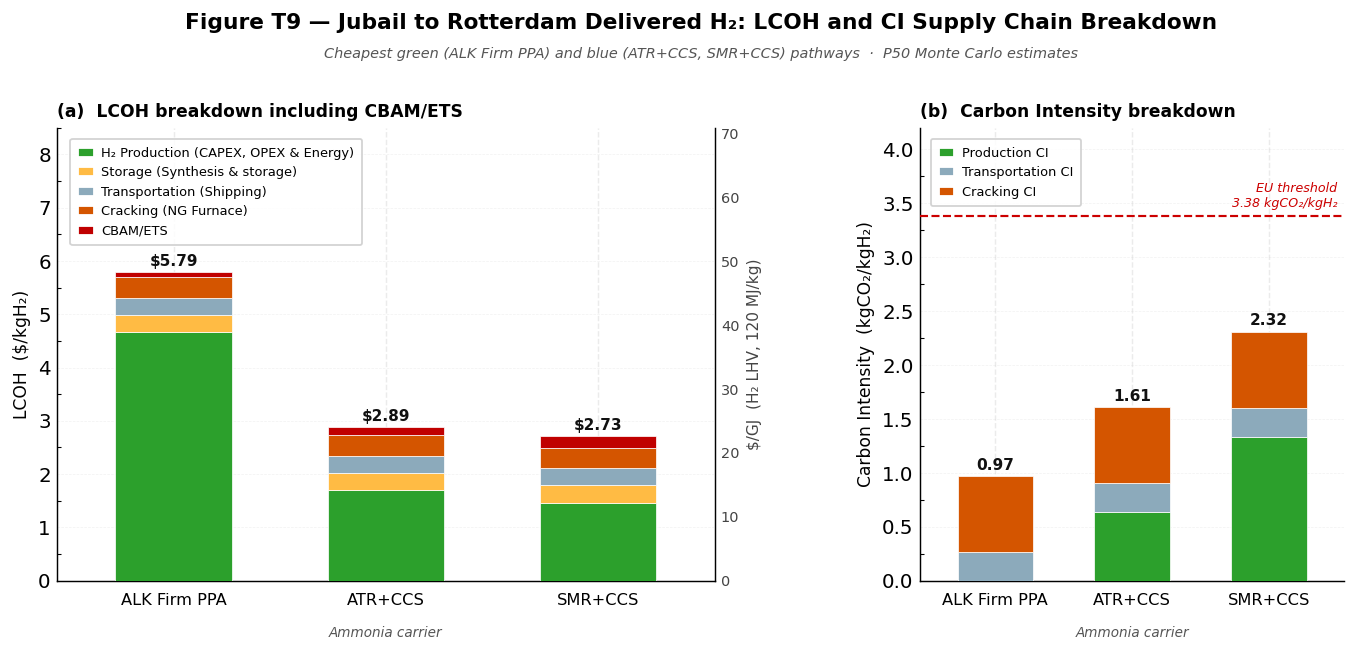

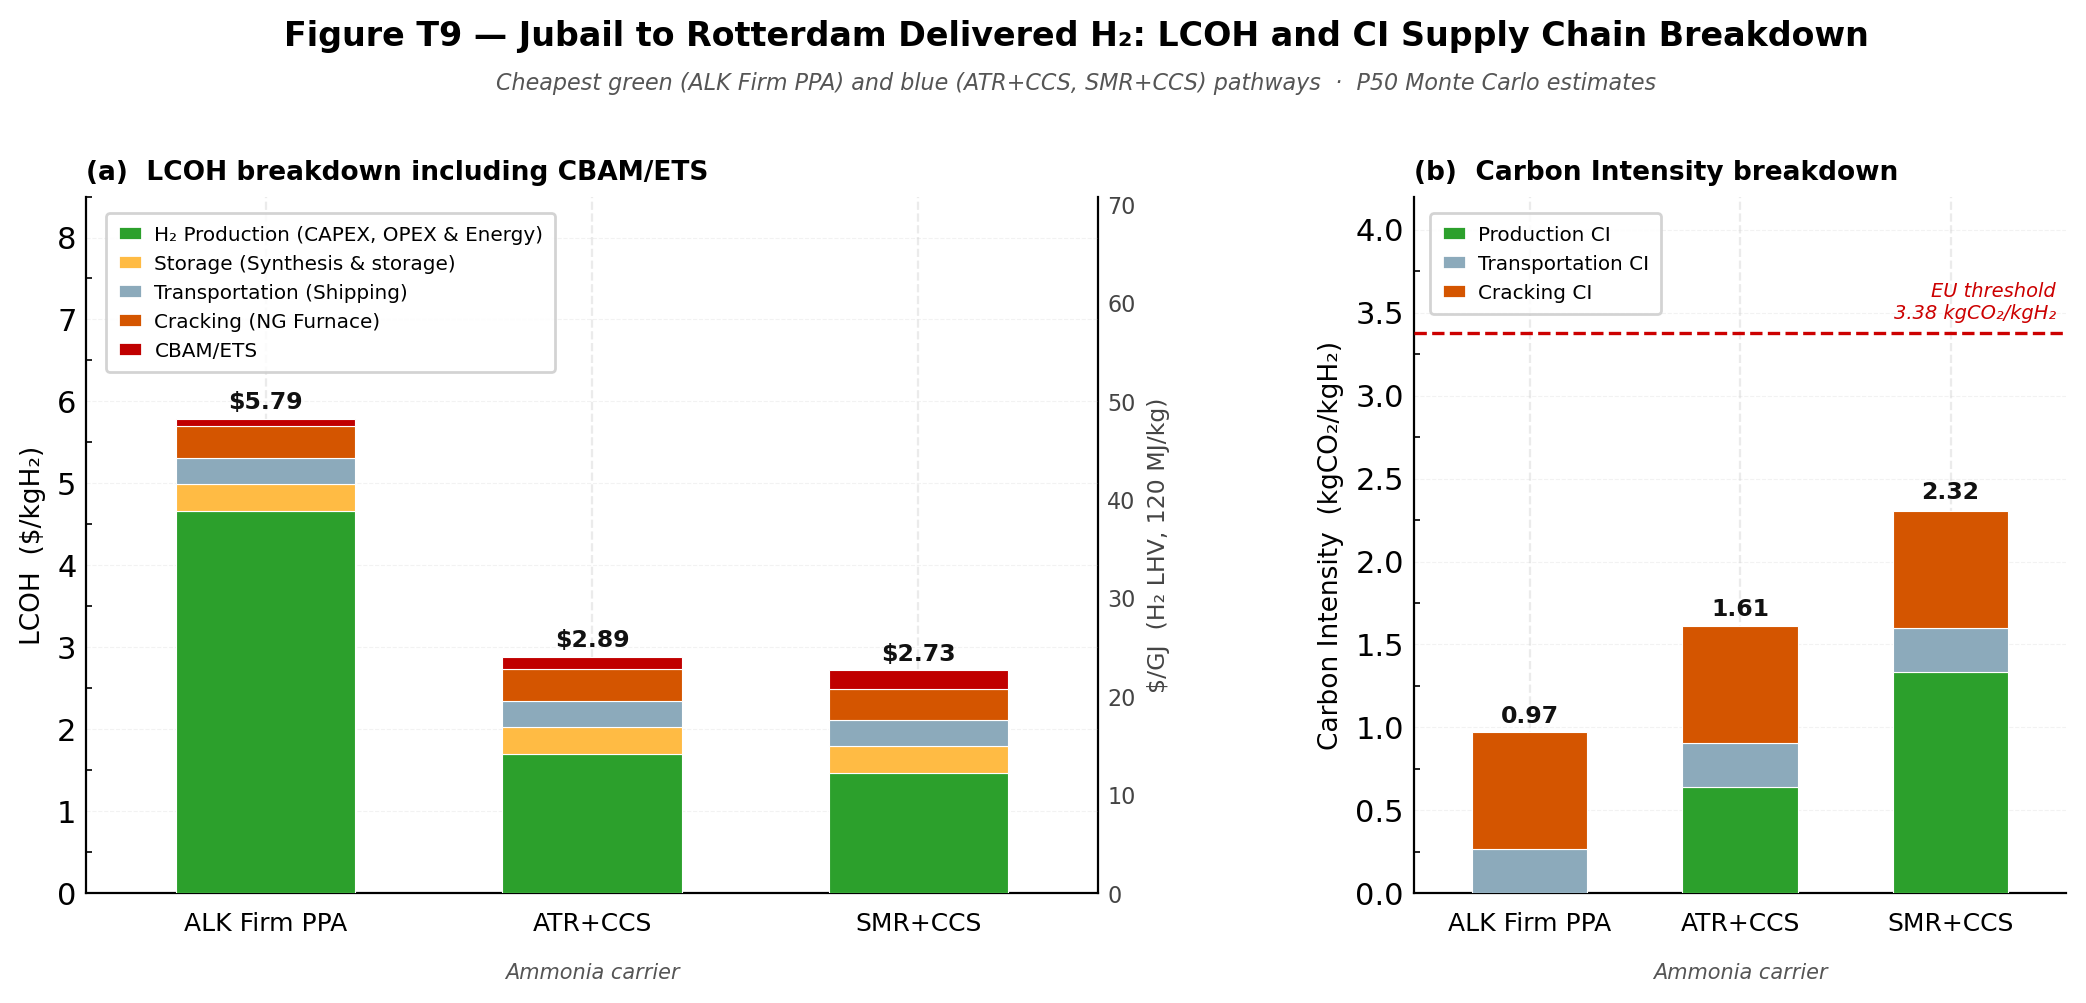

In [30]:
"""
Figure T9 — Rotterdam Delivered H₂: LCOH and CI Supply Chain Breakdown
            (ALK Firm PPA, ATR+CCS, SMR+CCS · NH₃ · NG crack · Jubail→Rotterdam)

Panel (a): Stacked LCOH bar — segments: H₂ Production | NH₃ Synthesis |
           NH₃ Storage | NH₃ Shipping | NG Cracking | CBAM/ETS
           Left axis: $/kgH₂  |  Right axis: $/GJ (LHV, 120 MJ/kgH₂)
Panel (b): Stacked CI bar  — segments: Production CI | NH₃ Shipping CI |
           NG Cracking CI

All values at P50 (median) from the Monte Carlo sample.
"""
import IPython.display as _d
### === Merged from fig_t9_breakdown_ng_jr.py (single-notebook pipeline) ===
"""
fig_t9_breakdown_ng_jr.py
─────────────────────────────────────────────────────────────────────────────
Figure T9 — Rotterdam Delivered H₂: LCOH and CI Breakdown by Supply Chain Stage
            (NH₃ pathway, NG cracking, Jubail→Rotterdam)

Three pathways compared at P50:
  • ALK Firm PPA  · NH₃ · NG crack · JR   (cheapest green)
  • ATR+CCS       · NH₃ · NG crack · JR   (cheapest blue)
  • SMR+CCS       · NH₃ · NG crack · JR

Panel (a) — LCOH stacked bar ($/kgH₂)
  Segments: Production | Storage (synth + export) | Transportation | Cracking (NG Furnace) | CBAM/ETS

Panel (b) — Carbon Intensity stacked bar (kgCO₂/kgH₂)
  Segments: Production CI | Transportation CI | Cracking CI

Methodology note:
  Each segment's P50 is computed independently from the MC sample.
  The sum of medians is a slight approximation of the median of the sum
  (Jensen's inequality), but differences are negligible for visualisation.
─────────────────────────────────────────────────────────────────────────────
"""

import os, sys, time, warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

# ── Load runner ───────────────────────────────────────────────────────────────
ctx = globals()

mc  = ctx['mc_results']
mi  = ctx['mc_inputs']

# ── Constants from runner context ─────────────────────────────────────────────
CRACK_YIELD_NG    = ctx['CRACK_YIELD_NG']
KG_NH3_PER_KG_H2 = ctx['KG_NH3_PER_KG_H2']
NM_TO_KM          = ctx['NM_TO_KM']
DIST_NM           = ctx['DIST_NM']
NG_KWH_PER_MMBTU  = ctx['NG_KWH_PER_MMBTU']
LHV_CH4_KWH_PER_KG = ctx['LHV_CH4_KWH_PER_KG']
EU_THRESH         = 3.38

LHV_GJ_PER_KG = 0.120
LHV_MJ_PER_KG = 120.0

yn  = CRACK_YIELD_NG
DJR = DIST_NM['JR'] * NM_TO_KM

# ── Compute cost component arrays ─────────────────────────────────────────────

synth_arr = (mi['hb_elec_kwh_per_kgh2'].values * mi['solar_lcoe'].values
             + mi['hb_capex_opex_per_kgh2'].values) / yn

stor_arr  = mi['nh3_stor_cost_jubail'].values / yn

ship_arr  = (mi['nh3_ship_rate'].values * DJR / 1_000
             * KG_NH3_PER_KG_H2 / 1_000) / yn

crack_arr = (mi['ng_crack_kwh_th_per_kgh2'].values / NG_KWH_PER_MMBTU
             * mi['dest_ng_price_rott'].values
             + mi['ng_crack_capex_per_kgh2'].values)

eu_cp_arr = mi['eu_carbon_price'].values

cbam_alk = eu_cp_arr * mc['ci_alk_fppa_nh3_ng_jr'] / 1_000
cbam_atr = eu_cp_arr * mc['ci_atr_nh3_ng_jr']      / 1_000
cbam_smr = eu_cp_arr * mc['ci_smr_nh3_ng_jr']      / 1_000

prod_alk = mc['alk_fppa_nh3_ng_jr'] - synth_arr - stor_arr - ship_arr - crack_arr
prod_atr = mc['atr_nh3_ng_jr']      - synth_arr - stor_arr - ship_arr - crack_arr
prod_smr = mc['smr_nh3_ng_jr']      - synth_arr - stor_arr - ship_arr - crack_arr

# ── Compute CI component arrays ───────────────────────────────────────────────

ci_ship_arr  = mi['nh3_ship_ei'].values * DJR * KG_NH3_PER_KG_H2 * 1e-6

ci_crack_arr = (mi['ng_crack_kwh_th_per_kgh2'].values
                / LHV_CH4_KWH_PER_KG * (44.0 / 16.0))

ci_prod_alk = mc['ci_alk_fppa_nh3_ng_jr'] - ci_ship_arr - ci_crack_arr
ci_prod_atr = mc['ci_atr_nh3_ng_jr']      - ci_ship_arr - ci_crack_arr
ci_prod_smr = mc['ci_smr_nh3_ng_jr']      - ci_ship_arr - ci_crack_arr

# ── Take P50 of every component ───────────────────────────────────────────────
def p50(arr):  return float(np.percentile(np.asarray(arr, float), 50))

S = {
    'prod_alk':  p50(prod_alk),
    'prod_atr':  p50(prod_atr),
    'prod_smr':  p50(prod_smr),
    'synth':     p50(synth_arr),
    'stor':      p50(stor_arr),
    'ship':      p50(ship_arr),
    'crack':     p50(crack_arr),
    'cbam_alk':  p50(cbam_alk),
    'cbam_atr':  p50(cbam_atr),
    'cbam_smr':  p50(cbam_smr),
    'ci_prod_alk':  p50(ci_prod_alk),
    'ci_prod_atr':  p50(ci_prod_atr),
    'ci_prod_smr':  p50(ci_prod_smr),
    'ci_ship':      p50(ci_ship_arr),
    'ci_crack':     p50(ci_crack_arr),
    'total_alk':    p50(mc['alk_fppa_nh3_ng_jr']),
    'total_atr':    p50(mc['atr_nh3_ng_jr']),
    'total_smr':    p50(mc['smr_nh3_ng_jr']),
    'ci_total_alk': p50(mc['ci_alk_fppa_nh3_ng_jr']),
    'ci_total_atr': p50(mc['ci_atr_nh3_ng_jr']),
    'ci_total_smr': p50(mc['ci_smr_nh3_ng_jr']),
}

print('\n── T9 P50 Cost Cross-check ──────────────────────────────')
for pw, pkey, total_key in [('ALK FirmPPA','alk','alk'),('ATR+CCS','atr','atr'),('SMR+CCS','smr','smr')]:
    seg_sum = (S[f'prod_{pkey}'] + S['synth'] + S['stor'] + S['ship']
               + S['crack'] + S[f'cbam_{pkey}'])
    p50_tot = S[f'total_{pkey}'] + S[f'cbam_{pkey}']
    print(f'  {pw}: seg_sum=${seg_sum:.3f}  P50(total+CBAM)=${p50_tot:.3f}  '
          f'diff=${seg_sum-p50_tot:+.3f}')
print('── T9 P50 CI Cross-check ────────────────────────────────')
for pw, pkey in [('ALK FirmPPA','alk'),('ATR+CCS','atr'),('SMR+CCS','smr')]:
    seg_sum = S[f'ci_prod_{pkey}'] + S['ci_ship'] + S['ci_crack']
    p50_tot = S[f'ci_total_{pkey}']
    print(f'  {pw}: seg_sum={seg_sum:.3f}  P50(total)={p50_tot:.3f}  '
          f'diff={seg_sum-p50_tot:+.3f}')

# ── Colour palette ─────────────────────────────────────────────────────────────
C_PROD     = '#2ca02c'

C_STORAGE  = '#FFBB44'
C_TRANSPORT= '#8CAABB'
C_CRACK    = '#D45500'
C_CBAM     = '#C00000'

C_CI_TRANSPORT = C_TRANSPORT
C_CI_CRACK     = C_CRACK

# ── Build stacked data ────────────────────────────────────────────────────────
PATHWAYS   = ['ALK Firm PPA', 'ATR+CCS', 'SMR+CCS']
x          = np.arange(len(PATHWAYS))
BAR_W      = 0.55

LCOH_SEGS = [
    ('H₂ Production (CAPEX, OPEX & Energy)', [S['prod_alk'], S['prod_atr'], S['prod_smr']],
     [C_PROD] * 3),
    ('Storage (Synthesis & storage)',  [S['synth'] + S['stor']] * 3, [C_STORAGE]   * 3),
    ('Transportation (Shipping)',      [S['ship']]  * 3,             [C_TRANSPORT] * 3),
    ('Cracking (NG Furnace)',[S['crack']] * 3,               [C_CRACK]     * 3),
    ('CBAM/ETS',             [S['cbam_alk'], S['cbam_atr'], S['cbam_smr']],
     [C_CBAM] * 3),
]

CI_SEGS = [
    ('Production CI',        [S['ci_prod_alk'], S['ci_prod_atr'], S['ci_prod_smr']],
     [C_PROD] * 3),
    ('Transportation CI',    [S['ci_ship']]  * 3, [C_CI_TRANSPORT] * 3),
    ('Cracking CI',          [S['ci_crack']] * 3, [C_CI_CRACK]     * 3),
]

# ── LCOH totals including CBAM (for top labels) ───────────────────────────────
lcoh_totals_w_cbam = [
    S['total_alk'] + S['cbam_alk'],
    S['total_atr'] + S['cbam_atr'],
    S['total_smr'] + S['cbam_smr'],
]
ci_totals = [S['ci_total_alk'], S['ci_total_atr'], S['ci_total_smr']]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(11, 5.2))
fig.patch.set_facecolor('white')

gs = fig.add_gridspec(1, 2, width_ratios=[1.55, 1.0],
                      left=0.07, right=0.97, bottom=0.14, top=0.81, wspace=0.38)
ax_l = fig.add_subplot(gs[0])
ax_r = fig.add_subplot(gs[1])

# ── Helper: draw a stacked bar panel ──────────────────────────────────────────
def draw_stacked(ax, x, segments, bar_w):
    bottoms = np.zeros(len(x))
    bar_handles = []
    for label, vals, colours in segments:
        vals = np.asarray(vals, float)
        bars = ax.bar(x, vals, bar_w, bottom=bottoms,
                      color=colours, edgecolor='white', linewidth=0.4, zorder=3)
        bottoms += vals
        bar_handles.append((label, colours[0]))
    return bar_handles

# ── Panel (a): LCOH breakdown ─────────────────────────────────────────────────
handles_l = draw_stacked(ax_l, x, LCOH_SEGS, BAR_W)

for xi, tot in zip(x, lcoh_totals_w_cbam):
    ax_l.text(xi, tot + 0.05, f'${tot:.2f}',
              ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#111111')

ax_l.set_xlim(-0.55, len(PATHWAYS) - 0.45)
ax_l.set_ylim(0, 8.5)
ax_l.set_xticks(x)
ax_l.set_xticklabels(PATHWAYS, fontsize=9)
ax_l.set_ylabel('LCOH  ($/kgH₂)', fontsize=9.5)
ax_l.yaxis.set_minor_locator(MultipleLocator(0.5))
ax_l.tick_params(axis='y', which='both', direction='in')
ax_l.tick_params(axis='x', which='both', bottom=False)
ax_l.spines[['top', 'right']].set_visible(False)
ax_l.spines['right'].set_visible(False)
ax_l.grid(axis='y', which='major', linewidth=0.4, color='#cccccc', zorder=0)
ax_l.set_title('(a)  LCOH breakdown including CBAM/ETS', fontsize=9.5,
               loc='left', pad=6, fontweight='bold')

def lcoh_to_gj(y):  return y / LHV_GJ_PER_KG
def gj_to_lcoh(y):  return y * LHV_GJ_PER_KG

ax_l2 = ax_l.secondary_yaxis('right', functions=(lcoh_to_gj, gj_to_lcoh))
ax_l2.set_ylabel('$/GJ  (H₂ LHV, 120 MJ/kg)', fontsize=8.5, color='#444444')
ax_l2.tick_params(labelsize=8, colors='#444444')

lcoh_patches = [mpatches.Patch(facecolor=col, edgecolor='white', label=label)
                for label, col in handles_l]
ax_l.legend(handles=lcoh_patches, fontsize=7.2, framealpha=0.85, edgecolor='#cccccc',
            loc='upper left', bbox_to_anchor=(0.01, 0.99), ncol=1, handlelength=1.2,
            handletextpad=0.6, borderpad=0.6)

# ── Panel (b): CI breakdown ───────────────────────────────────────────────────
handles_r = draw_stacked(ax_r, x, CI_SEGS, BAR_W)

for xi, tot in zip(x, ci_totals):
    ax_r.text(xi, tot + 0.03, f'{tot:.2f}',
              ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#111111')

ax_r.axhline(EU_THRESH, color='#CC0000', linewidth=1.2, linestyle='--', zorder=5)
ax_r.text(len(PATHWAYS) - 0.5, EU_THRESH + 0.06,
          'EU threshold\n3.38 kgCO₂/kgH₂',
          ha='right', va='bottom', fontsize=7.0, color='#CC0000',
          fontstyle='italic')

ax_r.set_xlim(-0.55, len(PATHWAYS) - 0.45)
ax_r.set_ylim(0, 4.2)
ax_r.set_xticks(x)
ax_r.set_xticklabels(PATHWAYS, fontsize=9)
ax_r.set_ylabel('Carbon Intensity  (kgCO₂/kgH₂)', fontsize=9.5)
ax_r.yaxis.set_minor_locator(MultipleLocator(0.25))
ax_r.tick_params(axis='y', which='both', direction='in')
ax_r.tick_params(axis='x', which='both', bottom=False)
ax_r.spines[['top', 'right']].set_visible(False)
ax_r.grid(axis='y', which='major', linewidth=0.4, color='#cccccc', zorder=0)
ax_r.set_title('(b)  Carbon Intensity breakdown', fontsize=9.5,
               loc='left', pad=6, fontweight='bold')

ci_patches = [mpatches.Patch(facecolor=col, edgecolor='white', label=label)
              for label, col in handles_r]
ax_r.legend(handles=ci_patches, fontsize=7.2, framealpha=0.85, edgecolor='#cccccc',
            loc='upper left', bbox_to_anchor=(0.01, 0.99), ncol=1, handlelength=1.2,
            handletextpad=0.6, borderpad=0.6)

# ── Sub-label: NH₃ pathway, NG crack, JR ─────────────────────────────────────
for ax in (ax_l, ax_r):
    ax.text(0.5, -0.10, 'Ammonia carrier',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=7.5, color='#555555', fontstyle='italic')

# ── Main title ────────────────────────────────────────────────────────────────
X_CTR = (0.07 + 0.97) / 2
fig.suptitle(
    'Figure T9 — Jubail to Rotterdam Delivered H₂: LCOH and CI Supply Chain Breakdown',
    fontsize=12.0, x=X_CTR, y=0.980, ha='center', fontweight='bold')
fig.text(X_CTR, 0.930,
         'Cheapest green (ALK Firm PPA) and blue (ATR+CCS, SMR+CCS) pathways  ·  P50 Monte Carlo estimates',
         ha='center', va='top', fontsize=8.0, color='#555555', fontstyle='italic')

# ── Save ──────────────────────────────────────────────────────────────────────
out = 'figures/fig_T9_breakdown_ng_jr.png'
plt.show()

_d.display(_d.Image("figures/fig_T9_breakdown_ng_jr.png"))


── T10 P50 Cost Cross-check ─────────────────────────────
  ALK FirmPPA: seg_sum=$5.736  P50(total+levy)=$5.737  diff=$-0.001
  ATR+CCS: seg_sum=$2.769  P50(total+levy)=$2.775  diff=$-0.006
  SMR+CCS: seg_sum=$2.535  P50(total+levy)=$2.540  diff=$-0.006
── T10 P50 CI Cross-check ───────────────────────────────
  ALK FirmPPA: seg_sum=0.958  P50(total)=0.958  diff=-0.000
  ATR+CCS: seg_sum=1.597  P50(total)=1.601  diff=-0.003
  SMR+CCS: seg_sum=2.295  P50(total)=2.304  diff=-0.009


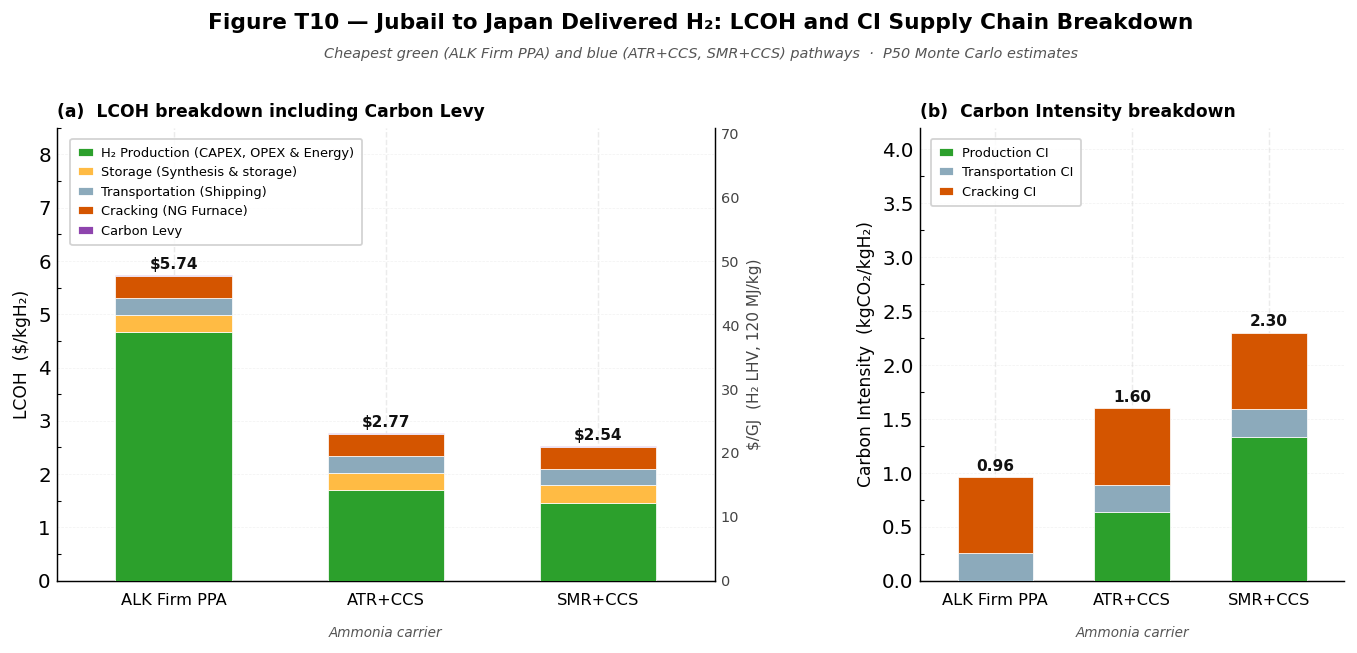

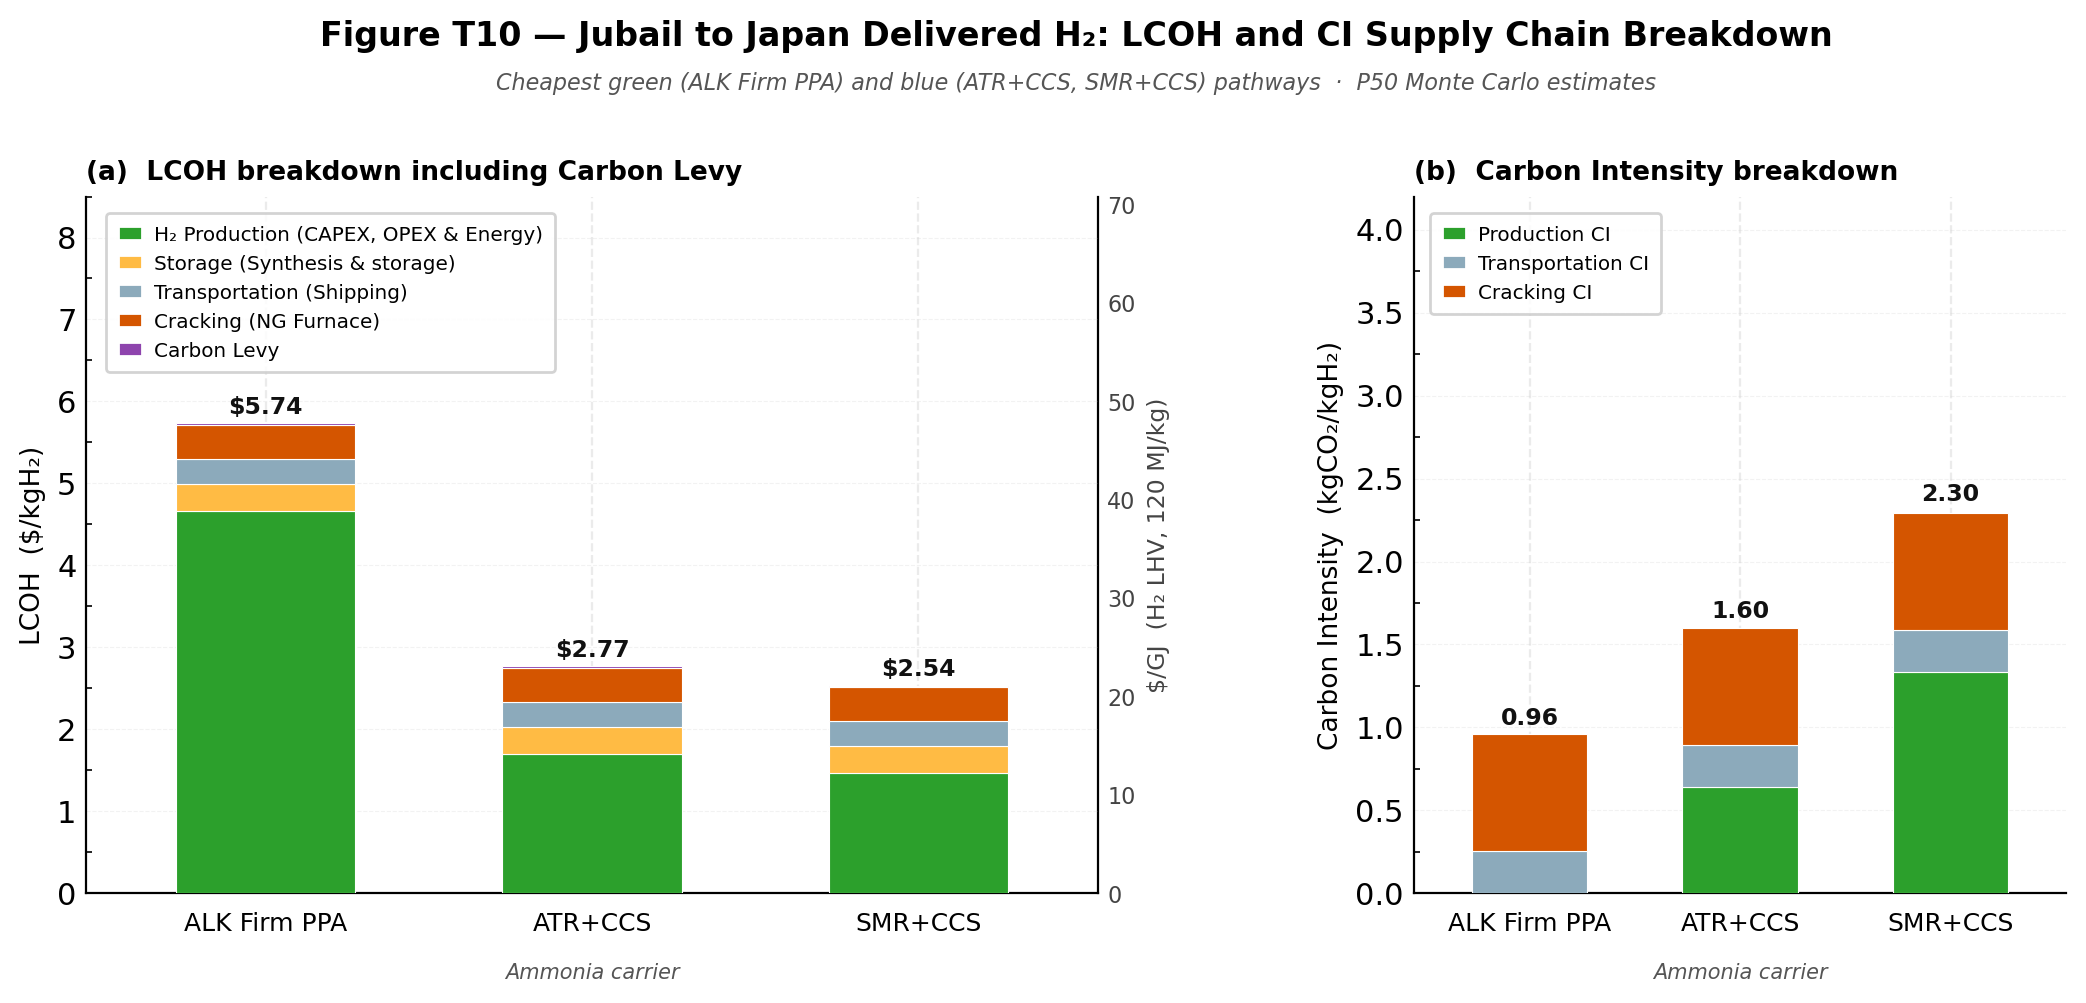

In [31]:
"""
Figure T10 — Japan Delivered H₂: LCOH and CI Supply Chain Breakdown
             (ALK Firm PPA, ATR+CCS, SMR+CCS · NH₃ · NG crack · Jubail→Japan)

Panel (a): Stacked LCOH bar — segments: H₂ Production | Storage (Synthesis & storage) |
           Transportation (Shipping) | Cracking (NG Furnace) | Carbon Levy
           Left axis: $/kgH₂  |  Right axis: $/GJ (LHV, 120 MJ/kgH₂)
Panel (b): Stacked CI bar  — segments: Production CI | Transportation CI | Cracking CI

All values at P50 (median) from the Monte Carlo sample.
"""
import IPython.display as _d
### === Merged from fig_t10_breakdown_ng_ja.py (single-notebook pipeline) ===
"""
fig_t10_breakdown_ng_ja.py
─────────────────────────────────────────────────────────────────────────────
Figure T10 — Japan Delivered H₂: LCOH and CI Breakdown by Supply Chain Stage
             (NH₃ pathway, NG cracking, Jubail→Japan)

Three pathways compared at P50:
  • ALK Firm PPA  · NH₃ · NG crack · JA   (cheapest green)
  • ATR+CCS       · NH₃ · NG crack · JA   (cheapest blue)
  • SMR+CCS       · NH₃ · NG crack · JA

Panel (a) — LCOH stacked bar ($/kgH₂), secondary axis $/GJ (H₂ LHV)
  Segments: Production | Storage (Synthesis & storage) | Transportation (Shipping) |
            Cracking (NG Furnace) | Carbon Levy

Panel (b) — Carbon Intensity stacked bar (kgCO₂/kgH₂)
  Segments: Production CI | Transportation CI | Cracking CI

Methodology note:
  Each segment's P50 is computed independently from the MC sample.
  The sum of medians is a slight approximation of the median of the sum, but differences are negligible for visualisation.
─────────────────────────────────────────────────────────────────────────────
"""

import os, sys, time, warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

# ── Load runner ───────────────────────────────────────────────────────────────
ctx = globals()

mc  = ctx['mc_results']
mi  = ctx['mc_inputs']

# ── Constants from runner context ─────────────────────────────────────────────
CRACK_YIELD_NG     = ctx['CRACK_YIELD_NG']
KG_NH3_PER_KG_H2  = ctx['KG_NH3_PER_KG_H2']
NM_TO_KM           = ctx['NM_TO_KM']
DIST_NM            = ctx['DIST_NM']
NG_KWH_PER_MMBTU   = ctx['NG_KWH_PER_MMBTU']
LHV_CH4_KWH_PER_KG = ctx['LHV_CH4_KWH_PER_KG']

LHV_GJ_PER_KG = 0.120

yn  = CRACK_YIELD_NG
DJA = DIST_NM['JA'] * NM_TO_KM

# ── Compute cost component arrays ─────────────────────────────────────────────

synth_arr = (mi['hb_elec_kwh_per_kgh2'].values * mi['solar_lcoe'].values
             + mi['hb_capex_opex_per_kgh2'].values) / yn

stor_arr  = mi['nh3_stor_cost_jubail'].values / yn

ship_arr  = (mi['nh3_ship_rate'].values * DJA / 1_000
             * KG_NH3_PER_KG_H2 / 1_000) / yn

crack_arr = (mi['ng_crack_kwh_th_per_kgh2'].values / NG_KWH_PER_MMBTU
             * mi['dest_ng_price_japan'].values
             + mi['ng_crack_capex_per_kgh2'].values)

jpn_cp_arr = mi['japan_carbon_price'].values
_ci_crack_ng_arr = mi['ng_crack_kwh_th_per_kgh2'].values / LHV_CH4_KWH_PER_KG * (44.0/16.0)
levy_alk = jpn_cp_arr * _ci_crack_ng_arr / 1_000   # NG-cracker combustion only
levy_atr = jpn_cp_arr * _ci_crack_ng_arr / 1_000
levy_smr = jpn_cp_arr * _ci_crack_ng_arr / 1_000

prod_alk = mc['alk_fppa_nh3_ng_ja'] - synth_arr - stor_arr - ship_arr - crack_arr
prod_atr = mc['atr_nh3_ng_ja']      - synth_arr - stor_arr - ship_arr - crack_arr
prod_smr = mc['smr_nh3_ng_ja']      - synth_arr - stor_arr - ship_arr - crack_arr

# ── Compute CI component arrays ───────────────────────────────────────────────

ci_ship_arr  = mi['nh3_ship_ei'].values * DJA * KG_NH3_PER_KG_H2 * 1e-6

ci_crack_arr = (mi['ng_crack_kwh_th_per_kgh2'].values
                / LHV_CH4_KWH_PER_KG * (44.0 / 16.0))

ci_prod_alk = mc['ci_alk_fppa_nh3_ng_ja'] - ci_ship_arr - ci_crack_arr
ci_prod_atr = mc['ci_atr_nh3_ng_ja']      - ci_ship_arr - ci_crack_arr
ci_prod_smr = mc['ci_smr_nh3_ng_ja']      - ci_ship_arr - ci_crack_arr

# ── Take P50 of every component ───────────────────────────────────────────────
def p50(arr):  return float(np.percentile(np.asarray(arr, float), 50))

S = {
    'prod_alk':  p50(prod_alk),
    'prod_atr':  p50(prod_atr),
    'prod_smr':  p50(prod_smr),
    'synth':     p50(synth_arr),
    'stor':      p50(stor_arr),
    'ship':      p50(ship_arr),
    'crack':     p50(crack_arr),
    'levy_alk':  p50(levy_alk),
    'levy_atr':  p50(levy_atr),
    'levy_smr':  p50(levy_smr),
    'ci_prod_alk':  p50(ci_prod_alk),
    'ci_prod_atr':  p50(ci_prod_atr),
    'ci_prod_smr':  p50(ci_prod_smr),
    'ci_ship':      p50(ci_ship_arr),
    'ci_crack':     p50(ci_crack_arr),
    'total_alk':    p50(mc['alk_fppa_nh3_ng_ja']),
    'total_atr':    p50(mc['atr_nh3_ng_ja']),
    'total_smr':    p50(mc['smr_nh3_ng_ja']),
    'ci_total_alk': p50(mc['ci_alk_fppa_nh3_ng_ja']),
    'ci_total_atr': p50(mc['ci_atr_nh3_ng_ja']),
    'ci_total_smr': p50(mc['ci_smr_nh3_ng_ja']),
}

print('\n── T10 P50 Cost Cross-check ─────────────────────────────')
for pw, pkey in [('ALK FirmPPA','alk'), ('ATR+CCS','atr'), ('SMR+CCS','smr')]:
    seg_sum = (S[f'prod_{pkey}'] + S['synth'] + S['stor'] + S['ship']
               + S['crack'] + S[f'levy_{pkey}'])
    p50_tot = S[f'total_{pkey}'] + S[f'levy_{pkey}']
    print(f'  {pw}: seg_sum=${seg_sum:.3f}  P50(total+levy)=${p50_tot:.3f}  '
          f'diff=${seg_sum-p50_tot:+.3f}')
print('── T10 P50 CI Cross-check ───────────────────────────────')
for pw, pkey in [('ALK FirmPPA','alk'), ('ATR+CCS','atr'), ('SMR+CCS','smr')]:
    seg_sum = S[f'ci_prod_{pkey}'] + S['ci_ship'] + S['ci_crack']
    p50_tot = S[f'ci_total_{pkey}']
    print(f'  {pw}: seg_sum={seg_sum:.3f}  P50(total)={p50_tot:.3f}  '
          f'diff={seg_sum-p50_tot:+.3f}')

# ── Colour palette ─────────────────────────────────────────────────────────────
C_PROD      = '#2ca02c'

C_STORAGE   = '#FFBB44'
C_TRANSPORT = '#8CAABB'
C_CRACK     = '#D45500'
C_LEVY      = '#8E44AD'

C_CI_TRANSPORT = C_TRANSPORT
C_CI_CRACK     = C_CRACK

# ── Build stacked data ────────────────────────────────────────────────────────
PATHWAYS = ['ALK Firm PPA', 'ATR+CCS', 'SMR+CCS']
x        = np.arange(len(PATHWAYS))
BAR_W    = 0.55

LCOH_SEGS = [
    ('H₂ Production (CAPEX, OPEX & Energy)', [S['prod_alk'], S['prod_atr'], S['prod_smr']],
     [C_PROD] * 3),
    ('Storage (Synthesis & storage)', [S['synth'] + S['stor']] * 3, [C_STORAGE]   * 3),
    ('Transportation (Shipping)',      [S['ship']]  * 3,            [C_TRANSPORT] * 3),
    ('Cracking (NG Furnace)',          [S['crack']] * 3,            [C_CRACK]     * 3),
    ('Carbon Levy',                   [S['levy_alk'], S['levy_atr'], S['levy_smr']],
     [C_LEVY] * 3),
]

CI_SEGS = [
    ('Production CI',     [S['ci_prod_alk'], S['ci_prod_atr'], S['ci_prod_smr']],
     [C_PROD] * 3),
    ('Transportation CI', [S['ci_ship']]  * 3, [C_CI_TRANSPORT] * 3),
    ('Cracking CI',       [S['ci_crack']] * 3, [C_CI_CRACK]     * 3),
]

lcoh_totals_w_levy = [
    S['total_alk'] + S['levy_alk'],
    S['total_atr'] + S['levy_atr'],
    S['total_smr'] + S['levy_smr'],
]
ci_totals = [S['ci_total_alk'], S['ci_total_atr'], S['ci_total_smr']]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(11, 5.2))
fig.patch.set_facecolor('white')

gs = fig.add_gridspec(1, 2, width_ratios=[1.55, 1.0],
                      left=0.07, right=0.97, bottom=0.14, top=0.81, wspace=0.38)
ax_l = fig.add_subplot(gs[0])
ax_r = fig.add_subplot(gs[1])

# ── Helper: draw a stacked bar panel ──────────────────────────────────────────
def draw_stacked(ax, x, segments, bar_w):
    bottoms = np.zeros(len(x))
    bar_handles = []
    for label, vals, colours in segments:
        vals = np.asarray(vals, float)
        ax.bar(x, vals, bar_w, bottom=bottoms,
               color=colours, edgecolor='white', linewidth=0.4, zorder=3)
        bottoms += vals
        bar_handles.append((label, colours[0]))
    return bar_handles

# ── Panel (a): LCOH breakdown ─────────────────────────────────────────────────
handles_l = draw_stacked(ax_l, x, LCOH_SEGS, BAR_W)

for xi, tot in zip(x, lcoh_totals_w_levy):
    ax_l.text(xi, tot + 0.05, f'${tot:.2f}',
              ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#111111')

ax_l.set_xlim(-0.55, len(PATHWAYS) - 0.45)
ax_l.set_ylim(0, 8.5)
ax_l.set_xticks(x)
ax_l.set_xticklabels(PATHWAYS, fontsize=9)
ax_l.set_ylabel('LCOH  ($/kgH₂)', fontsize=9.5)
ax_l.yaxis.set_minor_locator(MultipleLocator(0.5))
ax_l.tick_params(axis='y', which='both', direction='in')
ax_l.tick_params(axis='x', which='both', bottom=False)
ax_l.spines[['top', 'right']].set_visible(False)
ax_l.grid(axis='y', which='major', linewidth=0.4, color='#cccccc', zorder=0)
ax_l.set_title('(a)  LCOH breakdown including Carbon Levy', fontsize=9.5,
               loc='left', pad=6, fontweight='bold')

def lcoh_to_gj(y):  return y / LHV_GJ_PER_KG
def gj_to_lcoh(y):  return y * LHV_GJ_PER_KG

ax_l2 = ax_l.secondary_yaxis('right', functions=(lcoh_to_gj, gj_to_lcoh))
ax_l2.set_ylabel('$/GJ  (H₂ LHV, 120 MJ/kg)', fontsize=8.5, color='#444444')
ax_l2.tick_params(labelsize=8, colors='#444444')

lcoh_patches = [mpatches.Patch(facecolor=col, edgecolor='white', label=label)
                for label, col in handles_l]
ax_l.legend(handles=lcoh_patches, fontsize=7.2, framealpha=0.85, edgecolor='#cccccc',
            loc='upper left', bbox_to_anchor=(0.01, 0.99), ncol=1, handlelength=1.2,
            handletextpad=0.6, borderpad=0.6)

# ── Panel (b): CI breakdown ───────────────────────────────────────────────────
handles_r = draw_stacked(ax_r, x, CI_SEGS, BAR_W)

for xi, tot in zip(x, ci_totals):
    ax_r.text(xi, tot + 0.03, f'{tot:.2f}',
              ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#111111')

ax_r.set_xlim(-0.55, len(PATHWAYS) - 0.45)
ax_r.set_ylim(0, 4.2)
ax_r.set_xticks(x)
ax_r.set_xticklabels(PATHWAYS, fontsize=9)
ax_r.set_ylabel('Carbon Intensity  (kgCO₂/kgH₂)', fontsize=9.5)
ax_r.yaxis.set_minor_locator(MultipleLocator(0.25))
ax_r.tick_params(axis='y', which='both', direction='in')
ax_r.tick_params(axis='x', which='both', bottom=False)
ax_r.spines[['top', 'right']].set_visible(False)
ax_r.grid(axis='y', which='major', linewidth=0.4, color='#cccccc', zorder=0)
ax_r.set_title('(b)  Carbon Intensity breakdown', fontsize=9.5,
               loc='left', pad=6, fontweight='bold')

ci_patches = [mpatches.Patch(facecolor=col, edgecolor='white', label=label)
              for label, col in handles_r]
ax_r.legend(handles=ci_patches, fontsize=7.2, framealpha=0.85, edgecolor='#cccccc',
            loc='upper left', bbox_to_anchor=(0.01, 0.99), ncol=1, handlelength=1.2,
            handletextpad=0.6, borderpad=0.6)

# ── Sub-label under each panel ────────────────────────────────────────────────
for ax in (ax_l, ax_r):
    ax.text(0.5, -0.10, 'Ammonia carrier',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=7.5, color='#555555', fontstyle='italic')

# ── Main title ────────────────────────────────────────────────────────────────
X_CTR = (0.07 + 0.97) / 2
fig.suptitle(
    'Figure T10 — Jubail to Japan Delivered H₂: LCOH and CI Supply Chain Breakdown',
    fontsize=12.0, x=X_CTR, y=0.980, ha='center', fontweight='bold')
fig.text(X_CTR, 0.930,
         'Cheapest green (ALK Firm PPA) and blue (ATR+CCS, SMR+CCS) pathways  ·  P50 Monte Carlo estimates',
         ha='center', va='top', fontsize=8.0, color='#555555', fontstyle='italic')

# ── Save ──────────────────────────────────────────────────────────────────────
out = 'figures/fig_T10_breakdown_ng_ja.png'
plt.show()

_d.display(_d.Image("figures/fig_T10_breakdown_ng_ja.png"))

Loading runner …
Running Sobol sampling: N=8,192, D=57, evaluations≈483,328 …
  [reuse] Saltelli evaluations from Section 4.2 - no recompute
  Model evaluated in 0.0s

  Top 10 S1 for ALK Firm PPA  (green):
    firm_lcoe                           S1=0.516  ST=0.516
    alk_capex                           S1=0.389  ST=0.391
    alk_sec                             S1=0.032  ST=0.032
    wacc                                S1=0.013  ST=0.013
    alk_degrad_per_khr                  S1=0.010  ST=0.010
    ng_crack_capex_per_kgh2             S1=0.010  ST=0.010
    alk_stack_replace_frac              S1=0.006  ST=0.007
    dest_ng_price_rott                  S1=0.006  ST=0.006
    nh3_ship_rate                       S1=0.005  ST=0.005
    hb_capex_opex_per_kgh2              S1=0.005  ST=0.005

  Top 10 S1 for ATR+CCS  (blue):
    atr_capex                           S1=0.595  ST=0.595
    ng_price                            S1=0.116  ST=0.116
    ccs_cost                            S1=0.090  S

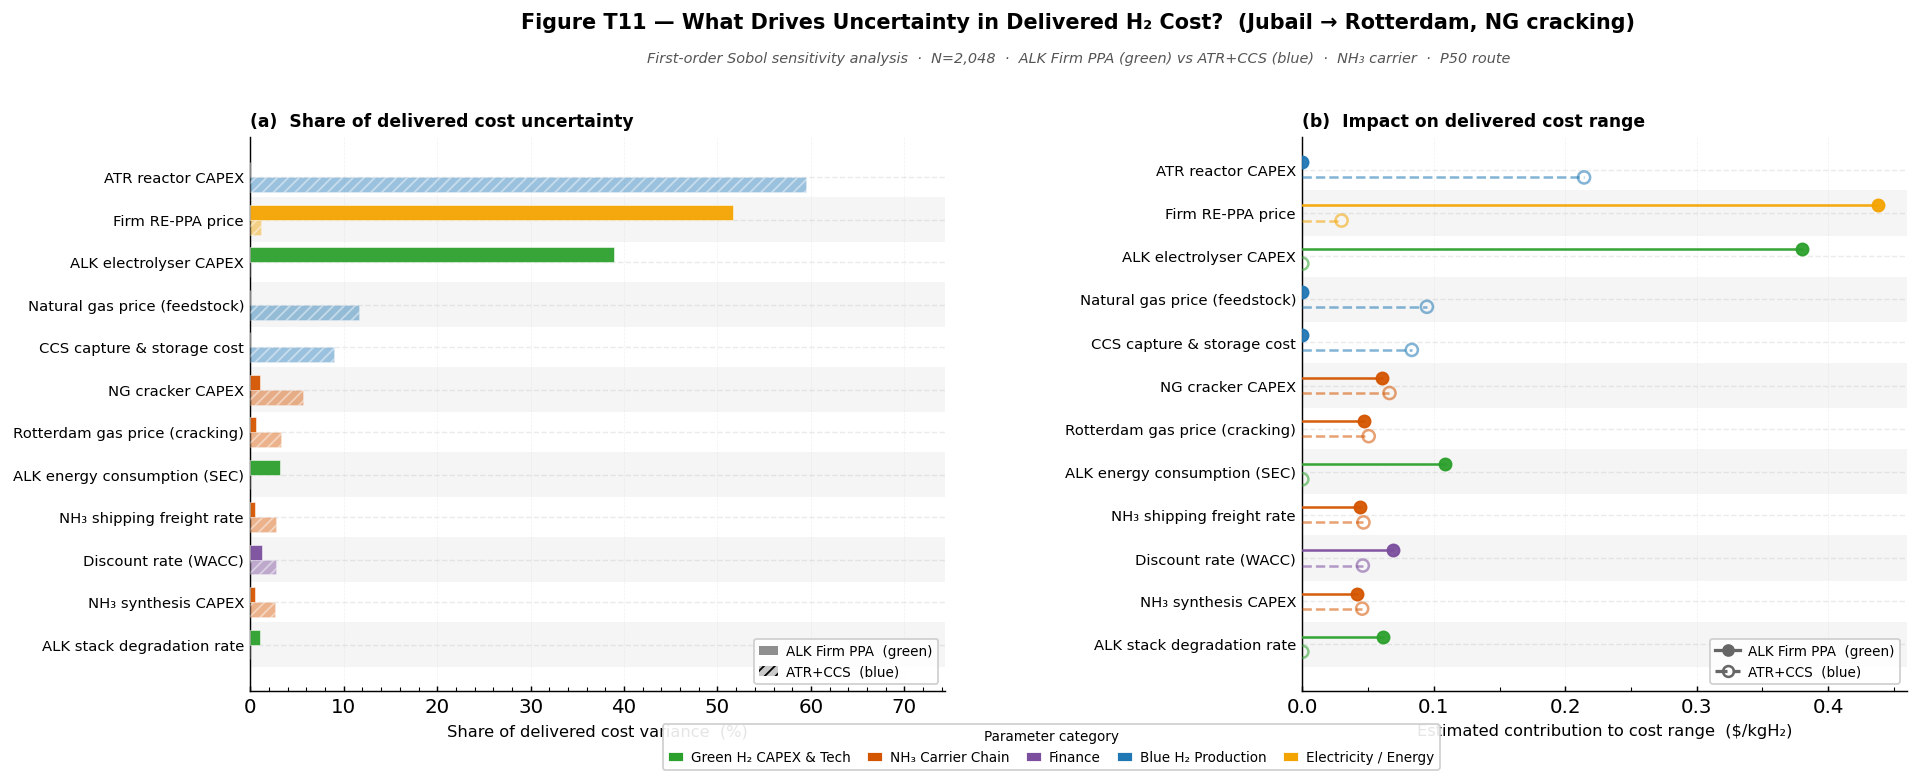

In [32]:
### === Merged from fig_t11_sobol_accessible.py (single-notebook pipeline) ===
"""
fig_t11_sobol_accessible.py
─────────────────────────────────────────────────────────────────────────────
Figure T11 — What Drives Uncertainty in Delivered H₂ Cost?
             Accessible Sobol Sensitivity Analysis (Jubail → Rotterdam, NG cracking)

Two pathways:
  • ALK Firm PPA  · NH₃ · NG crack · JR   (cheapest green, from T9)
  • ATR+CCS       · NH₃ · NG crack · JR   (cheapest blue,  from T9)

Panel (a) — "Share of cost variance explained"
  Grouped horizontal bars showing first-order Sobol index S1 (×100 = %)
  Interpretation: a longer bar means this parameter alone explains more of
  the uncertainty in delivered H₂ cost.

Panel (b) — "How much does each parameter affect the cost range?"
  Estimated dollar contribution to the interquartile spread: √S1 × IQR
  Interpretation: if this parameter were perfectly known, the delivered
  cost range would narrow by approximately this many $/kgH₂.

Sobol method:
  Saltelli sampling, N=8,192, D=57 parameters - 483,328 model evaluations.
  First-order indices (S1) only; independent-parameter assumption.
  
─────────────────────────────────────────────────────────────────────────────
"""

import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from scipy.stats import triang as _triang_dist

# ── Load runner ───────────────────────────────────────────────────────────────
print("Loading runner …")
ctx = globals()

mc  = ctx['mc_results']
mi  = ctx['mc_inputs']
run_monte_carlo   = ctx['run_monte_carlo']
PARAMS            = ctx['PARAMS']
LOGNORMAL_PARAMS  = ctx['LOGNORMAL_PARAMS']
PERT_PARAMS       = ctx['PERT_PARAMS']
_lognormal_ppf    = ctx['_lognormal_ppf']
_pert_ppf         = ctx['_pert_ppf']

# ── Sobol sampling ────────────────────────────────────────────────────────────
from SALib.sample import sobol as _sobol_sampler
from SALib.analyze import sobol as _sobol_analyzer

_s_names  = list(PARAMS.keys())
_s_bounds = [[v[0], v[2]] for v in PARAMS.values()]
D         = len(_s_names)
SOBOL_N   = 8192

print(f"Running Sobol sampling: N={SOBOL_N:,}, D={D}, evaluations≈{SOBOL_N*(D+2):,} …")
t0 = time.time()

_problem_unit = {'num_vars': D, 'names': _s_names, 'bounds': [[0, 1]] * D}
_problem      = {'num_vars': D, 'names': _s_names, 'bounds': _s_bounds}
if '_salt_res' in ctx and len(ctx['_salt_res']) == SOBOL_N * (D + 2):
    _salt_res = ctx['_salt_res']
    print('  [reuse] Saltelli evaluations from Section 4.2 - no recompute')
else:
    _salt_u       = _sobol_sampler.sample(_problem_unit, SOBOL_N, calc_second_order=False)

    _salt_t = np.empty_like(_salt_u)
    for _j, (_nm, (_a, _c, _b)) in enumerate(PARAMS.items()):
        _u_j = np.clip(_salt_u[:, _j], 1e-9, 1 - 1e-9)
        if _nm in LOGNORMAL_PARAMS:
            _salt_t[:, _j] = _lognormal_ppf(_u_j, _a, _c, _b)
        elif _nm in PERT_PARAMS:
            _salt_t[:, _j] = _pert_ppf(_u_j, _a, _c, _b)
        else:
            _salt_t[:, _j] = _triang_dist(
                c=(_c - _a) / (_b - _a), loc=_a, scale=_b - _a).ppf(_u_j)

    _salt_df  = pd.DataFrame(_salt_t, columns=_s_names)
    _salt_res = run_monte_carlo(_salt_df)
print(f"  Model evaluated in {time.time()-t0:.1f}s")

# ── Analyse outputs: ALK FirmPPA and ATR+CCS, NG crack JR ────────────────────
OUTPUTS = {
    'green': ('alk_fppa_nh3_ng_jr', 'ALK Firm PPA  (green)'),
    'blue':  ('atr_nh3_ng_jr',      'ATR+CCS  (blue)'),
}

S1 = {}; ST = {}
for key, (col, lbl) in OUTPUTS.items():
    _Y  = _salt_res[col].values
    _Si = _sobol_analyzer.analyze(_problem, _Y,
                                   calc_second_order=False, print_to_console=False)
    S1[key] = {n: max(float(v), 0) for n, v in zip(_s_names, _Si['S1'])}
    ST[key] = {n: max(float(v), 0) for n, v in zip(_s_names, _Si['ST'])}
    print(f"\n  Top 10 S1 for {lbl}:")
    for n, v in sorted(S1[key].items(), key=lambda x: -x[1])[:10]:
        print(f"    {n:<35} S1={v:.3f}  ST={ST[key][n]:.3f}")

# ── IQR of each pathway from the base MC run (for $/kgH₂ panel) ──────────────
IQR = {
    'green': float(np.percentile(mc['alk_fppa_nh3_ng_jr'], 75)
                 - np.percentile(mc['alk_fppa_nh3_ng_jr'], 25)),
    'blue':  float(np.percentile(mc['atr_nh3_ng_jr'], 75)
                 - np.percentile(mc['atr_nh3_ng_jr'], 25)),
}
print(f"\n  IQR green={IQR['green']:.3f}  blue={IQR['blue']:.3f} $/kgH₂")

# ── Parameter metadata: friendly labels and category colours ─────────────────
PARAM_LABELS = {
    'firm_lcoe':                'Firm RE-PPA price',
    'solar_lcoe':               'Solar electricity cost',
    'cf_solar':                 'Solar capacity factor',
    'alk_capex':                'ALK electrolyser CAPEX',
    'alk_sec':                  'ALK energy consumption (SEC)',
    'alk_degrad_per_khr':       'ALK stack degradation rate',
    'alk_stack_lifetime_khr':   'ALK stack lifetime',
    'alk_stack_replace_frac':   'ALK stack replacement cost',
    'wacc':                     'Discount rate (WACC)',
    'ng_price':                 'Natural gas price (feedstock)',
    'atr_capex':                'ATR reactor CAPEX',
    'atr_eff':                  'ATR conversion efficiency',
    'atr_capture':              'ATR CO₂ capture rate',
    'ccs_cost':                 'CCS capture & storage cost',
    'ch4_leakage':              'Methane leakage rate',
    'smr_capex':                'SMR reactor CAPEX',
    'smr_eff':                  'SMR conversion efficiency',
    'smr_capture':              'SMR CO₂ capture rate',
    'dest_ng_price_rott':       'Rotterdam gas price (cracking)',
    'ng_crack_kwh_th_per_kgh2': 'NG cracker energy intensity',
    'ng_crack_capex_per_kgh2':  'NG cracker CAPEX',
    'nh3_ship_rate':            'NH₃ shipping freight rate',
    'hb_elec_kwh_per_kgh2':     'NH₃ synthesis energy',
    'hb_capex_opex_per_kgh2':   'NH₃ synthesis CAPEX',
    'nh3_stor_cost_jubail':     'NH₃ export storage (Jubail)',
    'eu_carbon_price':          'EU carbon price (CBAM/ETS)',
    'rott_grid_elec_price':     'Rotterdam grid electricity',
    'bess_cost_per_kwh':        'Battery storage cost (BESS)',
    'pem_capex':                'PEM electrolyser CAPEX',
    'pem_sec':                  'PEM energy consumption (SEC)',
    'lh2_liq_kwh_per_kgh2':     'LH₂ liquefaction energy',
    'lh2_liq_capex_opex_per_kgh2': 'LH₂ liquefaction CAPEX',
}

CATEGORIES = {
    'firm_lcoe':                ('Electricity / Energy',    '#F4A400'),
    'solar_lcoe':               ('Electricity / Energy',    '#F4A400'),
    'cf_solar':                 ('Electricity / Energy',    '#F4A400'),
    'rott_grid_elec_price':     ('Electricity / Energy',    '#F4A400'),
    'alk_capex':                ('Green H₂ CAPEX & Tech',   '#2ca02c'),
    'alk_sec':                  ('Green H₂ CAPEX & Tech',   '#2ca02c'),
    'alk_degrad_per_khr':       ('Green H₂ CAPEX & Tech',   '#2ca02c'),
    'alk_stack_lifetime_khr':   ('Green H₂ CAPEX & Tech',   '#2ca02c'),
    'alk_stack_replace_frac':   ('Green H₂ CAPEX & Tech',   '#2ca02c'),
    'pem_capex':                ('Green H₂ CAPEX & Tech',   '#2ca02c'),
    'pem_sec':                  ('Green H₂ CAPEX & Tech',   '#2ca02c'),
    'bess_cost_per_kwh':        ('Green H₂ CAPEX & Tech',   '#2ca02c'),
    'wacc':                     ('Finance',                  '#7B4E9E'),
    'ng_price':                 ('Blue H₂ Production',       '#1f77b4'),
    'atr_capex':                ('Blue H₂ Production',       '#1f77b4'),
    'atr_eff':                  ('Blue H₂ Production',       '#1f77b4'),
    'atr_capture':              ('Blue H₂ Production',       '#1f77b4'),
    'ccs_cost':                 ('Blue H₂ Production',       '#1f77b4'),
    'ch4_leakage':              ('Blue H₂ Production',       '#1f77b4'),
    'smr_capex':                ('Blue H₂ Production',       '#1f77b4'),
    'smr_eff':                  ('Blue H₂ Production',       '#1f77b4'),
    'smr_capture':              ('Blue H₂ Production',       '#1f77b4'),
    'dest_ng_price_rott':       ('NH₃ Carrier Chain',        '#D45500'),
    'ng_crack_kwh_th_per_kgh2': ('NH₃ Carrier Chain',        '#D45500'),
    'ng_crack_capex_per_kgh2':  ('NH₃ Carrier Chain',        '#D45500'),
    'nh3_ship_rate':            ('NH₃ Carrier Chain',        '#D45500'),
    'hb_elec_kwh_per_kgh2':     ('NH₃ Carrier Chain',        '#D45500'),
    'hb_capex_opex_per_kgh2':   ('NH₃ Carrier Chain',        '#D45500'),
    'nh3_stor_cost_jubail':     ('NH₃ Carrier Chain',        '#D45500'),
    'eu_carbon_price':          ('Carbon / Policy',          '#C00000'),
}

def cat_col(param):
    return CATEGORIES.get(param, ('Other', '#999999'))[1]

def cat_label(param):
    return CATEGORIES.get(param, ('Other', '#999999'))[0]

def friendly(param):
    return PARAM_LABELS.get(param, param.replace('_', ' ').title())

# ── Select top parameters ─────────────────────────────────────────────────────
TOP_N = 12
top_green = sorted(S1['green'], key=lambda p: -S1['green'][p])[:TOP_N]
top_blue  = sorted(S1['blue'],  key=lambda p: -S1['blue'][p])[:TOP_N]
all_params = list(dict.fromkeys(top_green + top_blue))

all_params = sorted(all_params,
                    key=lambda p: -max(S1['green'].get(p, 0), S1['blue'].get(p, 0)))[:TOP_N]

params_plot = list(reversed(all_params))

# ── Build plot data ───────────────────────────────────────────────────────────
s1_g  = [S1['green'].get(p, 0) * 100 for p in params_plot]
s1_b  = [S1['blue'].get(p, 0)  * 100 for p in params_plot]
dol_g = [np.sqrt(S1['green'].get(p, 0)) * IQR['green'] for p in params_plot]
dol_b = [np.sqrt(S1['blue'].get(p, 0))  * IQR['blue']  for p in params_plot]
labels = [friendly(p) for p in params_plot]
colours = [cat_col(p) for p in params_plot]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6.0))
fig.patch.set_facecolor('white')

gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1.0],
                      left=0.06, right=0.97, bottom=0.11, top=0.82, wspace=0.55)
ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])

y = np.arange(len(params_plot))
BAR_H = 0.35

# ── Panel (a): % variance explained ──────────────────────────────────────────
bars_g = ax_a.barh(y + BAR_H/2, s1_g, BAR_H,
                   color=colours, alpha=0.95, edgecolor='white', linewidth=0.3,
                   label='ALK Firm PPA (green)', zorder=3)
bars_b = ax_a.barh(y - BAR_H/2, s1_b, BAR_H,
                   color=colours, alpha=0.45, edgecolor='white', linewidth=0.3,
                   label='ATR+CCS (blue)', zorder=3,
                   hatch='////')

for i in range(len(params_plot)):
    if i % 2 == 0:
        ax_a.axhspan(i - 0.5, i + 0.5, color='#f5f5f5', zorder=0)

ax_a.set_yticks(y)
ax_a.set_yticklabels(labels, fontsize=8.2)
ax_a.set_xlabel('Share of delivered cost variance  (%)', fontsize=9)
ax_a.set_xlim(0, min(max(max(s1_g), max(s1_b)) * 1.25, 100))
ax_a.xaxis.set_minor_locator(MultipleLocator(2))
ax_a.tick_params(axis='x', which='both', direction='in')
ax_a.spines[['top', 'right']].set_visible(False)
ax_a.grid(axis='x', which='major', linewidth=0.4, color='#cccccc', zorder=0)
ax_a.set_title('(a)  Share of delivered cost uncertainty', fontsize=9.5,
               loc='left', pad=6, fontweight='bold')

leg_green = mpatches.Patch(facecolor='#888888', alpha=0.95,
                            label='ALK Firm PPA  (green)')
leg_blue  = mpatches.Patch(facecolor='#888888', alpha=0.45, hatch='////',
                            label='ATR+CCS  (blue)')
ax_a.legend(handles=[leg_green, leg_blue], fontsize=7.5,
            loc='lower right', framealpha=0.9, edgecolor='#cccccc',
            handlelength=1.4, handletextpad=0.6)

# ── Panel (b): $/kgH₂ contribution ───────────────────────────────────────────
for i, (dg, db, col) in enumerate(zip(dol_g, dol_b, colours)):
    ax_b.plot([0, dg], [i + BAR_H/2, i + BAR_H/2],
              color=col, lw=1.4, alpha=0.95, zorder=3, solid_capstyle='round')
    ax_b.scatter(dg, i + BAR_H/2, color=col, s=45, zorder=4, alpha=0.95)
    ax_b.plot([0, db], [i - BAR_H/2, i - BAR_H/2],
              color=col, lw=1.4, alpha=0.55, zorder=3, solid_capstyle='round',
              linestyle='--')
    ax_b.scatter(db, i - BAR_H/2, color=col, s=45, zorder=4, alpha=0.55,
                 facecolors='none', edgecolors=col, linewidths=1.4)

for i in range(len(params_plot)):
    if i % 2 == 0:
        ax_b.axhspan(i - 0.5, i + 0.5, color='#f5f5f5', zorder=0)

ax_b.set_yticks(y)
ax_b.set_yticklabels(labels, fontsize=8.2)
ax_b.set_xlabel('Estimated contribution to cost range  ($/kgH₂)', fontsize=9)
ax_b.set_xlim(left=0)
ax_b.xaxis.set_minor_locator(MultipleLocator(0.05))
ax_b.tick_params(axis='x', which='both', direction='in')
ax_b.spines[['top', 'right']].set_visible(False)
ax_b.grid(axis='x', which='major', linewidth=0.4, color='#cccccc', zorder=0)
ax_b.set_title('(b)  Impact on delivered cost range', fontsize=9.5,
               loc='left', pad=6, fontweight='bold')

leg_g2 = plt.Line2D([0], [0], color='#666666', lw=1.8, marker='o',
                     markersize=6, label='ALK Firm PPA  (green)')
leg_b2 = plt.Line2D([0], [0], color='#666666', lw=1.8, marker='o',
                     markersize=6, linestyle='--', markerfacecolor='none',
                     markeredgewidth=1.4, label='ATR+CCS  (blue)')
ax_b.legend(handles=[leg_g2, leg_b2], fontsize=7.5,
            loc='lower right', framealpha=0.9, edgecolor='#cccccc',
            handlelength=1.8, handletextpad=0.6)

# ── Category colour legend (shared, below both panels) ───────────────────────
seen = {}
for p in params_plot:
    lbl = cat_label(p);  col = cat_col(p)
    if lbl not in seen:
        seen[lbl] = col
cat_patches = [mpatches.Patch(facecolor=col, edgecolor='white', label=lbl)
               for lbl, col in seen.items()]
fig.legend(handles=cat_patches, ncol=len(cat_patches),
           loc='lower center', bbox_to_anchor=(0.5, 0.00),
           fontsize=7.5, framealpha=0.9, edgecolor='#cccccc',
           handlelength=1.2, handletextpad=0.5, columnspacing=1.2,
           title='Parameter category', title_fontsize=7.5)

# ── Main title ────────────────────────────────────────────────────────────────
X_CTR = (0.06 + 0.97) / 2
fig.suptitle(
    'Figure T11 — What Drives Uncertainty in Delivered H₂ Cost?  (Jubail → Rotterdam, NG cracking)',
    fontsize=11.5, x=X_CTR, y=0.980, ha='center', fontweight='bold')
fig.text(X_CTR, 0.930,
         'First-order Sobol sensitivity analysis  ·  N=2,048  ·  '
         'ALK Firm PPA (green) vs ATR+CCS (blue)  ·  NH₃ carrier  ·  P50 route',
         ha='center', va='top', fontsize=8.0, color='#555555', fontstyle='italic')

# ── Save ──────────────────────────────────────────────────────────────────────
out = 'figures/fig_T11_sobol_accessible.png'
plt.show()

Loading runner …

Saltelli sampling  N=8,192  D=57  → 483,328 model evals …
  [reuse] Saltelli evaluations from Section 4.2 - no recompute
  Done in 0.0s

Analysing Sobol indices …
  lcoh_alk                        top: alk_capex(0.80)  solar_lcoe(0.07)  cf_solar(0.07)
  alk_nh3_ng_jr                   top: alk_capex(0.79)  solar_lcoe(0.08)  cf_solar(0.07)
  alk_fppa_nh3_ng_jr              top: firm_lcoe(0.52)  alk_capex(0.39)  alk_sec(0.03)
  alk_nh3_ng_ja                   top: alk_capex(0.79)  solar_lcoe(0.08)  cf_solar(0.07)
  alk_fppa_nh3_ng_ja              top: firm_lcoe(0.52)  alk_capex(0.39)  alk_sec(0.03)
  lcoh_atr                        top: atr_capex(0.70)  ng_price(0.14)  ccs_cost(0.11)
  lcoh_smr                        top: smr_capex(0.50)  ng_price(0.27)  ccs_cost(0.18)
  atr_ng_cadj_jr                  top: atr_capex(0.58)  ng_price(0.11)  ccs_cost(0.09)
  smr_ng_cadj_jr                  top: smr_capex(0.37)  ng_price(0.20)  ccs_cost(0.13)
  atr_ng_cadj_ja              

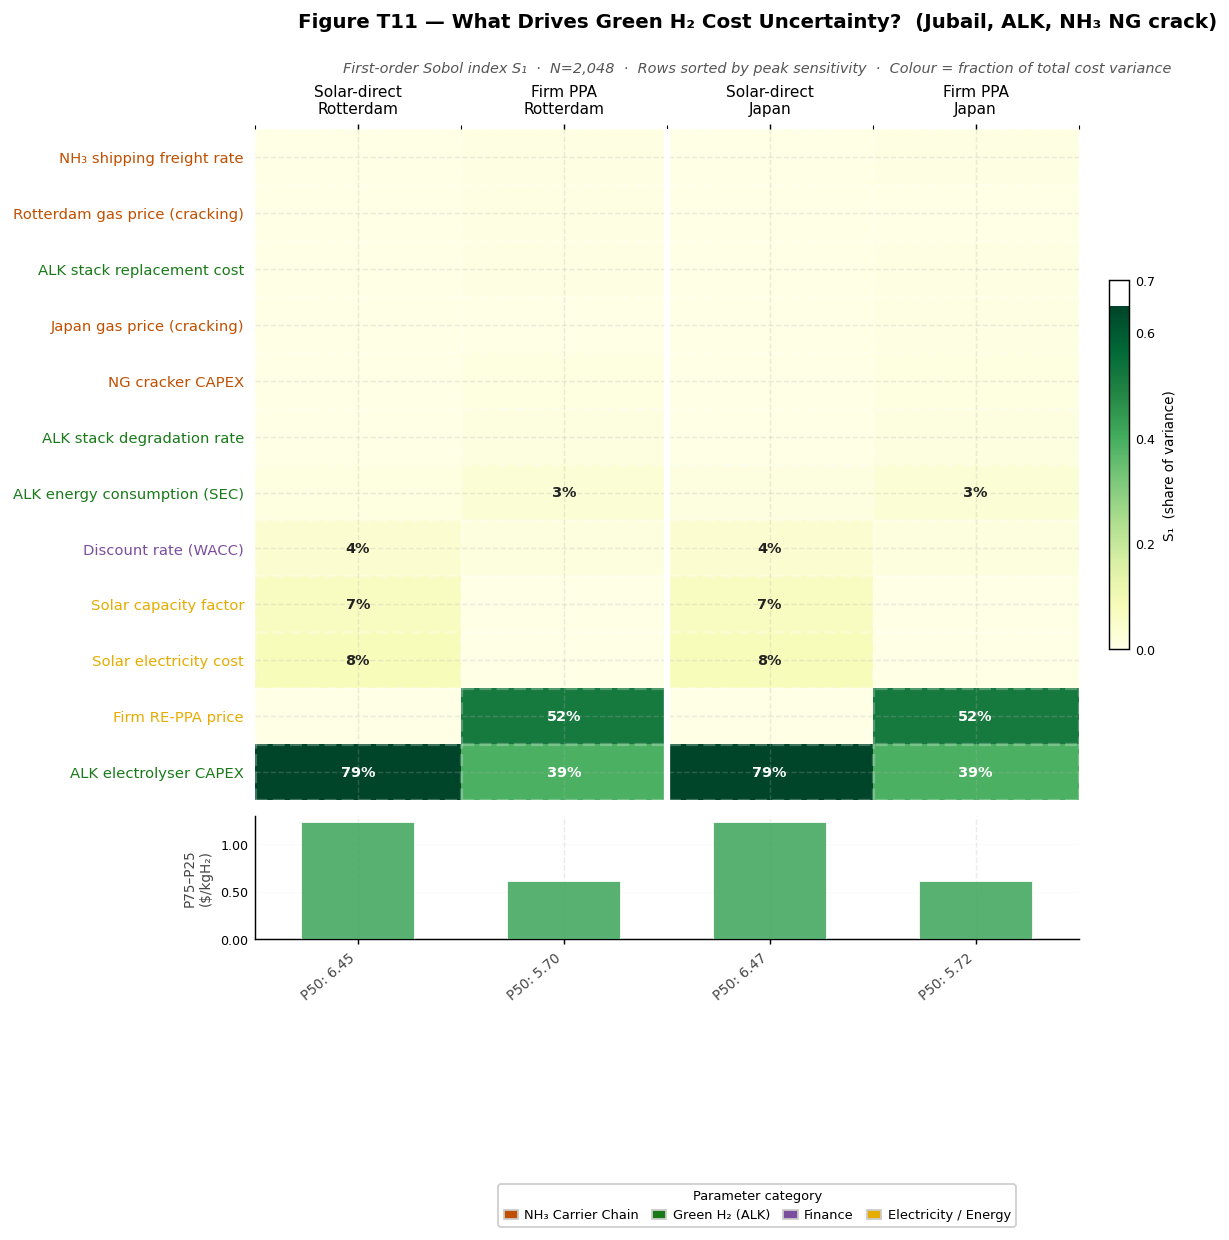

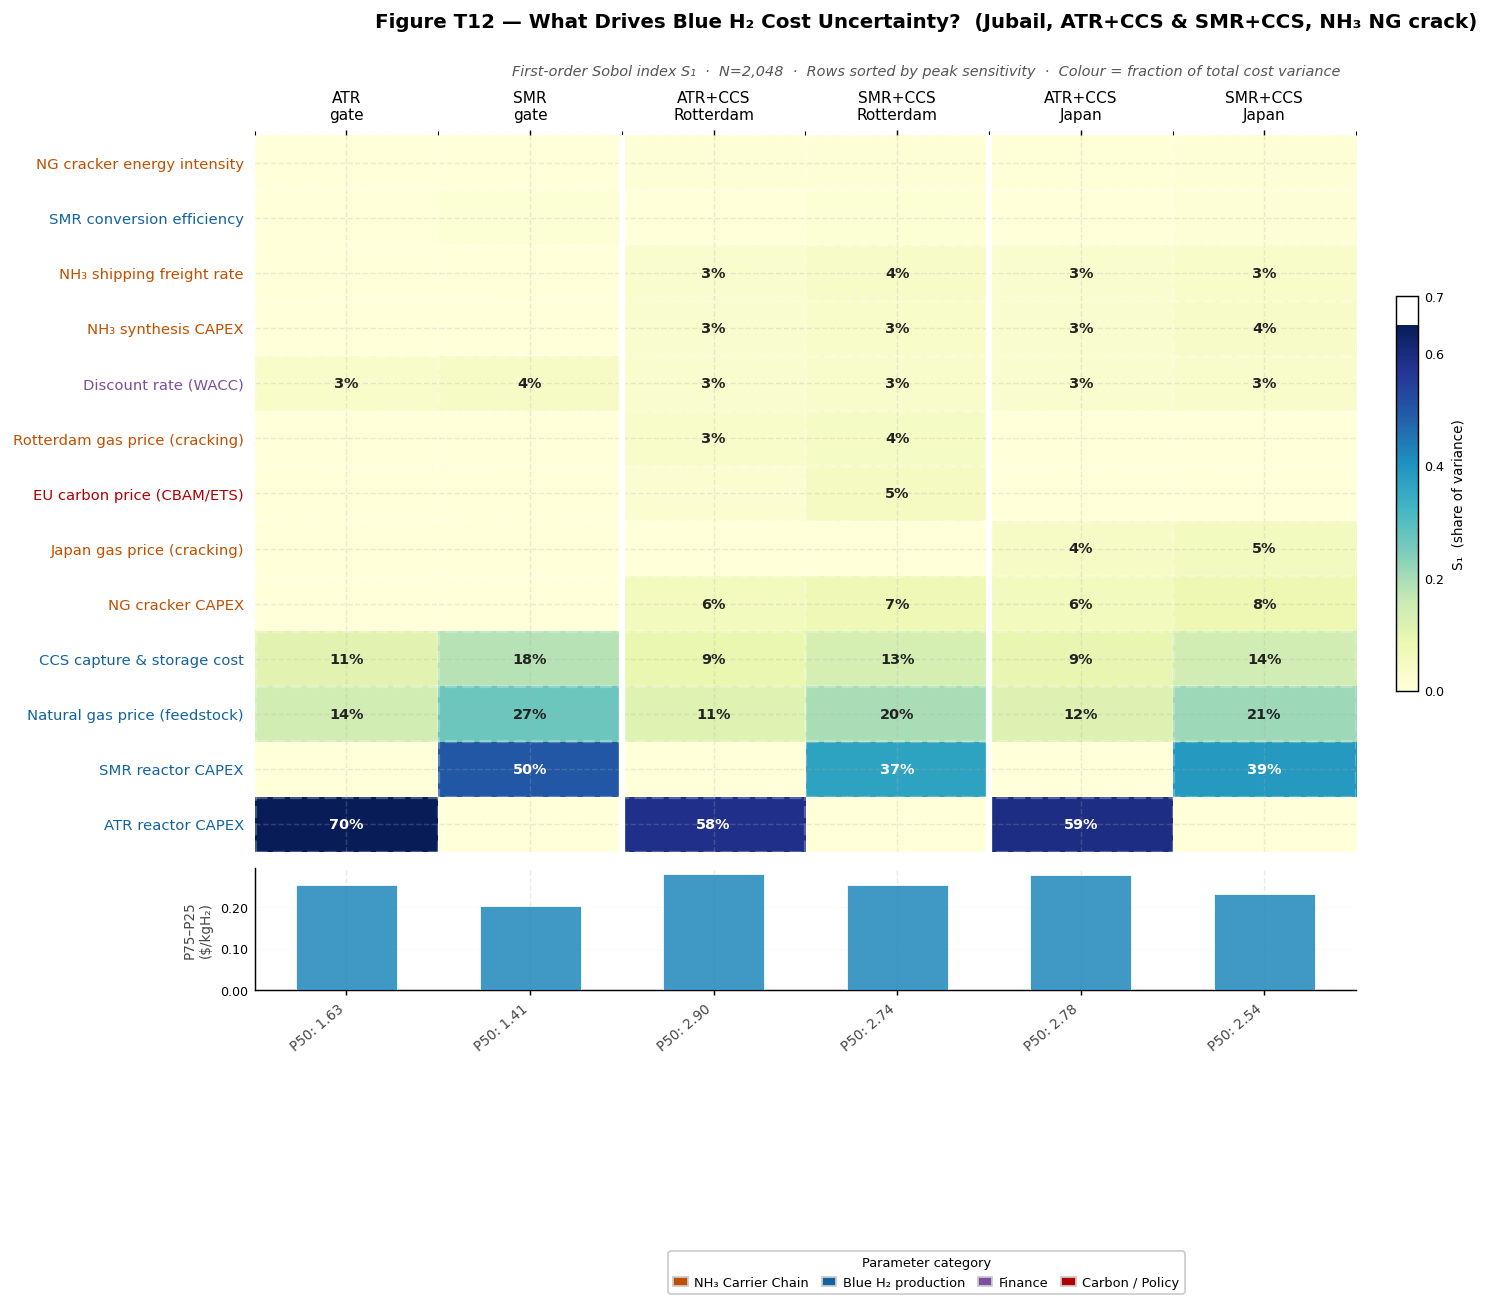

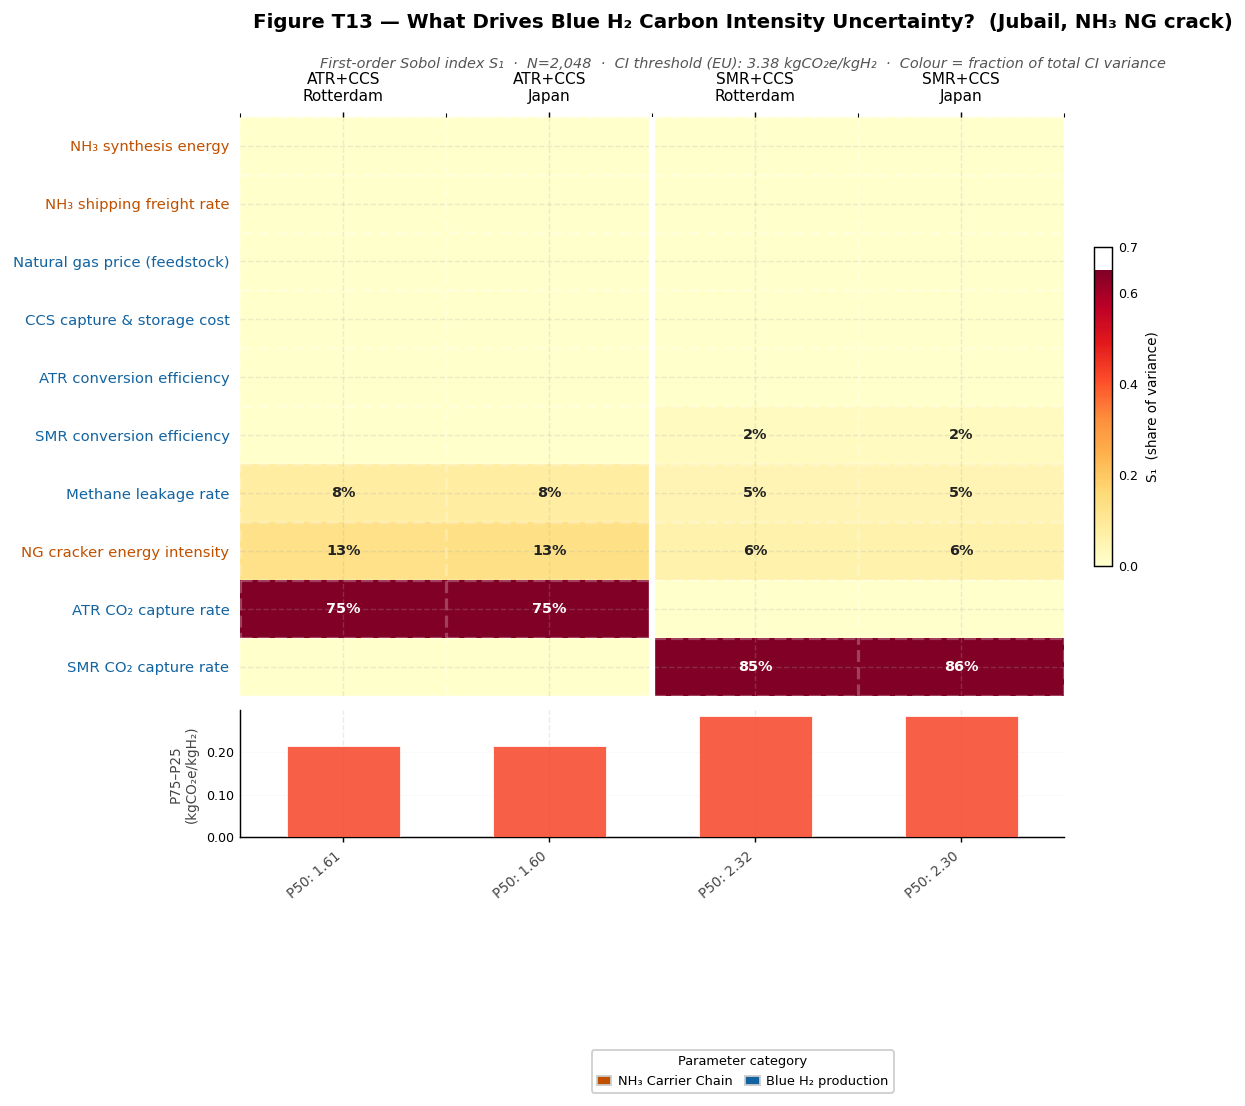

'figures/fig_T13_sobol_heatmap.png'

In [33]:
### === Merged from fig_t11_t12_t13_sobol_heatmaps.py (single-notebook pipeline) ===
"""
fig_t11_t12_t13_sobol_heatmaps.py
─────────────────────────────────────────────────────────────────────────────
Three Sobol sensitivity heatmaps (Jubail → Rotterdam & Japan, NH₃ NG crack)

  T11 — Green H₂ LCOH   : ALK, solar-direct vs Firm PPA, production gate →
                           delivered Rotterdam / Japan
  T12 — Blue H₂ LCOH    : ATR+CCS and SMR+CCS, production gate →
                           delivered Rotterdam / Japan (incl. CBAM / carbon levy)
  T13 — Blue H₂ CI      : Carbon intensity drivers for ATR+CCS and SMR+CCS
                           across Rotterdam and Japan routes

Heatmap rows  = parameters (sorted by max S₁ across columns)
Heatmap cols  = model outputs at different supply-chain stages / routes
Cell colour   = first-order Sobol index S₁  (fraction of total variance)
Cell label    = integer % when S₁ > 2 %, blank otherwise

Saltelli Sobol sampling: N=8,192 shared across all outputs.
─────────────────────────────────────────────────────────────────────────────
"""

import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy.stats import triang as _triang_dist
from SALib.sample import sobol as _sobol_sampler
from SALib.analyze import sobol as _sobol_analyzer

warnings.filterwarnings('ignore')

print("Loading runner …")
ctx = globals()

mc               = ctx['mc_results']
run_monte_carlo  = ctx['run_monte_carlo']
PARAMS           = ctx['PARAMS']
LOGNORMAL_PARAMS = ctx['LOGNORMAL_PARAMS']
PERT_PARAMS      = ctx['PERT_PARAMS']
_lognormal_ppf   = ctx['_lognormal_ppf']
_pert_ppf        = ctx['_pert_ppf']

_s_names  = list(PARAMS.keys())
_s_bounds = [[v[0], v[2]] for v in PARAMS.values()]
D         = len(_s_names)
SOBOL_N   = 8192

print(f"\nSaltelli sampling  N={SOBOL_N:,}  D={D}  "
      f"→ {SOBOL_N*(D+2):,} model evals …")
t0 = time.time()

_problem_unit = {'num_vars': D, 'names': _s_names, 'bounds': [[0, 1]] * D}
_problem      = {'num_vars': D, 'names': _s_names, 'bounds': _s_bounds}
if '_salt_res' in ctx and len(ctx['_salt_res']) == SOBOL_N * (D + 2):
    _salt_res = ctx['_salt_res']
    print('  [reuse] Saltelli evaluations from Section 4.2 - no recompute')
else:
    _salt_u       = _sobol_sampler.sample(_problem_unit, SOBOL_N,
                                           calc_second_order=False)

    _salt_t = np.empty_like(_salt_u)
    for _j, (_nm, (_a, _c, _b)) in enumerate(PARAMS.items()):
        _u = np.clip(_salt_u[:, _j], 1e-9, 1 - 1e-9)
        if _nm in LOGNORMAL_PARAMS:
            _salt_t[:, _j] = _lognormal_ppf(_u, _a, _c, _b)
        elif _nm in PERT_PARAMS:
            _salt_t[:, _j] = _pert_ppf(_u, _a, _c, _b)
        else:
            _salt_t[:, _j] = _triang_dist(
                c=(_c-_a)/(_b-_a), loc=_a, scale=_b-_a).ppf(_u)

    _salt_df  = pd.DataFrame(_salt_t, columns=_s_names)
    _salt_res = run_monte_carlo(_salt_df)
print(f"  Done in {time.time()-t0:.1f}s")

ALL_OUTPUTS = [
    # ── T11 green LCOH ──────────────────────────────────────────────────
    'lcoh_alk',
    'alk_nh3_ng_jr',
    'alk_fppa_nh3_ng_jr',
    'alk_nh3_ng_ja',
    'alk_fppa_nh3_ng_ja',
    # ── T12 blue LCOH ───────────────────────────────────────────────────
    'lcoh_atr',
    'lcoh_smr',
    'atr_ng_cadj_jr',
    'smr_ng_cadj_jr',
    'atr_ng_cadj_ja',
    'smr_ng_cadj_ja',
    # ── T13 blue CI ─────────────────────────────────────────────────────
    'ci_atr_nh3_ng_jr',
    'ci_atr_nh3_ng_ja',
    'ci_smr_nh3_ng_jr',
    'ci_smr_nh3_ng_ja',
]

print("\nAnalysing Sobol indices …")
S1 = {}
for col in ALL_OUTPUTS:
    Y   = _salt_res[col].values
    Si  = _sobol_analyzer.analyze(_problem, Y,
                                   calc_second_order=False,
                                   print_to_console=False)
    S1[col] = {n: max(float(v), 0) for n, v in zip(_s_names, Si['S1'])}
    top3 = sorted(S1[col].items(), key=lambda x: -x[1])[:3]
    print(f"  {col:<30}  top: {top3[0][0]}({top3[0][1]:.2f})  "
          f"{top3[1][0]}({top3[1][1]:.2f})  "
          f"{top3[2][0]}({top3[2][1]:.2f})")

PARAM_LABELS = {
    'firm_lcoe':                'Firm RE-PPA price',
    'solar_lcoe':               'Solar electricity cost',
    'cf_solar':                 'Solar capacity factor',
    'rott_grid_elec_price':     'Rotterdam grid electricity',
    'alk_capex':                'ALK electrolyser CAPEX',
    'alk_sec':                  'ALK energy consumption (SEC)',
    'alk_degrad_per_khr':       'ALK stack degradation rate',
    'alk_stack_lifetime_khr':   'ALK stack lifetime',
    'alk_stack_replace_frac':   'ALK stack replacement cost',
    'pem_capex':                'PEM electrolyser CAPEX',
    'pem_sec':                  'PEM energy consumption (SEC)',
    'wacc':                     'Discount rate (WACC)',
    'ng_price':                 'Natural gas price (feedstock)',
    'atr_capex':                'ATR reactor CAPEX',
    'atr_eff':                  'ATR conversion efficiency',
    'atr_capture':              'ATR CO₂ capture rate',
    'ccs_cost':                 'CCS capture & storage cost',
    'smr_capex':                'SMR reactor CAPEX',
    'smr_eff':                  'SMR conversion efficiency',
    'smr_capture':              'SMR CO₂ capture rate',
    'ch4_leakage':              'Methane leakage rate',
    'dest_ng_price_rott':       'Rotterdam gas price (cracking)',
    'dest_ng_price_japan':      'Japan gas price (cracking)',
    'ng_crack_kwh_th_per_kgh2': 'NG cracker energy intensity',
    'ng_crack_capex_per_kgh2':  'NG cracker CAPEX',
    'nh3_ship_rate':            'NH₃ shipping freight rate',
    'hb_elec_kwh_per_kgh2':     'NH₃ synthesis energy',
    'hb_capex_opex_per_kgh2':   'NH₃ synthesis CAPEX',
    'nh3_stor_cost_jubail':     'NH₃ export storage (Jubail)',
    'eu_carbon_price':          'EU carbon price (CBAM/ETS)',
    'japan_carbon_price':       'Japan carbon levy',
    'bess_cost_per_kwh':        'Battery storage cost (BESS)',
}

CATEGORIES = {
    'firm_lcoe':                ('Electricity / Energy',   '#E6AC00'),
    'solar_lcoe':               ('Electricity / Energy',   '#E6AC00'),
    'cf_solar':                 ('Electricity / Energy',   '#E6AC00'),
    'rott_grid_elec_price':     ('Electricity / Energy',   '#E6AC00'),
    'alk_capex':                ('Green H₂ (ALK)',         '#1a7a1a'),
    'alk_sec':                  ('Green H₂ (ALK)',         '#1a7a1a'),
    'alk_degrad_per_khr':       ('Green H₂ (ALK)',         '#1a7a1a'),
    'alk_stack_lifetime_khr':   ('Green H₂ (ALK)',         '#1a7a1a'),
    'alk_stack_replace_frac':   ('Green H₂ (ALK)',         '#1a7a1a'),
    'pem_capex':                ('Green H₂ (ALK)',         '#1a7a1a'),
    'pem_sec':                  ('Green H₂ (ALK)',         '#1a7a1a'),
    'wacc':                     ('Finance',                '#7B4E9E'),
    'ng_price':                 ('Blue H₂ production',     '#1363a0'),
    'atr_capex':                ('Blue H₂ production',     '#1363a0'),
    'atr_eff':                  ('Blue H₂ production',     '#1363a0'),
    'atr_capture':              ('Blue H₂ production',     '#1363a0'),
    'ccs_cost':                 ('Blue H₂ production',     '#1363a0'),
    'smr_capex':                ('Blue H₂ production',     '#1363a0'),
    'smr_eff':                  ('Blue H₂ production',     '#1363a0'),
    'smr_capture':              ('Blue H₂ production',     '#1363a0'),
    'ch4_leakage':              ('Blue H₂ production',     '#1363a0'),
    'dest_ng_price_rott':       ('NH₃ Carrier Chain',      '#C05000'),
    'dest_ng_price_japan':      ('NH₃ Carrier Chain',      '#C05000'),
    'ng_crack_kwh_th_per_kgh2': ('NH₃ Carrier Chain',      '#C05000'),
    'ng_crack_capex_per_kgh2':  ('NH₃ Carrier Chain',      '#C05000'),
    'nh3_ship_rate':            ('NH₃ Carrier Chain',      '#C05000'),
    'hb_elec_kwh_per_kgh2':     ('NH₃ Carrier Chain',      '#C05000'),
    'hb_capex_opex_per_kgh2':   ('NH₃ Carrier Chain',      '#C05000'),
    'nh3_stor_cost_jubail':     ('NH₃ Carrier Chain',      '#C05000'),
    'eu_carbon_price':          ('Carbon / Policy',        '#B00000'),
    'japan_carbon_price':       ('Carbon / Policy',        '#B00000'),
    'bess_cost_per_kwh':        ('Green H₂ (ALK)',         '#1a7a1a'),
}

def cat_col(p):
    return CATEGORIES.get(p, ('Other', '#666666'))[1]

def cat_lbl(p):
    return CATEGORIES.get(p, ('Other', '#666666'))[0]

def friendly(p):
    return PARAM_LABELS.get(p, p.replace('_', ' ').title())

def top_params(output_cols, candidate_params, top_n=12):
    """Return top_n params from candidates, sorted by max S1 across output_cols."""
    scores = {p: max(S1[col].get(p, 0) for col in output_cols)
              for p in candidate_params}
    ranked = sorted(scores, key=lambda x: -scores[x])
    return list(reversed(ranked[:top_n]))

def draw_heatmap(output_cols, col_labels, params, fig_id,
                 cmap, vmax, title, subtitle, unit,
                 col_group_lines=None):
    """
    Draw one Sobol sensitivity heatmap and save it.

    Parameters
    ----------
    output_cols  : list of mc_results column keys  (→ columns of heatmap)
    col_labels   : list of str, displayed column headers (same length)
    params       : list of param names  (→ rows, bottom=highest S1)
    fig_id       : 'T11' / 'T12' / 'T13'
    cmap         : matplotlib colormap name
    vmax         : float, colour scale upper bound (e.g. 0.65)
    title        : str, figure main title
    subtitle     : str, figure subtitle
    unit         : str, e.g. '$/kgH₂' or 'kgCO₂e/kgH₂'
    col_group_lines : list of x-positions (0-indexed) to draw a vertical
                      divider AFTER that column (e.g. [1] draws after col 1)
    """
    n_rows = len(params)
    n_cols = len(output_cols)

    # ── Build matrices ────────────────────────────────────────────────────
    data = np.zeros((n_rows, n_cols))
    for j, col in enumerate(output_cols):
        for i, p in enumerate(params):
            data[i, j] = S1[col].get(p, 0)

    annot = np.full((n_rows, n_cols), '', dtype=object)
    for i in range(n_rows):
        for j in range(n_cols):
            if data[i, j] >= 0.02:
                annot[i, j] = f'{data[i, j]*100:.0f}%'

    # ── P50 and IQR ───────────────────────────────────────────────────────
    p50  = [float(np.percentile(mc[c], 50)) for c in output_cols]
    iqr  = [float(np.percentile(mc[c], 75) - np.percentile(mc[c], 25))
            for c in output_cols]

    # ── Figure layout ─────────────────────────────────────────────────────
    fig_h = max(5.5, n_rows * 0.52 + 3.2)
    fig   = plt.figure(figsize=(max(6, n_cols * 1.55 + 3.0), fig_h),
                       facecolor='white')

    gs = fig.add_gridspec(2, 1,
                          height_ratios=[n_rows, 2.2],
                          hspace=0.04,
                          left=0.04, right=0.88,
                          top=0.86, bottom=0.20)
    ax_hm  = fig.add_subplot(gs[0])
    ax_iqr = fig.add_subplot(gs[1])

    # ── Heatmap ───────────────────────────────────────────────────────────
    import matplotlib.colors as mcolors
    cmap_obj = plt.get_cmap(cmap)
    norm     = mcolors.Normalize(vmin=0, vmax=vmax)

    im = ax_hm.imshow(data, aspect='auto', cmap=cmap_obj, norm=norm,
                      interpolation='nearest')

    ax_hm.set_xticks(np.arange(n_cols + 1) - 0.5, minor=True)
    ax_hm.set_yticks(np.arange(n_rows + 1) - 0.5, minor=True)
    ax_hm.tick_params(which='minor', bottom=False, left=False)
    ax_hm.grid(which='minor', color='white', linewidth=1.8)

    if col_group_lines:
        for xpos in col_group_lines:
            ax_hm.axvline(xpos + 0.5, color='white', linewidth=3.5, zorder=5)

    for i in range(n_rows):
        for j in range(n_cols):
            val = data[i, j]
            txt = annot[i, j]
            if txt:
                brightness = 0.299*cmap_obj(norm(val))[0] + \
                             0.587*cmap_obj(norm(val))[1] + \
                             0.114*cmap_obj(norm(val))[2]
                fc = 'white' if brightness < 0.55 else '#222222'
                ax_hm.text(j, i, txt, ha='center', va='center',
                           fontsize=8.0, color=fc, fontweight='bold')

    ax_hm.xaxis.tick_top()
    ax_hm.set_xticks(range(n_cols))
    ax_hm.set_xticklabels(col_labels, fontsize=8.5, va='bottom')
    ax_hm.tick_params(axis='x', which='major', pad=4)
    ax_hm.set_yticks(range(n_rows))
    ax_hm.set_yticklabels([friendly(p) for p in params],
                           fontsize=8.2, ha='right')
    ax_hm.tick_params(axis='y', which='major', length=0, pad=6)
    for tick, p in zip(ax_hm.get_yticklabels(), params):
        tick.set_color(cat_col(p))

    ax_hm.spines[:].set_visible(False)

    cbar = fig.colorbar(im, ax=ax_hm, shrink=0.55, pad=0.03,
                        aspect=18, location='right')
    cbar.set_label('S₁  (share of variance)', fontsize=7.5)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_ticks([0, 0.2, 0.4, 0.6, round(vmax, 1)])

    # ── IQR + P50 bar panel ───────────────────────────────────────────────
    x = np.arange(n_cols)
    bar_col = plt.get_cmap(cmap)(0.65)

    ax_iqr.bar(x, iqr, width=0.55, color=bar_col, alpha=0.85,
               edgecolor='white', linewidth=0.5, zorder=3)

    ax_iqr.set_xticks(x)
    ax_iqr.set_xticklabels(
        [f'P50: {v:.2f}' for v in p50],
        fontsize=7.5, rotation=40, ha='right', color='#444444')

    ax_iqr.set_ylabel(f'P75–P25\n({unit})', fontsize=7.5, color='#444444')
    ax_iqr.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax_iqr.tick_params(axis='y', labelsize=7)
    ax_iqr.spines[['top', 'right']].set_visible(False)
    ax_iqr.grid(axis='y', linewidth=0.4, color='#dddddd', zorder=0)
    ax_iqr.set_xlim(-0.5, n_cols - 0.5)

    # ── Category legend — placed below the IQR bar, outside all data axes ─
    seen = {}
    for p in params:
        lbl = cat_lbl(p); col = cat_col(p)
        if lbl not in seen:
            seen[lbl] = col
    handles = [mpatches.Patch(facecolor=col, edgecolor='#cccccc', label=lbl)
               for lbl, col in seen.items()]
    fig.legend(handles=handles,
               loc='lower center',
               bbox_to_anchor=(0.46, -0.04),
               ncol=min(len(handles), 4),
               fontsize=7.2, title='Parameter category', title_fontsize=7.2,
               framealpha=0.95, edgecolor='#cccccc',
               handlelength=1.1, handletextpad=0.5, columnspacing=1.0)

    # ── Titles ────────────────────────────────────────────────────────────
    fig.suptitle(title, fontsize=11.0, fontweight='bold',
                 x=0.46, y=0.955, ha='center')
    fig.text(0.46, 0.915, subtitle,
             ha='center', va='top', fontsize=8.0,
             color='#555555', fontstyle='italic')

    # ── Align IQR bar chart to heatmap ───────────────────────────────────
    fig.canvas.draw()
    p_hm  = ax_hm.get_position()
    p_iqr = ax_iqr.get_position()
    ax_iqr.set_position([p_hm.x0, p_iqr.y0, p_hm.width, p_iqr.height])

    # ── Save ─────────────────────────────────────────────────────────────
    out = f'figures/fig_{fig_id}_sobol_heatmap.png'
    plt.show()
    return out

T11_COLS   = ['alk_nh3_ng_jr', 'alk_fppa_nh3_ng_jr',
              'alk_nh3_ng_ja', 'alk_fppa_nh3_ng_ja']
T11_LABELS = ['Solar-direct\nRotterdam', 'Firm PPA\nRotterdam',
              'Solar-direct\nJapan',     'Firm PPA\nJapan']

T11_CANDIDATES = [
    'firm_lcoe', 'solar_lcoe', 'cf_solar',
    'alk_capex', 'alk_sec', 'alk_degrad_per_khr', 'alk_stack_replace_frac',
    'wacc',
    'hb_capex_opex_per_kgh2', 'hb_elec_kwh_per_kgh2',
    'nh3_ship_rate',
    'ng_crack_capex_per_kgh2', 'ng_crack_kwh_th_per_kgh2',
    'dest_ng_price_rott', 'dest_ng_price_japan',
    'nh3_stor_cost_jubail',
]
T11_PARAMS = top_params(T11_COLS, T11_CANDIDATES, top_n=12)

draw_heatmap(
    output_cols      = T11_COLS,
    col_labels       = T11_LABELS,
    params           = T11_PARAMS,
    fig_id           = 'T11',
    cmap             = 'YlGn',
    vmax             = 0.65,
    title            = 'Figure T11 — What Drives Green H₂ Cost Uncertainty?'
                       '  (Jubail, ALK, NH₃ NG crack)',
    subtitle         = 'First-order Sobol index S₁  ·  N=2,048  ·  '
                       'Rows sorted by peak sensitivity  ·  '
                       'Colour = fraction of total cost variance',
    unit             = '$/kgH₂',
    col_group_lines  = [1],
)

T12_COLS   = ['lcoh_atr', 'lcoh_smr',
              'atr_ng_cadj_jr', 'smr_ng_cadj_jr',
              'atr_ng_cadj_ja', 'smr_ng_cadj_ja']
T12_LABELS = ['ATR\ngate', 'SMR\ngate',
              'ATR+CCS\nRotterdam', 'SMR+CCS\nRotterdam',
              'ATR+CCS\nJapan',     'SMR+CCS\nJapan']

T12_CANDIDATES = [
    'atr_capex', 'atr_eff', 'atr_capture',
    'smr_capex', 'smr_eff', 'smr_capture',
    'ng_price', 'ccs_cost', 'ch4_leakage',
    'wacc',
    'eu_carbon_price', 'japan_carbon_price',
    'hb_capex_opex_per_kgh2', 'nh3_ship_rate',
    'ng_crack_capex_per_kgh2', 'ng_crack_kwh_th_per_kgh2',
    'dest_ng_price_rott', 'dest_ng_price_japan',
]
T12_PARAMS = top_params(T12_COLS, T12_CANDIDATES, top_n=13)

draw_heatmap(
    output_cols      = T12_COLS,
    col_labels       = T12_LABELS,
    params           = T12_PARAMS,
    fig_id           = 'T12',
    cmap             = 'YlGnBu',
    vmax             = 0.65,
    title            = 'Figure T12 — What Drives Blue H₂ Cost Uncertainty?'
                       '  (Jubail, ATR+CCS & SMR+CCS, NH₃ NG crack)',
    subtitle         = 'First-order Sobol index S₁  ·  N=2,048  ·  '
                       'Rows sorted by peak sensitivity  ·  '
                       'Colour = fraction of total cost variance',
    unit             = '$/kgH₂',
    col_group_lines  = [1, 3],
)

T13_COLS   = ['ci_atr_nh3_ng_jr', 'ci_atr_nh3_ng_ja',
              'ci_smr_nh3_ng_jr', 'ci_smr_nh3_ng_ja']
T13_LABELS = ['ATR+CCS\nRotterdam', 'ATR+CCS\nJapan',
              'SMR+CCS\nRotterdam', 'SMR+CCS\nJapan']

T13_CANDIDATES = [
    'ch4_leakage',
    'atr_capture', 'atr_eff',
    'smr_capture', 'smr_eff',
    'ng_crack_kwh_th_per_kgh2',
    'ccs_cost',
    'ng_price',
    'nh3_ship_rate',
    'hb_elec_kwh_per_kgh2',
    'wacc',
    'dest_ng_price_rott', 'dest_ng_price_japan',
]
T13_PARAMS = top_params(T13_COLS, T13_CANDIDATES, top_n=10)

draw_heatmap(
    output_cols      = T13_COLS,
    col_labels       = T13_LABELS,
    params           = T13_PARAMS,
    fig_id           = 'T13',
    cmap             = 'YlOrRd',
    vmax             = 0.65,
    title            = 'Figure T13 — What Drives Blue H₂ Carbon Intensity Uncertainty?'
                       '  (Jubail, NH₃ NG crack)',
    subtitle         = 'First-order Sobol index S₁  ·  N=2,048  ·  '
                       'CI threshold (EU): 3.38 kgCO₂e/kgH₂  ·  '
                       'Colour = fraction of total CI variance',
    unit             = 'kgCO₂e/kgH₂',
    col_group_lines  = [1],
)

Loading runner …

Running MC for each year × scenario …
  (3 scenarios × 7 years = 21 MC runs)

  Slow         2025  ALK×1.000 (1500 $/kW)  PPA×1.000 (0.056 $/kWh)  green P50=5.70  blue P50=2.90  P(G≤B)=0.0%
  Slow         2027  ALK×0.923 (1385 $/kW)  PPA×0.926 (0.052 $/kWh)  green P50=5.35  blue P50=2.92  P(G≤B)=0.0%
  Slow         2030  ALK×0.815 (1222 $/kW)  PPA×0.838 (0.047 $/kWh)  green P50=4.92  blue P50=2.96  P(G≤B)=0.0%
  Slow         2035  ALK×0.705 (1058 $/kW)  PPA×0.774 (0.043 $/kWh)  green P50=4.56  blue P50=3.02  P(G≤B)=0.0%
  Slow         2040  ALK×0.630 (945 $/kW)  PPA×0.728 (0.041 $/kWh)  green P50=4.31  blue P50=3.11  P(G≤B)=0.1%
  Slow         2045  ALK×0.576 (865 $/kW)  PPA×0.695 (0.039 $/kWh)  green P50=4.13  blue P50=3.24  P(G≤B)=0.8%
  Slow         2050  ALK×0.540 (810 $/kW)  PPA×0.670 (0.037 $/kWh)  green P50=3.99  blue P50=3.39  P(G≤B)=5.9%
  Base         2025  ALK×1.000 (1500 $/kW)  PPA×1.000 (0.056 $/kWh)  green P50=5.70  blue P50=2.90  P(G≤B)=0.0%
  Base     

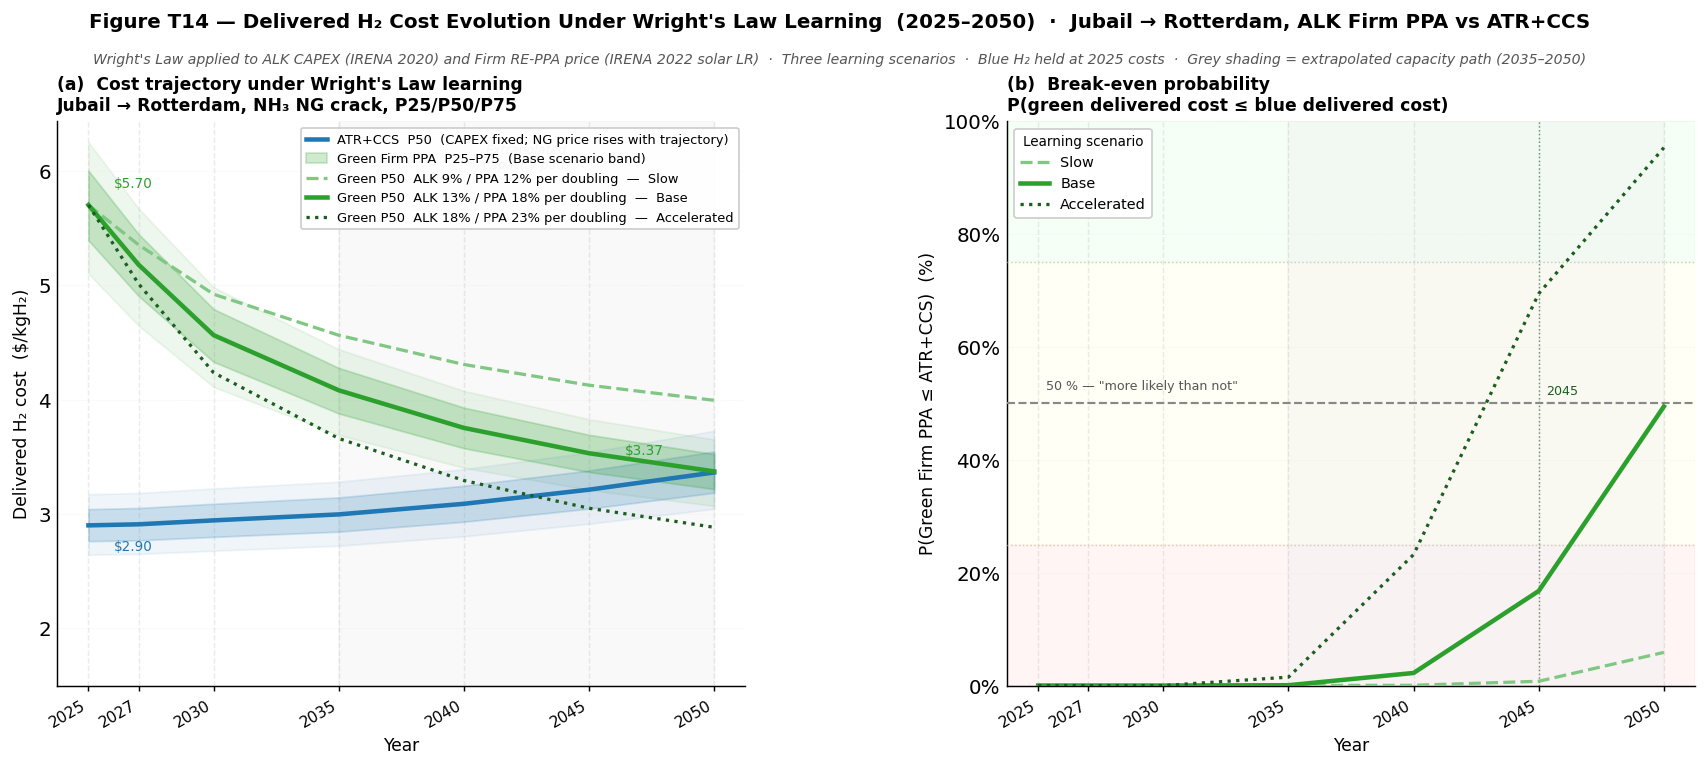

In [34]:
### === Merged from fig_t14_learning_curve.py (single-notebook pipeline) ===
"""
fig_t14_learning_curve.py
─────────────────────────────────────────────────────────────────────────────
Figure T14 — Green H₂ Cost Trajectory Under Wright's Law Learning (2025–2050)
Pathway:  ALK Firm PPA · NH₃ · NG crack · Jubail → Rotterdam
vs.       ATR+CCS      · NH₃ · NG crack · Jubail → Rotterdam  (reference)

Panel (a): Cost trajectory fan chart — P25/P50/P75 bands, three scenarios
Panel (b): Break-even probability — P(green Firm PPA ≤ ATR+CCS) over time

═══════════════════════════════════════════════════════════════════════════════
ASSUMPTIONS & REFERENCES
═══════════════════════════════════════════════════════════════════════════════

A1. Wright's Law formula (carried from Cell 34, unchanged)
    cost_t = cost_0 × (cum_t / cum_0)^(−b),  b = log₂(1 / (1 − LR))
    Applied draw-by-draw to the full MC sample to preserve distributional
    shape and parameter correlations at every future year.

A2. ALK electrolyser CAPEX learning rate (per doubling of global ALK capacity)
    ┌──────────────────┬──────┐
    │ Scenario         │  LR  │
    ├──────────────────┼──────┤
    │ Slow             │  9%  │
    │ Base  (in code)  │ 13%  │  
    │ Accelerated      │ 18%  │    
    └──────────────────┴──────┘    
    Range: IRENA (2020) documents 9–18 % for alkaline electrolysers.

A3. Global ALK electrolyser capacity trajectory (GW)
    2025–2035: Taken directly from Cell 34 of the model
               (IEA, 2023, "Global Hydrogen Review 2023," APS scenario, Table H2.2)
               2025: 10 GW → 2027: 18 GW → 2030: 45 GW → 2035: 130 GW
    2040–2050: EXTRAPOLATED — declining compound annual growth rate from the
               2030–2035 pace (≈24 %/yr), moderated to 18 % (2035-40),
               14 % (2040-45), and 10 % (2045-50).
               The 2050 end-point (~930 GW ALK) is broadly consistent with
               IEA NZE 2023 total electrolyser projection of ~3,500 GW
               (PEM + ALK combined).

A4. Firm RE-PPA price learning rate (per doubling of global solar PV capacity)
    Used as proxy for firmed-renewable electricity cost (solar + battery storage).
    ┌──────────────────┬──────┐
    │ Scenario         │  LR  │
    ├──────────────────┼──────┤
    │ Slow             │ 12%  │
    │ Base             │ 18%  │  ← Conservative vs. crystalline-silicon PV
    │ Accelerated      │ 23%  │    historical rate (24 %) to account for the
    └──────────────────┴──────┘    storage-firming overhead.
    Reference: IRENA (2022) "Renewable Power Generation Costs in 2021" documents
    a 24 % historical learning rate for utility-scale crystalline silicon PV.
    

A5. Global solar PV capacity trajectory (GW) — used as proxy for firm_lcoe learning
    2025: 2,500 GW  (IEA PVPS, 2023 estimate)
    2030: 6,500 GW  │
    2035: 10,000 GW │ IEA (2023) "World Energy Outlook 2023," NZE scenario
    2040: 14,000 GW │
    2045: 18,000 GW │
    2050: 22,000 GW ┘

A6. Saudi domestic NG price trajectory ($/MMBtu) — carried from Cell 34 (unchanged)
    2025–2035: Warmuth & Eshra (2023); Saudi Aramco Annual Reports 2022–2024
    2040–2050: EXTRAPOLATED at same 3.9 %/yr CAGR as the 2025–2035 period.

A7. Blue H₂ CAPEX (ATR+CCS): held at 2025 distribution for all years.
    

A8. All other MC parameters (wacc, nh3_ship_rate, ng_crack_capex, hb_capex, etc.)
    are held at their 2025 distributions. Only ALK CAPEX, firm_lcoe, and ng_price
    central values are time-adjusted. This is conservative — any additional
    learning in carrier-chain costs would further favour green H₂.

A9. Three scenarios vary BOTH ALK LR and firm LR together (they are correlated:
    a world with fast electrolyser learning is also one with fast solar learning).
═══════════════════════════════════════════════════════════════════════════════
"""

import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker

print("Loading runner …")
ctx = globals()
mi              = ctx['mc_inputs']
mc              = ctx['mc_results']
run_monte_carlo = ctx['run_monte_carlo']
PARAMS          = ctx['PARAMS']

GREEN_COL = 'alk_fppa_nh3_ng_jr'
BLUE_COL  = 'atr_ng_cadj_jr'

_CAP_ALK_GW = {
    2025:  10,
    2027:  18,
    2030:  45,
    2035: 130,
    2040: 298,
    2045: 573,
    2050: 923,
}

_CAP_SOLAR_GW = {
    2025:  2_500,
    2027:  3_800,
    2030:  6_500,
    2035: 10_000,
    2040: 14_000,
    2045: 18_000,
    2050: 22_000,
}

_NG_PATH = {
    2025: 0.75,
    2027: 0.82,
    2030: 0.95,
    2035: 1.10,
    2040: 1.33,
    2045: 1.62,
    2050: 1.97,
}

YEARS = [2025, 2027, 2030, 2035, 2040, 2045, 2050]

_cum0_alk   = _CAP_ALK_GW[2025]
_cum0_solar = _CAP_SOLAR_GW[2025]

_NG_SCALE = {yr: _NG_PATH[yr] / _NG_PATH[2025] for yr in YEARS}

SCENARIOS = {
    'Slow':        {'alk_lr': 0.09, 'firm_lr': 0.12,
                    'color': '#81c784', 'lw': 1.8, 'ls': '--'},
    'Base':        {'alk_lr': 0.13, 'firm_lr': 0.18,
                    'color': '#2ca02c', 'lw': 2.5, 'ls': '-'},
    'Accelerated': {'alk_lr': 0.18, 'firm_lr': 0.23,
                    'color': '#1b5e20', 'lw': 1.8, 'ls': ':'},
}

def _wright_mult(cum0, cumt, lr):
    b = np.log2(1.0 / (1.0 - lr))
    return (cumt / cum0) ** (-b)

print("\nRunning MC for each year × scenario …")
print(f"  (3 scenarios × {len(YEARS)} years = {3*len(YEARS)} MC runs)\n")

results = {}

for scen_name, scen in SCENARIOS.items():
    results[scen_name] = {}
    for yr in YEARS:
        df = mi.copy()

        alk_m = _wright_mult(_cum0_alk, _CAP_ALK_GW[yr], scen['alk_lr'])
        df['alk_capex'] = mi['alk_capex'] * alk_m

        firm_m = _wright_mult(_cum0_solar, _CAP_SOLAR_GW[yr], scen['firm_lr'])
        df['firm_lcoe'] = mi['firm_lcoe'] * firm_m

        df['ng_price'] = mi['ng_price'] * _NG_SCALE[yr]

        r = run_monte_carlo(df)
        results[scen_name][yr] = r

        alk_capex_mode = PARAMS['alk_capex'][1] * alk_m
        firm_mode      = PARAMS['firm_lcoe'][1]  * firm_m
        p50_green      = float(np.percentile(r[GREEN_COL], 50))
        p50_blue       = float(np.percentile(r[BLUE_COL],  50))
        prob           = float((r[GREEN_COL] <= r[BLUE_COL]).mean())
        print(f"  {scen_name:<12} {yr}  "
              f"ALK×{alk_m:.3f} ({alk_capex_mode:.0f} $/kW)  "
              f"PPA×{firm_m:.3f} ({firm_mode:.3f} $/kWh)  "
              f"green P50={p50_green:.2f}  blue P50={p50_blue:.2f}  "
              f"P(G≤B)={prob:.1%}")

def pcts(scen, col, ps=(10, 25, 50, 75, 90)):
    return {p: np.array([float(np.percentile(results[scen][yr][col], p))
                         for yr in YEARS]) for p in ps}

blue_p50 = np.array([float(np.percentile(results['Base'][yr][BLUE_COL], 50)) for yr in YEARS])
blue_p25 = np.array([float(np.percentile(results['Base'][yr][BLUE_COL], 25)) for yr in YEARS])
blue_p75 = np.array([float(np.percentile(results['Base'][yr][BLUE_COL], 75)) for yr in YEARS])
blue_p10 = np.array([float(np.percentile(results['Base'][yr][BLUE_COL], 10)) for yr in YEARS])
blue_p90 = np.array([float(np.percentile(results['Base'][yr][BLUE_COL], 90)) for yr in YEARS])

breakeven = {
    scen: np.array([float((results[scen][yr][GREEN_COL] <= results[scen][yr][BLUE_COL]).mean())
                    for yr in YEARS]) * 100
    for scen in SCENARIOS
}

fig = plt.figure(figsize=(14, 6.2), facecolor='white')
gs  = fig.add_gridspec(1, 2, left=0.07, right=0.97,
                        top=0.84, bottom=0.14, wspace=0.38)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

x = np.array(YEARS)

# ── Panel (a): Cost trajectory fan ─────────────────────────────────────────

ax1.fill_between(x, blue_p25, blue_p75, color='#1f77b4', alpha=0.18, zorder=2)
ax1.fill_between(x, blue_p10, blue_p90, color='#1f77b4', alpha=0.07, zorder=1)
ax1.plot(x, blue_p50, color='#1f77b4', lw=2.5, ls='-', zorder=5,
         label='ATR+CCS  P50  (CAPEX fixed; NG price rises with trajectory)')

base_p = pcts('Base', GREEN_COL)
ax1.fill_between(x, base_p[25], base_p[75], color='#2ca02c', alpha=0.22, zorder=2,
                 label='Green Firm PPA  P25–P75  (Base scenario band)')
ax1.fill_between(x, base_p[10], base_p[90], color='#2ca02c', alpha=0.08, zorder=1)

for scen_name, scen in SCENARIOS.items():
    p = pcts(scen_name, GREEN_COL)
    lr_label = (f"ALK {scen['alk_lr']:.0%} / PPA {scen['firm_lr']:.0%} "
                f"per doubling  —  {scen_name}")
    ax1.plot(x, p[50], color=scen['color'], lw=scen['lw'],
             ls=scen['ls'], zorder=6, label=f'Green P50  {lr_label}')

p_base = pcts('Base', GREEN_COL)
ax1.annotate(f"${p_base[50][0]:.2f}",
             xy=(2025, p_base[50][0]), xytext=(2026, p_base[50][0]+0.15),
             fontsize=7.5, color='#2ca02c', ha='left')
ax1.annotate(f"${p_base[50][-1]:.2f}",
             xy=(2050, p_base[50][-1]), xytext=(2048, p_base[50][-1]+0.15),
             fontsize=7.5, color='#2ca02c', ha='right')
ax1.annotate(f"${blue_p50[0]:.2f}",
             xy=(2025, blue_p50[0]), xytext=(2026, blue_p50[0]-0.22),
             fontsize=7.5, color='#1f77b4', ha='left')

ax1.set_xlabel('Year', fontsize=9.5)
ax1.set_ylabel('Delivered H₂ cost  ($/kgH₂)', fontsize=9.5)
ax1.set_title('(a)  Cost trajectory under Wright\'s Law learning\n'
              'Jubail → Rotterdam, NH₃ NG crack, P25/P50/P75',
              fontsize=9.5, fontweight='bold', loc='left', pad=6)
ax1.set_xticks(YEARS)
ax1.set_xticklabels(YEARS, rotation=30, ha='right', fontsize=8.5)
ax1.legend(fontsize=7.2, loc='upper right', framealpha=0.92,
           edgecolor='#cccccc', handlelength=1.6)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', linewidth=0.4, color='#dddddd')
ax1.set_ylim(bottom=1.5)

ax1.axvspan(2035, 2050, color='#eeeeee', alpha=0.35, zorder=0)
ax1.text(2042.5, ax1.get_ylim()[1] * 0.97, 'Extrapolated\ncapacity path',
         ha='center', va='top', fontsize=7, color='#888888', style='italic')

# ── Panel (b): Break-even probability ──────────────────────────────────────

ax2.axhspan(0, 25,  color='#ffcccc', alpha=0.18, zorder=0)
ax2.axhspan(25, 75, color='#ffffcc', alpha=0.18, zorder=0)
ax2.axhspan(75, 100,color='#ccffcc', alpha=0.18, zorder=0)
ax2.axhline(50, color='#888888', ls='--', lw=1.2, zorder=3)
ax2.axhline(25, color='#cccccc', ls=':',  lw=0.8, zorder=3)
ax2.axhline(75, color='#cccccc', ls=':',  lw=0.8, zorder=3)

ax2.text(2025.3, 52, '50 % — "more likely than not"',
         fontsize=7, color='#555555', va='bottom')

for scen_name, scen in SCENARIOS.items():
    ax2.plot(x, breakeven[scen_name],
             color=scen['color'], lw=scen['lw'], ls=scen['ls'],
             zorder=5, label=f"{scen_name}")
    for i, (yr, val) in enumerate(zip(YEARS, breakeven[scen_name])):
        if val >= 50:
            ax2.axvline(yr, color=scen['color'], lw=0.8, ls=':', alpha=0.6, zorder=2)
            ax2.text(yr+0.3, 51, f'{yr}', fontsize=7, color=scen['color'],
                     va='bottom', ha='left')
            break

ax2.set_xlabel('Year', fontsize=9.5)
ax2.set_ylabel('P(Green Firm PPA ≤ ATR+CCS)  (%)', fontsize=9.5)
ax2.set_title('(b)  Break-even probability\n'
              'P(green delivered cost ≤ blue delivered cost)',
              fontsize=9.5, fontweight='bold', loc='left', pad=6)
ax2.set_xticks(YEARS)
ax2.set_xticklabels(YEARS, rotation=30, ha='right', fontsize=8.5)
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))
ax2.legend(fontsize=8, loc='upper left', framealpha=0.92,
           edgecolor='#cccccc', title='Learning scenario', title_fontsize=7.5)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', linewidth=0.4, color='#dddddd')

ax2.axvspan(2035, 2050, color='#eeeeee', alpha=0.35, zorder=0)

# ── Main title ──────────────────────────────────────────────────────────────
fig.suptitle(
    "Figure T14 — Delivered H₂ Cost Evolution Under Wright's Law Learning  "
    "(2025–2050)  ·  Jubail → Rotterdam, ALK Firm PPA vs ATR+CCS",
    fontsize=11.0, fontweight='bold', y=0.975, ha='center')
fig.text(0.5, 0.925,
         "Wright's Law applied to ALK CAPEX (IRENA 2020) and Firm RE-PPA price (IRENA 2022 solar LR)  ·  "
         "Three learning scenarios  ·  Blue H₂ held at 2025 costs  ·  "
         "Grey shading = extrapolated capacity path (2035–2050)",
         ha='center', va='top', fontsize=7.8, color='#555555', fontstyle='italic')

out = 'figures/fig_T14_learning_curve.png'
plt.show()

Delivered-CI P50 crossings of EU 3.38 (g CO2eq/MJ upstream EF):
  ATR JR: 11.8
  SMR JR: 6.5
  ATR YR: 12.4
  SMR YR: 7.0


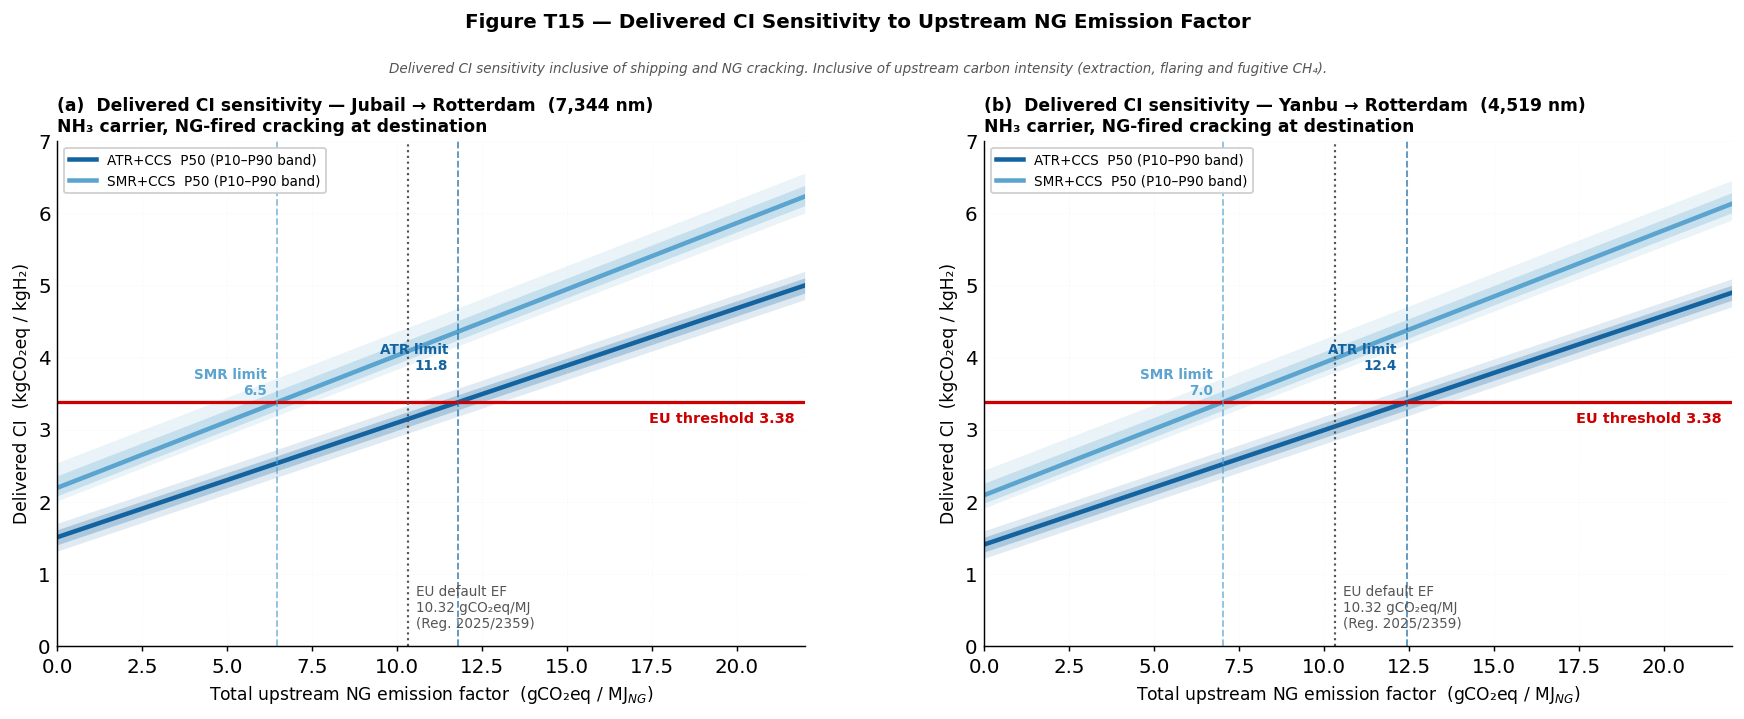

In [35]:
### T15 (revised) — Delivered CI sensitivity to upstream NG EF: (a) Jubail–Rotterdam, (b) Yanbu–Rotterdam
import os
import numpy as np
import matplotlib.pyplot as plt

mi, mc = mc_inputs, mc_results
H2_LHV_KWH  = 33.33
EU_THRESHOLD = 3.38
EU_EF        = 10.32
LHV_CH4_MJ  = 55.5
GWP28        = 28
XI           = CRACK_YIELD_NG

ci_base_atr = mc['ci_atr_prod'].values
ci_base_smr = mc['ci_smr_prod'].values
ng_mj_atr   = H2_LHV_KWH * 3.6 / mi['atr_eff'].values
ng_mj_smr   = H2_LHV_KWH * 3.6 / mi['smr_eff'].values
ch4_leak    = mi['ch4_leakage'].values
ci_atr_co2  = ci_base_atr - ch4_leak * GWP28 * (ng_mj_atr / LHV_CH4_MJ)
ci_smr_co2  = ci_base_smr - ch4_leak * GWP28 * (ng_mj_smr / LHV_CH4_MJ)

chain_atr_jr = mc['ci_atr_nh3_ng_jr'].values - ci_base_atr / XI
chain_smr_jr = mc['ci_smr_nh3_ng_jr'].values - ci_base_smr / XI
chain_atr_yr = mc['ci_atr_nh3_ng_yr'].values - ci_base_atr / XI
chain_smr_yr = mc['ci_smr_nh3_ng_yr'].values - ci_base_smr / XI

EF_RANGE = np.linspace(0, 22, 220)
def sweep(ci_co2, ng_mj, chain):
    out = {p: np.zeros(len(EF_RANGE)) for p in (10, 25, 50, 75, 90)}
    for i, ef in enumerate(EF_RANGE):
        d = (ci_co2 + ef * ng_mj / 1000.0) / XI + chain
        for p in out: out[p][i] = np.percentile(d, p)
    return out

P = {('atr','jr'): sweep(ci_atr_co2, ng_mj_atr, chain_atr_jr),
     ('smr','jr'): sweep(ci_smr_co2, ng_mj_smr, chain_smr_jr),
     ('atr','yr'): sweep(ci_atr_co2, ng_mj_atr, chain_atr_yr),
     ('smr','yr'): sweep(ci_smr_co2, ng_mj_smr, chain_smr_yr)}

def _cross(arr, thr=EU_THRESHOLD):
    idx = np.where(arr >= thr)[0]
    if not len(idx): return None
    i = idx[0]
    if i == 0: return EF_RANGE[0]
    x0, x1, y0, y1 = EF_RANGE[i-1], EF_RANGE[i], arr[i-1], arr[i]
    return x0 + (thr - y0) * (x1 - x0) / (y1 - y0)

CX = {k: _cross(v[50]) for k, v in P.items()}
print('Delivered-CI P50 crossings of EU 3.38 (g CO2eq/MJ upstream EF):')
for k, v in CX.items():
    print(f"  {k[0].upper()} {k[1].upper()}: {v:.1f}" if v else f"  {k[0].upper()} {k[1].upper()}: none in 0-22")

COL_ATR, COL_SMR, COL_EU = '#1363a0', '#5ba4cf', '#cc0000'
fig = plt.figure(figsize=(14, 5.8), facecolor='white')
gs  = fig.add_gridspec(1, 2, left=0.06, right=0.98, top=0.80, bottom=0.13, wspace=0.24)

for ax, route, rname, dist in [(fig.add_subplot(gs[0]), 'jr', 'Jubail → Rotterdam', '7,344 nm'),
                               (fig.add_subplot(gs[1]), 'yr', 'Yanbu → Rotterdam',  '4,519 nm')]:
    pa, ps = P[('atr', route)], P[('smr', route)]
    ax.fill_between(EF_RANGE, pa[10], pa[90], color=COL_ATR, alpha=0.13, lw=0)
    ax.fill_between(EF_RANGE, ps[10], ps[90], color=COL_SMR, alpha=0.13, lw=0)
    ax.fill_between(EF_RANGE, pa[25], pa[75], color=COL_ATR, alpha=0.25, lw=0)
    ax.fill_between(EF_RANGE, ps[25], ps[75], color=COL_SMR, alpha=0.25, lw=0)
    ax.plot(EF_RANGE, pa[50], color=COL_ATR, lw=2.5, label='ATR+CCS  P50 (P10–P90 band)')
    ax.plot(EF_RANGE, ps[50], color=COL_SMR, lw=2.5, label='SMR+CCS  P50 (P10–P90 band)')
    ax.axhline(EU_THRESHOLD, color=COL_EU, lw=1.8)
    ax.text(21.7, EU_THRESHOLD - 0.28, 'EU threshold 3.38', fontsize=8, color=COL_EU,
            fontweight='bold', ha='right')
    ax.axvline(EU_EF, color='#555555', lw=1.2, ls=':')
    ax.text(EU_EF + 0.25, 0.25, f'EU default EF\n{EU_EF} gCO₂eq/MJ\n(Reg. 2025/2359)',
            fontsize=7.5, color='#555555')
    for tech, pp, col in [('ATR', pa, COL_ATR), ('SMR', ps, COL_SMR)]:
        cx = CX[(tech.lower(), route)]
        if cx:
            ax.axvline(cx, color=col, lw=1.0, ls='--', alpha=0.7)
            ax.text(cx - 0.3, EU_THRESHOLD + 0.45 if tech=='ATR' else EU_THRESHOLD + 0.10,
                    f'{tech} limit\n{cx:.1f}', fontsize=7.5, color=col, ha='right', fontweight='bold')
    ax.set_xlabel('Total upstream NG emission factor  (gCO₂eq / MJ$_{NG}$)', fontsize=9.5)
    ax.set_ylabel('Delivered CI  (kgCO₂eq / kgH₂)', fontsize=9.5)
    lab = '(a)' if route == 'jr' else '(b)'
    ax.set_title(f'{lab}  Delivered CI sensitivity — {rname}  ({dist})\n'
                 'NH₃ carrier, NG-fired cracking at destination', fontsize=9.5,
                 fontweight='bold', loc='left', pad=5)
    ax.set_xlim(0, 22); ax.set_ylim(0, 7)
    ax.legend(fontsize=7.5, loc='upper left', framealpha=0.92, edgecolor='#cccccc')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(linewidth=0.4, color='#e5e5e5')

fig.suptitle('Figure T15 — Delivered CI Sensitivity to Upstream NG Emission Factor',
             fontsize=11.0, fontweight='bold', y=0.97)
fig.text(0.5, 0.905,
    "Delivered CI sensitivity inclusive of shipping and NG cracking. "
    "Inclusive of upstream carbon intensity (extraction, flaring and fugitive CH₄).",
    ha='center', va='top', fontsize=7.5, color='#555555', fontstyle='italic')

out = os.path.join(FIG_DIR, 'fig_T15_upstream_ci.png')
plt.show()

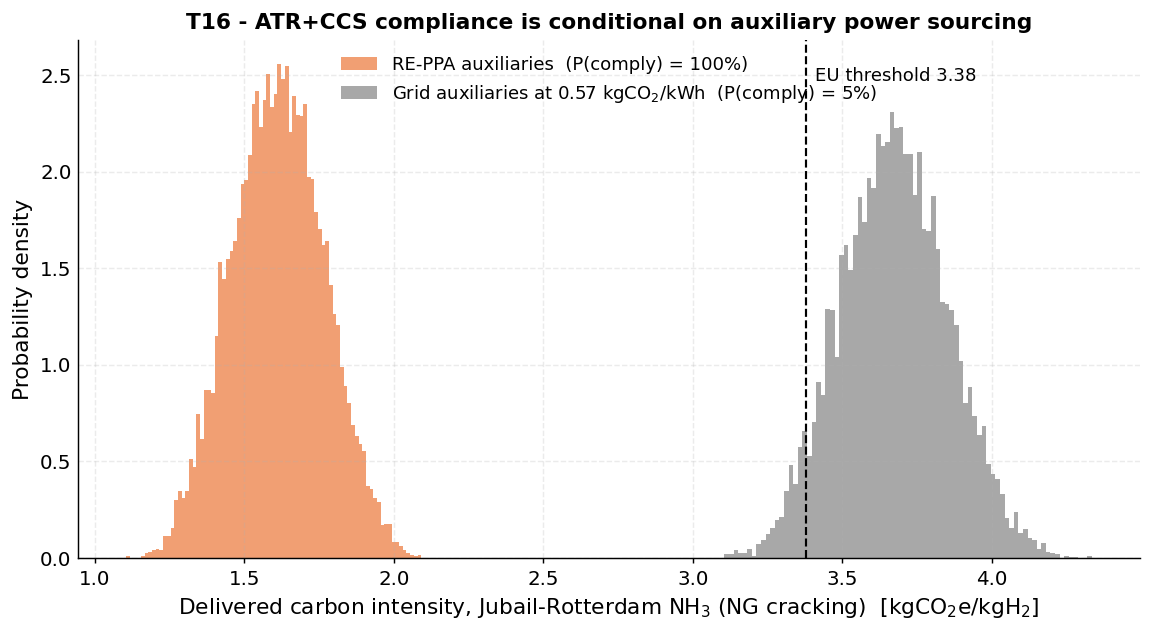

P50 CI: RE-PPA 1.61 | grid 3.67  (+2.06)
P(comply EU, JR): RE-PPA 100.0% -> grid 5.2%


In [36]:
### T16 — ATR auxiliary power sourcing sensitivity (RE-PPA vs Saudi grid)
import numpy as np, matplotlib.pyplot as plt, os

_ae    = mc_inputs['atr_elec_kwh'].values
_ci_pp = np.asarray(mc_results['ci_atr_nh3_ng_jr'])
_ci_gr = _ci_pp + _ae * SAUDI_GRID_EF
_p_pp  = float((_ci_pp <= EU_CI_THRESHOLD).mean())
_p_gr  = float((_ci_gr <= EU_CI_THRESHOLD).mean())

fig, ax = plt.subplots(figsize=(9, 5))
for _arr, _lbl, _col in [(_ci_pp, f"RE-PPA auxiliaries  (P(comply) = {_p_pp:.0%})", TC['atr']),
                          (_ci_gr, f"Grid auxiliaries at {SAUDI_GRID_EF} kgCO$_2$/kWh  (P(comply) = {_p_gr:.0%})", '#616161')]:
    ax.hist(_arr, bins=80, density=True, alpha=0.55, color=_col, label=_lbl)
ax.axvline(EU_CI_THRESHOLD, color='k', ls='--', lw=1.2)
ax.text(EU_CI_THRESHOLD + 0.03, ax.get_ylim()[1]*0.92, f'EU threshold {EU_CI_THRESHOLD}', fontsize=10)
ax.set_xlabel('Delivered carbon intensity, Jubail-Rotterdam NH$_3$ (NG cracking)  [kgCO$_2$e/kgH$_2$]')
ax.set_ylabel('Probability density')
ax.set_title('T16 - ATR+CCS compliance is conditional on auxiliary power sourcing')
ax.legend(frameon=False)
fig.tight_layout()
_out = os.path.join(FIG_DIR, 'fig_T16_atr_aux_power.png')
plt.show()
print(f"P50 CI: RE-PPA {np.percentile(_ci_pp,50):.2f} | grid {np.percentile(_ci_gr,50):.2f}  (+{np.percentile(_ae*SAUDI_GRID_EF,50):.2f})")
print(f"P(comply EU, JR): RE-PPA {_p_pp:.1%} -> grid {_p_gr:.1%}")

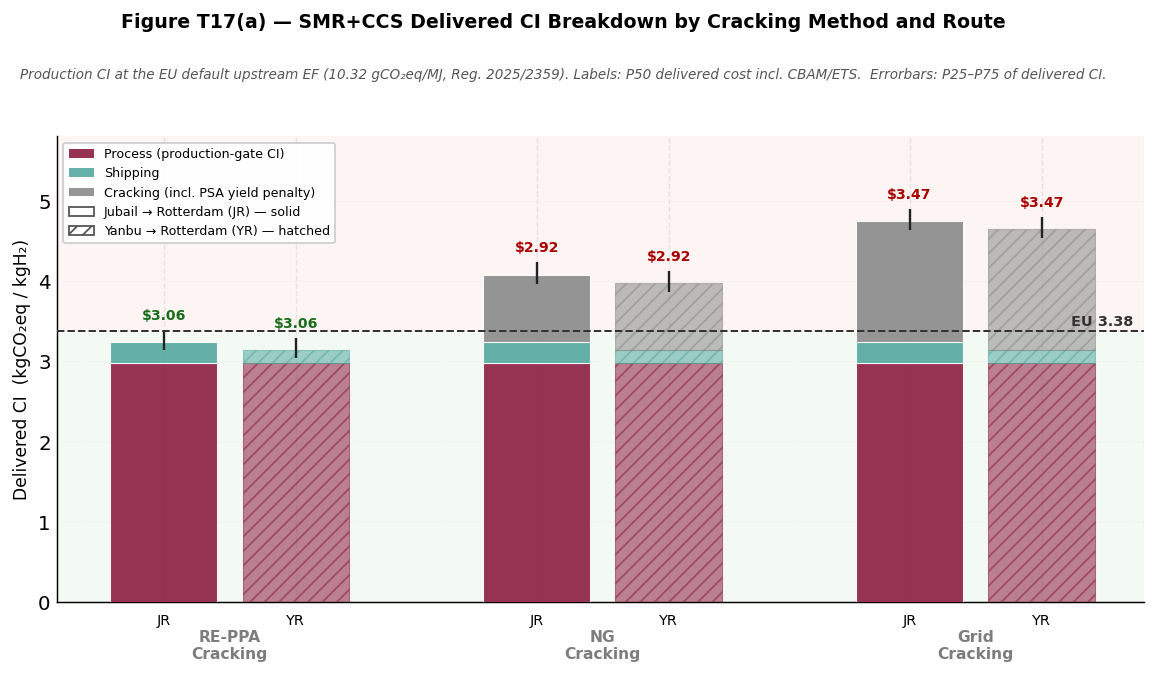

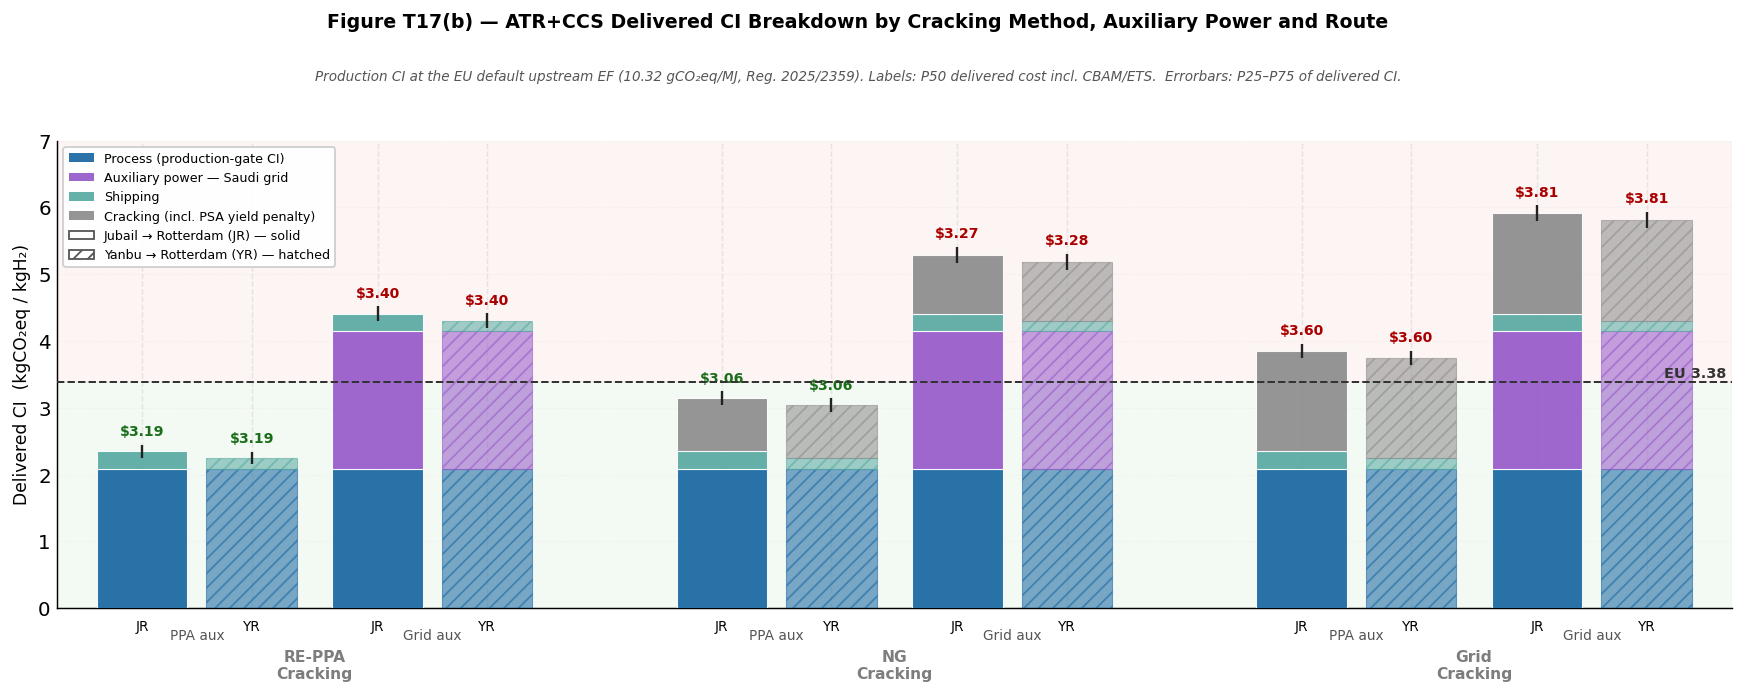

In [37]:
### T17 — Delivered CI breakdowns (two figures): (a) SMR+CCS by cracking method, JR vs YR; (b) ATR+CCS by cracking × auxiliary power, JR vs YR
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

mi, mc = mc_inputs, mc_results
H2_LHV_KWH, EU_THRESHOLD, EU_EF = 33.33, 3.38, 10.32
LHV_CH4_MJ, GWP28 = 55.5, 28
XI = CRACK_YIELD_NG

ng_mj_atr = H2_LHV_KWH * 3.6 / mi['atr_eff'].values
ng_mj_smr = H2_LHV_KWH * 3.6 / mi['smr_eff'].values
ch4 = mi['ch4_leakage'].values
ci_eu = {'atr': (mc['ci_atr_prod'].values - ch4*GWP28*ng_mj_atr/LHV_CH4_MJ) + EU_EF*ng_mj_atr/1000,
         'smr': (mc['ci_smr_prod'].values - ch4*GWP28*ng_mj_smr/LHV_CH4_MJ) + EU_EF*ng_mj_smr/1000}
aux_grid = mi['atr_elec_kwh'].values * SAUDI_GRID_EF
eu_cp    = mi['eu_carbon_price'].values
ship = {r: mi['nh3_ship_ei'].values * DIST_NM[r] * NM_TO_KM * KG_NH3_PER_KG_H2 * 1e-6
        for r in ('JR', 'YR')}
prodcol = {'atr': 'ci_atr_prod', 'smr': 'ci_smr_prod'}

def _chain(tech, m, r):
    r = r.lower()
    if m == 'reppa': return mc[f'ci_pem_nh3_{r}'].values
    if m == 'ng':    return mc[f'ci_{tech}_nh3_ng_{r}'].values - mc[prodcol[tech]].values / XI
    return           mc[f'ci_{tech}_nh3_{r}'].values    - mc[prodcol[tech]].values
def _cost(tech, m, r):
    r = r.lower()
    if m == 'reppa':
        # RE-PPA electric cracking cost: blue *_nh3 columns embed GRID-priced
        # electric cracking; subtract the grid-vs-PPA electricity price delta
        # per draw (same construction as the T6/T8 figure cells).
        if r in ('jr', 'yr'):
            _d = mi['crack_elec_kwh_per_kgh2'].values * (
                mi['rott_grid_elec_price'].values - mi['rott_elec_price'].values)
        else:
            _d = mi['crack_elec_kwh_per_kgh2'].values * (
                mi['japan_elec_price'].values - mi['japan_re_ppa_price'].values)
        return mc[f'{tech}_nh3_{r}'].values - _d
    if m == 'ng':    return mc[f'{tech}_nh3_ng_{r}'].values
    return           mc[f'{tech}_nh3_{r}'].values
def _xi(m):      return XI if m == 'ng' else 1.0
def _p(v, q=50): return float(np.percentile(v, q))
def scen(tech, m, r, grid_aux=False):
    aux = aux_grid if (tech == 'atr' and grid_aux) else 0.0
    tot = (ci_eu[tech] + aux) / _xi(m) + _chain(tech, m, r)
    return tot, _p(_cost(tech, m, r) + eu_cp * tot / 1000)

COL_PROC = {'atr': '#1363a0', 'smr': '#8c1d40'}
COL_AUX, COL_SHIP, COL_CRACK = '#9457c9', '#54a8a0', '#8a8a8a'
M_COL = {'reppa': '#2a9d2a', 'ng': '#e8912d', 'grid': '#7d7d7d'}
M_LBL = {'reppa': 'RE-PPA\nCracking', 'ng': 'NG\nCracking', 'grid': 'Grid\nCracking'}
methods = ['reppa', 'ng', 'grid']

def style_ax(ax, ymax):
    ax.axhspan(0, EU_THRESHOLD, color='#edf7ed', alpha=0.65, zorder=0)
    ax.axhspan(EU_THRESHOLD, 9, color='#fce8e8', alpha=0.45, zorder=0)
    ax.axhline(EU_THRESHOLD, color='#333333', lw=1.1, ls='--', zorder=7)
    ax.set_ylim(0, ymax)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linewidth=0.4, color='#dddddd')
    ax.tick_params(axis='x', which='both', bottom=False)
    ax.set_ylabel('Delivered CI  (kgCO₂eq / kgH₂)', fontsize=9.5)

def draw_bar(ax, x, tech, m, r, grid_aux=False, bar_w=0.5):
    tot, cost = scen(tech, m, r, grid_aux)
    t50, t25, t75 = _p(tot), _p(tot, 25), _p(tot, 75)
    aux_d  = aux_grid if grid_aux else 0.0
    crack_d = tot - ci_eu[tech] - aux_d - ship[r]
    proc  = _p(ci_eu[tech])
    aux   = _p(aux_grid) if grid_aux else 0.0
    shp   = _p(ship[r])
    crack = _p(crack_d)
    hatched = (r == 'YR')
    kw = dict(hatch='///', alpha=0.55) if hatched else dict(alpha=0.9)
    b = 0.0
    for seg, col in [(proc, COL_PROC[tech]), (aux, COL_AUX), (shp, COL_SHIP), (crack, COL_CRACK)]:
        if seg > 1e-9:
            ec = col if hatched else 'white'
            ax.bar(x, seg, bar_w, bottom=b, color=col, edgecolor=ec, lw=0.6, zorder=3, **kw)
            b += seg
    top = proc + aux + shp + max(crack, 0.0)
    ax.errorbar(x, top, yerr=[[t50-t25],[t75-t50]], fmt='none', color='#222', lw=1.3, zorder=5)
    fc = '#1a6e1a' if t50 <= EU_THRESHOLD else '#aa0000'
    ax.text(x, top + (t75-t50) + 0.09, f'${cost:.2f}', ha='center', va='bottom',
            fontsize=7.8, color=fc, fontweight='bold', zorder=6)

def route_handles():
    return [Patch(facecolor='white', edgecolor='#555555', label='Jubail → Rotterdam (JR) — solid'),
            Patch(facecolor='white', edgecolor='#555555', hatch='///', label='Yanbu → Rotterdam (YR) — hatched')]

# ── Figure (a): SMR — 3 cracking methods × 2 routes ───────────────────────
figA, axA = plt.subplots(figsize=(9.5, 5.6), facecolor='white')
figA.subplots_adjust(left=0.09, right=0.97, top=0.80, bottom=0.16)
style_ax(axA, 5.8)
xg = np.array([0.0, 1.75, 3.5])
for g, m in enumerate(methods):
    draw_bar(axA, xg[g],        'smr', m, 'JR')
    draw_bar(axA, xg[g] + 0.62, 'smr', m, 'YR')
    axA.text(xg[g] + 0.31, -0.34, M_LBL[m], ha='center', va='top',
             fontsize=8.6, color='#7d7d7d', fontweight='bold')
axA.set_xticks(list(xg) + list(xg + 0.62))
axA.set_xticklabels(['JR']*3 + ['YR']*3, fontsize=8)
axA.set_xlim(-0.5, 4.6)
axA.text(4.55, EU_THRESHOLD + 0.07, 'EU 3.38', fontsize=8, fontweight='bold', color='#333333', ha='right')
axA.legend(handles=[
    Patch(facecolor=COL_PROC['smr'], alpha=0.9, label='Process (production-gate CI)'),
    Patch(facecolor=COL_SHIP,  alpha=0.9, label='Shipping'),
    Patch(facecolor=COL_CRACK, alpha=0.9, label='Cracking (incl. PSA yield penalty)'),
    *route_handles()], fontsize=7, loc='upper left', framealpha=0.93, edgecolor='#cccccc')
figA.suptitle('Figure T17(a) — SMR+CCS Delivered CI Breakdown by Cracking Method and Route',
              fontsize=10.5, fontweight='bold', y=0.97)
figA.text(0.5, 0.895,
    f"Production CI at the EU default upstream EF ({EU_EF} gCO₂eq/MJ, Reg. 2025/2359). "
    "Labels: P50 delivered cost incl. CBAM/ETS.  Errorbars: P25–P75 of delivered CI.",
    ha='center', va='top', fontsize=7.5, color='#555555', fontstyle='italic')
outA = os.path.join(FIG_DIR, 'fig_T17a_ci_breakdown_smr.png')
plt.show()

# ── Figure (b): ATR — 3 cracking × 2 aux × 2 routes ───────────────────────
figB, axB = plt.subplots(figsize=(14, 5.8), facecolor='white')
figB.subplots_adjust(left=0.06, right=0.98, top=0.80, bottom=0.18)
style_ax(axB, 7.0)
inner, gap = 0.58, 0.75
xb, ticklbl = [], []
for g in range(3):
    x0 = g * (4*inner + gap)
    xb += [x0, x0+inner, x0+2.15*inner, x0+3.15*inner]
    ticklbl += ['JR', 'YR', 'JR', 'YR']
xb = np.array(xb)
for g, m in enumerate(methods):
    for j, (ga, r) in enumerate([(False,'JR'), (False,'YR'), (True,'JR'), (True,'YR')]):
        draw_bar(axB, xb[4*g+j], 'atr', m, r, grid_aux=ga, bar_w=0.48)
    axB.text((xb[4*g] + xb[4*g+3])/2, -0.62, M_LBL[m], ha='center', va='top',
             fontsize=8.6, color='#7d7d7d', fontweight='bold')
    axB.text((xb[4*g] + xb[4*g+1])/2, -0.30, 'PPA aux', ha='center', va='top', fontsize=7.6, color='#555555')
    axB.text((xb[4*g+2] + xb[4*g+3])/2, -0.30, 'Grid aux', ha='center', va='top', fontsize=7.6, color='#555555')
axB.set_xticks(xb); axB.set_xticklabels(ticklbl, fontsize=7.5)
axB.set_xlim(xb[0]-0.45, xb[-1]+0.45)
axB.text(xb[-1]+0.42, EU_THRESHOLD + 0.08, 'EU 3.38', fontsize=8, fontweight='bold', color='#333333', ha='right')
axB.legend(handles=[
    Patch(facecolor=COL_PROC['atr'], alpha=0.9, label='Process (production-gate CI)'),
    Patch(facecolor=COL_AUX,  alpha=0.9, label='Auxiliary power — Saudi grid'),
    Patch(facecolor=COL_SHIP, alpha=0.9, label='Shipping'),
    Patch(facecolor=COL_CRACK, alpha=0.9, label='Cracking (incl. PSA yield penalty)'),
    *route_handles()], fontsize=7, loc='upper left', framealpha=0.93, edgecolor='#cccccc')
figB.suptitle('Figure T17(b) — ATR+CCS Delivered CI Breakdown by Cracking Method, Auxiliary Power and Route',
              fontsize=10.5, fontweight='bold', y=0.97)
figB.text(0.5, 0.895,
    f"Production CI at the EU default upstream EF ({EU_EF} gCO₂eq/MJ, Reg. 2025/2359). "
    "Labels: P50 delivered cost incl. CBAM/ETS.  Errorbars: P25–P75 of delivered CI.",
    ha='center', va='top', fontsize=7.5, color='#555555', fontstyle='italic')
outB = os.path.join(FIG_DIR, 'fig_T17b_ci_breakdown_atr.png')
plt.show()

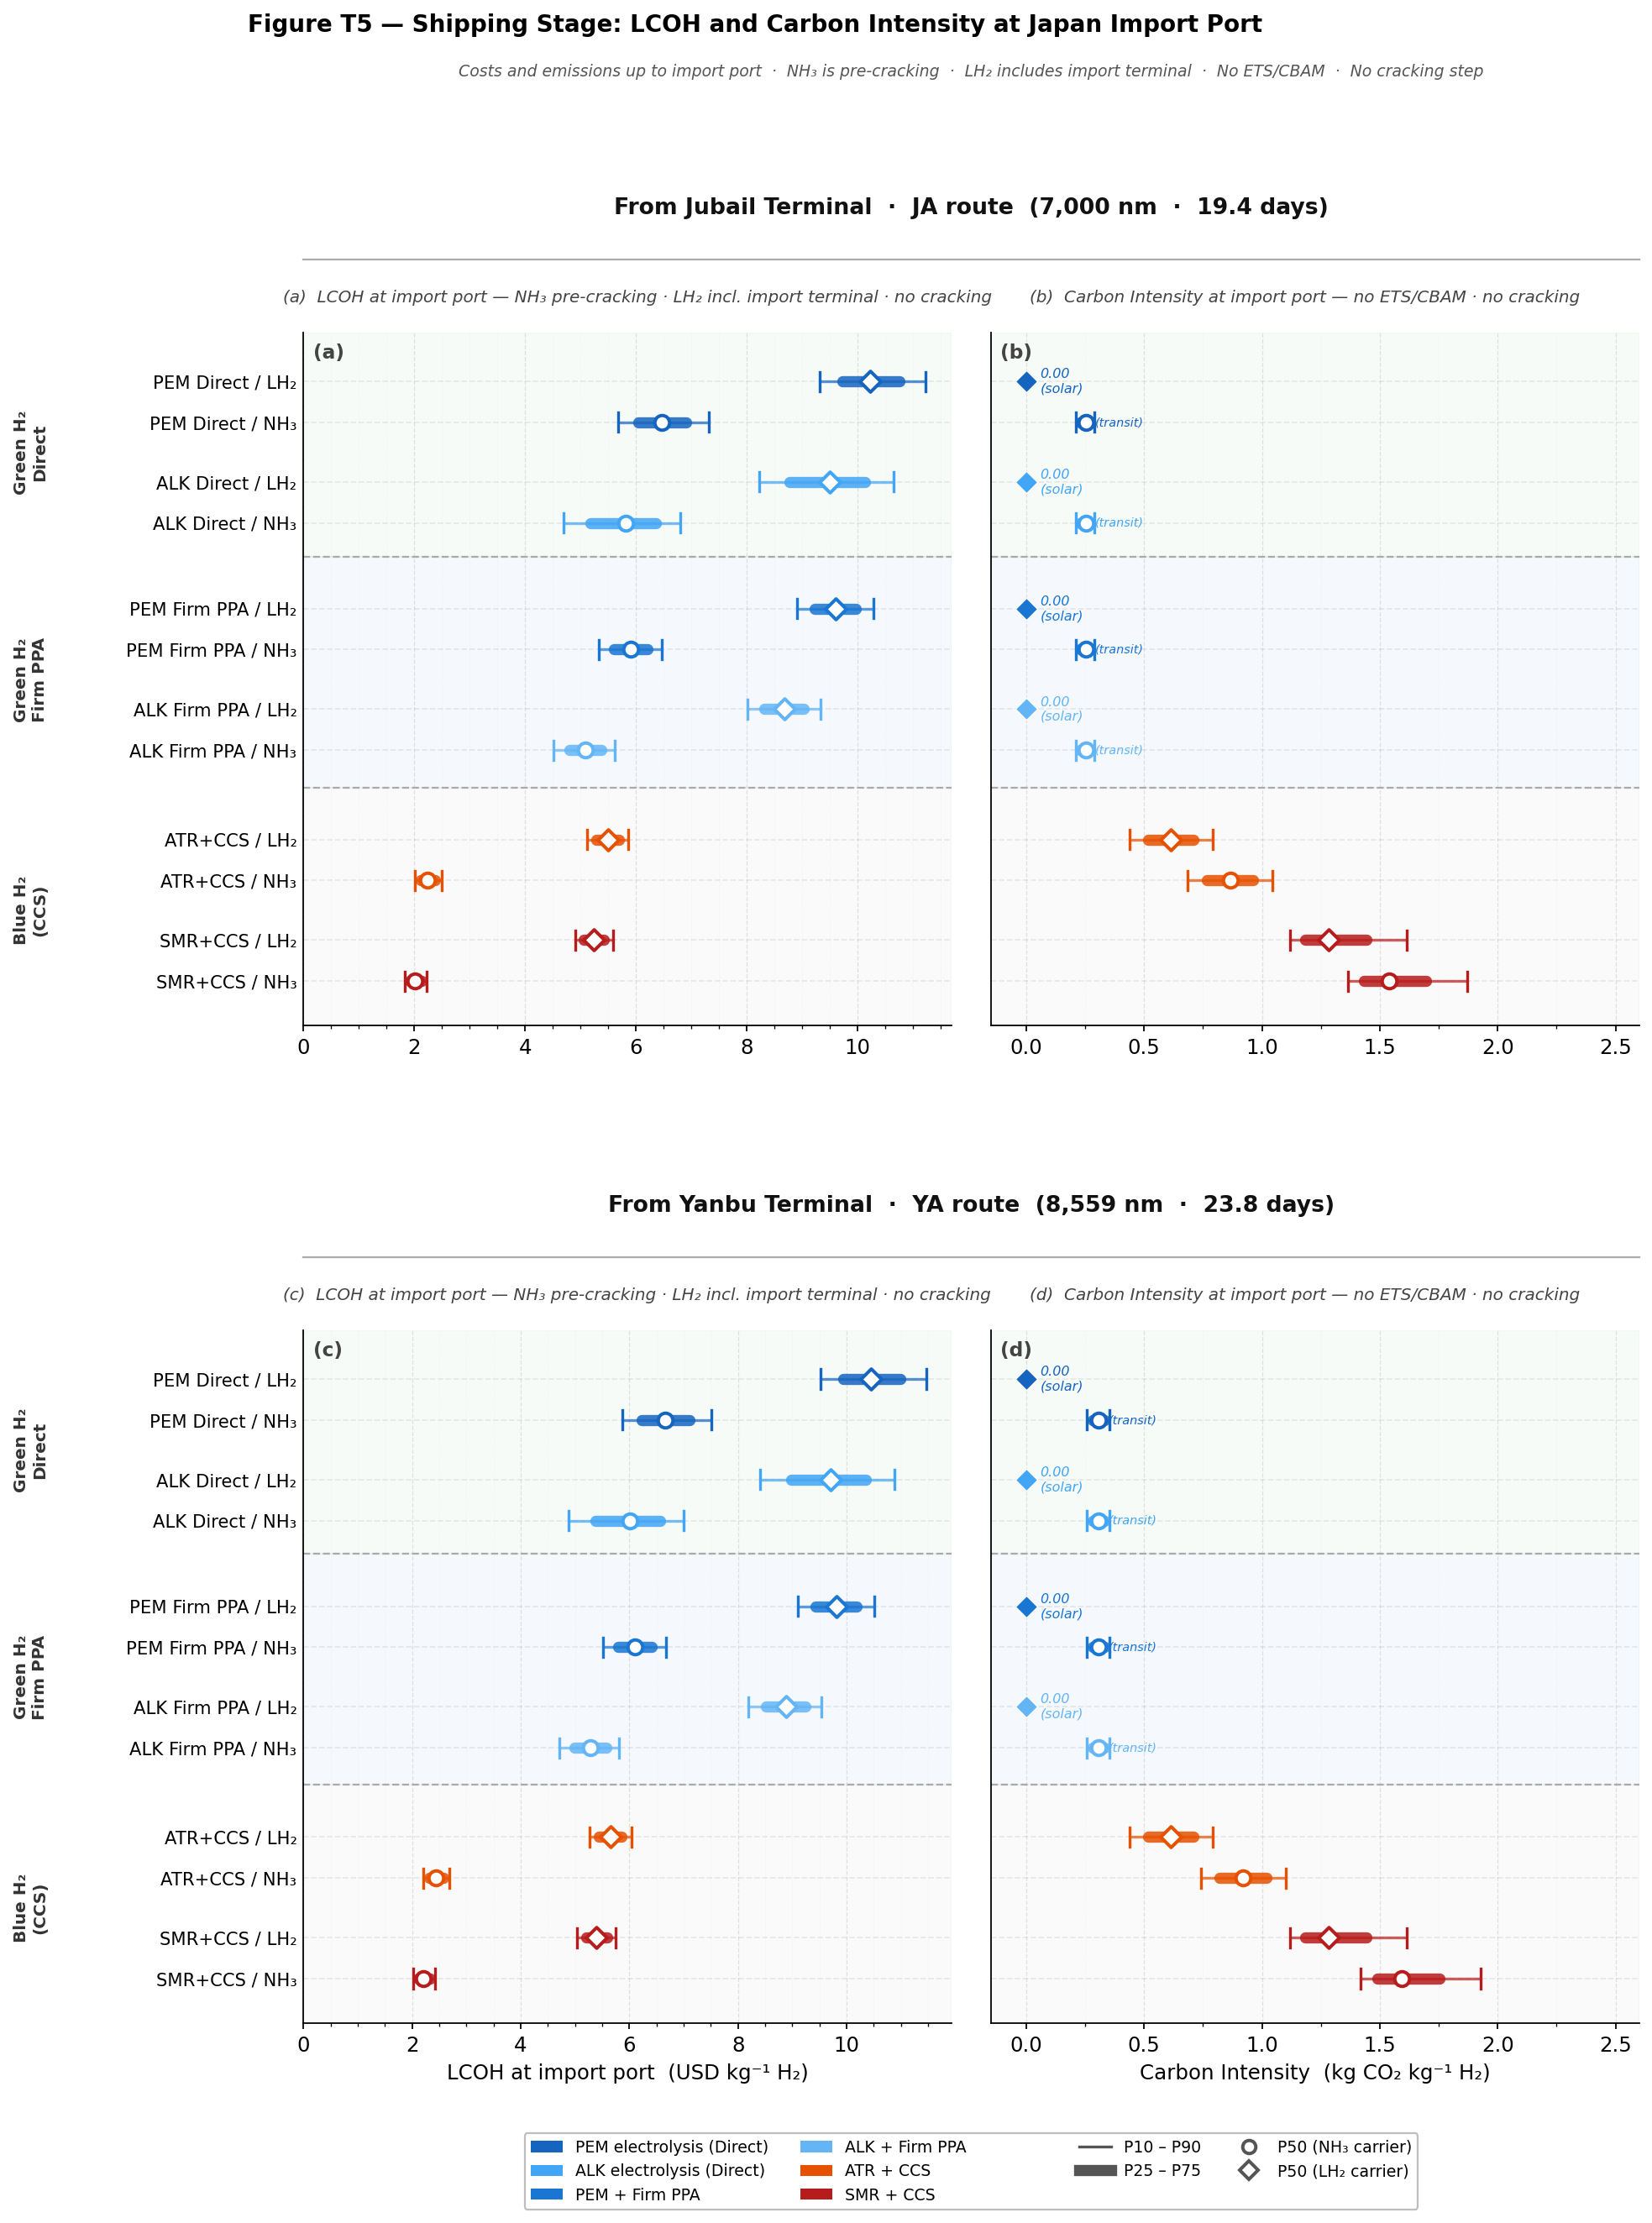

In [38]:
"""
Figure T5 — Shipping Stage: LCOH and Carbon Intensity at Japan Import Port
- 2×2 layout: top row = Jubail origin (JA, 7,000 nm); bottom row = Yanbu origin (YA, 8,559 nm)
- Left panels: LCOH = production + export terminal + shipping
               NH₃ cost is PRE-CRACKING (no cracking step included here)
               LH₂ cost includes import terminal (no cracking step)
- Right panels: CI = production CI + NH₃ shipping CI (ship fuel only)
               LH₂ CI = production CI (solar liquefaction → ship CI=0)
- No ETS/CBAM
"""
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpa
from matplotlib.lines import Line2D as _L2D
import numpy as np, os, runpy, sys

sys.path.insert(0, os.getcwd())
os.chdir(os.getcwd())
ctx = globals()
mc               = ctx['mc_results']
mi               = ctx['mc_inputs']
TC               = ctx['TC']
FIG_DIR          = ctx['FIG_DIR']
PARAMS           = ctx['PARAMS']
DIST_NM          = ctx['DIST_NM']
NM_TO_KM         = ctx['NM_TO_KM']
KG_NH3_PER_KG_H2 = ctx['KG_NH3_PER_KG_H2']
VOYAGE_DAYS      = ctx['VOYAGE_DAYS']
LH2_HEEL_FRAC    = ctx['LH2_HEEL_FRAC']
LH2_SCALE_PREMIUM = ctx['LH2_SCALE_PREMIUM']

# ── shared export-terminal building blocks ────────────────────────────────────
solar_lcoe = mi['solar_lcoe'].values
hb_cost    = (mi['hb_capex_opex_per_kgh2'].values
              + mi['hb_elec_kwh_per_kgh2'].values * solar_lcoe)
nh3_stor_j = mi['nh3_stor_cost_jubail'].values
nh3_stor_y = mi['nh3_stor_cost_yanbu'].values
lh2_liq    = (mi['lh2_liq_capex_opex_per_kgh2'].values
              + mi['lh2_liq_kwh_per_kgh2'].values * solar_lcoe)
lh2_stor   = mi['lh2_stor_cost'].values
lh2_import = mi['lh2_import_term_cost'].values

# ── NH₃ shipping cost per kgH₂ ───────────────────────────────────────────────
nh3_rate    = mi['nh3_ship_rate'].values
nh3_ship_ja = nh3_rate * DIST_NM['JA'] * NM_TO_KM / 1000 * KG_NH3_PER_KG_H2 / 1000
nh3_ship_ya = nh3_rate * DIST_NM['YA'] * NM_TO_KM / 1000 * KG_NH3_PER_KG_H2 / 1000

# ── NH₃ shipping CI (gCO₂e/tNH₃/km → kgCO₂/kgH₂) ───────────────────────────
nh3_ei         = mi['nh3_ship_ei'].values
ci_nh3_ship_ja = nh3_ei * DIST_NM['JA'] * NM_TO_KM * KG_NH3_PER_KG_H2 * 1e-6
ci_nh3_ship_ya = nh3_ei * DIST_NM['YA'] * NM_TO_KM * KG_NH3_PER_KG_H2 * 1e-6

# ── LH₂ delivery fraction ────────────────────────────────────────────────────
bog_rate = mi['lh2_bog_rate'].values
load_bog = mi['lh2_load_bog_frac'].values

def _dfrac(voyage_days):
    return (1 - load_bog) * (1 - bog_rate) ** voyage_days

dfrac_ja = _dfrac(VOYAGE_DAYS['JA'])
dfrac_ya = _dfrac(VOYAGE_DAYS['YA'])

# ── LH₂ at import port ───────────────────────────────────────────────────────
lh2_ship_ja = mi['lh2_ship_ja'].values
lh2_ship_ya = mi['lh2_ship_ya'].values

def _lh2_port(lcoh_prod, dfrac, lh2_ship):
    """LH₂ delivered to import port — no cracking step."""
    return (lcoh_prod / dfrac
            + lh2_liq
            + lh2_ship / (1.0 - LH2_HEEL_FRAC)
            + lh2_stor + lh2_import + LH2_SCALE_PREMIUM)

# ── NH₃ at import port (pre-cracking) ────────────────────────────────────────
def _nh3_port(lcoh_prod, nh3_stor, nh3_ship):
    return lcoh_prod + hb_cost + nh3_stor + nh3_ship

# ── blue CI arrays ────────────────────────────────────────────────────────────
ci_atr = mc['ci_atr_prod'].values
ci_smr = mc['ci_smr_prod'].values

lcoh_pem = mc['lcoh_pem'].values;      lcoh_alk = mc['lcoh_alk'].values
lcoh_pf  = mc['lcoh_pem_fppa'].values; lcoh_af  = mc['lcoh_alk_fppa'].values
lcoh_atr = mc['lcoh_atr'].values;      lcoh_smr = mc['lcoh_smr'].values

# ── ROWS: (y, label, lcoh_ja, ci_ja, lcoh_ya, ci_ya, color, carrier) ─────────
ROWS = [
    (0.0,  'SMR+CCS / NH₃',
     _nh3_port(lcoh_smr, nh3_stor_j, nh3_ship_ja), ci_smr + ci_nh3_ship_ja,
     _nh3_port(lcoh_smr, nh3_stor_y, nh3_ship_ya), ci_smr + ci_nh3_ship_ya,
     TC['smr'], 'NH₃'),
    (0.55, 'SMR+CCS / LH₂',
     _lh2_port(lcoh_smr, dfrac_ja, lh2_ship_ja), ci_smr,
     _lh2_port(lcoh_smr, dfrac_ya, lh2_ship_ya), ci_smr,
     TC['smr'], 'LH₂'),
    (1.35, 'ATR+CCS / NH₃',
     _nh3_port(lcoh_atr, nh3_stor_j, nh3_ship_ja), ci_atr + ci_nh3_ship_ja,
     _nh3_port(lcoh_atr, nh3_stor_y, nh3_ship_ya), ci_atr + ci_nh3_ship_ya,
     TC['atr'], 'NH₃'),
    (1.90, 'ATR+CCS / LH₂',
     _lh2_port(lcoh_atr, dfrac_ja, lh2_ship_ja), ci_atr,
     _lh2_port(lcoh_atr, dfrac_ya, lh2_ship_ya), ci_atr,
     TC['atr'], 'LH₂'),
    (3.10, 'ALK Firm PPA / NH₃',
     _nh3_port(lcoh_af, nh3_stor_j, nh3_ship_ja), ci_nh3_ship_ja,
     _nh3_port(lcoh_af, nh3_stor_y, nh3_ship_ya), ci_nh3_ship_ya,
     '#64B5F6', 'NH₃'),
    (3.65, 'ALK Firm PPA / LH₂',
     mc['alk_fppa_lh2_ja'].values, None,
     mc['alk_fppa_lh2_ya'].values, None,
     '#64B5F6', 'LH₂'),
    (4.45, 'PEM Firm PPA / NH₃',
     _nh3_port(lcoh_pf, nh3_stor_j, nh3_ship_ja), ci_nh3_ship_ja,
     _nh3_port(lcoh_pf, nh3_stor_y, nh3_ship_ya), ci_nh3_ship_ya,
     '#1976D2', 'NH₃'),
    (5.00, 'PEM Firm PPA / LH₂',
     mc['pem_fppa_lh2_ja'].values, None,
     mc['pem_fppa_lh2_ya'].values, None,
     '#1976D2', 'LH₂'),
    (6.15, 'ALK Direct / NH₃',
     _nh3_port(lcoh_alk, nh3_stor_j, nh3_ship_ja), ci_nh3_ship_ja,
     _nh3_port(lcoh_alk, nh3_stor_y, nh3_ship_ya), ci_nh3_ship_ya,
     TC['alk'], 'NH₃'),
    (6.70, 'ALK Direct / LH₂',
     mc['alk_lh2_ja'].values, None,
     mc['alk_lh2_ya'].values, None,
     TC['alk'], 'LH₂'),
    (7.50, 'PEM Direct / NH₃',
     _nh3_port(lcoh_pem, nh3_stor_j, nh3_ship_ja), ci_nh3_ship_ja,
     _nh3_port(lcoh_pem, nh3_stor_y, nh3_ship_ya), ci_nh3_ship_ya,
     TC['pem'], 'NH₃'),
    (8.05, 'PEM Direct / LH₂',
     mc['pem_lh2_ja'].values, None,
     mc['pem_lh2_ya'].values, None,
     TC['pem'], 'LH₂'),
]

Y_VALS = [r[0] for r in ROWS]
Y_LABS = [r[1] for r in ROWS]
Y_MIN, Y_MAX = -0.6, 8.7

# ── interval drawing helper ───────────────────────────────────────────────────
def _ivl(ax, data, y, color, carrier):
    d = np.asarray(data, dtype=float); d = d[np.isfinite(d)]
    p10, p25, p50, p75, p90 = np.percentile(d, [10, 25, 50, 75, 90])
    ax.plot([p10, p90], [y, y], color=color, lw=1.5, alpha=0.70, zorder=2,
            solid_capstyle='round')
    for xv in (p10, p90):
        ax.plot([xv, xv], [y - 0.13, y + 0.13], color=color, lw=1.5, zorder=2)
    ax.plot([p25, p75], [y, y], color=color, lw=6, alpha=0.85, zorder=3,
            solid_capstyle='round')
    mkr = 'D' if carrier == 'LH₂' else 'o'
    ax.scatter([p50], [y], s=62, color='white', marker=mkr,
               edgecolors=color, linewidths=1.8, zorder=5)
    return p50

# ── figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14.0, 17.0), dpi=160)
gs  = gridspec.GridSpec(2, 2, figure=fig, wspace=0.06, hspace=0.44,
                        left=0.26, right=0.97, top=0.84, bottom=0.10)

ax_jl = fig.add_subplot(gs[0, 0])
ax_jc = fig.add_subplot(gs[0, 1], sharey=ax_jl)
ax_yl = fig.add_subplot(gs[1, 0], sharey=ax_jl)
ax_yc = fig.add_subplot(gs[1, 1], sharey=ax_jl)

for ax in (ax_jl, ax_jc, ax_yl, ax_yc):
    ax.set_yticks(Y_VALS)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.grid(axis='x', which='major', lw=0.6, alpha=0.38, color='#b8b8b8')
    ax.grid(axis='x', which='minor', lw=0.3, alpha=0.20, color='#d0d0d0')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

ax_jl.set_yticklabels(Y_LABS, fontsize=9.5)
ax_yl.set_yticklabels(Y_LABS, fontsize=9.5)
ax_jc.tick_params(labelleft=False)
ax_yc.tick_params(labelleft=False)

for ax in (ax_jl, ax_jc, ax_yl, ax_yc):
    ax.axhline(2.60, color='#aaaaaa', lw=1.0, ls='--', zorder=1)
    ax.axhline(5.70, color='#aaaaaa', lw=1.0, ls='--', zorder=1)
    ax.axhspan(-0.6,  2.60, alpha=0.04, color='#888888', zorder=0)
    ax.axhspan( 2.60, 5.70, alpha=0.04, color='#1976D2', zorder=0)
    ax.axhspan( 5.70, 8.70, alpha=0.04, color='#4CAF50', zorder=0)

# ── helpers: figure-space coordinates ────────────────────────────────────────
def _ax_to_fig_y(ax, ydata):
    pt = ax.transData.transform((0, ydata))
    return fig.transFigure.inverted().transform(pt)[1]

def _ax_top_fig(ax):
    pt = ax.transAxes.transform((0.5, 1.0))
    return fig.transFigure.inverted().transform(pt)[1]

# ── group labels (left margin) ────────────────────────────────────────────────
grp_kw = dict(transform=fig.transFigure, fontsize=9.0, fontweight='bold',
              color='#333333', rotation=90, ha='center', va='center', clip_on=False)
for ax_left in (ax_jl, ax_yl):
    fig.text(0.115, _ax_to_fig_y(ax_left, 0.95),  'Blue H₂\n(CCS)',      **grp_kw)
    fig.text(0.115, _ax_to_fig_y(ax_left, 4.05),  'Green H₂\nFirm PPA', **grp_kw)
    fig.text(0.115, _ax_to_fig_y(ax_left, 7.10),  'Green H₂\nDirect',   **grp_kw)

# ── panel letter labels (inside axes, top-left corner) ───────────────────────
for ax, lbl in [(ax_jl, '(a)'), (ax_jc, '(b)'), (ax_yl, '(c)'), (ax_yc, '(d)')]:
    ax.text(0.015, 0.985, lbl, transform=ax.transAxes,
            fontsize=10.5, fontweight='bold', va='top', ha='left',
            color='#444444', clip_on=False)

# ── row headers: title ABOVE rule · panel descriptions BELOW rule ─────────────
#   ─────────────────────────────────────     ← horizontal rule
cx   = (0.26 + 0.97) / 2
lc_x = (0.26 + cx)   / 2
rc_x = (cx   + 0.97) / 2

jr_top = _ax_top_fig(ax_jl)
yr_top = _ax_top_fig(ax_yl)

OFFSET_TITLE = 0.050
OFFSET_RULE  = 0.032
OFFSET_DESC  = 0.012

row_title_kw = dict(transform=fig.transFigure, fontsize=12, fontweight='bold',
                    color='#111111', ha='center', va='bottom', clip_on=False)
desc_kw = dict(transform=fig.transFigure, fontsize=9.0, color='#444444',
               va='bottom', style='italic', clip_on=False)

for base, row_lbl, desc_l, desc_r in [
    (jr_top,
     f'From Jubail Terminal  ·  JA route  ({DIST_NM["JA"]:,} nm  ·  {VOYAGE_DAYS["JA"]:.1f} days)',
     '(a)  LCOH at import port — NH₃ pre-cracking · LH₂ incl. import terminal · no cracking',
     '(b)  Carbon Intensity at import port — no ETS/CBAM · no cracking'),
    (yr_top,
     f'From Yanbu Terminal  ·  YA route  ({DIST_NM["YA"]:,} nm  ·  {VOYAGE_DAYS["YA"]:.1f} days)',
     '(c)  LCOH at import port — NH₃ pre-cracking · LH₂ incl. import terminal · no cracking',
     '(d)  Carbon Intensity at import port — no ETS/CBAM · no cracking'),
]:
    fig.text(cx, base + OFFSET_TITLE, row_lbl, **row_title_kw)
    fig.add_artist(_L2D([0.26, 0.97], [base + OFFSET_RULE, base + OFFSET_RULE],
                   transform=fig.transFigure, color='#aaaaaa', lw=1.0, clip_on=False))
    fig.text(lc_x, base + OFFSET_DESC, desc_l, ha='center', **desc_kw)
    fig.text(rc_x, base + OFFSET_DESC, desc_r, ha='center', **desc_kw)

DATA_IDX = [(ax_jl, ax_jc, 2, 3), (ax_yl, ax_yc, 4, 5)]

for ax_l, ax_c, li, ci_i in DATA_IDX:
    for row in ROWS:
        y, lbl, *vals, color, carrier = row
        _ivl(ax_l, vals[li - 2], y, color, carrier)
    ax_l.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax_l.set_xlim(left=0)

    for row in ROWS:
        y, lbl, *vals, color, carrier = row
        ci_arr = vals[ci_i - 2]
        if ci_arr is None:
            ax_c.scatter([0], [y], s=70, color=color, marker='D',
                         edgecolors='white', linewidths=0.6, zorder=5)
            ax_c.text(0.06, y, '0.00\n(solar)', va='center', ha='left',
                      fontsize=7.2, color=color, style='italic')
        else:
            p50 = _ivl(ax_c, ci_arr, y, color, carrier)
            if carrier == 'NH₃' and np.percentile(ci_arr, 50) < 0.60:
                ax_c.text(p50 + 0.04, y, '(transit)', va='center', ha='left',
                          fontsize=6.5, color=color, style='italic')
    ax_c.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
    ax_c.set_xlim(left=-0.15, right=2.6)

# ── x-axis labels (bottom row only) ──────────────────────────────────────────
ax_yl.set_xlabel('LCOH at import port  (USD kg⁻¹ H₂)', fontsize=11)
ax_yc.set_xlabel('Carbon Intensity  (kg CO₂ kg⁻¹ H₂)', fontsize=11)

# ── legend ────────────────────────────────────────────────────────────────────
legend_h = [
    mpa.Patch(fc=TC['pem'],  ec='none', label='PEM electrolysis (Direct)'),
    mpa.Patch(fc=TC['alk'],  ec='none', label='ALK electrolysis (Direct)'),
    mpa.Patch(fc='#1976D2',  ec='none', label='PEM + Firm PPA'),
    mpa.Patch(fc='#64B5F6',  ec='none', label='ALK + Firm PPA'),
    mpa.Patch(fc=TC['atr'],  ec='none', label='ATR + CCS'),
    mpa.Patch(fc=TC['smr'],  ec='none', label='SMR + CCS'),
    plt.Line2D([0],[0], color='#555555', lw=1.5,              label='P10 – P90'),
    plt.Line2D([0],[0], color='#555555', lw=6,                label='P25 – P75'),
    plt.Line2D([0],[0], marker='o', color='white', ms=7,
               mec='#555555', mew=1.8, lw=0,                 label='P50 (NH₃ carrier)'),
    plt.Line2D([0],[0], marker='D', color='white', ms=7,
               mec='#555555', mew=1.8, lw=0,                 label='P50 (LH₂ carrier)'),
]
_e = mpa.Patch(fc='none', ec='none', label=' ')
all_h = legend_h[:6] + [_e, _e] + legend_h[6:]
fig.legend(handles=all_h, loc='lower center', ncol=5,
           fontsize=8.5, frameon=True, framealpha=0.95, edgecolor='#bbbbbb',
           bbox_to_anchor=(0.615, 0.015))

# ── main title + description ──────────────────────────────────────────────────
fig.suptitle(
    'Figure T5 — Shipping Stage: LCOH and Carbon Intensity at Japan Import Port',
    fontsize=12.5, y=0.980, fontweight='bold'
)
fig.text(
    0.615, 0.958,
    'Costs and emissions up to import port  ·  NH₃ is pre-cracking  ·  '
    'LH₂ includes import terminal  ·  No ETS/CBAM  ·  No cracking step',
    ha='center', va='top', fontsize=8.5, color='#555555', style='italic'
)

# ── save ──────────────────────────────────────────────────────────────────────
out = os.path.join(FIG_DIR, 'fig_T5_shipping_japan.png')
plt.show()

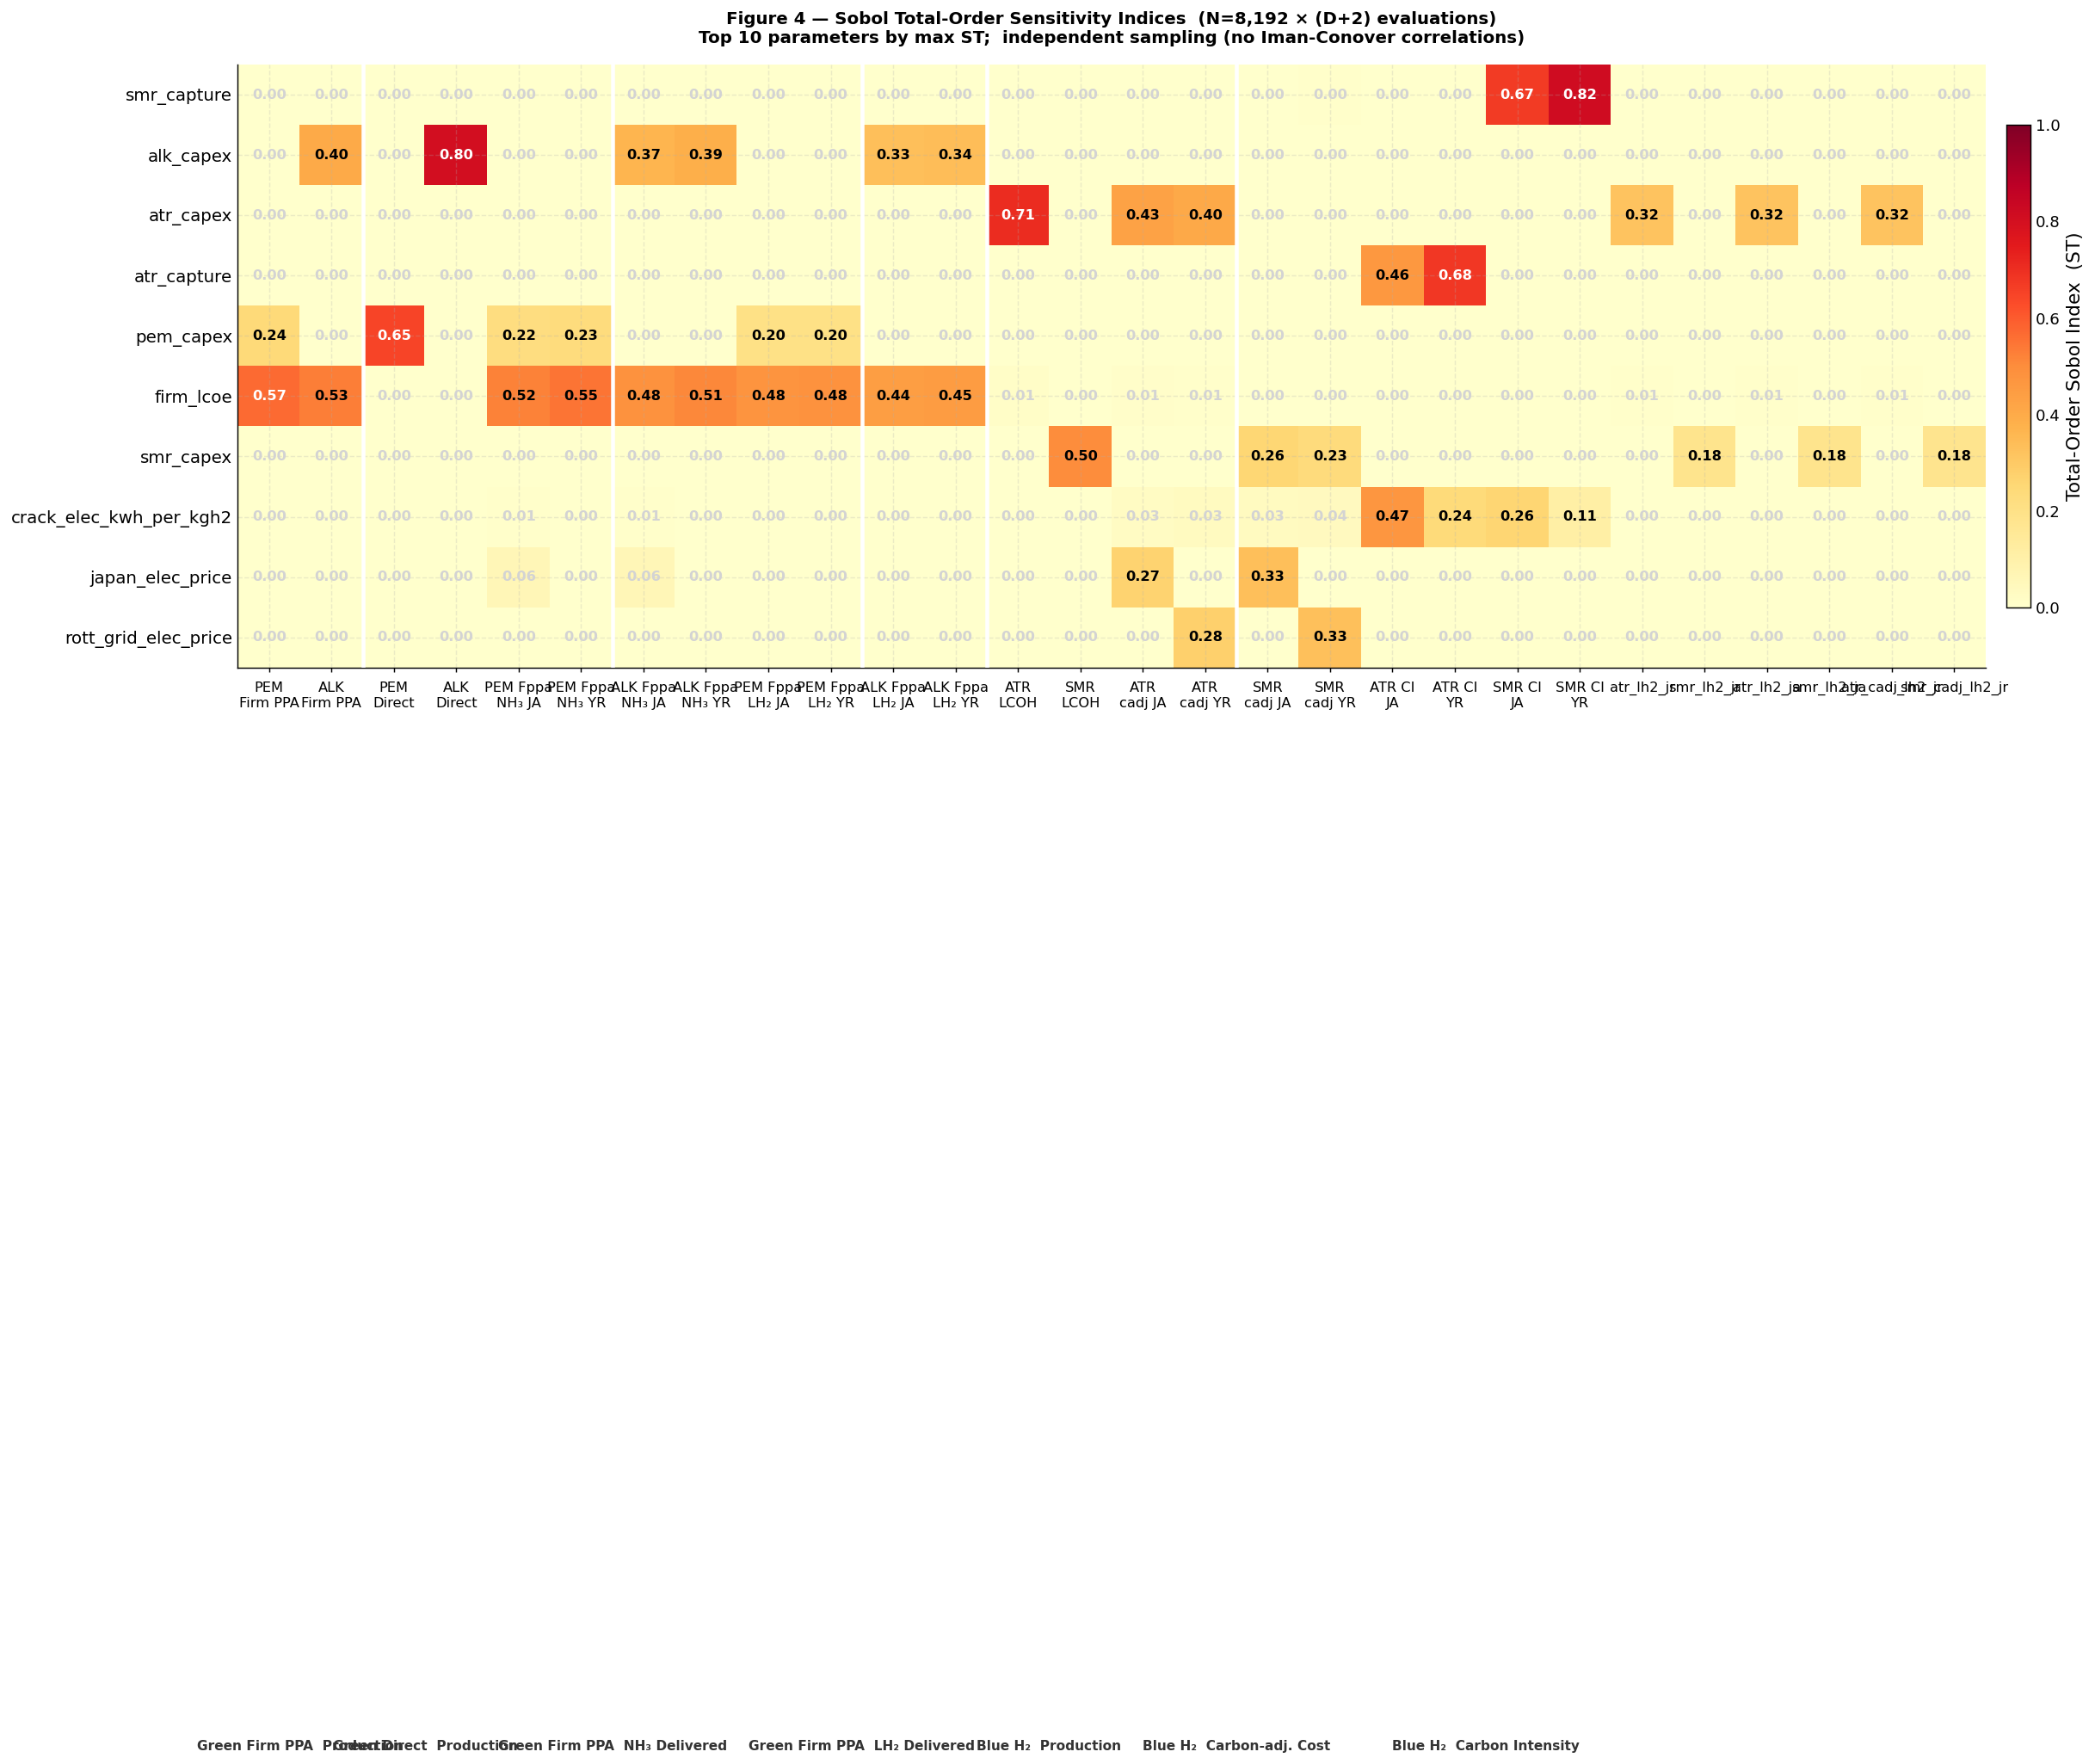

In [39]:
### 5.5  Figure 4 — Sobol Total-Order Sensitivity Heatmap

if '_all_ST' not in dir() or not (isinstance(_all_ST, dict) and _all_ST):
    print("Run Section 4.2 (Sobol cell) first to generate sensitivity indices.")
else:
    ST_df = pd.DataFrame(_all_ST)

    col_labels = {
        'lcoh_pem_fppa':     'PEM\nFirm PPA',
        'lcoh_alk_fppa':     'ALK\nFirm PPA',
        'lcoh_pem':          'PEM\nDirect',
        'lcoh_alk':          'ALK\nDirect',
        'pem_fppa_nh3_ja':   'PEM Fppa\nNH₃ JA',
        'pem_fppa_nh3_yr':   'PEM Fppa\nNH₃ YR',
        'alk_fppa_nh3_ja':   'ALK Fppa\nNH₃ JA',
        'alk_fppa_nh3_yr':   'ALK Fppa\nNH₃ YR',
        'pem_fppa_lh2_ja':   'PEM Fppa\nLH₂ JA',
        'pem_fppa_lh2_yr':   'PEM Fppa\nLH₂ YR',
        'alk_fppa_lh2_ja':   'ALK Fppa\nLH₂ JA',
        'alk_fppa_lh2_yr':   'ALK Fppa\nLH₂ YR',
        'lcoh_atr':          'ATR\nLCOH',
        'lcoh_smr':          'SMR\nLCOH',
        'atr_cadj_ja':       'ATR\ncadj JA',
        'atr_cadj_yr':       'ATR\ncadj YR',
        'smr_cadj_ja':       'SMR\ncadj JA',
        'smr_cadj_yr':       'SMR\ncadj YR',
        'ci_atr_nh3_ja':     'ATR CI\nJA',
        'ci_atr_nh3_yr':     'ATR CI\nYR',
        'ci_smr_nh3_ja':     'SMR CI\nJA',
        'ci_smr_nh3_yr':     'SMR CI\nYR',
    }

    top_params = ST_df.max(axis=1).nlargest(10).index.tolist()
    ST_plot = ST_df.loc[top_params].clip(lower=0)

    # ── Figure layout: wider to avoid x-label crowding (20 columns) ─────────
    fig, ax = plt.subplots(figsize=(24, 7))
    im = ax.imshow(ST_plot.values, aspect='auto', cmap='YlOrRd',
                   vmin=0, vmax=1.0, interpolation='nearest')

    xlbls = [col_labels.get(c, c) for c in ST_plot.columns]
    ax.set_xticks(range(len(ST_plot.columns)))
    ax.set_xticklabels(xlbls, fontsize=9, ha='center', va='top')
    ax.set_yticks(range(len(top_params)))
    ax.set_yticklabels(top_params, fontsize=11)
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(axis='x', pad=6)

    for i in range(len(top_params)):
        for j in range(len(ST_plot.columns)):
            val = ST_plot.values[i, j]
            txt_c = 'white' if val > 0.55 else ('black' if val > 0.08 else 'lightgrey')
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    color=txt_c, fontsize=9, fontweight='bold')

    # ── Vertical group separators ─────────────────────────────────────────────
    n_rows = len(top_params)
    for x_sep in [1.5, 5.5, 9.5, 11.5, 15.5]:
        ax.axvline(x=x_sep, color='white', linewidth=2.5, zorder=3)

    # ── Group header labels above the heatmap ────────────────────────────────
    group_spans = [
        (0,  1,  'Green Firm PPA  Production'),
        (2,  3,  'Green Direct  Production'),
        (4,  7,  'Green Firm PPA  NH\u2083 Delivered'),
        (8,  11, 'Green Firm PPA  LH\u2082 Delivered'),
        (12, 13, 'Blue H\u2082  Production'),
        (14, 17, 'Blue H\u2082  Carbon-adj. Cost'),
        (18, 21, 'Blue H\u2082  Carbon Intensity'),
    ]
    for (c0, c1, lbl) in group_spans:
        mid = (c0 + c1) / 2
        ax.text(mid, -1.8, lbl, ha='center', va='bottom', fontsize=8.5,
                fontweight='bold', color='#333333',
                transform=ax.get_xaxis_transform())

    cbar = plt.colorbar(im, ax=ax, label='Total-Order Sobol Index  (ST)',
                         shrink=0.80, pad=0.01)
    cbar.ax.tick_params(labelsize=10)

    ax.set_title(
        f'Figure 4 — Sobol Total-Order Sensitivity Indices  (N={SOBOL_N:,} × (D+2) evaluations)\n'
        'Top 10 parameters by max ST;  independent sampling (no Iman-Conover correlations)',
        fontsize=11, pad=14
    )
    plt.tight_layout()
    _save(fig, 'fig4_sobol_heatmap.png')
    plt.show()